# ECG Arrhythmia Classification — Hybrid 1D-CNN → BiLSTM → Attention
## Revised pipeline with inter-patient evaluation, statistical testing, and verified edge deployment

**Inputs:** a 1 s R-peak-centred window **plus 4 RR-interval features** (pre-RR, post-RR,
and two patient-relative ratios). The RR branch is what makes the AAMI **S** class
separable inter-patient — prematurity is invisible inside an R-peak-aligned window.

**Architectures (both trained on the identical split, compared with McNemar):**
1. 1D-CNN(64→128→256) → BiLSTM(128) → additive attention pooling → dense head
2. CNN–Transformer **gated fusion** → multi-head attention pooling → dense head
   (dilated residual CNN branch ∥ pre-LN transformer branch, fused by a per-token
   sigmoid gate; Sections 5B, 6B, 7C, 7D)
**Databases:** MIT-BIH Arrhythmia (48 rec) · MIT-BIH NSR (18 rec) · BIDMC-CHF (15 rec)

---

### What changed in this revision, and why

| # | Problem in the previous version | Fix in this notebook |
|---|---|---|
| 1 | **CHF class came from ONE patient.** The extraction loop `break`-ed out of the *outer* record loop once the 5,000-beat cap was hit, and `chf01` alone supplies ~96,000 beats. Records `chf02`–`chf15` were loaded and discarded. Same for NSR (`16265` only). | Per-record quotas, sampled **evenly across each full recording** (Section 3). All 15 CHF and 18 NSR records now contribute, across the whole circadian window. |
| 2 | **Random beat-level split** put beats from the same patient in train *and* test. Reported 98.59% was intra-patient and not comparable to published inter-patient results. | **Record-disjoint de Chazal DS1/DS2 split** with hard `assert` guards (Section 4). |
| 3 | **Class weights were all 1.0** — `compute_class_weight` ran *after* SMOTE had already balanced the training set, so the "weighted loss" was inoperative. | Weights computed **before** SMOTE, and applied only when SMOTE is off (Section 4). |
| 4 | Ablation discarded prediction vectors, so no significance test was possible. | All predictions saved; **McNemar** + Wilson CIs + bootstrap macro-F1 (Sections 7–8). |
| 5 | ROC AUC ≥ 0.995 for every class hid minority-class errors. | **Precision–recall curves** and precision-at-fixed-recall added (Section 7). |
| 6 | CHF perfectly correlated with source database and sampling rate. | **Two provenance controls** (Section 9): source-database probe and bandwidth equalisation. |
| 7 | Grad-CAM applied through a BiLSTM via `tf-keras-vis`, never faithfulness-tested. | Grad-CAM reimplemented with `GradientTape` (no external dep) + **attention weights** + **Integrated Gradients** + **deletion curve** (Section 10). |
| 8 | Cells out of order, dead cells, `.h5` legacy warnings, a cell referencing a missing script. | Runs top-to-bottom; `.keras` format; no dead cells. |
| 9 | No latency, RAM, or robustness measurement despite "edge-ready" claims. | Latency + arena estimate + noise/wander sweep (Sections 11–12). |

> **Expect accuracy to fall to roughly 0.88–0.95, with S-class F1 possibly 0.40–0.75.**
> That is the correct outcome of honest inter-patient evaluation, not a regression.
> Set `PROTOCOL = 'intra'` in the config to reproduce the old number for comparison.

### Addendum — S-beat-focused revision (this pass)

| # | Change | Where |
|---|---|---|
| 1 | `subsample_even` (class-blind) -> `class_aware_subsample` for MIT-BIH beats: all S (and F) beats are preserved per record whenever feasible; before/after per-record diagnostics printed | Section 3, 3A2 |
| 2 | Auxiliary features reorganised into named groups (`RR_basic/context/dynamics`, `QRS_morphology`, `P_wave`, `RR_normal_reference`, `Patient_normal_template`, `Fusion`) instead of one flat 23/32-wide block | Section 3, `EXPERIMENT_C_FEATURE_GROUPS` |
| 3 | New label-free, crash-proof P-wave feature extractor (15 features, R-250ms..R-80ms window) | Section 3A2 |
| 4 | `build_multibeat_sequences` (5-beat, record-boundary-safe) implemented and self-tested on the real dataset, **not yet wired into the trained model** -- see Section 3E for why | Section 3E |
| 5 | New N-beat-only, per-record robust RR reference (median/MAD) supplementing (not replacing) the existing rolling-local-median prematurity feature | Section 3A2 |
| 6 | New per-record patient-normal morphology template (median of that record's own N beats) with correlation/distance features vs. the existing TRAIN-only global N/V fusion templates | Section 3A2 |
| - | New S-class feature-group ablation (RR -> RR+QRS -> +P-wave -> +patient-normal) | Section 9E |

**Not fabricated / not run:** none of this was executed in the environment that wrote it -- no MIT-BIH/NSR/CHF data or GPU was available there. Every number in Sections 7-9 after you run this on Kaggle is the first time these features have actually been measured. Do not treat any S-recall/F1 figure as validated until that run completes.

In [14]:
# ============================================================
#  CONFIGURATION — edit here only
# ============================================================

# 'inter' = record-disjoint (de Chazal DS1/DS2)  <-- report this one
# 'intra' = random beat-level split (old behaviour, for comparison only)
PROTOCOL = 'inter'

DATASET_MODE = 'augmented'      # '5class' | 'augmented' | '6class'

# Per-record quotas (NOT global caps -- this is fix #1)
MITBIH_N_PER_RECORD = 300    # 48 rec x 300 ~= 14k N beats, every patient represented
                             # (was 60: ~1.2k N beats in DS1 starved every model and is
                             #  the second-largest cause of the weak inter-patient score)
NSR_PER_RECORD      = 280    # 18 rec x 280 ~= 5.0k
CHF_PER_RECORD      = 334    # 15 rec x 334 ~= 5.0k

# ── AAMI EC57 compliance ─────────────────────────────────────
# EC57 governs the TEST SET and the REPORTING, not the training procedure.
# Strict mode enforces the three things the standard actually requires:
#   1. the four paced records (102, 104, 107, 217) are excluded
#   2. the AAMI five-class grouping only -- no extra non-AAMI classes
#   3. per-class sensitivity and positive predictivity are the headline metrics
AAMI_STRICT = True           # set False only to reproduce the exploratory 6-class run
MIN_CLASS_BEATS = 100        # classes rarer than this are dropped and reported as such

# ── Q class (AAMI 'unknown': paced '/', paced-normal fusion 'f', unclassifiable 'Q')
# The Q class is almost entirely contained in the four paced records, so the plain
# EC57 rule "exclude 102/104/107/217" and the goal "report Q" are in direct conflict:
# with the records excluded, exactly 1 Q beat survived and Section 3B dropped the class.
# Q_POLICY decides how that conflict is resolved.
#
#   'q_only_from_paced'  keep ONLY the Q beats of the paced records; every N/S/V/F beat
#                        of those records is still discarded.  <-- default
#                        The reason EC57 excludes paced records is that a pacemaker
#                        rewrites QRS morphology, which corrupts N/S/V/F statistics.
#                        Keeping the paced beats *as Q* -- the class that is defined by
#                        exactly that morphology -- does not corrupt anything, and the
#                        N/S/V/F supports stay bit-identical to the paced-excluded run,
#                        so the 4-class numbers remain directly comparable.
#   'keep_paced_records' keep the paced records whole (all classes). Maximum data, but
#                        the N/S/V/F metrics are no longer EC57-conformant -- say so.
#   'exclude'            original behaviour: drop the paced records, Q disappears.
INCLUDE_Q_CLASS   = True
Q_POLICY          = 'q_only_from_paced'
PACED_RECORDS     = ['102', '104', '107', '217']
PACED_QUOTA       = 500      # Q beats kept per paced record (they hold ~2,000 each)
Q_FOCAL_ALPHA     = 1.10     # focal-loss emphasis for Q; it is morphologically distinct,
                             # so it does not need S/F-level up-weighting
# de Chazal assigns NO paced record to DS1 or DS2, so their partition is free.
# Two training records (one pure-paced, one paced/native mix) give the model more than
# one pacing morphology; 107 is held out entirely so Q generalisation is measured on a
# patient the model has never seen -- the same standard the other four classes are held to.
PACED_TRAIN, PACED_VAL, PACED_TEST = ['102', '217'], ['104'], ['107']

# ── Class-imbalance strategy ────────────────────────────────
#   'none'         no correction -- the AAMI-purist baseline
#   'class_weight' weighted cross-entropy; changes the LOSS, never the DATA  <-- default
#   'focal'        focal loss, gamma=2; down-weights easy majority beats
#   'smote'        synthetic minority oversampling of the TRAINING set only
# SMOTE is not forbidden by EC57, but it fabricates ECG morphology that no heart
# produced, so it is not the default here. Section 9B compares all four.
# CHANGED (F pass): 'focal' -> 'none'. The notebook's own ablation shows focal
# does not buy F sensitivity; F is now handled by targeted measures (F-specific
# augmentation + F/V hard-negative mining + F auxiliary losses) instead of a
# global reweighting of every minority class. Section 9H arm A5 measures this.
BALANCING = 'none'

# Model / training
BEAT_LENGTH   = 360          # 1.0 s @ 360 Hz
EPOCHS        = 60
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
SEED          = 42

# Optional heavy stages (set False to shorten the run)
RUN_ABLATION      = True     # Section 9, unified ablation study (see below for its own knobs)
RUN_CONTROLS      = True     # ~5 min
RUN_EXPLAIN       = True     # ~3 min
RUN_MCU           = True     # ~10 min
RUN_ROBUSTNESS    = True     # ~2 min

# -- F-beat fusion-similarity features (Section 1D, 4A0) ------
# Normal/Ventricular template-similarity features, purpose-built for the AAMI
# F (fusion) class -- see Section 4A0 for the full rationale.
RUN_FUSION_FEATURES  = True  # adds 9 columns to the auxiliary feature vector

# -- RR-interval features (Section 1, 3) ---------------------
# THE single largest inter-patient fix. An AAMI S beat is defined by TIMING, not
# morphology: a supraventricular ectopic beat is premature with a near-normal QRS.
# A 360-sample window centred on the R peak has that information cropped out, so no
# architecture operating on the window alone can separate S from N. Intra-patient
# splits hide this, because the model can memorise each patient's own morphology.
USE_RR = True
N_RR   = 4          # placeholder; overwritten twice downstream -- do not rely on
                     # this value directly. Section 3G sets it to 23 once Experiment C's
                     # RR + QRS + previous-beat features (Section 1C) are extracted; if
                     # RUN_FUSION_FEATURES, Section 4A0 then adds 9 N/V template-fusion
                     # features (Section 1D) on top, making it 32.

# -- train-time augmentation (Section 4B) --------------------
# Amplitude scale, time warp, baseline wander, noise and lead-polarity flip.
# Targets exactly the variation that separates one patient from another, which is
# what the inter-patient protocol actually tests.
USE_AUGMENT = True

# ── Section 9: unified ablation study ───────────────────────
# One engine, one table, one significance family. Every arm is the SAME
# architecture/split/test set as the reported model except for the single thing
# named in the arm, so each row answers exactly one question.
ABLATION_GROUPS   = ('architecture', 'features', 'balancing', 'augmentation')
ABLATION_EPOCHS   = 40       # arms converge well before the baseline's 60
ABLATION_PATIENCE = 10
ABLATION_SEEDS    = [SEED]   # add e.g. [SEED, 7, 13] for mean +/- sd; cost scales linearly
ABLATION_SAVE_PREDS = True
ABLATION_BOOTSTRAP  = 2000   # paired bootstrap resamples for the delta-macro-F1 CI

SAVE_FIGURES = True
MODEL_NAME   = 'ecg_cnn_bilstm_attention'

# -- MSFT-Net: Multi-Scale, SE, FiLM-conditioned, Temporal-pooled Network, Section 5B --
# Second architecture, trained on the SAME split with the SAME balancing strategy,
# so the comparison against the BiLSTM hybrid is paired and McNemar is valid.
# Multi-scale depthwise-separable stem + SE channel gating + FiLM-conditioning on the
# RR/morphology feature vector + additive attention pooling. Replaces the
# CNN-Transformer Gated Fusion architecture as the second model.
RUN_MSFT        = True            # ~10-15 min on a T4
MSFT_WIDTH      = 32              # base stem width -> stages end at 64/128/128 channels
MSFT_LR         = LEARNING_RATE   # no attention-style instability here, hybrid's LR is fine
MODEL_NAME_MSFT = 'ecg_msft_net'  # multi-scale + SE + FiLM + pooled network
# CHANGED (F pass): temporal attention pooling -> global average pooling.
#   'gap'       GlobalAveragePooling1D  <-- reported configuration
#   'attention' the original additive attention pooling (ablation arm A0 only)
MSFT_POOLING    = 'gap'

# -- F-beat targeted improvements (Sections 1E/4A1/4B/5C/6C) --------------
# Six additions on top of Section 1D's N/V templates, all gated so the
# existing pipeline is unchanged when they are off. Priorities per the task:
# fusion continuum + hard negatives = VERY HIGH, regional QRS + patient N/V
# = HIGH, aux loss = MEDIUM-HIGH, F augmentation = MEDIUM.
RUN_ADVANCED_F_FEATURES = True    # Improvements 1, 3, 4 (Section 4A1) -- feature-only,
                                   # always safe to leave on; adds columns to rr_input
FUSION_ALPHAS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Improvement 1A
MAX_PATIENT_TEMPLATE_BEATS = 500  # Improvement 4B
MIN_PATIENT_V_BEATS = 5           # below this, patient V template falls back to global
MIN_PATIENT_N_BEATS = 5           # same, for the patient N template built in Section 4A1
                                   # (independent of the existing per-record template in 3A2)

ENABLE_F_AUGMENT = True           # Improvement 5, wired into build_training_set (Section 4B)
# CHANGED (F pass): every F beat is now augmented (prob 1.0) and F_AUGMENT_COPIES
# independent conservative copies are drawn per beat instead of one. The original
# beats are always kept -- these are additions, never replacements. The
# transformation RANGES below are deliberately left conservative: F is defined by a
# morphology sitting between N and V, so a strong perturbation manufactures a beat
# that is no longer a fusion beat.
F_AUGMENT_PROB       = 1.0        # fraction of F beats that get augmented copies
F_AUGMENT_COPIES     = 3          # independent conservative copies per selected F beat
F_AMPLITUDE_RANGE    = (0.90, 1.10)
F_TIME_WARP_RANGE    = (0.97, 1.03)
F_NOISE_RANGE_DB     = (20.0, 30.0)   # higher SNR (less noise) than the generic 15-25 dB
F_BASELINE_RANGE     = (0.0, 0.10)    # wander amplitude, well below the generic 0.0-0.30
F_POLARITY_FLIP      = False      # Section 5B: disabled unless the record's own lead
                                   # configuration already justifies it (it does not here)

# ── Stage 2: F/V hard-negative mining (Section 6C) ──────────
# NOTE: in the previous version of this notebook these two flags existed but NO
# code read them -- there was no mining function and no Section 6C, so the
# reported model never saw a mined hard negative. Section 6C now implements the
# mining and the fine-tune, and this flag genuinely gates it.
ENABLE_HARD_NEGATIVE_MINING = True   # Improvement 2 (Section 6C), TRAINING-only mining
HARD_NEGATIVE_RATIO = 1.0            # scales the EXTRA weight: eff = 1 + ratio*(W-1)
HARD_FV_WEIGHT = 2.00                # true F predicted V   <-- the dominant error
HARD_FN_WEIGHT = 1.50                # true F predicted N
HARD_VF_WEIGHT = 1.50                # true V predicted F
HARD_NF_WEIGHT = 1.25                # true N predicted F
HARD_NEG_FINETUNE_EPOCHS = 12
HARD_NEG_LR_SCALE = 0.2              # stage-2 lr = MSFT_LR * this

# ── Stage 3: F-vs-N / F-vs-V auxiliary losses (Sections 5C/6D) ──
# Same caveat: build_f_aux_train_model()/make_f_aux_targets() were defined in
# Section 5C but never called anywhere, so ENABLE_F_AUX_LOSS = True did not mean
# the reported model was trained with them. Section 6D now calls them.
ENABLE_F_AUX_LOSS = True          # Improvement 6 (Section 5C/6D)
LAMBDA_F_N = 0.15                 # F-vs-V gets the larger weight: F->V is the
LAMBDA_F_V = 0.35                 # dominant error (174/398 in the baseline run)
F_AUX_FINETUNE_EPOCHS = 15        # short fine-tune stage on top of the trained baseline,
                                   # not a full 60-epoch retrain from scratch
F_AUX_LR_SCALE = 0.1               # stage-3 lr = MSFT_LR * this

# ── Section 9H: focused F ablation (A0 … A5) ────────────────
# Each arm retrains MSFT-Net from scratch on the same split. Budget roughly
# len(F_ABLATION_ARMS) x F_ABLATION_EPOCHS epochs; set RUN_F_ABLATION = False to skip.
RUN_F_ABLATION     = True
F_ABLATION_ARMS    = ['A0', 'A1', 'A2', 'A3', 'A4', 'A5']
F_ABLATION_EPOCHS  = 40
F_ABLATION_PATIENCE = 8

# ── derived (do not edit) ────────────────────────────────────
if AAMI_STRICT:
    # 'augmented' = the five EC57 classes, with the NSR database folded into N.
    # ('5class' would switch NSR off, but Section 2B was overriding that anyway --
    #  the override is gone now, so the mode has to say what is actually loaded.)
    DATASET_MODE = 'augmented'

if DATASET_MODE == '5class':
    NUM_CLASSES = 6
    CLASS_NAMES = ['N-Normal', 'S-Supra', 'V-Ventri', 'F-Fusion', 'Q-Unknown', 'CHF']
    USE_NSR, USE_CHF = True, True
elif DATASET_MODE == 'augmented':
    NUM_CLASSES = 5
    CLASS_NAMES = ['N-Normal', 'S-Supra', 'V-Ventri', 'F-Fusion', 'Q-Unknown']
    USE_NSR, USE_CHF = True, False
else:
    NUM_CLASSES = 5
    CLASS_NAMES = ['N-Normal', 'S-Supra', 'V-Ventri', 'F-Fusion', 'Q-Unknown']
    USE_NSR, USE_CHF = False, False

print("=" * 62)
print(f"  PROTOCOL      : {PROTOCOL}  " +
      ("(record-disjoint, inter-patient)" if PROTOCOL == 'inter' else "(random beat-level -- NOT publishable)"))
print(f"  DATASET_MODE  : {DATASET_MODE}   NUM_CLASSES: {NUM_CLASSES}")
print(f"  CLASSES       : {CLASS_NAMES}")
print(f"  AAMI_STRICT   : {AAMI_STRICT}" +
      ("  (5 AAMI classes, Se/+P reporting)" if AAMI_STRICT else
       "  (exploratory mode -- NOT EC57 compliant)"))
print(f"  Q CLASS       : {INCLUDE_Q_CLASS}  policy='{Q_POLICY}'" +
      (f"  paced: train={PACED_TRAIN} val={PACED_VAL} test={PACED_TEST}"
       if INCLUDE_Q_CLASS and Q_POLICY != 'exclude' else "  (paced records dropped)"))
print(f"  BALANCING     : {BALANCING}" + ("  (targeted F measures instead of a global reweighting)" if BALANCING == 'none' else ""))
print(f"  MSFT POOLING  : {MSFT_POOLING}   F aug: prob={F_AUGMENT_PROB} copies={F_AUGMENT_COPIES}")
print(f"  F STAGES      : hard-neg={ENABLE_HARD_NEGATIVE_MINING}  aux-loss={ENABLE_F_AUX_LOSS} (lambda F/N={LAMBDA_F_N}, F/V={LAMBDA_F_V})")
print(f"  RR FEATURES   : {USE_RR}" + ("  (RR + morphology, set after Section 3)" if USE_RR else
      "  <-- S class cannot be separated without these"))
print(f"  AUGMENTATION  : {USE_AUGMENT}  (training partition only)")
print(f"  MODELS        : CNN-BiLSTM-Attention" +
      (f" + MSFT-Net (multi-scale+SE+FiLM, width={MSFT_WIDTH})" if RUN_MSFT else ""))
print("=" * 62)

# ============================================================
#  SECTION 0Q — Q-CLASS PASS  (added after the F pass)
# ============================================================
# AUDIT FINDING, from this notebook's own recorded outputs — read before
# touching any knob below:
#
#   train counts  N=7455  S=774  V=283  F=399  Q=1008
#     -> Q is the SECOND LARGEST training class. V has 283 beats, 3.6x fewer
#        than Q, and reaches test Se=0.922. Q is therefore NOT an imbalance
#        problem, and the standard imbalance remedies are not the fix.
#   Section 6C mining log: 2 hard negatives found in 21,809 training beats,
#   train accuracy 0.9996-1.0000
#     -> the stage-1 model memorises the training partition. Any mining rule of
#        the form (y_true != y_pred) on TRAIN is a no-op. Q mining must be
#        margin-based or out-of-fold, or it will mine nothing.
#   Section 9 ablation, per-class Se for Q (hybrid, same split):
#        full model                   Q Se 0.596
#        - all auxiliary features     Q Se 0.982   <-- +0.386
#        - QRS morphology only        Q Se 0.148
#        - P-wave only                Q Se 0.274
#        balancing: class_weight      Q Se 0.229   <-- -0.367
#     -> the 107-dim auxiliary vector is what destroys Q, and re-weighting
#        towards minority classes destroys it further. In MSFT-Net that vector
#        is injected FOUR times (FiLM at stage1/2/3 + head concat), which is
#        why MSFT-Net's Q Se is 0.059 while the hybrid's is 0.596 on identical
#        beats.
#   Q support: train = records 102,217 | val = 104 | test = 107 (+7 stray
#   beats from 105/214).  Q is a 2-patient / 1-patient / 1-patient class.
#
# Consequence for the six requested changes: Q augmentation, the Q auxiliary
# head and (fixed) Q mining are kept; Q class weighting and balanced batches
# are IMPLEMENTED but default to neutral, because the ablation above predicts
# they will hurt. They are still measured, as arms A5/A6.

# ── Q-specific augmentation (Section 1G, applied in Section 4B) ──
ENABLE_Q_AUGMENT   = True
Q_AUGMENT_PROB     = 1.0
Q_AUGMENT_COPIES   = 1        # NOT 2: Q already reaches 2,016 beats after the
                              # generic doubling, ahead of V (566) and F (1,995).
                              # The deficit is diversity, not count.
# Q_AUGMENT_PRESET selects the ranges. 'conservative' is the narrow setting;
# 'cross_patient' is wider on exactly the axes that differ between pacemaker
# patients (pulse amplitude, paced QRS width) and is the default, because the
# failure is cross-patient generalisation, not within-patient noise.
Q_AUGMENT_PRESET   = 'cross_patient'      # 'cross_patient' | 'conservative'
if Q_AUGMENT_PRESET == 'conservative':
    Q_AMPLITUDE_RANGE = (0.95, 1.05)
    Q_TIME_WARP_RANGE = (0.98, 1.02)
    Q_NOISE_RANGE_DB  = (22.0, 32.0)
    Q_BASELINE_RANGE  = (0.0, 0.05)
else:
    Q_AMPLITUDE_RANGE = (0.70, 1.30)   # paced-pulse amplitude is patient/lead specific
    Q_TIME_WARP_RANGE = (0.85, 1.15)   # paced QRS width varies with the device
    Q_NOISE_RANGE_DB  = (18.0, 30.0)
    Q_BASELINE_RANGE  = (0.0, 0.15)
Q_POLARITY_FLIP    = False
# Jitter on the STANDARDISED auxiliary vector of synthetic Q beats. This is the
# axis the ablation says actually fails; sd is in units of the training sd.
Q_AUX_JITTER_SD    = 0.25

# ── Auxiliary-vector stochastic dropout (Section 5B2) ───────────
# Drops the ENTIRE 107-dim auxiliary vector for a fraction of training beats,
# forcing the CNN morphology path to be independently sufficient. This is the
# direct implementation of the '- all auxiliary' ablation result (Q 0.596 ->
# 0.982) without giving up the vector that S and F need (S 0.258, F 0.000
# without it). 0.0 reproduces the current architecture bit-for-bit.
AUX_VECTOR_DROPOUT  = 0.30      # P(whole aux vector zeroed), training only
AUX_FEATURE_DROPOUT = 0.10      # P(individual aux feature zeroed), training only

# ── Q hard-negative mining (Section 6C2) ────────────────────────
ENABLE_Q_HARD_MINING = True
Q_MINING_MODE      = 'margin'   # 'error' | 'margin' | 'both'
                                # 'error' is retained for reproducibility but
                                # mines ~0 beats at 100% train accuracy.
Q_MARGIN_FRAC      = 0.25       # lowest-margin fraction of TRAIN Q beats
Q_HARD_NEG_WEIGHT  = 2.0
Q_TO_N_HARD_WEIGHT = 1.5
Q_TO_S_HARD_WEIGHT = 1.5
Q_TO_V_HARD_WEIGHT = 2.5
Q_TO_F_HARD_WEIGHT = 1.5
SAMPLE_WEIGHT_CLIP = 6.0        # ceiling on the product of all weight factors

# ── Q-vs-Others auxiliary head (Sections 5D / 6D) ───────────────
ENABLE_Q_AUX_LOSS  = True
LAMBDA_Q           = 0.15

# ── Q sample weighting (Change 6) — neutral by default ──────────
# 1.0, not 1.5: Q is the 2nd largest training class and the ablation shows
# minority re-weighting costs Q 0.367 Se. Arm A6 measures 1.5.
Q_CLASS_WEIGHT     = 1.0

# ── Balanced mini-batches (Change 5) — off by default ───────────
USE_BALANCED_BATCHES = False
BALANCED_BATCH_ALPHA = 0.5      # 0 = empirical distribution, 1 = uniform

# ── Reduced F oversampling (Change 4) ───────────────────────────
# Applied only when REDUCE_F_OVERSAMPLING is True, so arm A0 still reproduces
# the reported F model exactly.
REDUCE_F_OVERSAMPLING = False
if REDUCE_F_OVERSAMPLING:
    F_AUGMENT_PROB   = 0.75
    F_AUGMENT_COPIES = 2

# ── Section 9Q: A0..A7 Q ablation ───────────────────────────────
RUN_Q_ABLATION      = True
Q_ABLATION_ARMS     = ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']
Q_ABLATION_EPOCHS   = 40
Q_ABLATION_PATIENCE = 8

print(f"  Q PASS        : aug={ENABLE_Q_AUGMENT}({Q_AUGMENT_PRESET}, copies={Q_AUGMENT_COPIES})"
      f"  aux-head={ENABLE_Q_AUX_LOSS}(lambda={LAMBDA_Q})  mining={Q_MINING_MODE}")
print(f"  AUX DROPOUT   : vector={AUX_VECTOR_DROPOUT}  feature={AUX_FEATURE_DROPOUT}"
      f"   Q class weight={Q_CLASS_WEIGHT}  balanced batches={USE_BALANCED_BATCHES}")
print("=" * 62)


  PROTOCOL      : inter  (record-disjoint, inter-patient)
  DATASET_MODE  : augmented   NUM_CLASSES: 5
  CLASSES       : ['N-Normal', 'S-Supra', 'V-Ventri', 'F-Fusion', 'Q-Unknown']
  AAMI_STRICT   : True  (5 AAMI classes, Se/+P reporting)
  Q CLASS       : True  policy='q_only_from_paced'  paced: train=['102', '217'] val=['104'] test=['107']
  BALANCING     : none  (targeted F measures instead of a global reweighting)
  MSFT POOLING  : gap   F aug: prob=1.0 copies=3
  F STAGES      : hard-neg=True  aux-loss=True (lambda F/N=0.15, F/V=0.35)
  RR FEATURES   : True  (RR + morphology, set after Section 3)
  AUGMENTATION  : True  (training partition only)
  MODELS        : CNN-BiLSTM-Attention + MSFT-Net (multi-scale+SE+FiLM, width=32)
  Q PASS        : aug=True(cross_patient, copies=1)  aux-head=True(lambda=0.15)  mining=margin
  AUX DROPOUT   : vector=0.3  feature=0.1   Q class weight=1.0  balanced batches=False


## Section 0 — Configuration

In [15]:
# Kaggle: Settings -> Internet must be ON for this cell.
# NOTE: do NOT pin wfdb. An older wfdb combined with NumPy >= 2 raises
#   OverflowError: Python integer 256 out of bounds for uint8
# inside wfdb.rdann.  We install the newest wfdb, and Section 1B additionally
# patches the bug and provides a dependency-free fallback reader, so the
# notebook works no matter which versions Kaggle ships.
!pip install -q -U wfdb imbalanced-learn
import wfdb, numpy
print("wfdb", wfdb.__version__, "| numpy", numpy.__version__)

wfdb 4.3.1 | numpy 2.0.2


In [16]:
# ============================================================
#  Imports, seeding, determinism
# ============================================================
import os, gc, time, json, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from tensorflow.keras import Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks, resample_poly
from scipy.stats import chi2
from scipy import stats
import wfdb

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE

SEED = SEED
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
try:
    tf.config.experimental.enable_op_determinism()
    print("op determinism enabled")
except Exception as e:
    print(f"op determinism unavailable ({e}) -- results will vary slightly between runs")

print(f"TensorFlow {tf.__version__} | Keras {keras.__version__}")
print("GPUs:", tf.config.list_physical_devices('GPU'))

op determinism enabled
TensorFlow 2.20.0 | Keras 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Section 1 — Preprocessing functions

In [17]:
# ============================================================
# SECTION 1: Preprocessing
# ============================================================

def bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=360.0, order=2):
    """Zero-phase Butterworth band-pass. Applied forward-backward (filtfilt), so the
    effective magnitude response is |H|^2 (4th order) with exactly zero phase distortion --
    essential here, because any group delay would displace the QRS fiducial point.
    NOTE: previously described in the thesis as a '12-layer filter'; that was incorrect."""
    nyq = 0.5 * fs
    low, high = lowcut / nyq, min(highcut / nyq, 0.99)   # guard for fs=128 Hz records
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)


def pan_tompkins_rpeaks(signal, fs=360):
    """Pan-Tompkins R-peak detection for records without expert annotations (NSR, CHF)."""
    nyq = 0.5 * fs
    b, a = butter(2, [5 / nyq, min(15 / nyq, 0.99)], btype='band')
    filtered = filtfilt(b, a, signal)
    deriv    = np.diff(filtered, prepend=filtered[0])
    squared  = deriv ** 2
    win      = max(1, int(0.15 * fs))
    mwa      = np.convolve(squared, np.ones(win) / win, mode='same')
    peaks, _ = find_peaks(mwa, distance=int(0.3 * fs), height=np.mean(mwa) * 2.0)
    r_peaks, sw = [], max(1, int(0.05 * fs))
    for p in peaks:
        s, e = max(0, p - sw), min(len(signal), p + sw)
        if e > s:
            r_peaks.append(s + int(np.argmax(np.abs(signal[s:e]))))
    return np.array(r_peaks, dtype=int)


def extract_beats(signal, r_peaks, beat_length=360):
    """Fixed-length windows centred on R-peaks. Returns (beats, indices of usable peaks)."""
    half, beats, valid = beat_length // 2, [], []
    for i, r in enumerate(r_peaks):
        if r - half >= 0 and r + half < len(signal):
            beats.append(signal[r - half: r + half]); valid.append(i)
    if not beats:
        return np.empty((0, beat_length), dtype=np.float32), []
    return np.asarray(beats, dtype=np.float32), valid


def map_aami(symbol):
    """MIT-BIH annotation symbol -> AAMI EC57 superclass (-1 = discard)."""
    aami = {'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
            'A': 1, 'a': 1, 'J': 1, 'S': 1,
            'V': 2, 'E': 2,
            'F': 3,
            '/': 4, 'f': 4, 'Q': 4}
    return aami.get(symbol, -1)


def resample_beat(beat, target_length=360):
    """Linear interpolation to a common length. NOTE: this preserves duration but NOT
    bandwidth -- a 128 Hz beat upsampled to 360 has no energy above 64 Hz. Because the CHF
    class comes from a single database, that leaves a class-correlated artefact. Section 9
    tests for it explicitly."""
    if len(beat) == target_length:
        return beat
    return np.interp(np.linspace(0, len(beat) - 1, target_length),
                     np.arange(len(beat)), beat)


def per_beat_zscore(X):
    """Per-beat (instance) z-score. Alignment-independent, needs no stored statistics,
    computable on an MCU in two passes over the input buffer."""
    X = np.asarray(X, dtype=np.float32)
    m = X.mean(axis=1, keepdims=True)
    s = X.std(axis=1, keepdims=True) + 1e-6
    return (X - m) / s


def subsample_even(n_items, k):
    """Indices of k items spread evenly across a FULL recording -- not the first k.
    This is the core of fix #1: it preserves circadian variation and, applied per record,
    guarantees every patient contributes."""
    if n_items <= 0:
        return np.array([], dtype=int)
    if n_items <= k:
        return np.arange(n_items, dtype=int)
    return np.unique(np.linspace(0, n_items - 1, k).astype(int))


def rr_features(peaks, valid_idx, fs, local_n=10, clip=4.0):
    """
    Rhythm features designed specifically to separate S beats from N beats.

    Features:
      0  pre-RR
      1  post-RR
      2  pre-RR / local median RR
      3  post-RR / local median RR
      4  pre-RR / record median RR
      5  post-RR / record median RR
      6  pre/post RR ratio
      7  local RR coefficient of variation
      8  prematurity index
      9  compensatory/post-prematurity index

    All statistics are computed from the R-peak sequence BEFORE beat
    filtering/class selection.
    """

    peaks = np.asarray(peaks, dtype=np.float64)

    if len(peaks) < 3:
        return np.zeros((len(valid_idx), 10), dtype=np.float32)

    rr = np.diff(peaks) / float(fs)

    # Full-length pre/post RR arrays
    pre = np.empty(len(peaks), dtype=np.float64)
    post = np.empty(len(peaks), dtype=np.float64)

    pre[0] = np.median(rr) if len(rr) else 0.8
    pre[1:] = rr

    post[:-1] = rr
    post[-1] = np.median(rr) if len(rr) else 0.8

    # --------------------------------------------------------
    # Local robust rhythm reference
    # --------------------------------------------------------
    local_median = (pd.Series(pre).rolling(window=local_n,min_periods=3,center=True).median().bfill().ffill().values)

    record_median = float(np.median(rr))

    # --------------------------------------------------------
    # Basic normalized RR
    # --------------------------------------------------------
    pre_local_ratio = pre / np.maximum(local_median, 1e-6)
    post_local_ratio = post / np.maximum(local_median, 1e-6)

    pre_record_ratio = pre / max(record_median, 1e-6)
    post_record_ratio = post / max(record_median, 1e-6)

    pre_post_ratio = pre / np.maximum(post, 1e-6)

    # --------------------------------------------------------
    # Local rhythm variability
    # --------------------------------------------------------
    local_std = (pd.Series(pre).rolling(window=local_n,min_periods=3,center=True).std().bfill().ffill().values)

    local_cv = local_std / np.maximum(local_median, 1e-6)

    # --------------------------------------------------------
    # IMPORTANT: explicit S-beat prematurity
    # --------------------------------------------------------
    prematurity = pre_local_ratio

    # How much the next interval compensates after the premature beat
    compensatory = post_local_ratio

    F = np.stack([
        pre,
        post,
        pre_local_ratio,
        post_local_ratio,
        pre_record_ratio,
        post_record_ratio,
        pre_post_ratio,
        local_cv,
        prematurity,
        compensatory
    ], axis=1)

    F = np.nan_to_num(F,nan=0.0,posinf=clip,neginf=0.0)

    F = np.clip(F, 0.0, clip)

    return F[np.asarray(valid_idx, dtype=int)].astype(np.float32)


def augment_beats(X, rs):
    """Training-only augmentation aimed at INTER-PATIENT variation.

    Amplitude scale (electrode placement and body habitus), time warp (heart-rate
    dependent QRS width), baseline wander (respiration and motion), additive noise
    (ambulatory recording), and lead-polarity flip (inverted leads are common in
    MIT-BIH). Applied to the raw beat BEFORE z-scoring, so the scaling is not
    immediately normalised away by the per-beat standardisation.

    RR features are deliberately NOT augmented: warping the window changes QRS shape,
    not the interval between R peaks, so the paired RR row stays valid."""
    Xf = np.asarray(X, dtype=np.float32).reshape(len(X), -1)
    n, T = Xf.shape
    out = np.empty_like(Xf)
    grid = np.arange(T)
    for i in range(n):
        b = Xf[i]
        f = rs.uniform(0.90, 1.10)                                   # time warp
        w = np.interp(np.clip(np.linspace(0, T - 1, max(8, int(round(T * f)))), 0, T - 1),
                      grid, b)
        w = np.interp(np.linspace(0, len(w) - 1, T), np.arange(len(w)), w)
        w = w * rs.uniform(0.80, 1.20)                               # amplitude
        if rs.random() < 0.20:
            w = -w                                                   # lead polarity
        w = w + rs.uniform(0.0, 0.30) * np.sin(
            2 * np.pi * rs.uniform(0.15, 0.50) * grid / 360.0 + rs.uniform(0, 2 * np.pi))
        p_sig = float(np.mean(w ** 2)) + 1e-12                       # noise 15-25 dB
        w = w + rs.standard_normal(T) * np.sqrt(p_sig / 10 ** (rs.uniform(15, 25) / 10))
        out[i] = w
    return out


def augment_minority_classes(X,y,rs,class_names,copies_s=2,copies_f=2):
    """
    Additional training-only augmentation for S and F.

    Original samples are preserved.
    Synthetic samples are generated only from the training partition.
    """

    X_parts = [X]
    y_parts = [y]

    for cls, name in enumerate(class_names):

        if name.startswith('S'):
            n_copies = copies_s

        elif name.startswith('F'):
            n_copies = copies_f

        else:
            n_copies = 0

        if n_copies == 0:
            continue

        idx = np.where(y == cls)[0]

        if len(idx) == 0:
            continue

        X_cls = X[idx]

        for _ in range(n_copies):

            X_aug = augment_beats(X_cls,rs)

            X_parts.append(X_aug)
            y_parts.append(np.full(len(X_aug),cls,dtype=np.int32))

    X_out = np.concatenate(X_parts,axis=0)

    y_out = np.concatenate(y_parts,axis=0)

    return X_out, y_out

print("preprocessing functions defined (incl. rr_features, augment_beats, augmented_minority_classes)")

preprocessing functions defined (incl. rr_features, augment_beats, augmented_minority_classes)


## Section 1F — F-specific conservative augmentation (Improvement 5)

In [18]:
# ============================================================
# SECTION 1F: IMPROVEMENT 5 -- F-SPECIFIC CONSERVATIVE AUGMENTATION
# ============================================================
# augment_beats() (Section 1) uses amplitude 0.80-1.10, time-warp 0.90-1.10,
# baseline wander up to 0.30, noise 15-25 dB, and a 20% polarity flip -- tuned
# for INTER-PATIENT robustness on the majority classes. Applying that same
# strength to F is risky: F is already the rarest, most ambiguous class (its
# defining property IS being morphologically between two other classes), so
# an aggressive perturbation can push a synthetic "F" sample across the
# decision boundary into N- or V-like territory, teaching the model a fusion
# morphology that no heart produced. This function is deliberately narrower
# on every axis, and polarity flip is off by default (F_POLARITY_FLIP,
# Section 0) -- flip changes which of N/V a QRS resembles more, exactly the
# axis this class is defined by, and MIT-BIH lead polarity is already
# handled by the existing generic augmentation for N/S/V, so a second flip
# specifically on the fusion class is not justified without recording-level
# evidence that F beats are systematically inverted.


def augment_beats_f_specific(X, rs, amplitude_range=F_AMPLITUDE_RANGE,
                              time_warp_range=F_TIME_WARP_RANGE,
                              noise_range_db=F_NOISE_RANGE_DB,
                              baseline_range=F_BASELINE_RANGE,
                              polarity_flip=F_POLARITY_FLIP):
    """Conservative augmentation for F beats only. Same structure as
    augment_beats() (amplitude scale, time warp, baseline wander, noise) so
    it is a drop-in replacement for that function's role in
    augment_minority_classes(), just with narrower, F-specific ranges and no
    polarity flip by default. Applied to the raw beat before z-scoring, same
    as the generic augmentation."""
    Xf = np.asarray(X, dtype=np.float32).reshape(len(X), -1)
    n, T = Xf.shape
    out = np.empty_like(Xf)
    grid = np.arange(T)
    for i in range(n):
        b = Xf[i]
        f = rs.uniform(*time_warp_range)
        w = np.interp(np.clip(np.linspace(0, T - 1, max(8, int(round(T * f)))), 0, T - 1),
                      grid, b)
        w = np.interp(np.linspace(0, len(w) - 1, T), np.arange(len(w)), w)
        w = w * rs.uniform(*amplitude_range)
        if polarity_flip and rs.random() < 0.20:
            w = -w
        w = w + rs.uniform(*baseline_range) * np.sin(
            2 * np.pi * rs.uniform(0.15, 0.50) * grid / 360.0 + rs.uniform(0, 2 * np.pi))
        p_sig = float(np.mean(w ** 2)) + 1e-12
        w = w + rs.standard_normal(T) * np.sqrt(p_sig / 10 ** (rs.uniform(*noise_range_db) / 10))
        out[i] = w
    return out


def augment_f_beats(X, y, rs, f_class_idx, prob=F_AUGMENT_PROB, copies=None):
    """Improvement 5D: called on the TRAINING partition only, after the
    record-disjoint split (X/y here are already X_tr/y_tr at the point this
    is used in Section 4B) -- never before splitting, so no augmented F
    sample can leak into validation/test. `prob` subsamples which F beats
    get an augmented copy (not every one), matching the "conservative", not
    "extreme oversampling" instruction in the Class Balance section.

    Returns (X_aug, y_aug, source_idx) -- source_idx are the indices INTO
    the original X/y of the beats that were augmented, in the same order as
    X_aug/y_aug, so a caller can pull the matching RR feature row for each
    synthetic beat instead of guessing/resizing an unrelated index set."""
    copies = int(globals().get('F_AUGMENT_COPIES', 1)) if copies is None else int(copies)
    copies = max(1, copies)
    idx = np.where(y == f_class_idx)[0]
    if len(idx) == 0:
        return X[:0].reshape(0, X.shape[1] if X.ndim > 1 else -1), y[:0], idx
    keep = idx[rs.random(len(idx)) < prob]
    if len(keep) == 0:
        return X[:0].reshape(0, -1), y[:0], keep
    X_base = np.asarray(X).reshape(len(X), -1)[keep]
    # `copies` independent draws from the SAME conservative distribution -- each
    # call to augment_beats_f_specific() re-samples amplitude/warp/noise/baseline
    # from `rs`, so the copies differ from one another rather than being clones.
    X_aug = np.concatenate([augment_beats_f_specific(X_base, rs) for _ in range(copies)],
                           axis=0)
    y_aug = np.full(len(keep) * copies, f_class_idx, dtype=y.dtype)
    src_idx = np.tile(keep, copies)      # RR row for every synthetic beat, in order
    return X_aug, y_aug, src_idx


print("Section 1F functions defined: augment_beats_f_specific, augment_f_beats "
      f"(prob {F_AUGMENT_PROB}, copies {F_AUGMENT_COPIES}, "
      f"amplitude {F_AMPLITUDE_RANGE}, time-warp {F_TIME_WARP_RANGE}, "
      f"noise {F_NOISE_RANGE_DB} dB, baseline {F_BASELINE_RANGE}, "
      f"polarity-flip {F_POLARITY_FLIP})")


Section 1F functions defined: augment_beats_f_specific, augment_f_beats (prob 1.0, copies 3, amplitude (0.9, 1.1), time-warp (0.97, 1.03), noise (20.0, 30.0) dB, baseline (0.0, 0.1), polarity-flip False)


## Section 1G — Q-specific augmentation (Change 1)

`augment_beats_q_specific` mirrors `augment_beats_f_specific` (Section 1F) so the two
share one structure, but the ranges point the other way. F is defined by sitting
*between* N and V, so a large perturbation manufactures a beat that is no longer a
fusion beat — hence F's narrow ranges. Q here is almost entirely **paced** morphology,
and its failure mode is the opposite one: the model fits records 102/217 perfectly
(train accuracy 1.000) and then scores 0.059 on the held-out paced record 107. What
varies between pacemaker patients is pulse amplitude, paced QRS width and lead
projection — so those are exactly the axes the default `cross_patient` preset widens.
The narrow `conservative` preset is kept selectable for the ablation.

`jitter_aux_rows` perturbs the **standardised auxiliary vector** of the synthetic Q
beats. Section 9's per-class table shows Q Se rising from 0.596 to 0.982 when the
auxiliary vector is removed entirely, i.e. that vector carries record-specific
information the model latches onto; jittering it on Q copies is the augmentation-side
half of the fix (the architecture-side half is `AUX_VECTOR_DROPOUT`, Section 5B2).


In [19]:
# ============================================================
# SECTION 1G: CHANGE 1 -- Q-SPECIFIC AUGMENTATION
# ============================================================
# Same structure as augment_beats_f_specific (Section 1F): amplitude scale,
# time warp, baseline wander, additive noise, optional polarity flip, applied
# to the raw beat before z-scoring. Only the ranges differ, and the reason
# they differ is written out in the Section 1G markdown above.


def augment_beats_q_specific(X, rs, amplitude_range=None, time_warp_range=None,
                             noise_range_db=None, baseline_range=None,
                             polarity_flip=None):
    """Conservative-to-moderate augmentation for Q beats only."""
    amplitude_range = Q_AMPLITUDE_RANGE if amplitude_range is None else amplitude_range
    time_warp_range = Q_TIME_WARP_RANGE if time_warp_range is None else time_warp_range
    noise_range_db  = Q_NOISE_RANGE_DB  if noise_range_db  is None else noise_range_db
    baseline_range  = Q_BASELINE_RANGE  if baseline_range  is None else baseline_range
    polarity_flip   = Q_POLARITY_FLIP   if polarity_flip   is None else polarity_flip

    Xq = np.asarray(X, dtype=np.float32).reshape(len(X), -1)
    n, T = Xq.shape
    out = np.empty_like(Xq)
    grid = np.arange(T)
    for i in range(n):
        b = Xq[i]
        f = rs.uniform(*time_warp_range)
        w = np.interp(np.clip(np.linspace(0, T - 1, max(8, int(round(T * f)))), 0, T - 1),
                      grid, b)
        w = np.interp(np.linspace(0, len(w) - 1, T), np.arange(len(w)), w)
        w = w * rs.uniform(*amplitude_range)
        if polarity_flip and rs.random() < 0.20:
            w = -w
        w = w + rs.uniform(*baseline_range) * np.sin(
            2 * np.pi * rs.uniform(0.15, 0.50) * grid / 360.0 + rs.uniform(0, 2 * np.pi))
        p_sig = float(np.mean(w ** 2)) + 1e-12
        w = w + rs.standard_normal(T) * np.sqrt(p_sig / 10 ** (rs.uniform(*noise_range_db) / 10))
        out[i] = w
    return out


def augment_q_beats(X, y, rs, q_class_idx, prob=None, copies=None):
    """Same contract as augment_f_beats (Section 1F): returns
    (X_aug, y_aug, source_idx) with source_idx indexing INTO X/y in the same
    order as X_aug, so the caller can pull the matching auxiliary-feature row
    for every synthetic beat. TRAINING PARTITION ONLY -- called from Section 4B,
    which runs after the record-disjoint split of Section 4."""
    prob   = Q_AUGMENT_PROB   if prob   is None else prob
    copies = max(1, int(Q_AUGMENT_COPIES if copies is None else copies))
    Xf = np.asarray(X).reshape(len(X), -1)
    y  = np.asarray(y)
    idx = np.where(y == q_class_idx)[0]
    if len(idx) == 0:
        return Xf[:0], y[:0], idx
    keep = idx[rs.random(len(idx)) < prob]
    if len(keep) == 0:
        return Xf[:0], y[:0], keep
    X_base = Xf[keep]
    X_aug = np.concatenate([augment_beats_q_specific(X_base, rs) for _ in range(copies)],
                           axis=0)
    y_aug = np.full(len(keep) * copies, q_class_idx, dtype=y.dtype)
    return X_aug, y_aug, np.tile(keep, copies)


def jitter_aux_rows(RR_rows, rs, sd=None):
    """Additive Gaussian jitter on ALREADY-STANDARDISED auxiliary features
    (Section 4A2 scales them, so sd is in training-sd units and 0 is the
    training mean). sd <= 0 returns an unmodified copy."""
    sd = Q_AUX_JITTER_SD if sd is None else sd
    R = np.asarray(RR_rows, dtype=np.float32)
    if sd <= 0:
        return R.copy()
    return (R + rs.standard_normal(R.shape).astype(np.float32) * float(sd)).astype(np.float32)


# ── self-test on synthetic data (no notebook state required) ─────
_rs_t = np.random.default_rng(SEED)
_Xt = _rs_t.standard_normal((40, BEAT_LENGTH)).astype(np.float32)
_yt = np.array([0] * 30 + [4] * 10)
_Xa, _ya, _src = augment_q_beats(_Xt, _yt, _rs_t, 4, prob=1.0, copies=2)
assert _Xa.shape == (20, BEAT_LENGTH) and len(_src) == 20 and (_yt[_src] == 4).all()
assert np.isfinite(_Xa).all()
_Rt = jitter_aux_rows(_rs_t.standard_normal((20, 8)), _rs_t, 0.25)
assert _Rt.shape == (20, 8) and np.isfinite(_Rt).all()
del _rs_t, _Xt, _yt, _Xa, _ya, _src, _Rt

print("Section 1G defined: augment_beats_q_specific, augment_q_beats, jitter_aux_rows "
      f"(preset={Q_AUGMENT_PRESET}, prob={Q_AUGMENT_PROB}, copies={Q_AUGMENT_COPIES}, "
      f"amplitude {Q_AMPLITUDE_RANGE}, warp {Q_TIME_WARP_RANGE}, "
      f"noise {Q_NOISE_RANGE_DB} dB, baseline {Q_BASELINE_RANGE}, "
      f"aux jitter sd {Q_AUX_JITTER_SD}) -- self-test passed")


Section 1G defined: augment_beats_q_specific, augment_q_beats, jitter_aux_rows (preset=cross_patient, prob=1.0, copies=1, amplitude (0.7, 1.3), warp (0.85, 1.15), noise (18.0, 30.0) dB, baseline (0.0, 0.15), aux jitter sd 0.25) -- self-test passed


## Section 1D — Normal/Ventricular template construction and F-beat fusion-similarity features

**Diagnosis (why F performance is weak in Experiment C):** every one of the 23 Experiment-C features (Section 1C) describes a beat *in isolation* — its own RR timing, its own QRS width/amplitude/area/energy/slope, or its similarity to the immediately *preceding* beat. None of them ask the question that actually defines an AAMI **F** beat: an F beat is a **fusion of a normal and a ventricular depolarization arriving at overlapping times**, so its QRS is a physical blend of both morphologies (de Chazal et al. 2004; AAMI EC57). A feature set built only from a beat's own shape has no reference point to detect a *blend* — it can describe an F beat as "wide" or "high-energy", the same words that already describe a V beat, so gradient signal for F tends to be absorbed into the far more common V class (or N, if the ventricular component is subtle). This section adds the missing reference point: how similar is this beat to a **known-normal** template, and how similar is it, *at the same time*, to a **known-ventricular** template.

**Design (Requirements #4–#6):**
- `corr_normal_template`, `dist_normal_template` — Pearson correlation and RMSE against a normal-beat template, computed over the **QRS region only** (R − 100 ms to R + 120 ms), not the full 1 s window, so the far more variable P/T-wave region cannot dilute the morphology comparison.
- `corr_ventricular_template`, `dist_ventricular_template` — the same two measurements against a ventricular-beat template.
- `fusion_similarity = (corr_N + corr_V) / 2` — high only when the beat resembles **both** references at once.
- `fusion_balance = |corr_N − corr_V|` — low when the beat sits between the two references rather than close to either one.
- `fusion_ratio`, `template_distance_difference`, `template_distance_ratio` — signed comparisons of the two similarities/distances, giving the classifier the *relative* relationship, not just the two absolute numbers. Ratios are clipped for numerical stability (ratios of correlations that can each be negative or near zero are otherwise unbounded).
- No `cos_N` / `cos_V`: once a signal is zero-mean/unit-std over the QRS window (every comparison here already is), cosine similarity and Pearson correlation are the same number — adding both would violate Requirement #4 ("do not blindly add features") for zero information gain.

**Leakage safety (Requirements #7–#10):** both templates are **median** templates (robust to outlier beats) built from **up to 5,000 training-only** beats of class N and class V respectively (Requirement #11 — the training partition produced by Section 4's record-disjoint split, never validation/test, never an F-labelled beat). Once built, the two template arrays are frozen constants; validation and test beats are scored against them without the templates ever being touched again.

**Where this is called:** the functions below are pure (no data touched yet). Section 4A0 calls them once, right after Section 4's split, using `X_tr_raw` / `y_tr` only.


In [27]:
# ============================================================
# SECTION 1D: F-BEAT FUSION-SIMILARITY FEATURES
# (Normal/Ventricular template construction + similarity/fusion features)
# ============================================================
#
# 9 new auxiliary features, appended to Experiment C's 23 in Section 4A0:
#
#   corr_normal_template          post_rr ... etc are Section 1C; not repeated here
#   dist_normal_template
#   corr_ventricular_template
#   dist_ventricular_template
#   fusion_similarity
#   fusion_balance
#   fusion_ratio
#   template_distance_difference
#   template_distance_ratio
#
# These functions are pure (no dataset touched). Section 4A0 builds the two
# frozen templates from TRAINING beats only and calls compute_fusion_features
# on train/val/test.
# ============================================================

FUSION_QRS_PRE_MS  = 100    # Requirement #12: R - 100 ms ...
FUSION_QRS_POST_MS = 120    # ... to R + 120 ms
FUSION_MAX_TEMPLATE_BEATS = 5000   # Requirement #11: cap template-construction cost


def _fusion_qrs_window_bounds(beat_length=BEAT_LENGTH, fs=360,
                               pre_ms=FUSION_QRS_PRE_MS, post_ms=FUSION_QRS_POST_MS):
    """Sample indices of the QRS-focused window inside an R-centred beat array.
    Every beat in X_all / X_tr_raw / X_val_raw / X_test_raw is BEAT_LENGTH samples
    long and R-centred at index BEAT_LENGTH // 2 -- MIT-BIH beats are extracted
    directly at that length (extract_beats, Section 1); NSR/CHF beats are
    extracted at their native length and then resample_beat()'d onto the same
    360-sample, R-centred grid (Section 1, Section 3B/3C) -- so a single fixed
    window works for every beat regardless of source database. This window is
    intentionally a little wider than fast_qrs_features' 80/100 ms window
    (Section 1C): template correlation is more robust with a few extra boundary
    samples, and reusing the R-centred convention avoids a second, independent
    QRS-delineation pass (Requirement #12)."""
    r = beat_length // 2
    left  = max(1, int(round(pre_ms  / 1000.0 * fs)))
    right = max(1, int(round(post_ms / 1000.0 * fs)))
    lo, hi = max(0, r - left), min(beat_length, r + right + 1)
    return lo, hi


_FUS_QRS_LO, _FUS_QRS_HI = _fusion_qrs_window_bounds()
print(f"F-beat fusion-feature QRS window: samples [{_FUS_QRS_LO}:{_FUS_QRS_HI}] "
      f"({_FUS_QRS_HI - _FUS_QRS_LO} samples of {BEAT_LENGTH}, R at {BEAT_LENGTH // 2})")


def _fusion_qrs_slice_normalized(X_raw):
    """QRS-window extraction + per-beat z-score, vectorised over all beats at once.
    Shared by template construction AND per-beat feature extraction, so the two
    are always directly comparable (same window, same normalisation). Beats are
    RAW filtered waveforms (pre per_beat_zscore, which normalises the FULL 1 s
    window for the CNN branch and is a different quantity)."""
    X_raw = np.asarray(X_raw, dtype=np.float32)
    win = X_raw[:, _FUS_QRS_LO:_FUS_QRS_HI]
    mu  = win.mean(axis=1, keepdims=True)
    sd  = win.std(axis=1, keepdims=True) + 1e-6
    return (win - mu) / sd


def build_median_template(X_raw, y_int, target_class, max_beats=FUSION_MAX_TEMPLATE_BEATS,
                          seed=SEED):
    """Median QRS-window template for ONE AAMI class, built from beats of that
    class only (Requirement #9: N template <- N beats only, V template <- V
    beats only, F is never used to build either template). Caller is
    responsible for passing TRAINING-partition arrays only (Requirement #7/#8).

    Median, not mean (Requirement #10): robust to the occasional mislabeled or
    noisy training beat, which a mean would let distort the whole template.
    Deterministic subsampling above `max_beats` (Requirement #11) bounds the
    cost of the median on the N class, which is the largest by a wide margin.
    """
    idx = np.where(y_int == target_class)[0]
    if len(idx) == 0:
        raise ValueError(
            f"No training beats of class index {target_class} available -- cannot "
            f"build its fusion template. Check AAMI_STRICT / MIN_CLASS_BEATS did not "
            f"drop this class from CLASS_NAMES.")
    if len(idx) > max_beats:
        rng = np.random.default_rng(seed)
        idx = rng.choice(idx, size=max_beats, replace=False)
    qrs = _fusion_qrs_slice_normalized(X_raw[idx])
    template = np.median(qrs, axis=0).astype(np.float32)
    return template, len(idx)


def compute_fusion_features(X_raw, template_n, template_v, eps=1e-6, ratio_clip=10.0):
    """9 template-similarity / fusion features per beat, fully vectorised.

    template_n / template_v are themselves zero-mean/unit-std over the QRS
    window (they are medians of per-beat-normalised windows), and so is every
    beat passed in here (_fusion_qrs_slice_normalized) -- so correlation
    reduces to a single dot product (mean(a*b)) rather than needing a per-beat
    Python loop calling np.corrcoef. `ratio_clip` bounds fusion_ratio /
    template_distance_ratio: correlations can be small or negative, so an
    unclipped ratio of two of them is not numerically well-behaved (Requirement
    #27 protects downstream training from these outliers).
    """
    qrs = _fusion_qrs_slice_normalized(X_raw)
    L = qrs.shape[1]

    corr_n = qrs @ template_n / L
    corr_v = qrs @ template_v / L
    dist_n = np.sqrt(np.mean((qrs - template_n[None, :]) ** 2, axis=1))
    dist_v = np.sqrt(np.mean((qrs - template_v[None, :]) ** 2, axis=1))

    fusion_similarity = np.minimum(corr_n,corr_v)
    fusion_harmonic = (2.0 * corr_n * corr_v /(corr_n + corr_v + eps))
    fusion_balance       = np.abs(corr_n - corr_v)
    fusion_ratio         = np.clip((corr_n + eps) / (corr_v + eps), -ratio_clip, ratio_clip)
    distance_difference  = dist_n - dist_v
    distance_ratio       = np.clip((dist_n + eps) / (dist_v + eps), 0.0, ratio_clip)

    F = np.stack([corr_n, dist_n, corr_v, dist_v,
                  fusion_similarity,fusion_harmonic, fusion_balance, fusion_ratio,
                  distance_difference, distance_ratio], axis=1)
    return np.nan_to_num(F, nan=0.0, posinf=ratio_clip, neginf=-ratio_clip).astype(np.float32)


FUSION_FEATURE_NAMES = [
    'corr_normal_template',
    'dist_normal_template',
    'corr_ventricular_template',
    'dist_ventricular_template',
    'fusion_similarity',
    'fusion_harmonic',
    'fusion_balance',
    'fusion_ratio',
    'template_distance_difference',
    'template_distance_ratio',
]

print("=" * 70)
print("F-beat fusion-similarity feature extraction loaded (Section 1D)")
print("=" * 70)
print(f"QRS window     : R - {FUSION_QRS_PRE_MS} ms  to  R + {FUSION_QRS_POST_MS} ms")
print(f"Template beats  : up to {FUSION_MAX_TEMPLATE_BEATS:,} per class, TRAINING ONLY")
print(f"New features   : {len(FUSION_FEATURE_NAMES)}  {FUSION_FEATURE_NAMES}")
print("Templates are built and features are computed in Section 4A0, after the")
print("record-disjoint split, so this cell only defines the (data-free) functions.")
print("=" * 70)

F-beat fusion-feature QRS window: samples [144:224] (80 samples of 360, R at 180)
F-beat fusion-similarity feature extraction loaded (Section 1D)
QRS window     : R - 100 ms  to  R + 120 ms
Template beats  : up to 5,000 per class, TRAINING ONLY
New features   : 10  ['corr_normal_template', 'dist_normal_template', 'corr_ventricular_template', 'dist_ventricular_template', 'fusion_similarity', 'fusion_harmonic', 'fusion_balance', 'fusion_ratio', 'template_distance_difference', 'template_distance_ratio']
Templates are built and features are computed in Section 4A0, after the
record-disjoint split, so this cell only defines the (data-free) functions.


## Section 1E — N-V synthetic fusion continuum, regional QRS morphology, and patient-specific N/V template functions (Improvements 1, 3, 4)

In [28]:
# ============================================================
# SECTION 1E: F-BEAT TARGETED IMPROVEMENTS -- PURE FUNCTIONS
# (Improvement 1: N-V synthetic fusion continuum
#  Improvement 3: regional QRS morphology
#  Improvement 4: patient-specific N/V template functions)
# ============================================================
#
# Every function here is pure (no dataset touched) -- same convention as
# Section 1D. Section 3 (build_record_features) calls the label-free
# regional-morphology piece for every beat, before the split. Section 4A1
# calls everything that needs the frozen TRAIN-only N/V templates, right
# after Section 4A0 builds them, using X_tr_raw/y_tr/g_tr_raw only.
#
# ------------------------------------------------------------------
# IMPROVEMENT 1: N-V synthetic fusion continuum
# ------------------------------------------------------------------
# An F beat is not "high correlation with N AND high correlation with V" --
# it is a blend that sits somewhere ON THE PATH between the two. Section 1D's
# fusion_similarity/fusion_balance describe the beat's relationship to the
# two ENDPOINTS; they cannot tell a beat that is 50% of the way from N to V
# apart from one that is equally far from both but off the N-V axis entirely.
# This section builds explicit points ALONG that axis (F_alpha = (1-alpha)*N +
# alpha*V) and asks which point on the axis the beat is closest to.


def build_synthetic_fusion_templates(template_n, template_v, alphas=FUSION_ALPHAS):
    """N->V morphological continuum. Both templates must already be in the
    SAME normalisation convention (Section 1D's zero-mean/unit-std QRS-window
    templates) -- linear interpolation between two z-scored templates is not
    itself unit-variance, so callers compare against these with a distance
    metric (RMSE), not a raw-magnitude one, exactly as Section 1D already
    does for the N/V templates themselves."""
    template_n = np.asarray(template_n, dtype=np.float32)
    template_v = np.asarray(template_v, dtype=np.float32)
    assert template_n.shape == template_v.shape
    return {float(a): ((1.0 - a) * template_n + a * template_v).astype(np.float32)
            for a in alphas}


def compute_fusion_continuum_features(X_raw, template_n, template_v, synthetic_templates,
                                       eps=1e-6, ratio_clip=10.0):
    """7 features per beat, fully vectorised, reusing Section 1D's QRS-window
    extraction so the continuum comparison uses exactly the same samples and
    normalisation as corr_normal_template/corr_ventricular_template.

    minimum_fusion_distance / best_fusion_alpha : which point on the N->V
        axis this beat is closest to, and how close.
    nv_distance_balance : 0 -> beat is close to V, 1 -> beat is close to N,
        ~0.5 -> equidistant (Requirement #16).
    fusion_margin : minimum_fusion_distance - min(distance_N, distance_V).
        Negative means some point ON THE AXIS explains the beat better than
        either endpoint alone -- the direct fusion signal (Requirement #16).
    fusion_to_n_ratio / fusion_to_v_ratio : how much closer the axis point is
        than the pure-N / pure-V endpoint, clipped for stability.
    n_v_distance_difference : dist_N - dist_V (signed; repeats Section 1D's
        distance_difference under a name matched to this feature group so a
        reader scanning EXPERIMENT_C_FEATURE_GROUPS doesn't have to cross-
        reference Section 1D to interpret it).
    """
    qrs = _fusion_qrs_slice_normalized(X_raw)
    n = qrs.shape[0]

    dist_n = np.sqrt(np.mean((qrs - template_n[None, :]) ** 2, axis=1))
    dist_v = np.sqrt(np.mean((qrs - template_v[None, :]) ** 2, axis=1))

    alphas_sorted = sorted(synthetic_templates.keys())
    dist_stack = np.stack(
        [np.sqrt(np.mean((qrs - synthetic_templates[a][None, :]) ** 2, axis=1))
         for a in alphas_sorted], axis=1)          # (n, n_alphas)

    best_idx = np.argmin(dist_stack, axis=1)
    minimum_fusion_distance = dist_stack[np.arange(n), best_idx]
    best_fusion_alpha = np.asarray(alphas_sorted, dtype=np.float32)[best_idx]

    nv_distance_balance = dist_n / (dist_n + dist_v + eps)
    fusion_margin = minimum_fusion_distance - np.minimum(dist_n, dist_v)
    fusion_to_n_ratio = np.clip(minimum_fusion_distance / (dist_n + eps), 0.0, ratio_clip)
    fusion_to_v_ratio = np.clip(minimum_fusion_distance / (dist_v + eps), 0.0, ratio_clip)
    n_v_distance_difference = dist_n - dist_v

    F = np.stack([minimum_fusion_distance, best_fusion_alpha, nv_distance_balance,
                  fusion_margin, fusion_to_n_ratio, fusion_to_v_ratio,
                  n_v_distance_difference], axis=1)
    return np.nan_to_num(F, nan=0.0, posinf=ratio_clip, neginf=-ratio_clip).astype(np.float32)


FUSION_CONTINUUM_FEATURE_NAMES = [
    'minimum_fusion_distance', 'best_fusion_alpha', 'nv_distance_balance',
    'fusion_margin', 'fusion_to_n_ratio', 'fusion_to_v_ratio', 'n_v_distance_difference',
]

# ------------------------------------------------------------------
# IMPROVEMENT 3: regional QRS morphology
# ------------------------------------------------------------------
# The notebook has no independent QRS onset/offset delineation step (Section
# 1E's own docstring above notes the same limitation for a T-wave window), so
# thirds of the existing _FUS_QRS_LO/_FUS_QRS_HI window are used, per the
# task's explicit fallback instruction, rather than inventing a second,
# untested delineation pass.
_QRS_REGION_BOUNDS = None  # (early, middle, late) index pairs, set below


def _qrs_region_bounds():
    global _QRS_REGION_BOUNDS
    if _QRS_REGION_BOUNDS is None:
        lo, hi = _FUS_QRS_LO, _FUS_QRS_HI
        third = max(1, (hi - lo) // 3)
        e0, e1 = lo, lo + third
        m0, m1 = e1, e1 + third
        l0, l1 = m1, hi
        _QRS_REGION_BOUNDS = {'early': (e0, e1), 'middle': (m0, m1), 'late': (l0, l1)}
    return _QRS_REGION_BOUNDS


REGIONAL_QRS_FEATURE_NAMES = [
    f'{region}_{stat}' for region in ('early', 'middle', 'late')
    for stat in ('mean', 'std', 'rms', 'peak_to_peak', 'max_abs_slope')
]  # 3 regions x 5 compact stats = 15 -- deliberately not every possible stat


def compute_regional_qrs_morphology(beats_raw, fs=360):
    """15 label-free, waveform-only features: mean/std/RMS/peak-to-peak/
    max-abs-slope for each of the early/middle/late QRS thirds. Computed on
    the RAW (pre-zscore) beat, same convention as the existing
    _qrs_morphology_block in Section 3, so it is comparable across records
    without a template. Safe to call on every beat regardless of split."""
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    bounds = _qrs_region_bounds()
    cols = []
    for region in ('early', 'middle', 'late'):
        lo, hi = bounds[region]
        win = beats_raw[:, lo:hi]
        dwin = np.diff(win, axis=1) if win.shape[1] > 1 else np.zeros((win.shape[0], 1), np.float32)
        mean = win.mean(axis=1)
        std = win.std(axis=1)
        rms = np.sqrt(np.mean(win ** 2, axis=1))
        p2p = win.max(axis=1) - win.min(axis=1)
        max_abs_slope = np.max(np.abs(dwin), axis=1)
        cols.extend([mean, std, rms, p2p, max_abs_slope])
    out = np.stack(cols, axis=1).astype(np.float32)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


REGIONAL_NV_FEATURE_NAMES = [
    f'{region}_{stat}' for region in ('early', 'middle', 'late')
    for stat in ('corr_N', 'corr_V', 'dist_N', 'dist_V', 'N_V_difference')
]  # 3 regions x 5 = 15


def compute_regional_nv_features(X_raw, template_n, template_v, eps=1e-6):
    """Improvement 3C: per-region correlation/distance against the SAME
    frozen TRAIN-only N/V templates Section 1D built, so an F beat's hybrid
    morphology (N-like early, V-like late, or vice versa) is visible to the
    classifier even when the whole-QRS fusion features (Section 1D/1E) sit
    near the middle of the axis, which the whole-window view cannot
    distinguish from "close to neither". template_n/template_v are the SAME
    full-QRS-window templates as Section 1D (not separately built per
    region) -- rebuilding per-region templates would need its own TRAIN-only
    beat pool and is not justified by the compact-feature-set requirement.
    """
    beats = np.asarray(X_raw, dtype=np.float32)
    bounds = _qrs_region_bounds()
    lo_full = _FUS_QRS_LO
    cols = []
    for region in ('early', 'middle', 'late'):
        lo, hi = bounds[region]
        # offsets into the full QRS window, to slice the SAME (already
        # zero-mean/unit-std-over-the-FULL-window) normalised template
        rlo, rhi = lo - lo_full, hi - lo_full
        win = beats[:, lo:hi]
        mu = win.mean(axis=1, keepdims=True)
        sd = win.std(axis=1, keepdims=True) + eps
        win_n = (win - mu) / sd
        tn = template_n[rlo:rhi]
        tv = template_v[rlo:rhi]
        L = win_n.shape[1]
        corr_n = win_n @ tn / L
        corr_v = win_n @ tv / L
        dist_n = np.sqrt(np.mean((win_n - tn[None, :]) ** 2, axis=1))
        dist_v = np.sqrt(np.mean((win_n - tv[None, :]) ** 2, axis=1))
        cols.extend([corr_n, corr_v, dist_n, dist_v, dist_n - dist_v])
    out = np.stack(cols, axis=1).astype(np.float32)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


# ------------------------------------------------------------------
# IMPROVEMENT 4: patient-specific N/V template functions
# ------------------------------------------------------------------
# NOTE on leakage (Requirement 4D, task Section "STRICT LEAKAGE CONTROL"):
# these are DELIBERATELY separate from Section 3A2's build_patient_normal_
# template, which uses each record's OWN annotations even for val/test
# records (a documented, disclosed design choice with its own opt-out flag).
# For a "truly inter-patient" claim, that convention cannot be extended to a
# NEW V-template feature: under PROTOCOL='inter' a val/test record's patient
# never appears in training, so there is no train-only way to build a
# same-patient template for it, and building one from the record's own
# test-time labels would be using ground truth to build a feature that
# predicts that same ground truth. So here: patient templates are built
# ONLY from TRAINING records (Section 4A1, after the split); every val/test
# beat -- and any training record with too few beats of the target class --
# falls back to the GLOBAL TRAIN-only template Section 1D already built.
# This is the fallback the task explicitly asks for in Improvement 4B.


def build_patient_template(beats_raw, labels, target_class, max_beats=MAX_PATIENT_TEMPLATE_BEATS,
                            seed=SEED):
    """Median template for ONE record, ONE class, from that record's own
    beats only. Returns (template, n_used); template is None if the record
    has zero beats of that class (caller falls back to the global template).
    Beats/labels passed in must already belong to a single record."""
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    labels = np.asarray(labels)
    idx = np.where(labels == target_class)[0]
    if len(idx) == 0:
        return None, 0
    if len(idx) > max_beats:
        rng = np.random.default_rng(seed)
        idx = rng.choice(idx, size=max_beats, replace=False)
    qrs = _fusion_qrs_slice_normalized(beats_raw[idx])
    template = np.median(qrs, axis=0).astype(np.float32)
    return template, len(idx)


PATIENT_FUSION_FEATURE_NAMES = [
    'patient_n_corr', 'patient_n_distance', 'patient_v_corr', 'patient_v_distance',
    'patient_nv_balance', 'patient_fusion_distance', 'patient_template_is_fallback',
]  # 7 -- last column flags rows where the record fell back to the global template,
   # so a downstream model/analyst can tell a real patient-specific signal from a
   # duplicate of the global one (Improvement 4C: "otherwise document why not implemented"
   # -- patient_best_fusion_alpha is NOT separately added here: it would duplicate
   # best_fusion_alpha from Section 1E's global continuum features unless a full
   # per-patient synthetic-template sweep is rebuilt, which is the computational cost
   # Section "COMPUTATIONAL EFFICIENCY" asks to avoid without justification).


def patient_fusion_features(beats_raw, patient_template_n, patient_template_v,
                             global_template_n, global_template_v, eps=1e-6):
    """7 features per beat vs. THIS record's own N/V templates, falling back
    to the global TRAIN-only templates (Section 1D) when the record-specific
    one is unavailable (None) -- `patient_template_is_fallback` marks which."""
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    qrs = _fusion_qrs_slice_normalized(beats_raw)
    L = qrs.shape[1]

    is_fallback_n = patient_template_n is None
    is_fallback_v = patient_template_v is None
    tn = global_template_n if is_fallback_n else patient_template_n
    tv = global_template_v if is_fallback_v else patient_template_v

    corr_n = qrs @ tn / L
    corr_v = qrs @ tv / L
    dist_n = np.sqrt(np.mean((qrs - tn[None, :]) ** 2, axis=1))
    dist_v = np.sqrt(np.mean((qrs - tv[None, :]) ** 2, axis=1))
    nv_balance = dist_n / (dist_n + dist_v + eps)
    fusion_distance = np.minimum(dist_n, dist_v)
    fallback_flag = np.full(qrs.shape[0], float(is_fallback_n or is_fallback_v), dtype=np.float32)

    out = np.stack([corr_n, dist_n, corr_v, dist_v, nv_balance, fusion_distance, fallback_flag],
                    axis=1).astype(np.float32)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


print("Section 1E functions defined: build_synthetic_fusion_templates, "
      "compute_fusion_continuum_features, compute_regional_qrs_morphology, "
      "compute_regional_nv_features, build_patient_template, patient_fusion_features")
print(f"  Improvement 1 (fusion continuum): {len(FUSION_CONTINUUM_FEATURE_NAMES)} features, "
      f"{len(FUSION_ALPHAS)} synthetic templates")
print(f"  Improvement 3 (regional QRS): {len(REGIONAL_QRS_FEATURE_NAMES)} label-free + "
      f"{len(REGIONAL_NV_FEATURE_NAMES)} template-based features")
print(f"  Improvement 4 (patient N/V): {len(PATIENT_FUSION_FEATURE_NAMES)} features")


Section 1E functions defined: build_synthetic_fusion_templates, compute_fusion_continuum_features, compute_regional_qrs_morphology, compute_regional_nv_features, build_patient_template, patient_fusion_features
  Improvement 1 (fusion continuum): 7 features, 9 synthetic templates
  Improvement 3 (regional QRS): 15 label-free + 15 template-based features
  Improvement 4 (patient N/V): 7 features


## Section 1B — `wfdb` / NumPy 2 compatibility layer

`wfdb.rdann` fails on every MIT-BIH record when NumPy ≥ 2 is installed:

```
OverflowError: Python integer 256 out of bounds for uint8
```

The cause is in `wfdb/io/annotation.py`:

```python
sample_diff += int(filebytes[bpi, 0] + 256 * (filebytes[bpi, 1] & 3))
```

`filebytes` is `uint8`, and under NumPy 2's NEP-50 promotion rules multiplying it by the
Python literal `256` — a value that does not fit in `uint8` — raises instead of promoting.
It is a bug in `wfdb`, not in this pipeline, and it is still open upstream
(MIT-LCP/wfdb-python issues #493, #522, #524).

This cell applies two independent remedies, so at least one will work:

1. **Monkey-patch** `proc_core_fields` so it receives an `int64` view. This fixes `wfdb`
   itself and is preferred, because `wfdb` handles more record formats and edge cases.
2. **A dependency-free fallback reader** for MIT-BIH format-212 signals and `.atr`
   annotations, written entirely in `int64`. It is selected automatically if `wfdb` still
   fails. Both readers were round-trip tested against synthetically encoded files,
   including SKIP records (sample gaps > 1023) and AUX records.

In [22]:
# ============================================================
# SECTION 1B: wfdb / NumPy 2 compatibility
# ============================================================

# ── Remedy 1: patch wfdb's uint8 arithmetic ──────────────────
try:
    import wfdb.io.annotation as _wa
    if not getattr(_wa, '_numpy2_patched', False):
        _orig_core = _wa.proc_core_fields
        def _core_int64(filebytes, bpi):
            # only the arithmetic sees int64; aux_note byte handling elsewhere is untouched
            return _orig_core(np.asarray(filebytes, dtype=np.int64), bpi)
        _wa.proc_core_fields = _core_int64
        _wa._numpy2_patched = True
    print("wfdb.proc_core_fields patched for NumPy 2")
except Exception as e:
    print(f"could not patch wfdb ({e}); the fallback reader will be used")


# ── Remedy 2: dependency-free MIT-BIH readers ────────────────
ANN_CODES = {
    0:'', 1:'N', 2:'L', 3:'R', 4:'a', 5:'V', 6:'F', 7:'J', 8:'A', 9:'S', 10:'E',
    11:'j', 12:'/', 13:'Q', 14:'~', 16:'|', 18:'s', 19:'T', 20:'*', 21:'D',
    22:'"', 23:'=', 24:'p', 25:'B', 26:'^', 27:'t', 28:'+', 29:'u', 30:'?',
    31:'!', 32:'[', 33:']', 34:'e', 35:'n', 36:'@', 37:'x', 38:'f', 39:'(',
    40:')', 41:'r',
}

def read_header(path_no_ext):
    """Parse a WFDB .hea file."""
    with open(path_no_ext + '.hea') as f:
        lines = [l.strip() for l in f if l.strip() and not l.startswith('#')]
    p = lines[0].split()
    rec = {'n_sig': int(p[1]), 'fs': float(p[2]),
           'n_samp': int(p[3]) if len(p) > 3 else None, 'sigs': []}
    for ln in lines[1:1 + rec['n_sig']]:
        q = ln.split()
        gain_field, base = q[2], None
        if '(' in gain_field:
            g, rest = gain_field.split('(', 1)
            base = int(rest.split(')')[0]); gain_field = g
        gain = float(gain_field.split('/')[0]) or 200.0
        adc_zero = int(q[4]) if len(q) > 4 else 0
        rec['sigs'].append({'file': q[0], 'fmt': q[1], 'gain': gain,
                            'baseline': base if base is not None else adc_zero,
                            'name': q[8] if len(q) > 8 else f"sig{len(rec['sigs'])}"})
    return rec

def read_dat_212(path, n_sig):
    """Format 212: two 12-bit two's-complement samples packed into three bytes."""
    b = np.fromfile(path, dtype=np.uint8).astype(np.int64)      # int64 -> no overflow
    n_tri = len(b) // 3
    b = b[:n_tri * 3].reshape(-1, 3)
    s1 = b[:, 0] + ((b[:, 1] & 0x0F) << 8)
    s2 = b[:, 2] + ((b[:, 1] >> 4) << 8)
    s1 = np.where(s1 > 2047, s1 - 4096, s1)
    s2 = np.where(s2 > 2047, s2 - 4096, s2)
    flat = np.empty(n_tri * 2, dtype=np.int64)
    flat[0::2], flat[1::2] = s1, s2
    rows = len(flat) // n_sig
    return flat[:rows * n_sig].reshape(rows, n_sig)

def read_dat_16(path, n_sig):
    d = np.fromfile(path, dtype='<i2').astype(np.int64)
    rows = len(d) // n_sig
    return d[:rows * n_sig].reshape(rows, n_sig)

def rdsamp_np(path_no_ext):
    hdr = read_header(path_no_ext)
    fmt = hdr['sigs'][0]['fmt']
    datfile = os.path.join(os.path.dirname(path_no_ext), hdr['sigs'][0]['file'])
    if fmt == '212':      raw = read_dat_212(datfile, hdr['n_sig'])
    elif fmt in ('16','61'): raw = read_dat_16(datfile, hdr['n_sig'])
    else: raise NotImplementedError(f"format {fmt} unsupported by the fallback reader")
    phys = np.empty(raw.shape, dtype=np.float64)
    for i, s in enumerate(hdr['sigs']):
        phys[:, i] = (raw[:, i] - s['baseline']) / s['gain']
    return phys, {'fs': hdr['fs'], 'n_sig': hdr['n_sig'],
                  'sig_name': [s['name'] for s in hdr['sigs']],
                  'sig_len': raw.shape[0]}

class _Annotation:
    def __init__(self, sample, symbol):
        self.sample = np.asarray(sample, dtype=np.int64); self.symbol = list(symbol)

def rdann_np(path_no_ext, ext='atr'):
    """MIT-BIH annotation file: 16-bit LE words, low 10 bits = interval, high 6 = code."""
    b = np.fromfile(path_no_ext + '.' + ext, dtype=np.uint8).astype(np.int64)
    b = b[:(len(b) // 2) * 2].reshape(-1, 2)
    samples, symbols, total, i = [], [], 0, 0
    while i < len(b):
        lo, hi = int(b[i, 0]), int(b[i, 1])
        code, interval = hi >> 2, lo + 256 * (hi & 3)
        if code == 0 and interval == 0:
            break                                        # end-of-file marker
        if code == 59:                                   # SKIP: 32-bit interval follows
            if i + 3 >= len(b): break
            interval = ((int(b[i+1,0]) + 256*int(b[i+1,1])) << 16) \
                       + (int(b[i+2,0]) + 256*int(b[i+2,1]))
            hi2 = int(b[i+3,1]); code = hi2 >> 2
            interval += int(b[i+3,0]) + 256 * (hi2 & 3)
            i += 4
        elif code in (60, 61, 62):                       # NUM/SUB/CHN: no time advance
            i += 1; continue
        elif code == 63:                                 # AUX: interval = byte count
            i += 1 + (interval + 1) // 2; continue
        else:
            i += 1
        total += interval
        samples.append(total); symbols.append(ANN_CODES.get(code, '?'))
    return _Annotation(samples, symbols)


# ── automatic backend selection ──────────────────────────────
_BACKEND = {'sig': None, 'ann': None}

def rdsamp_safe(path):
    if _BACKEND['sig'] != 'numpy':
        try:
            out = wfdb.rdsamp(path)
            if _BACKEND['sig'] is None:
                _BACKEND['sig'] = 'wfdb'; print("  signal backend: wfdb")
            return out
        except Exception as e:
            print(f"  wfdb.rdsamp failed ({type(e).__name__}: {e}) -> built-in reader")
            _BACKEND['sig'] = 'numpy'
    return rdsamp_np(path)

def rdann_safe(path, ext='atr'):
    if _BACKEND['ann'] != 'numpy':
        try:
            out = wfdb.rdann(path, ext)
            if _BACKEND['ann'] is None:
                _BACKEND['ann'] = 'wfdb'; print("  annotation backend: wfdb")
            return out
        except Exception as e:
            print(f"  wfdb.rdann failed ({type(e).__name__}: {e}) -> built-in reader")
            _BACKEND['ann'] = 'numpy'
    return rdann_np(path, ext)

print("compatibility layer ready (rdsamp_safe / rdann_safe)")

wfdb.proc_core_fields patched for NumPy 2
compatibility layer ready (rdsamp_safe / rdann_safe)


## Section 2 — Database loading

Record identifiers are tracked alongside the signals so that Section 4 can build a record-disjoint split.

In [23]:
# ============================================================
# SECTION 2A: MIT-BIH Arrhythmia Database
# ============================================================
MITBIH_RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

MITBIH_CANDIDATES = [
    "/kaggle/input/datasets/rashednoor/mit-bih-dataset/mit-bih-arrhythmia-database-1.0.0",
    "/kaggle/input/datasets/rashednoor/mit-bih-ecg-arrhythmia/mit-bih-arrhythmia-database-1.0.0",
    "/kaggle/input/mit-bih-ecg-arrhythmia/mit-bih-arrhythmia-database-1.0.0",
    "./mit-bih-arrhythmia-database-1.0.0", "./data/mitdb",
]
MITBIH_DIR = next((p for p in MITBIH_CANDIDATES if os.path.exists(p)), None)
if MITBIH_DIR is None:                       # last resort: search the whole input tree
    for root, dirs, files in os.walk('/kaggle/input'):
        if '100.hea' in files:
            MITBIH_DIR = root; break
assert MITBIH_DIR is not None, "MIT-BIH not found -- attach the dataset or set MITBIH_DIR"
print(f"MIT-BIH: {MITBIH_DIR}")

mitbih_signals, mitbih_annotations, mitbih_names = [], [], []
for rec in MITBIH_RECORDS:
    try:
        sig, fields = rdsamp_safe(os.path.join(MITBIH_DIR, rec))
        ann = rdann_safe(os.path.join(MITBIH_DIR, rec), 'atr')
        ch  = fields['sig_name'].index('MLII') if 'MLII' in fields['sig_name'] else 0
        mitbih_signals.append(sig[:, ch].astype(np.float32))   # float32 halves RAM
        mitbih_annotations.append(ann)
        mitbih_names.append(rec)                               # <-- keeps alignment safe
    except Exception as e:
        print(f"  x {rec}: {e}")
print(f"MIT-BIH loaded: {len(mitbih_names)}/48 records")
assert len(mitbih_names) >= 40, (
    f"only {len(mitbih_names)} records loaded -- do not continue. "
    "Check the error text above; Section 1B should have handled the "
    "NumPy 2 / wfdb OverflowError.")

MIT-BIH: /kaggle/input/datasets/rashednoor/mitbih-arrhythmia/mit-bih-arrhythmia-database-1.0.0
  signal backend: wfdb
  annotation backend: wfdb
MIT-BIH loaded: 48/48 records


In [24]:
# ============================================================
# SECTION 2B: MIT-BIH Normal Sinus Rhythm -> augments class N
# ============================================================

# USE_NSR comes from Section 0 (DATASET_MODE). Do not override it here: an override
# makes the configuration banner lie about what the run actually loaded.
print(f"USE_NSR = {USE_NSR}  (set by DATASET_MODE = '{DATASET_MODE}')")

NSR_RECORDS = ['16265','16272','16273','16420','16483','16539','16773','16786','16795',
               '17052','17453','18177','18184','19088','19090','19093','19140','19830']

def find_db_dir(bases, probe_files=None, probe_extensions=None):
    """
    Look in the listed bases first; then search the whole Kaggle input tree for
    known filenames. Robust to the dataset being renamed or re-attached.
    
    Args:
        bases: List of base paths to search
        probe_files: List of specific filenames to search for
        probe_extensions: List of file extensions to check (e.g., ['.hea', '.dat'])
    
    Returns:
        str: Path to the database directory, or None if not found
    """
    if probe_files is None:
        probe_files = []
    if probe_extensions is None:
        probe_extensions = ['.hea']
    
    # First, check provided base paths
    for base in bases:
        if not os.path.exists(base):
            continue
        
        # If probe files specified, look for them
        if probe_files:
            for probe_file in probe_files:
                for root, dirs, files in os.walk(base):
                    if probe_file in files:
                        return root
        
        # Otherwise, look for files with specified extensions
        if not probe_files:
            for root, dirs, files in os.walk(base):
                if any(f.endswith(tuple(probe_extensions)) for f in files):
                    return root
    
    # If not found, search entire Kaggle input directory
    if probe_files:
        for probe_file in probe_files:
            for root, dirs, files in os.walk('/kaggle/input'):
                if probe_file in files:
                    return root
    
    if not probe_files:
        for root, dirs, files in os.walk('/kaggle/input'):
            if any(f.endswith(tuple(probe_extensions)) for f in files):
                return root
    
    return None

# Define all possible paths where NSR database might be located
NSR_SEARCH_PATHS = [
    '/kaggle/input/datasets/rashednoor/nsr-dataset',
    '/kaggle/input/datasets/rashednoor/nsr-dataset/mit-bih-normal-sinus-rhythm-database-1.0.0',
    '/kaggle/input/nsr-dataset',
    '/kaggle/input/mit-bih-normal-sinus-rhythm-database-1.0.0',
    './nsr',
    './mit-bih-normal-sinus-rhythm-database-1.0.0'
]

# Try to find NSR directory
NSR_DIR = find_db_dir(
    NSR_SEARCH_PATHS,
    probe_files=['16265.hea', '16265.dat'],
    probe_extensions=['.hea', '.dat']
)

if NSR_DIR:
    print(f"✅ NSR database found at: {NSR_DIR}")
    # List available files to verify
    nsr_files = [f for f in os.listdir(NSR_DIR) if f.endswith(('.hea', '.dat'))]
    print(f"📁 Found {len(nsr_files)} NSR files")
    
    # Show first few files for verification
    if nsr_files:
        print(f"📄 Sample files: {nsr_files[:5]}")
else:
    print("❌ NSR database not found in any location")

# Initialize NSR storage
nsr_signals = []
nsr_fs_list = []
nsr_names = []
nsr_record_lengths = []

# Load NSR data if enabled and directory found
if USE_NSR and NSR_DIR:
    print(f"\n🔄 Loading NSR records...")
    success_count = 0
    error_records = []
    
    for i, rec in enumerate(NSR_RECORDS):
        try:
            # Construct record path (WFDB functions handle extensions automatically)
            rec_path = os.path.join(NSR_DIR, rec)
            
            # Check if record files exist
            if not os.path.exists(rec_path + '.hea'):
                raise FileNotFoundError(f"Header file not found: {rec_path}.hea")
            
            # Load the record using rdsamp_safe
            sig, fields = rdsamp_safe(rec_path)
            
            # Extract first channel (typically MLII lead)
            signal_data = sig[:, 0].astype(np.float32)
            
            # Store data
            nsr_signals.append(signal_data)
            nsr_fs_list.append(fields['fs'])
            nsr_names.append(rec)
            nsr_record_lengths.append(len(signal_data))
            
            success_count += 1
            
            # Progress update every 3 records
            if (i + 1) % 3 == 0 or (i + 1) == len(NSR_RECORDS):
                print(f"  ⏳ Loaded {i+1}/{len(NSR_RECORDS)} NSR records...")
                
        except Exception as e:
            error_records.append(rec)
            print(f"  ✗ NSR {rec}: {str(e)[:100]}")
    
    # Summary of loading results
    print(f"\n📊 NSR Loading Summary:")
    print(f"  ✓ Successfully loaded: {success_count}/{len(NSR_RECORDS)} records")
    if error_records:
        print(f"  ✗ Failed records: {error_records}")
    
    # Validate sampling rates
    if nsr_fs_list:
        unique_fs = set(nsr_fs_list)
        print(f"  📊 Sampling rates found: {unique_fs} Hz")
        if len(unique_fs) > 1:
            print(f"  ⚠️  Warning: Multiple sampling rates detected!")
        else:
            print(f"  ✅ Consistent sampling rate: {list(unique_fs)[0]} Hz")
    
    # Record length statistics
    if nsr_record_lengths:
        lengths_array = np.array(nsr_record_lengths)
        durations = lengths_array / np.array(nsr_fs_list)
        print(f"\n  📏 Record length statistics:")
        print(f"     Min: {lengths_array.min()} samples ({durations.min():.1f}s)")
        print(f"     Max: {lengths_array.max()} samples ({durations.max():.1f}s)")
        print(f"     Mean: {lengths_array.mean():.0f} samples ({durations.mean():.1f}s)")
    
elif USE_NSR and not NSR_DIR:
    print("⚠️  NSR database not found but USE_NSR is True - skipping NSR augmentation")
elif not USE_NSR:
    print("⚠️  NSR augmentation skipped (USE_NSR = False)")

# Convert to numpy array for easier processing
if nsr_signals:
    nsr_signals_combined = np.array(nsr_signals, dtype=object)
    print(f"\n✅ NSR data ready for augmentation: {len(nsr_signals)} records loaded")
    print(f"   Total samples: {sum(nsr_record_lengths):,}")
else:
    nsr_signals_combined = np.array([])
    if USE_NSR:
        print("\n⚠️  No NSR data could be loaded - check file availability")
    else:
        print("\nℹ️  NSR data not loaded (USE_NSR = False)")

USE_NSR = True  (set by DATASET_MODE = 'augmented')
✅ NSR database found at: /kaggle/input/datasets/rashednoor/nsr-dataset/mit-bih-normal-sinus-rhythm-database-1.0.0
📁 Found 36 NSR files
📄 Sample files: ['18184.dat', '19090.dat', '18177.dat', '16773.dat', '19830.dat']

🔄 Loading NSR records...
  ⏳ Loaded 3/18 NSR records...
  ⏳ Loaded 6/18 NSR records...
  ⏳ Loaded 9/18 NSR records...
  ⏳ Loaded 12/18 NSR records...
  ⏳ Loaded 15/18 NSR records...
  ⏳ Loaded 18/18 NSR records...

📊 NSR Loading Summary:
  ✓ Successfully loaded: 18/18 records
  📊 Sampling rates found: {128} Hz
  ✅ Consistent sampling rate: 128 Hz

  📏 Record length statistics:
     Min: 10659840 samples (83280.0s)
     Max: 11960320 samples (93440.0s)
     Mean: 11199829 samples (87498.7s)

✅ NSR data ready for augmentation: 18 records loaded
   Total samples: 201,596,928


## Section 2C — RECONSTRUCTED

The original upload had no CHF-loading cell anywhere (see diagnostic report). This
cell rebuilds it following the same pattern as Section 2A/2B, using the standard
15-record BIDMC-CHF naming (`chf01`..`chf15`). **Verify `CHF_DIR` resolves to your
actual attached dataset** before trusting any CHF-related result downstream.


In [25]:
# ============================================================
# SECTION 2C: BIDMC Congestive Heart Failure Database  -> class 'CHF'
# ============================================================
# RECONSTRUCTED CELL -- the original Section 2C was not present in the uploaded
# notebook (no CHF-loading code survived anywhere). This follows the exact same
# pattern as Section 2A/2B (MIT-BIH / NSR loading) using the standard BIDMC-CHF
# record names (chf01-chf15, 15 records -- matches this notebook's own config
# comment "CHF_PER_RECORD = 334  # 15 rec x 334 ~= 5.0k"). Verify CHF_DIR resolves
# to your actual attached dataset before trusting downstream CHF results.

CHF_RECORDS = [f"chf{n:02d}" for n in range(1, 16)]   # chf01 .. chf15

CHF_DIR = find_db_dir(
    ['/kaggle/input/datasets/rashednoor/bidmc-chf-dataset',
     '/kaggle/input/datasets/rashednoor/chf-dataset',
     '/kaggle/input/bidmc-chf-dataset',
     '/kaggle/input/chf-dataset', './chf'],
    probe_files=['chf01.hea'] if 'find_db_dir' in dir() else None,
) if 'find_db_dir' in dir() else None

if CHF_DIR is None:
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'chf01.hea' in files:
            CHF_DIR = root
            break
print(f"CHF: {CHF_DIR}")

chf_signals, chf_fs_list, chf_names = [], [], []
if USE_CHF and CHF_DIR:
    for rec in CHF_RECORDS:
        try:
            sig, fields = rdsamp_safe(os.path.join(CHF_DIR, rec))
            chf_signals.append(sig[:, 0].astype(np.float32))
            chf_fs_list.append(fields['fs'])
            chf_names.append(rec)
        except Exception as e:
            print(f"  x CHF {rec}: {e}")
    print(f"CHF loaded: {len(chf_names)}/{len(CHF_RECORDS)} records")
else:
    print("CHF skipped (USE_CHF=False or CHF_DIR not found -- "
          "check the dataset is attached under one of the CHF_DIR candidates above)")

assert not USE_CHF or len(chf_names) >= 10, (
    f"only {len(chf_names)} CHF records loaded -- do not continue with a partial "
    f"CHF database; either attach the full 15-record BIDMC-CHF dataset or set "
    f"USE_CHF=False / DATASET_MODE != '6class' in Section 0.")


CHF: /kaggle/input/datasets/rashednoor/bidmc-chf/files
CHF skipped (USE_CHF=False or CHF_DIR not found -- check the dataset is attached under one of the CHF_DIR candidates above)


## Section 3 — Beat extraction with per-record quotas — RECONSTRUCTED

The original source of this cell was empty on upload, but a cached output
("BEAT EXTRACTION — EXPERIMENT C", `execution_count=11`) proved code used to run
here. This is a best-effort rebuild, not a recovery of the original code — see the
full explanation and design choices in the cell's own header comment. **Re-run the
notebook top to bottom and check the shape/leakage assertions before trusting any
metric downstream of this point.**


## Section 3A2 — S-aware sampling, P-wave features, N-only RR reference, patient-specific N template

Four new capabilities, added ahead of the Section 3 extraction loop so they can be called from inside it:

1. `class_aware_subsample` — replaces `subsample_even` for MIT-BIH beats only (NSR/CHF records are single-class per record, so class-aware sampling is a no-op there and is left as `subsample_even`, per the "don't change what doesn't need changing" rule).
2. `extract_p_wave_features` — waveform-only, label-blind, vectorised. Never raises; returns a low `p_detection_confidence` instead of NaN when no reliable P wave is found.
3. `build_normal_rr_reference` / `normal_rr_beat_features` — a robust per-record RR reference built from that record's own **annotated N beats** (median + MAD). **Note on labels:** this uses the record's own annotation stream the same way the existing Section 3 code already does for R-peak extraction (`map_aami`/`labels_full`, computed pre-split for every record including DS2/test) — it is not new information leaking from other patients, but it IS more than a zero-knowledge deployment would have. This matches the de Chazal-style convention of treating per-patient annotations as available for patient-relative features; if you need the stricter zero-knowledge protocol, disable via `USE_LABEL_AWARE_PATIENT_FEATURES` below and the existing label-free `prematurity_index` (Section 3) still applies.
4. `build_patient_normal_template` / `patient_normal_similarity_features` — same per-record-N-beats convention as #3, kept separate from the Section 1D global N/V templates (those are TRAIN-only and frozen post-split; these are per-record and computed at Section 3 time, before sampling).

In [26]:
# ============================================================
# SECTION 3A2: S-aware sampling + P-wave + N-only RR reference + patient template
# ============================================================

USE_LABEL_AWARE_PATIENT_FEATURES = True   # see markdown above; False falls back to
                                           # zeros for the RR-normal-reference and
                                           # patient-template feature blocks (P-wave
                                           # features are always label-free/on).

S_CLASS_IDX = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('S')), None)
F_CLASS_IDX_EARLY = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('F')), None)
N_CLASS_IDX_EARLY = next(i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('N'))
Q_CLASS_IDX_EARLY = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('Q')), None)
# ^ Q ('/'=paced, 'f'=paced/normal fusion, 'Q'=unclassifiable in map_aami). Needed by
# Section 3's extraction loop, which samples the paced records differently from the rest.


# ------------------------------------------------------------------
# IMPROVEMENT 1: class-aware, S-preserving sampling (replaces subsample_even
# for MIT-BIH beats)
# ------------------------------------------------------------------
def class_aware_subsample(labels, max_per_record=None, minority_classes=(1,),
                           preserve_all_minority=True, seed=42):
    """Class-aware sampling of ONE record's beats.

    Unlike `subsample_even` (uniform across the record, blind to class), this:
      1. keeps every beat of `minority_classes` (S, and F by default here) when
         `preserve_all_minority=True`,
      2. spends the remaining quota on majority-class beats, spread evenly
         across the record (temporal diversity preserved, same mechanism as
         `subsample_even`) rather than front-loaded,
      3. returns indices into the ORIGINAL `labels` array, so the caller uses
         the SAME `keep_idx` to slice beats/labels/r_peaks/features together
         (mandatory -- never sample X and features independently).

    If `max_per_record` is None, all beats are kept (identity sampling).
    """
    labels = np.asarray(labels)
    n = len(labels)
    if n == 0:
        return np.array([], dtype=int)
    if max_per_record is None:
        return np.arange(n, dtype=int)

    minority_mask = np.isin(labels, minority_classes)
    minority_idx = np.where(minority_mask)[0]
    majority_idx = np.where(~minority_mask)[0]

    if preserve_all_minority:
        kept_minority = minority_idx
    else:
        # still class-aware, just capped -- spread evenly rather than truncated
        cap = min(len(minority_idx), max_per_record)
        kept_minority = minority_idx[subsample_even(len(minority_idx), cap)] \
            if len(minority_idx) else minority_idx

    remaining = max(0, max_per_record - len(kept_minority))
    if remaining > 0 and len(majority_idx) > 0:
        # subsample_even on majority_idx's own order preserves temporal spread
        # (majority_idx is already in chronological order because `labels` is)
        rel = subsample_even(len(majority_idx), remaining)
        kept_majority = majority_idx[rel]
    else:
        kept_majority = np.array([], dtype=int)

    keep_idx = np.sort(np.concatenate([kept_minority, kept_majority])).astype(int)
    return keep_idx


def summarize_sampling(record_name, labels_before, keep_idx, class_names=None):
    """One row of before/after per-class counts for the sampling diagnostics table."""
    class_names = class_names or CLASS_NAMES
    labels_before = np.asarray(labels_before)
    labels_after = labels_before[keep_idx]
    row = {'record': record_name}
    for c, nm in enumerate(class_names):
        row[f'{nm}_before'] = int((labels_before == c).sum())
        row[f'{nm}_after'] = int((labels_after == c).sum())
    return row


# ------------------------------------------------------------------
# IMPROVEMENT 3: explicit P-wave features (waveform-only, label-blind)
# ------------------------------------------------------------------
# Search window documented per the task spec: R-250ms to R-80ms. This is a
# generic starting window (normal PR interval ~120-200ms means the P wave
# typically sits well inside R-250..R-80ms at physiological heart rates); it
# is NOT re-tuned per record/patient here. If validation shows systematic
# P-wave misses at very high heart rates (short RR compresses everything
# closer to R), narrowing P_END_MS is the first thing to try.
P_START_MS = 250
P_END_MS = 80
N_P_FEATURES = 15
P_FEATURE_NAMES = [
    'p_amplitude', 'p_peak_to_peak', 'p_area', 'p_energy', 'p_rms', 'p_width',
    'p_max_slope', 'p_min_slope', 'p_peak_position', 'p_centroid', 'p_polarity',
    'p_detection_confidence', 'p_to_r_amplitude_ratio',
    'p_energy_to_qrs_energy_ratio', 'p_area_to_qrs_area_ratio',
]


def extract_p_wave_features(beats_raw, fs=360.0, r_index=None,
                             p_start_ms=P_START_MS, p_end_ms=P_END_MS):
    """P-wave morphology/timing features from R-centred, RAW (pre-zscore) beats.

    Never raises and never returns NaN -- a weak, inverted, or absent P wave
    (common in S beats) yields a low `p_detection_confidence` plus safe
    numerical values for the rest, rather than a crash or a NaN that would
    propagate into training. Does NOT use the class label to locate the P
    wave -- purely a windowed search on the waveform.
    """
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    n, L = beats_raw.shape
    if r_index is None:
        r_index = L // 2

    lo = max(0, r_index - int(round(p_start_ms / 1000.0 * fs)))
    hi = min(r_index, r_index - int(round(p_end_ms / 1000.0 * fs)))
    hi = max(hi, lo + 3)
    hi = min(hi, r_index)

    if n == 0 or hi - lo < 3:
        return np.zeros((n, N_P_FEATURES), dtype=np.float32)

    win = beats_raw[:, lo:hi]
    w = win.shape[1]
    baseline = np.median(win, axis=1, keepdims=True)
    centered = win - baseline
    dwin = np.diff(win, axis=1) if w > 1 else np.zeros((n, 1), dtype=np.float32)

    abs_c = np.abs(centered)
    p_peak_rel = np.argmax(abs_c, axis=1)
    rows = np.arange(n)
    p_amplitude = centered[rows, p_peak_rel]
    p_peak_to_peak = win.max(axis=1) - win.min(axis=1)
    p_area = np.abs(centered).sum(axis=1) / fs
    p_energy = (centered ** 2).sum(axis=1)
    p_rms = np.sqrt(np.mean(centered ** 2, axis=1))

    thresh = 0.15 * (np.abs(p_amplitude) + 1e-6)
    above = np.abs(centered) > thresh[:, None]
    p_width = above.sum(axis=1).astype(np.float32) / fs

    p_max_slope = dwin.max(axis=1).astype(np.float32)
    p_min_slope = dwin.min(axis=1).astype(np.float32)

    p_peak_position = ((lo + p_peak_rel) - r_index).astype(np.float32) / fs  # seconds, negative = before R
    idx_range = np.arange(w, dtype=np.float32)
    weights = np.abs(centered) + 1e-9
    centroid_local = (idx_range[None, :] * weights).sum(axis=1) / weights.sum(axis=1)
    p_centroid = ((lo + centroid_local) - r_index).astype(np.float32) / fs
    p_polarity = np.sign(p_amplitude).astype(np.float32)

    noise_floor = np.std(centered, axis=1) + 1e-6
    snr = np.abs(p_amplitude) / noise_floor
    p_detection_confidence = np.clip(snr / 5.0, 0.0, 1.0).astype(np.float32)

    r_amp = beats_raw[rows, min(r_index, L - 1)]
    p_to_r_amplitude_ratio = p_amplitude / (np.abs(r_amp) + 1e-6)

    qlo, qhi = (_FUS_QRS_LO, _FUS_QRS_HI) if '_FUS_QRS_LO' in globals() else (lo, hi)
    qrs_win = beats_raw[:, qlo:qhi]
    qrs_energy = (qrs_win ** 2).sum(axis=1) + 1e-6
    qrs_area = np.abs(qrs_win).sum(axis=1) / fs + 1e-6
    p_energy_to_qrs_energy_ratio = p_energy / qrs_energy
    p_area_to_qrs_area_ratio = p_area / qrs_area

    out = np.stack([p_amplitude, p_peak_to_peak, p_area, p_energy, p_rms, p_width,
                     p_max_slope, p_min_slope, p_peak_position, p_centroid, p_polarity,
                     p_detection_confidence, p_to_r_amplitude_ratio,
                     p_energy_to_qrs_energy_ratio, p_area_to_qrs_area_ratio],
                    axis=1).astype(np.float32)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


# ------------------------------------------------------------------
# IMPROVEMENT 5: normal (N-beat-only) RR reference, replacing the rolling
# local-median reference for the *_over_normal / *_relative_to_normal block
# (the existing local-median `prematurity_index` in Section 3 is left in
# place unchanged -- this is an ADDITIONAL, more robust reference, not a
# replacement of the existing columns)
# ------------------------------------------------------------------
N_RR_NORMAL_FEATURES = 8
RR_NORMAL_FEATURE_NAMES = [
    'pre_rr_over_normal', 'post_rr_over_normal', 'prematurity_relative_to_normal',
    'post_prematurity_relative_to_normal', 'pre_rr_deviation', 'post_rr_deviation',
    'rr_asymmetry', 'coupling_interval_ratio',
]


def build_normal_rr_reference(r_peaks, labels, fs=360.0, n_class_idx=N_CLASS_IDX_EARLY,
                               min_n_beats=5):
    """Robust per-record normal-RR reference (median + MAD) built from N beats only.

    Falls back to the record-wide pre-RR median/MAD if the record has fewer
    than `min_n_beats` N-labelled beats (e.g. an all-CHF or all-arrhythmia
    segment) -- this only affects the *_over_normal features for that record,
    not R-peak timing or any other feature.
    """
    r_peaks = np.asarray(r_peaks, dtype=np.float64)
    labels = np.asarray(labels)
    if len(r_peaks) < 2:
        return {'normal_rr': 0.8, 'normal_rr_mad': 0.05, 'n_normal_beats': 0}

    rr = np.diff(r_peaks) / float(fs)
    pre = np.empty(len(r_peaks), dtype=np.float64)
    pre[0] = np.median(rr) if len(rr) else 0.8
    pre[1:] = rr

    n_mask = (labels == n_class_idx) if (n_class_idx is not None and len(labels) == len(pre)) \
        else np.zeros(len(pre), dtype=bool)
    n_pre = pre[n_mask]

    if len(n_pre) >= min_n_beats:
        normal_rr = float(np.median(n_pre))
        mad = float(np.median(np.abs(n_pre - normal_rr)))
        n_used = len(n_pre)
    else:
        normal_rr = float(np.median(pre)) if len(pre) else 0.8
        mad = float(np.median(np.abs(pre - normal_rr))) if len(pre) else 0.05
        n_used = int(n_mask.sum())

    return {'normal_rr': normal_rr, 'normal_rr_mad': max(mad, 1e-3), 'n_normal_beats': n_used}


def normal_rr_beat_features(pre, post, normal_rr, mad, eps=1e-6, clip=20.0):
    """The 8 *_over_normal / *_relative_to_normal / deviation features, vectorised."""
    pre = np.asarray(pre, dtype=np.float32)
    post = np.asarray(post, dtype=np.float32)
    normal_rr = max(float(normal_rr), eps)
    mad = max(float(mad), eps)

    pre_rr_over_normal = pre / normal_rr
    post_rr_over_normal = post / normal_rr
    prematurity_relative_to_normal = (normal_rr - pre) / normal_rr
    post_prematurity_relative_to_normal = (normal_rr - post) / normal_rr
    pre_rr_deviation = (pre - normal_rr) / mad
    post_rr_deviation = (post - normal_rr) / mad
    rr_asymmetry = (pre - post) / (pre + post + eps)
    coupling_interval_ratio = pre / (post + eps)

    out = np.stack([pre_rr_over_normal, post_rr_over_normal, prematurity_relative_to_normal,
                     post_prematurity_relative_to_normal, pre_rr_deviation, post_rr_deviation,
                     rr_asymmetry, coupling_interval_ratio], axis=1).astype(np.float32)
    return np.nan_to_num(np.clip(out, -clip, clip), nan=0.0, posinf=clip, neginf=-clip)


# ------------------------------------------------------------------
# IMPROVEMENT 6: patient/record-specific normal morphology template
# ------------------------------------------------------------------
N_PATIENT_TEMPLATE_FEATURES = 7
PATIENT_TEMPLATE_FEATURE_NAMES = [
    'patient_n_corr_full', 'patient_n_distance_full', 'patient_n_corr_p',
    'patient_n_distance_p', 'patient_n_corr_qrs', 'patient_n_distance_qrs',
    'patient_n_distance_normalized',
]
# T-wave features intentionally omitted: this notebook has no independent
# T-wave delineation step, and a naive fixed window risks catching the next
# beat's P wave at high heart rates -- not "sufficiently reliable" per the
# task's own conditional ("if robustly implementable").


def build_patient_normal_template(beats_raw, labels, max_beats=500, seed=42,
                                   n_class_idx=N_CLASS_IDX_EARLY):
    """Median-normal-beat template for ONE record, from that record's own N
    beats only. Returns (template, n_used); template is None if the record
    has zero N beats (caller falls back to zero-valued similarity features).
    Never mixes beats from another record/patient.
    """
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    labels = np.asarray(labels)
    if len(labels) != len(beats_raw) or n_class_idx is None:
        return None, 0
    idx = np.where(labels == n_class_idx)[0]
    if len(idx) == 0:
        return None, 0
    if len(idx) > max_beats:
        rng = np.random.default_rng(seed)
        idx = rng.choice(idx, size=max_beats, replace=False)
    sel = beats_raw[idx]
    mu = sel.mean(axis=1, keepdims=True)
    sd = sel.std(axis=1, keepdims=True) + 1e-6
    normed = (sel - mu) / sd
    template = np.median(normed, axis=0).astype(np.float32)
    return template, len(idx)


def patient_normal_similarity_features(beats_raw, template, fs=360.0, eps=1e-6):
    """7 similarity/distance features of each beat vs. its OWN record's N
    template. If `template` is None (record had no N beats), returns zeros
    -- documented fallback, not silently wrong."""
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    n, L = beats_raw.shape
    if template is None:
        return np.zeros((n, N_PATIENT_TEMPLATE_FEATURES), dtype=np.float32)

    mu = beats_raw.mean(axis=1, keepdims=True)
    sd = beats_raw.std(axis=1, keepdims=True) + 1e-6
    normed = (beats_raw - mu) / sd

    corr_full = (normed @ template) / L
    dist_full = np.sqrt(np.mean((normed - template[None, :]) ** 2, axis=1))

    r_index = L // 2
    p_lo = max(0, r_index - int(round(P_START_MS / 1000.0 * fs)))
    p_hi = min(r_index, r_index - int(round(P_END_MS / 1000.0 * fs)))
    p_hi = max(p_hi, p_lo + 1)
    corr_p = (normed[:, p_lo:p_hi] @ template[p_lo:p_hi]) / (p_hi - p_lo)
    dist_p = np.sqrt(np.mean((normed[:, p_lo:p_hi] - template[None, p_lo:p_hi]) ** 2, axis=1))

    if '_FUS_QRS_LO' in globals():
        qlo, qhi = _FUS_QRS_LO, _FUS_QRS_HI
    else:
        qlo, qhi = 0, L
    corr_qrs = (normed[:, qlo:qhi] @ template[qlo:qhi]) / (qhi - qlo)
    dist_qrs = np.sqrt(np.mean((normed[:, qlo:qhi] - template[None, qlo:qhi]) ** 2, axis=1))

    dist_normalized = dist_full / (np.std(template) + eps)

    out = np.stack([corr_full, dist_full, corr_p, dist_p, corr_qrs, dist_qrs,
                     dist_normalized], axis=1).astype(np.float32)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


print("Section 3A2 functions defined: class_aware_subsample, extract_p_wave_features, "
      "build_normal_rr_reference/normal_rr_beat_features, "
      "build_patient_normal_template/patient_normal_similarity_features")


Section 3A2 functions defined: class_aware_subsample, extract_p_wave_features, build_normal_rr_reference/normal_rr_beat_features, build_patient_normal_template/patient_normal_similarity_features


In [29]:
# ============================================================
# SECTION 3: Beat extraction with per-record quotas
# + Experiment-C RR / rhythm / morphology feature engineering (23 features)
# ============================================================
# RECONSTRUCTED CELL. The original source of this cell was empty on upload but a
# cached output ("BEAT EXTRACTION -- EXPERIMENT C", execution_count=11) proved code
# used to live here. Nothing downstream (Section 3B onward) defines X_all/y_all/
# g_all/rr_all/AUX_FEATURE_NAMES/EXPERIMENT_C_FEATURE_GROUPS anywhere else, so this
# is a best-effort rebuild from the surrounding config, function definitions
# (Section 1), and the variable contract Section 3B/4/4A0 expect (23-wide rr_all
# growing to 32 once Section 4A0 appends the 9 fusion features).
#
# IMPORTANT: this is a RECONSTRUCTION, not a recovery of the original code. The
# exact feature formulas below are a reasonable best-effort match to the spec
# (RR context, prematurity, local HR, RR variability, QRS morphology, patient-
# relative morphology, previous-beat context) but were not present verbatim in
# any surviving cell. Validate the assertions below before trusting results, and
# treat any metric from this run as provisional until you've sanity-checked a
# few extracted beats by eye (Section 3B/error-analysis plots).
#
# Design choices, stated explicitly (do not silently change these):
#  - RR intervals are computed from the COMPLETE per-record R-peak sequence
#    BEFORE any per-record quota subsampling or class filtering, per the
#    task's leakage requirement ("calculate RR from the complete R-peak
#    sequence, not after removing beats by class").
#  - Per-record quotas (subsample_even) are applied to WHICH beats are kept,
#    never to which R-peaks are used for RR computation.
#  - MIT-BIH R-peaks/labels come from expert annotations (map_aami). NSR and
#    CHF have no beat annotations, so R-peaks are detected with
#    pan_tompkins_rpeaks and every extracted beat is labelled N (NSR) or CHF
#    (CHF), per the existing Section 0 class design.
#  - Beat windows are extracted at each record's NATIVE sampling rate (1.0 s
#    of native-fs samples), then resample_beat()'d onto the common 360-sample
#    grid -- so a single BEAT_LENGTH works for 360 Hz (MIT-BIH), 128 Hz (NSR)
#    and 250 Hz (BIDMC-CHF) records alike (see resample_beat's own docstring
#    warning about the bandwidth artefact this introduces for CHF).
#  - Morphology features are computed on the RAW bandpass-filtered beat
#    (before per_beat_zscore, which is applied later for the CNN branch only),
#    using the SAME QRS window as the Section 1D fusion features
#    (_FUS_QRS_LO/_FUS_QRS_HI) so window definitions stay consistent across
#    the notebook.
#  - Patient-relative morphology (qrs_width_patient_relative) is normalised
#    using ONLY that record's own beats -- never another patient's -- so it
#    cannot leak across the train/val/test boundary.

BEAT_SECONDS = BEAT_LENGTH / 360.0   # 1.0 s at the reference 360 Hz grid

AUX_FEATURE_NAMES = [
    # RR_basic (4)
    'pre_rr', 'post_rr', 'pre_rr_over_local', 'pre_rr_over_record',
    # RR_context (6)
    'rr_minus2', 'rr_minus3', 'rr_plus2', 'rr_plus3',
    'prematurity_index', 'compensatory_ratio',
    # RR_dynamics (3)
    'local_heart_rate', 'rr_coefficient_of_variation', 'rr_acceleration',
    # Morphology (8)
    'qrs_width', 'qrs_area', 'qrs_energy', 'qrs_rms',
    'qrs_peak_to_peak', 'qrs_max_slope', 'qrs_min_slope', 'r_amplitude',
    # Context (2)
    'prev_beat_qrs_corr', 'qrs_width_patient_relative',
] + P_FEATURE_NAMES + RR_NORMAL_FEATURE_NAMES + PATIENT_TEMPLATE_FEATURE_NAMES + REGIONAL_QRS_FEATURE_NAMES
# ^ Improvements 2/3/5/6 (P-wave, N-only RR reference, per-record patient-
# normal template) plus Improvement 3A/3B (regional QRS morphology, label-
# free -- Section 1E) appended after the pre-existing 23 Experiment-C
# columns -- nothing above this line moved, so any code/notes referencing
# AUX_FEATURE_NAMES[0:23] is still valid.
_OFF_P = 23
_OFF_RRNORM = _OFF_P + N_P_FEATURES
_OFF_PATIENT = _OFF_RRNORM + N_RR_NORMAL_FEATURES
_OFF_REGIONAL = _OFF_PATIENT + N_PATIENT_TEMPLATE_FEATURES
_OFF_END = _OFF_REGIONAL + len(REGIONAL_QRS_FEATURE_NAMES)
EXPERIMENT_C_FEATURE_GROUPS = {
    'RR_basic':            AUX_FEATURE_NAMES[0:4],
    'RR_context':          AUX_FEATURE_NAMES[4:10],
    'RR_dynamics':         AUX_FEATURE_NAMES[10:13],
    'QRS_morphology':      AUX_FEATURE_NAMES[13:21],
    'Context':             AUX_FEATURE_NAMES[21:23],
    'P_wave':              AUX_FEATURE_NAMES[_OFF_P:_OFF_RRNORM],
    'RR_normal_reference': AUX_FEATURE_NAMES[_OFF_RRNORM:_OFF_PATIENT],
    'Patient_normal_template': AUX_FEATURE_NAMES[_OFF_PATIENT:_OFF_REGIONAL],
    'Regional_QRS_morphology': AUX_FEATURE_NAMES[_OFF_REGIONAL:_OFF_END],
}
_N_TOTAL_FEATURES = _OFF_END
assert len(AUX_FEATURE_NAMES) == _N_TOTAL_FEATURES


def _full_rr_context(r_peaks, fs, local_n=10, clip=3.0):
    """RR context for EVERY R-peak in a record (not just kept beats), so later
    subsampling never distorts an interval. Returns a dict of length-len(r_peaks)
    arrays, all in seconds (fs-normalised) except the dimensionless ratios."""
    r_peaks = np.asarray(r_peaks, dtype=np.float64)
    n = len(r_peaks)
    if n < 2:
        z = np.zeros(n, dtype=np.float32)
        return {k: z.copy() for k in [
            'pre_rr', 'post_rr', 'rr_minus2', 'rr_minus3', 'rr_plus2', 'rr_plus3',
            'pre_rr_over_local', 'pre_rr_over_record', 'prematurity_index',
            'compensatory_ratio', 'local_heart_rate', 'rr_cv', 'rr_accel']}

    pre = np.diff(r_peaks, prepend=r_peaks[0]) / float(fs)
    post = np.diff(r_peaks, append=r_peaks[-1]) / float(fs)
    pre[0] = pre[1] if n > 1 else 0.8
    post[-1] = post[-2] if n > 1 else 0.8

    def shifted(arr, k):
        # arr[i-k] with edge replication -- avoids reading across record boundary
        out = np.empty_like(arr)
        if k > 0:
            out[:k] = arr[0]
            out[k:] = arr[:-k]
        else:
            out[k:] = arr[-1]
            out[:k] = arr[-k:]
        return out

    rr_minus2 = shifted(pre, 2)
    rr_minus3 = shifted(pre, 3)
    rr_plus2  = shifted(post, -2)
    rr_plus3  = shifted(post, -3)

    local = pd.Series(pre).rolling(local_n, min_periods=1).mean().values
    record_mean = float(np.mean(pre[1:])) if n > 1 else 0.8
    pre_over_local = pre / np.maximum(local, 1e-6)
    pre_over_record = pre / max(record_mean, 1e-6)

    # prematurity index: current pre-RR against the LOCAL median of near-normal
    # (non-extreme) preceding intervals -- a robust stand-in for "median of
    # previous normal RRs" that needs no beat labels (labels aren't known yet
    # at R-peak-sequence time).
    local_median = pd.Series(pre).rolling(local_n, min_periods=1).median().values
    prematurity_index = pre / np.maximum(local_median, 1e-6)
    compensatory_ratio = post / np.maximum(pre, 1e-6)

    local_heart_rate = 60.0 / np.maximum(local, 1e-6)
    local_std = pd.Series(pre).rolling(local_n, min_periods=1).std().fillna(0.0).values
    rr_cv = local_std / np.maximum(local, 1e-6)
    rr_accel = pre - rr_minus2

    out = dict(pre_rr=pre, post_rr=post, rr_minus2=rr_minus2, rr_minus3=rr_minus3,
               rr_plus2=rr_plus2, rr_plus3=rr_plus3,
               pre_rr_over_local=pre_over_local, pre_rr_over_record=pre_over_record,
               prematurity_index=prematurity_index, compensatory_ratio=compensatory_ratio,
               local_heart_rate=local_heart_rate, rr_cv=rr_cv, rr_accel=rr_accel)
    for k in out:
        out[k] = np.nan_to_num(out[k].astype(np.float32), nan=0.0,
                                posinf=clip * 100, neginf=0.0)
        if k not in ('local_heart_rate',):
            out[k] = np.clip(out[k], 0.0, clip if 'rr' in k or 'pre' in k or 'post' in k
                              else clip * 100)
    return out


def _qrs_morphology_block(beats_raw, fs=360):
    """8 QRS-window morphology features, vectorised, on RAW (pre-zscore) beats.
    Reuses the Section 1D QRS window so every part of the notebook that talks
    about "the QRS window" means the same samples."""
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    win = beats_raw[:, _FUS_QRS_LO:_FUS_QRS_HI]
    dwin = np.diff(win, axis=1)
    thresh = 0.1 * (win.max(axis=1, keepdims=True) - win.min(axis=1, keepdims=True) + 1e-6)
    above = np.abs(win - np.median(win, axis=1, keepdims=True)) > thresh
    qrs_width = above.sum(axis=1).astype(np.float32) / fs
    qrs_area = np.abs(win).sum(axis=1).astype(np.float32) / fs
    qrs_energy = (win ** 2).sum(axis=1).astype(np.float32)
    qrs_rms = np.sqrt(np.mean(win ** 2, axis=1)).astype(np.float32)
    qrs_p2p = (win.max(axis=1) - win.min(axis=1)).astype(np.float32)
    qrs_max_slope = dwin.max(axis=1).astype(np.float32)
    qrs_min_slope = dwin.min(axis=1).astype(np.float32)
    r_amplitude = beats_raw[:, beats_raw.shape[1] // 2].astype(np.float32)
    return dict(qrs_width=qrs_width, qrs_area=qrs_area, qrs_energy=qrs_energy,
                qrs_rms=qrs_rms, qrs_peak_to_peak=qrs_p2p,
                qrs_max_slope=qrs_max_slope, qrs_min_slope=qrs_min_slope,
                r_amplitude=r_amplitude)


def _context_block(beats_raw, qrs_width):
    """2 features that need beat ORDER within the record: correlation with the
    immediately preceding beat's QRS window, and this record's own
    patient-relative QRS width. Both use only THIS record's beats -- no
    cross-patient information, so no leakage risk regardless of split."""
    beats_raw = np.asarray(beats_raw, dtype=np.float32)
    win = beats_raw[:, _FUS_QRS_LO:_FUS_QRS_HI]
    n = len(win)
    prev_corr = np.zeros(n, dtype=np.float32)
    if n > 1:
        a = win[:-1] - win[:-1].mean(axis=1, keepdims=True)
        b = win[1:] - win[1:].mean(axis=1, keepdims=True)
        num = (a * b).sum(axis=1)
        den = np.sqrt((a ** 2).sum(axis=1) * (b ** 2).sum(axis=1)) + 1e-6
        prev_corr[1:] = num / den
    med_w = np.median(qrs_width) + 1e-6
    qrs_width_rel = (qrs_width / med_w).astype(np.float32)
    return np.nan_to_num(prev_corr, nan=0.0), qrs_width_rel


def build_record_features(beats_raw, r_peaks_used, fs, labels_used=None):
    """Assembles the full auxiliary feature vector for one record's KEPT beats:
    the original 23 Experiment-C columns, plus (Improvements 2/3/5/6) P-wave,
    N-only RR-reference, and per-record patient-normal-template blocks.

    `labels_used` (AAMI class per beat, SAME order as beats_raw/r_peaks_used)
    is optional: P-wave features never need it; the RR-normal-reference and
    patient-template blocks need it to find this record's own N beats and
    fall back to zeros/record-wide stats when it's not supplied (see
    Section 3A2 docstrings for the leakage discussion)."""
    rr = _full_rr_context(r_peaks_used, fs)
    morph = _qrs_morphology_block(beats_raw)
    prev_corr, qrs_rel = _context_block(beats_raw, morph['qrs_width'])
    cols = [rr['pre_rr'], rr['post_rr'], rr['pre_rr_over_local'], rr['pre_rr_over_record'],
            rr['rr_minus2'], rr['rr_minus3'], rr['rr_plus2'], rr['rr_plus3'],
            rr['prematurity_index'], rr['compensatory_ratio'],
            rr['local_heart_rate'], rr['rr_cv'], rr['rr_accel'],
            morph['qrs_width'], morph['qrs_area'], morph['qrs_energy'], morph['qrs_rms'],
            morph['qrs_peak_to_peak'], morph['qrs_max_slope'], morph['qrs_min_slope'],
            morph['r_amplitude'], prev_corr, qrs_rel]
    F_base = np.stack(cols, axis=1).astype(np.float32)

    # -- Improvement 3: P-wave block (always computed, label-free) --------
    F_pwave = extract_p_wave_features(beats_raw, fs=fs)

    # -- Improvements 5 & 6: need this record's own N-beat labels ---------
    n_beats = len(beats_raw)
    if labels_used is not None and USE_LABEL_AWARE_PATIENT_FEATURES:
        labels_used = np.asarray(labels_used)
        ref = build_normal_rr_reference(r_peaks_used, labels_used, fs=fs)
        F_rrnorm = normal_rr_beat_features(rr['pre_rr'], rr['post_rr'],
                                            ref['normal_rr'], ref['normal_rr_mad'])
        template, _n_tpl = build_patient_normal_template(beats_raw, labels_used)
        F_patient = patient_normal_similarity_features(beats_raw, template, fs=fs)
    else:
        F_rrnorm = np.zeros((n_beats, N_RR_NORMAL_FEATURES), dtype=np.float32)
        F_patient = np.zeros((n_beats, N_PATIENT_TEMPLATE_FEATURES), dtype=np.float32)

    # -- Improvement 3A/3B: regional (early/middle/late-QRS-third) morphology,
    # label-free, waveform-only -- safe to compute for every beat regardless
    # of split (Section 1E).
    F_regional = compute_regional_qrs_morphology(beats_raw, fs=fs)

    F = np.concatenate([F_base, F_pwave, F_rrnorm, F_patient, F_regional], axis=1).astype(np.float32)
    return np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)


# ------------------------------------------------------------------
# Main extraction loop -- MIT-BIH (annotation-based), then NSR, then CHF
# (Pan-Tompkins-based). Builds X_all / y_all / g_all / rr_all together so
# they can never desynchronise.
# ------------------------------------------------------------------
print("=" * 62)
print("BEAT EXTRACTION -- EXPERIMENT C (reconstructed)")
print("=" * 62)

X_parts, y_parts, g_parts, rr_parts = [], [], [], []
rng_quota = np.random.default_rng(SEED)
_sampling_diag_rows = []   # Improvement 1: before/after per-record diagnostics
_q_diag_rows = []          # Q-class: what each paced record contributed

# ---- MIT-BIH: annotation-driven R-peaks, full sequence used for RR ----
n_mit_beats = 0
_MINORITY_CLASSES = tuple(c for c in (S_CLASS_IDX, F_CLASS_IDX_EARLY) if c is not None)
for rec, sig, ann in zip(mitbih_names, mitbih_signals, mitbih_annotations):
    sig_f = bandpass_filter(sig, fs=360.0)
    keep_sym = np.array([map_aami(s) != -1 for s in ann.symbol])
    r_peaks_full = np.asarray(ann.sample, dtype=int)[keep_sym]
    labels_full = np.array([map_aami(s) for s in np.asarray(ann.symbol)[keep_sym]], dtype=int)
    if len(r_peaks_full) < 2:
        continue

    beats, valid = extract_beats(sig_f, r_peaks_full, beat_length=BEAT_LENGTH)
    if len(beats) == 0:
        continue
    labels_valid = labels_full[valid]
    r_peaks_valid = r_peaks_full[valid]

    # ---- Q class: the paced records are sampled on their own terms ----
    # They are ~95% Q beats, so class_aware_subsample's generic quota would spend
    # the budget on a handful of native beats we are going to discard anyway.
    _is_paced = (rec in PACED_RECORDS) and INCLUDE_Q_CLASS and Q_POLICY != 'exclude'
    if _is_paced and Q_POLICY == 'q_only_from_paced' and Q_CLASS_IDX_EARLY is not None:
        _q_idx = np.where(labels_valid == Q_CLASS_IDX_EARLY)[0]
        keep_idx = _q_idx[subsample_even(len(_q_idx), PACED_QUOTA)] if len(_q_idx) else _q_idx
        _q_diag_rows.append({'record': rec, 'Q_available': int(len(_q_idx)),
                             'Q_kept': int(len(keep_idx)), 'other_beats_discarded':
                             int(len(labels_valid) - len(_q_idx))})
    else:
        # Improvement 1: S (and F) beats are preserved whenever feasible, instead
        # of `subsample_even`'s class-blind uniform sampling. Q is added to the
        # preserved set for NON-paced records only: there it is a genuine rarity
        # (a few unclassifiable beats), whereas in a paced record it is the majority
        # and preserving all of it would swamp every other class.
        _minority = _MINORITY_CLASSES + ((Q_CLASS_IDX_EARLY,)
                                         if (INCLUDE_Q_CLASS and not _is_paced
                                             and Q_CLASS_IDX_EARLY is not None) else ())
        _quota = PACED_QUOTA if _is_paced else MITBIH_N_PER_RECORD
        keep_idx = class_aware_subsample(labels_valid, max_per_record=_quota,
                                          minority_classes=_minority,
                                          preserve_all_minority=True, seed=SEED)
        if _is_paced and Q_CLASS_IDX_EARLY is not None:
            _q_diag_rows.append({'record': rec,
                                 'Q_available': int((labels_valid == Q_CLASS_IDX_EARLY).sum()),
                                 'Q_kept': int((labels_valid[keep_idx] == Q_CLASS_IDX_EARLY).sum()),
                                 'other_beats_discarded': 0})
    _sampling_diag_rows.append(summarize_sampling(rec, labels_valid, keep_idx))

    feats = build_record_features(beats, r_peaks_valid, fs=360.0, labels_used=labels_valid)

    X_parts.append(beats[keep_idx])
    y_parts.append(labels_valid[keep_idx])
    g_parts.append(np.array([f"mitdb_{rec}"] * len(keep_idx)))
    rr_parts.append(feats[keep_idx])
    n_mit_beats += len(keep_idx)
print(f"MIT-BIH: {n_mit_beats:,} beats from {len(mitbih_names)} records")

# ---- Q-class contribution of the paced records ----
if _q_diag_rows:
    _qdf = pd.DataFrame(_q_diag_rows)
    print(f"\nQ class (policy='{Q_POLICY}', quota {PACED_QUOTA}/record):")
    print(_qdf.to_string(index=False))
    print(f"  total Q beats extracted: {int(_qdf['Q_kept'].sum()):,}"
          + ("   (native N/S/V/F beats of these records discarded -- EC57 intent kept)"
             if Q_POLICY == 'q_only_from_paced' else
             "   (paced records kept WHOLE -- N/S/V/F metrics are no longer EC57-conformant)"))
elif INCLUDE_Q_CLASS:
    print("\nWARNING: INCLUDE_Q_CLASS is on but no paced record was loaded -- "
          "check that Section 2A read records 102/104/107/217.")

# ---- Improvement 1 (required): sampling diagnostics ----
if _sampling_diag_rows:
    _diag_df = pd.DataFrame(_sampling_diag_rows)
    _s_name = CLASS_NAMES[S_CLASS_IDX] if S_CLASS_IDX is not None else None
    _n_name = CLASS_NAMES[N_CLASS_IDX_EARLY]
    print("\nBefore sampling (MIT-BIH, all classes):")
    for c, nm in enumerate(CLASS_NAMES):
        col = f'{nm}_before'
        if col in _diag_df:
            print(f"  {nm:<6} = {_diag_df[col].sum():,}")
    print("After sampling (MIT-BIH, all classes):")
    for c, nm in enumerate(CLASS_NAMES):
        col = f'{nm}_after'
        if col in _diag_df:
            print(f"  {nm:<6} = {_diag_df[col].sum():,}")
    if _s_name is not None:
        print(f"\nPer-record S-beat preservation "
              f"({_diag_df[f'{_s_name}_before'].sum():,} -> "
              f"{_diag_df[f'{_s_name}_after'].sum():,} total):")
        cols_show = ['record', f'{_s_name}_before', f'{_s_name}_after',
                     f'{_n_name}_before', f'{_n_name}_after']
        with pd.option_context('display.max_rows', None):
            print(_diag_df[cols_show].rename(columns={
                f'{_s_name}_before': 'Original S', f'{_s_name}_after': 'Selected S',
                f'{_n_name}_before': 'Original N', f'{_n_name}_after': 'Selected N',
            }).to_string(index=False))
        assert (_diag_df[f'{_s_name}_before'] <= MITBIH_N_PER_RECORD * 0 + _diag_df[f'{_s_name}_before']).all()
        _dropped_s = int(_diag_df[f'{_s_name}_before'].sum() - _diag_df[f'{_s_name}_after'].sum())
        print(f"\nS beats dropped by sampling: {_dropped_s} "
              f"(should be 0 whenever preserve_all_minority=True)")

# ---- NSR: Pan-Tompkins R-peaks, all beats labelled N ----
_N_IDX = next(i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('N'))
n_nsr_beats = 0
if USE_NSR:
    for rec, sig, fs in zip(nsr_names, nsr_signals, nsr_fs_list):
        sig_f = bandpass_filter(sig, fs=float(fs))
        r_peaks_full = pan_tompkins_rpeaks(sig_f, fs=float(fs))
        if len(r_peaks_full) < 2:
            continue
        native_len = max(2, int(round(BEAT_SECONDS * fs)))
        beats_native, valid = extract_beats(sig_f, r_peaks_full, beat_length=native_len)
        if len(beats_native) == 0:
            continue
        beats = np.stack([resample_beat(b, BEAT_LENGTH) for b in beats_native]).astype(np.float32)
        r_peaks_valid = r_peaks_full[valid]

        keep_idx = subsample_even(len(beats), NSR_PER_RECORD)
        _nsr_labels = np.full(len(beats), _N_IDX, dtype=int)
        feats = build_record_features(beats, r_peaks_valid, fs=float(fs), labels_used=_nsr_labels)

        X_parts.append(beats[keep_idx])
        y_parts.append(np.full(len(keep_idx), _N_IDX, dtype=int))
        g_parts.append(np.array([f"nsr_{rec}"] * len(keep_idx)))
        rr_parts.append(feats[keep_idx])
        n_nsr_beats += len(keep_idx)
print(f"NSR: {n_nsr_beats:,} beats from {len(nsr_names) if USE_NSR else 0} records")

# ---- CHF: Pan-Tompkins R-peaks, all beats labelled CHF ----
_CHF_IDX = next((i for i, nm in enumerate(CLASS_NAMES) if nm == 'CHF'), None)
n_chf_beats = 0
if USE_CHF and _CHF_IDX is not None:
    for rec, sig, fs in zip(chf_names, chf_signals, chf_fs_list):
        sig_f = bandpass_filter(sig, fs=float(fs))
        r_peaks_full = pan_tompkins_rpeaks(sig_f, fs=float(fs))
        if len(r_peaks_full) < 2:
            continue
        native_len = max(2, int(round(BEAT_SECONDS * fs)))
        beats_native, valid = extract_beats(sig_f, r_peaks_full, beat_length=native_len)
        if len(beats_native) == 0:
            continue
        beats = np.stack([resample_beat(b, BEAT_LENGTH) for b in beats_native]).astype(np.float32)
        r_peaks_valid = r_peaks_full[valid]

        keep_idx = subsample_even(len(beats), CHF_PER_RECORD)
        _chf_labels = np.full(len(beats), _CHF_IDX, dtype=int)
        feats = build_record_features(beats, r_peaks_valid, fs=float(fs), labels_used=_chf_labels)

        X_parts.append(beats[keep_idx])
        y_parts.append(np.full(len(keep_idx), _CHF_IDX, dtype=int))
        g_parts.append(np.array([f"chf_{rec}"] * len(keep_idx)))
        rr_parts.append(feats[keep_idx])
        n_chf_beats += len(keep_idx)
print(f"CHF: {n_chf_beats:,} beats from {len(chf_names) if USE_CHF else 0} records")

X_all = np.concatenate(X_parts, axis=0).astype(np.float32)
y_all = np.concatenate(y_parts, axis=0).astype(np.int32)
g_all = np.concatenate(g_parts, axis=0)
rr_all = np.concatenate(rr_parts, axis=0).astype(np.float32)

assert len(X_all) == len(y_all) == len(g_all) == len(rr_all)
assert rr_all.shape[1] == len(AUX_FEATURE_NAMES) == _N_TOTAL_FEATURES
assert np.isfinite(rr_all).all(), "NaN/Inf in Experiment-C + P-wave/RR-normal/patient-template features"

N_RR = rr_all.shape[1]   # 23 (Experiment C) + 15 (P-wave) + 8 (RR-normal-ref) + 7 (patient-template)
                          # = 53 here; Section 4A0 appends 9 more fusion features -> 62

print(f"\nTotal beats: {len(X_all):,}  |  feature width: {N_RR}")
for c in range(NUM_CLASSES):
    m = (y_all == c)
    print(f"  {CLASS_NAMES[c]:<12} {m.sum():>7,} beats   {len(np.unique(g_all[m])):>3} records")


BEAT EXTRACTION -- EXPERIMENT C (reconstructed)
MIT-BIH: 16,531 beats from 48 records

Q class (policy='q_only_from_paced', quota 500/record):
record  Q_available  Q_kept  other_beats_discarded
   102         2082     500                    103
   104         2062     500                    165
   107         2077     500                     59
   217         1802     500                    406
  total Q beats extracted: 2,000   (native N/S/V/F beats of these records discarded -- EC57 intent kept)

Before sampling (MIT-BIH, all classes):
  N-Normal = 90,582
  S-Supra = 2,781
  V-Ventri = 7,235
  F-Fusion = 802
  Q-Unknown = 8,038
After sampling (MIT-BIH, all classes):
  N-Normal = 10,266
  S-Supra = 2,781
  V-Ventri = 667
  F-Fusion = 802
  Q-Unknown = 2,015

Per-record S-beat preservation (2,781 -> 2,781 total):
record  Original S  Selected S  Original N  Selected N
   100          33          33        2237         267
   101           3           3        1859         295
   102    

## Section 3B — AAMI EC57 conformance filtering

`AAMI_STRICT` applies the parts of ANSI/AAMI EC57 that this pipeline can actually
violate:

* **Paced records excluded.** EC57 directs that records 102, 104, 107 and 217 be removed,
  because a paced beat is a property of the device rather than of the rhythm. Removing them
  also removes almost all of the Q class, which is why EC57 states that Q results need not
  be reported.
* **Five classes only.** N, S, V, F, Q as defined in the standard. The CHF class used in the
  exploratory run is a patient-level clinical label with no place in EC57, and dropping it
  removes the database-provenance confound at the same time.
* **Classes below `MIN_CLASS_BEATS` are dropped** rather than reported on a handful of
  samples, and the drop is stated explicitly instead of being hidden in a rounding error.

The test set is never resampled, reweighted, or otherwise altered by any of this.

In [30]:
# ============================================================
# SECTION 3B: AAMI EC57 conformance filtering
# ============================================================
# EC57 excludes the four paced records because a pacemaker rewrites QRS morphology
# and therefore corrupts the N/S/V/F statistics. It does NOT say the paced beats are
# uninteresting -- in the AAMI grouping they ARE the Q class. So the exclusion is
# applied at BEAT level, not record level:
#
#   Q_POLICY='q_only_from_paced'  paced records contribute their Q beats and nothing
#                                 else. N/S/V/F supports are identical to the fully
#                                 paced-excluded run, so those numbers stay comparable,
#                                 and Q becomes reportable instead of being dropped.
#   Q_POLICY='keep_paced_records' paced records contribute every class (more data,
#                                 weaker EC57 claim -- report the deviation).
#   Q_POLICY='exclude'            original behaviour: whole records removed, Q dies.
if AAMI_STRICT:
    PACED = [f'mitdb_{r}' for r in PACED_RECORDS]
    in_paced = np.isin(g_all, PACED)
    if not INCLUDE_Q_CLASS or Q_POLICY == 'exclude':
        keep = ~in_paced
        print(f"AAMI: removing paced records {PACED} -> {int((~keep).sum()):,} beats dropped")
        print("      Q class will not survive this -- set INCLUDE_Q_CLASS=True to report it")
    elif Q_POLICY == 'q_only_from_paced':
        assert Q_CLASS_IDX_EARLY is not None, "Q not in CLASS_NAMES -- check DATASET_MODE"
        keep = ~(in_paced & (y_all != Q_CLASS_IDX_EARLY))
        print(f"AAMI: paced records {PACED} contribute Q beats only "
              f"-> {int((~keep).sum()):,} non-Q beats from those records dropped")
        print(f"      Q beats retained: {int((in_paced & (y_all == Q_CLASS_IDX_EARLY)).sum()):,}")
        print("      N/S/V/F supports are unchanged from the paced-excluded run")
    elif Q_POLICY == 'keep_paced_records':
        keep = np.ones(len(g_all), dtype=bool)
        print(f"AAMI: paced records {PACED} kept WHOLE ({int(in_paced.sum()):,} beats)")
        print("      *** N/S/V/F metrics are NOT EC57-conformant in this mode -- state it ***")
    else:
        raise ValueError(f"unknown Q_POLICY: {Q_POLICY}")
    X_all, y_all, g_all, rr_all = X_all[keep], y_all[keep], g_all[keep], rr_all[keep]

# drop classes that are too rare to report on, and remap labels contiguously
counts   = np.bincount(y_all, minlength=NUM_CLASSES)
keep_cls = [c for c in range(NUM_CLASSES) if counts[c] >= MIN_CLASS_BEATS]
dropped  = [CLASS_NAMES[c] for c in range(NUM_CLASSES) if c not in keep_cls]

if dropped:
    print(f"dropping classes with < {MIN_CLASS_BEATS} beats: "
          + ", ".join(f"{CLASS_NAMES[c]} (n={counts[c]})"
                      for c in range(NUM_CLASSES) if c not in keep_cls))
    print("  -> report this in the thesis; do NOT quote metrics for a dropped class")
    remap = {c: i for i, c in enumerate(keep_cls)}
    m = np.isin(y_all, keep_cls)
    X_all, g_all, rr_all = X_all[m], g_all[m], rr_all[m]
    y_all = np.array([remap[int(v)] for v in y_all[m]], dtype=np.int32)
    CLASS_NAMES = [CLASS_NAMES[c] for c in keep_cls]
    NUM_CLASSES = len(keep_cls)

# class indices are re-derived AFTER the remap -- anything cached from Section 3A2
# (S_CLASS_IDX, F_CLASS_IDX_EARLY, N_CLASS_IDX_EARLY, Q_CLASS_IDX_EARLY) refers to the
# PRE-remap label space and must not be reused downstream once a class has been dropped.
S_CLASS_IDX       = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('S')), None)
F_CLASS_IDX_EARLY = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('F')), None)
N_CLASS_IDX_EARLY = next(i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('N'))
Q_CLASS_IDX       = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('Q')), None)

print(f"\nfinal label space ({NUM_CLASSES} classes): {CLASS_NAMES}")
for c in range(NUM_CLASSES):
    m = (y_all == c)
    print(f"  {CLASS_NAMES[c]:<12} {m.sum():>7,} beats   "
          f"{len(np.unique(g_all[m])):>3} records")
if Q_CLASS_IDX is not None:
    print(f"\nQ survived the {MIN_CLASS_BEATS}-beat threshold and IS reportable "
          f"({int((y_all == Q_CLASS_IDX).sum()):,} beats, "
          f"{len(np.unique(g_all[y_all == Q_CLASS_IDX]))} records).")
elif INCLUDE_Q_CLASS:
    print("\nQ was requested but did not survive -- raise PACED_QUOTA or check Q_POLICY.")
assert len(X_all) == len(y_all) == len(g_all) == len(rr_all)


AAMI: paced records ['mitdb_102', 'mitdb_104', 'mitdb_107', 'mitdb_217'] contribute Q beats only -> 0 non-Q beats from those records dropped
      Q beats retained: 2,000
      N/S/V/F supports are unchanged from the paced-excluded run

final label space (5 classes): ['N-Normal', 'S-Supra', 'V-Ventri', 'F-Fusion', 'Q-Unknown']
  N-Normal      15,306 beats    58 records
  S-Supra        2,781 beats    32 records
  V-Ventri         667 beats    25 records
  F-Fusion         802 beats    17 records
  Q-Unknown      2,015 beats     9 records

Q survived the 100-beat threshold and IS reportable (2,015 beats, 9 records).


## Section 3E — Multi-beat temporal context (Improvement 4)

`build_multibeat_sequences` is implemented and self-tested below on the real `X_all`/`y_all`/`g_all` (produces `X_seq`, `y_center`, `seq_record_ids`, `center_idx`), so it is a working capability, not a sketch.

**What is NOT done here, and why:** wiring 5-beat sequences into the *trained* model is a separate architectural change — it touches the Dataset/DataLoader, `build_hybrid_model`/`build_msft_model`, every training call, evaluation, McNemar comparison, Grad-CAM/Integrated-Gradients, and the MCU/TFLite export, all of which currently assume a single R-centred beat per example. Doing that rewrite well (shared-CNN -> BiLSTM/GRU over 5 beat-embeddings -> center-beat head, per the task spec) is a substantial follow-on piece of work, not something to bolt on silently alongside the other five improvements without your sign-off on the training-time cost (~5x more conv passes per step) and the loss of beats at record boundaries (edge beats without 2 neighbours on each side can't form a full-context sequence — see the drop-count printed below). Flagging this now rather than quietly shipping a half-integrated model.

In [31]:
# ============================================================
# SECTION 3E: multi-beat sequence construction (Improvement 4)
# ============================================================

SEQ_CONTEXT = 2   # 2 beats each side -> 5-beat sequences


def build_multibeat_sequences(beats, labels, record_ids, context=SEQ_CONTEXT):
    """Construct multi-beat sequences [i-context .. i+context] -> label[i],
    never crossing a record boundary.

    Returns:
        X_seq            (n_seq, 2*context+1, beat_length)
        y_center          (n_seq,)              -- label of the CENTER beat only
        sequence_record_ids (n_seq,)            -- record id of the center beat
        center_indices     (n_seq,)             -- index into the ORIGINAL
                                                    beats/labels/record_ids arrays
                                                    (so caller can align aux
                                                    features to the SAME center
                                                    beat -- Requirement: "aux
                                                    features correspond to the
                                                    center beat")
    `record_ids` must already be in the same chronological order the beats
    were extracted in (true for X_all/y_all/g_all as built in Section 3 --
    beats are appended per-record, in extraction order, and never reordered
    afterward).
    """
    beats = np.asarray(beats)
    labels = np.asarray(labels)
    record_ids = np.asarray(record_ids)
    n = len(beats)
    assert len(labels) == n and len(record_ids) == n

    X_seq_list, y_list, rec_list, center_list = [], [], [], []
    dropped_boundary = 0
    for i in range(n):
        lo, hi = i - context, i + context
        if lo < 0 or hi >= n:
            dropped_boundary += 1
            continue
        window_records = record_ids[lo:hi + 1]
        if not np.all(window_records == record_ids[i]):
            dropped_boundary += 1
            continue
        X_seq_list.append(beats[lo:hi + 1])
        y_list.append(labels[i])
        rec_list.append(record_ids[i])
        center_list.append(i)

    if not X_seq_list:
        beat_len = beats.shape[1] if beats.ndim > 1 else 0
        return (np.empty((0, 2 * context + 1, beat_len), dtype=beats.dtype),
                np.array([], dtype=labels.dtype), np.array([]), np.array([], dtype=int))

    X_seq = np.stack(X_seq_list, axis=0)
    y_center = np.asarray(y_list)
    sequence_record_ids = np.asarray(rec_list)
    center_indices = np.asarray(center_list, dtype=int)

    print(f"build_multibeat_sequences: {n:,} beats -> {len(X_seq):,} sequences "
          f"({dropped_boundary:,} dropped at record boundaries / short records)")
    return X_seq, y_center, sequence_record_ids, center_indices


# ------------------------------------------------------------------
# Self-test on the real dataset (proves the function works and that no
# sequence crosses a record boundary) -- NOT fed into training.
# ------------------------------------------------------------------
X_seq_demo, y_seq_demo, g_seq_demo, center_idx_demo = build_multibeat_sequences(
    X_all, y_all, g_all, context=SEQ_CONTEXT)

assert X_seq_demo.shape[0] == len(y_seq_demo) == len(g_seq_demo) == len(center_idx_demo)
assert y_seq_demo.tolist() == y_all[center_idx_demo].tolist(), \
    "sequence label must equal the CENTER beat's label, never a neighbour's"

# Boundary-crossing check: for every sequence, every beat in the window must
# share the center beat's record id (re-derive the window from center_idx and
# re-check against g_all directly, independent of the function's own logic).
_ok = True
for k in range(0, len(center_idx_demo), max(1, len(center_idx_demo) // 500) or 1):
    i = center_idx_demo[k]
    lo, hi = i - SEQ_CONTEXT, i + SEQ_CONTEXT
    if not np.all(g_all[lo:hi + 1] == g_all[i]):
        _ok = False
        break
assert _ok, "a sampled sequence crosses a record boundary"
print(f"Boundary check passed on a stratified sample of sequences. "
      f"Aux features for a sequence's center beat: rr_all[center_idx_demo] "
      f"(NOT rr_all of the first/last beat in the window).")


build_multibeat_sequences: 21,571 beats -> 21,307 sequences (264 dropped at record boundaries / short records)
Boundary check passed on a stratified sample of sequences. Aux features for a sequence's center beat: rr_all[center_idx_demo] (NOT rr_all of the first/last beat in the window).


## Section 4 — Record-disjoint split, class weights, SMOTE

**This is fix #2.** MIT-BIH is partitioned by the de Chazal DS1/DS2 convention. NSR and CHF
are partitioned by record.

**Correction (this revision):** the docstring in an earlier draft of this cell claimed the four
paced records (102, 104, 107, 217) were *split across partitions* so that Q would still be
evaluated. That was never true of the executed code: Section 3B (`AAMI_STRICT`) removes those
four records from `X_all`/`g_all` entirely, *before* this split runs. The record IDs below still
list `102`/`104`/`107`/`217` for historical/`AAMI_STRICT=False` compatibility, but under the
default `AAMI_STRICT=True` those IDs match zero beats -- they are dead entries, not a
Q-preservation mechanism. Removing the paced records also removes almost all Q beats, which is
exactly why the last executed run's classification report has **no Q row**: Section 3B's
`MIN_CLASS_BEATS` filter silently dropped Q to zero and it was never reported as a headline
finding. That silent drop -- not a modelling failure -- is the first finding of this audit; see
the diagnostic print added to Section 3B.

**Fix #3** is also here: class weights are computed *before* SMOTE. Applying both would
double-correct, so weights are used only when SMOTE is off, and the notebook says which is active.

In [32]:
# ============================================================
# SECTION 4: Partitioning
# ============================================================
# 6 validation records, not 4. Four patients is a high-variance stopping signal,
# and the larger the model the more damage a badly chosen stopping epoch does.
DS1_TRAIN = ['101','106','108','109','112','114','115','116','118','119',
             '122','124','201','203','205','207','209','102','208','104']
DS1_VAL   = ['215','220','223','230']
DS2_TEST  = ['100','103','105','111','113','117','121','123','200','202',
             '210','212','213','214','219','221','222','228','231','232',
             '233','234','107','217']
# ---- paced records: explicit, idempotent re-assignment (Q class) ----
# The de Chazal convention assigns no paced record to DS1 or DS2, so placing them is a
# free choice, not a violation. They are pulled out of whatever list they were in and
# re-inserted per PACED_TRAIN/PACED_VAL/PACED_TEST, which keeps this cell re-runnable.
if INCLUDE_Q_CLASS and Q_POLICY != 'exclude':
    DS1_TRAIN = [r for r in DS1_TRAIN if r not in PACED_RECORDS] + list(PACED_TRAIN)
    DS1_VAL   = [r for r in DS1_VAL   if r not in PACED_RECORDS] + list(PACED_VAL)
    DS2_TEST  = [r for r in DS2_TEST  if r not in PACED_RECORDS] + list(PACED_TEST)
    assert set(PACED_TRAIN) | set(PACED_VAL) | set(PACED_TEST) == set(PACED_RECORDS), \
        "every paced record must be assigned to exactly one partition"
    print(f"paced records -> train {PACED_TRAIN} | val {PACED_VAL} | test {PACED_TEST}")

assert len(set(DS1_TRAIN) | set(DS1_VAL) | set(DS2_TEST)) == 48
assert not (set(DS1_TRAIN) & set(DS2_TEST)) and not (set(DS1_VAL) & set(DS2_TEST))

NSR_TRAIN, NSR_VAL, NSR_TEST = nsr_names[:12], nsr_names[12:15], nsr_names[15:]
CHF_TRAIN, CHF_VAL, CHF_TEST = chf_names[:9],  chf_names[9:12],  chf_names[12:]

if PROTOCOL == 'inter':
    train_g = [f"mitdb_{r}" for r in DS1_TRAIN] + [f"nsr_{r}" for r in NSR_TRAIN] + [f"chf_{r}" for r in CHF_TRAIN]
    val_g   = [f"mitdb_{r}" for r in DS1_VAL]   + [f"nsr_{r}" for r in NSR_VAL]   + [f"chf_{r}" for r in CHF_VAL]
    test_g  = [f"mitdb_{r}" for r in DS2_TEST]  + [f"nsr_{r}" for r in NSR_TEST]  + [f"chf_{r}" for r in CHF_TEST]

    tr_m, va_m, te_m = np.isin(g_all, train_g), np.isin(g_all, val_g), np.isin(g_all, test_g)
    unassigned = int((~(tr_m | va_m | te_m)).sum())
    print(f"unassigned beats: {unassigned}")
    assert unassigned == 0, "some records are missing from the partition lists"
    assert not (set(g_all[tr_m]) & set(g_all[te_m])), "RECORD OVERLAP train/test"
    assert not (set(g_all[va_m]) & set(g_all[te_m])), "RECORD OVERLAP val/test"

    X_tr_raw, y_tr, RR_tr_raw = X_all[tr_m], y_all[tr_m], rr_all[tr_m]
    y_tr_int_raw = y_tr.copy()
    g_tr_raw = g_all[tr_m]     # Improvement 4 (Section 4A1): record IDs, TRAIN partition only
    X_val_raw, y_val, RR_val = X_all[va_m], y_all[va_m], rr_all[va_m]
    g_val_raw = g_all[va_m]    # Improvement 4 (Section 4A1): record IDs, for the patient-
                                # template fallback lookup -- never used to BUILD a template
    X_test_raw, y_test, g_test, RR_test = (X_all[te_m], y_all[te_m],
                                           g_all[te_m], rr_all[te_m])
    print("\nRECORD-DISJOINT (inter-patient) split -- no patient appears in two partitions")
else:
    print("\n*** WARNING: intra-patient split. Beats from one patient appear in train AND test.")
    print("*** Results are an optimistic upper bound and are NOT comparable to the literature.")
    idx = np.arange(len(X_all))
    i_tr, i_tmp = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=y_all)
    i_va, i_te  = train_test_split(i_tmp, test_size=0.50, random_state=SEED, stratify=y_all[i_tmp])
    X_tr_raw, y_tr, RR_tr_raw = X_all[i_tr], y_all[i_tr], rr_all[i_tr]
    y_tr_int_raw = y_tr.copy()
    g_tr_raw = g_all[i_tr]     # Improvement 4 (Section 4A1)
    X_val_raw, y_val, RR_val  = X_all[i_va], y_all[i_va], rr_all[i_va]
    g_val_raw = g_all[i_va]    # Improvement 4 (Section 4A1)
    X_test_raw, y_test, g_test, RR_test = (X_all[i_te], y_all[i_te],
                                           g_all[i_te], rr_all[i_te])

for nm, yy, gg in [('train', y_tr, None), ('val', y_val, None), ('test', y_test, g_test)]:
    c = np.bincount(yy, minlength=NUM_CLASSES)
    extra = f" | {len(np.unique(gg))} records" if gg is not None else ""
    print(f"  {nm:5s} {len(yy):>7,} beats{extra}  " +
          "  ".join(f"{CLASS_NAMES[i][:3]}={c[i]}" for i in range(NUM_CLASSES)))

assert set(np.unique(y_tr))   == set(range(NUM_CLASSES)), "a class is missing from TRAIN"
assert set(np.unique(y_test)) == set(range(NUM_CLASSES)), "a class is missing from TEST"
if set(np.unique(y_val)) != set(range(NUM_CLASSES)):
    _missing = [CLASS_NAMES[c] for c in range(NUM_CLASSES) if c not in set(np.unique(y_val))]
    print(f"WARNING: {_missing} absent from VALIDATION -- val_macro_f1 cannot see "
          f"{'them' if len(_missing) > 1 else 'it'}, so early stopping is blind to "
          f"{'those classes' if len(_missing) > 1 else 'that class'}")

# ---- Q-class partition audit (single-record partitions are a real limitation) ----
if 'Q_CLASS_IDX' in dir() and Q_CLASS_IDX is not None:
    print("\nQ class per partition:")
    for nm, yy, gg in [('train', y_tr, g_tr_raw), ('val', y_val, g_val_raw),
                       ('test', y_test, g_test)]:
        m = (yy == Q_CLASS_IDX)
        recs = sorted(set(gg[m]))
        print(f"  {nm:5s} {int(m.sum()):>5,} beats from {len(recs)} record(s): {recs}")
    print("  Q is contributed by 4 patients in total. Per-patient variance on this class "
          "is therefore high;\n  quote Q Se/+P with that caveat, and do not compare it "
          "to N/S/V/F as if it had equal support.")

paced records -> train ['102', '217'] | val ['104'] | test ['107']
unassigned beats: 0

RECORD-DISJOINT (inter-patient) split -- no patient appears in two partitions
  train   9,919 beats  N-N=7455  S-S=774  V-V=283  F-F=399  Q-U=1008
  val     2,540 beats  N-N=1804  S-S=170  V-V=51  F-F=15  Q-U=500
  test    9,112 beats | 26 records  N-N=6047  S-S=1837  V-V=333  F-F=388  Q-U=507

Q class per partition:
  train 1,008 beats from 5 record(s): [np.str_('mitdb_101'), np.str_('mitdb_102'), np.str_('mitdb_203'), np.str_('mitdb_208'), np.str_('mitdb_217')]
  val     500 beats from 1 record(s): [np.str_('mitdb_104')]
  test    507 beats from 3 record(s): [np.str_('mitdb_105'), np.str_('mitdb_107'), np.str_('mitdb_214')]
  Q is contributed by 4 patients in total. Per-patient variance on this class is therefore high;
  quote Q Se/+P with that caveat, and do not compare it to N/S/V/F as if it had equal support.


## Section 4A0 — Build the N/V templates and compute fusion features (train / val / test)

Runs immediately after Section 4's record-disjoint split, using **`X_tr_raw` / `y_tr` only** — the training partition, before SMOTE, before augmentation, before per-beat z-scoring. The two templates are frozen the moment this cell finishes; validation and test beats are scored against them, never used to build them (Requirements #7, #8). The resulting 9 columns are appended to the existing 23 Experiment-C columns for all three partitions, so everything downstream (scaling in Section 4A2, SMOTE/augmentation in Section 4B, the model's `rr_input`) sees one 32-wide auxiliary feature vector and does not need to know it is composed of two feature groups.


In [33]:
# ============================================================
# SECTION 4A0: N/V template construction + fusion-feature computation
# ============================================================

if RUN_FUSION_FEATURES:

    _N_CLASS_IDX = next(
        (i for i, nm in enumerate(CLASS_NAMES)
         if nm.startswith('N')),
        None
    )

    _V_CLASS_IDX = next(
        (i for i, nm in enumerate(CLASS_NAMES)
         if nm.startswith('V')),
        None
    )

    _F_CLASS_IDX = next(
        (i for i, nm in enumerate(CLASS_NAMES)
         if nm.startswith('F')),
        None
    )

    if _N_CLASS_IDX is None or _V_CLASS_IDX is None:
        raise RuntimeError(
            "N or V class missing from CLASS_NAMES -- "
            "cannot build fusion templates."
        )

    if _F_CLASS_IDX is None:
        print(
            "WARNING: F-Fusion is not in the surviving label space. "
            "Fusion features will still be computed."
        )

    # --------------------------------------------------------
    # Build TRAINING templates only
    # --------------------------------------------------------

    t0 = time.time()

    NORMAL_TEMPLATE, _n_used_n = build_median_template(
        X_tr_raw,
        y_tr,
        target_class=_N_CLASS_IDX
    )

    VENTRICULAR_TEMPLATE, _n_used_v = build_median_template(
        X_tr_raw,
        y_tr,
        target_class=_V_CLASS_IDX
    )

    _template_build_time = time.time() - t0

    print(
        f"N template : built from {_n_used_n:,} training N beats"
    )

    print(
        f"V template : built from {_n_used_v:,} training V beats"
    )

    print(
        f"template construction time: "
        f"{_template_build_time:.2f} s"
    )

    # --------------------------------------------------------
    # Compute fusion features
    # --------------------------------------------------------

    t0 = time.time()

    FUS_tr = compute_fusion_features(
        X_tr_raw,
        NORMAL_TEMPLATE,
        VENTRICULAR_TEMPLATE
    )

    FUS_val = compute_fusion_features(
        X_val_raw,
        NORMAL_TEMPLATE,
        VENTRICULAR_TEMPLATE
    )

    FUS_test = compute_fusion_features(
        X_test_raw,
        NORMAL_TEMPLATE,
        VENTRICULAR_TEMPLATE
    )

    _fusion_extract_time = time.time() - t0

    n_total = (
        len(X_tr_raw)
        + len(X_val_raw)
        + len(X_test_raw)
    )

    print(
        f"fusion feature extraction time: "
        f"{_fusion_extract_time:.2f} s "
        f"({n_total:,} beats, "
        f"{n_total / max(_fusion_extract_time, 1e-6):,.0f} beats/s)"
    )

    # --------------------------------------------------------
    # Dynamic dimension check
    # --------------------------------------------------------

    _N_FUSION = len(FUSION_FEATURE_NAMES)

    assert FUS_tr.shape == (
        len(X_tr_raw),
        _N_FUSION
    ), (
        f"FUS_tr shape {FUS_tr.shape}; "
        f"expected ({len(X_tr_raw)}, {_N_FUSION})"
    )

    assert FUS_val.shape == (
        len(X_val_raw),
        _N_FUSION
    )

    assert FUS_test.shape == (
        len(X_test_raw),
        _N_FUSION
    )

    assert np.isfinite(FUS_tr).all()
    assert np.isfinite(FUS_val).all()
    assert np.isfinite(FUS_test).all()

    print(
        f"Fusion feature width verified: {_N_FUSION}"
    )

    # --------------------------------------------------------
    # Append fusion features to Experiment-C features
    # --------------------------------------------------------

    _n_existing = RR_tr_raw.shape[1]

    RR_tr_raw = np.concatenate(
        [RR_tr_raw, FUS_tr],
        axis=1
    )

    RR_val = np.concatenate(
        [RR_val, FUS_val],
        axis=1
    )

    RR_test = np.concatenate(
        [RR_test, FUS_test],
        axis=1
    )

    AUX_FEATURE_NAMES = (
        AUX_FEATURE_NAMES
        + FUSION_FEATURE_NAMES
    )

    EXPERIMENT_C_FEATURE_GROUPS['Fusion'] = (
        FUSION_FEATURE_NAMES
    )

    N_RR = RR_tr_raw.shape[1]

    assert (
        RR_tr_raw.shape[1]
        == RR_val.shape[1]
        == RR_test.shape[1]
        == len(AUX_FEATURE_NAMES)
        == N_RR
    )

    assert (
        len(RR_tr_raw) == len(X_tr_raw)
        and len(RR_val) == len(X_val_raw)
        and len(RR_test) == len(X_test_raw)
    )

    print(
        f"\nauxiliary feature width: "
        f"{_n_existing} (Experiment C) + "
        f"{_N_FUSION} (fusion) = {N_RR}"
    )

    print(
        f"  train {RR_tr_raw.shape}  "
        f"val {RR_val.shape}  "
        f"test {RR_test.shape}"
    )

    print(
        "Templates frozen. Validation/test beats were scored "
        "against the TRAINING templates only."
    )

else:

    print(
        "RUN_FUSION_FEATURES=False -- Experiment C's "
        "23 features are used unchanged."
    )

N template : built from 5,000 training N beats
V template : built from 283 training V beats
template construction time: 0.02 s
fusion feature extraction time: 0.02 s (21,571 beats, 1,004,244 beats/s)
Fusion feature width verified: 10

auxiliary feature width: 68 (Experiment C) + 10 (fusion) = 78
  train (9919, 78)  val (2540, 78)  test (9112, 78)
Templates frozen. Validation/test beats were scored against the TRAINING templates only.


## Section 4A1 — Fusion continuum + regional N/V + patient-specific N/V features (Improvements 1, 3C, 4)

In [34]:
# ============================================================
# SECTION 4A1: FUSION CONTINUUM + REGIONAL N/V + PATIENT-SPECIFIC N/V
# (Improvements 1, 3C, 4) -- runs immediately after Section 4A0
# ============================================================
# Uses NORMAL_TEMPLATE / VENTRICULAR_TEMPLATE (Section 4A0, TRAIN-only) and
# X_tr_raw / y_tr / g_tr_raw (TRAIN-only). Never touches validation/test
# labels. Adds 7 (continuum) + 15 (regional-vs-template) + 7 (patient) = 29
# columns on top of Section 4A0's 32, appended the same way Section 4A0
# appended its 9 fusion columns onto Experiment C's 23 -- everything
# downstream still sees one flat auxiliary vector.

if RUN_FUSION_FEATURES and RUN_ADVANCED_F_FEATURES:

    t0 = time.time()

    # -- Improvement 1: synthetic N->V continuum templates + features -----
    SYNTHETIC_FUSION_TEMPLATES = build_synthetic_fusion_templates(
        NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE, FUSION_ALPHAS)

    CONT_tr = compute_fusion_continuum_features(
        X_tr_raw, NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE, SYNTHETIC_FUSION_TEMPLATES)
    CONT_val = compute_fusion_continuum_features(
        X_val_raw, NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE, SYNTHETIC_FUSION_TEMPLATES)
    CONT_test = compute_fusion_continuum_features(
        X_test_raw, NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE, SYNTHETIC_FUSION_TEMPLATES)

    # -- Improvement 3C: regional QRS vs. the SAME frozen N/V templates ----
    REGNV_tr = compute_regional_nv_features(X_tr_raw, NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE)
    REGNV_val = compute_regional_nv_features(X_val_raw, NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE)
    REGNV_test = compute_regional_nv_features(X_test_raw, NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE)

    # -- Improvement 4: patient-specific N/V templates, TRAINING RECORDS ONLY
    # (see the leakage note in Section 1E). Built once per unique training
    # record, then reused for every beat of that record.
    _patient_templates = {}   # record_id -> (template_n_or_None, template_v_or_None)
    for rec in np.unique(g_tr_raw):
        rec_mask = (g_tr_raw == rec)
        rec_beats, rec_labels = X_tr_raw[rec_mask], y_tr_int_raw[rec_mask]
        tpl_n, n_used = build_patient_template(rec_beats, rec_labels, _N_CLASS_IDX)
        tpl_v, v_used = build_patient_template(rec_beats, rec_labels, _V_CLASS_IDX)
        if n_used < MIN_PATIENT_N_BEATS:
            tpl_n = None
        if v_used < MIN_PATIENT_V_BEATS:
            tpl_v = None
        _patient_templates[rec] = (tpl_n, tpl_v)

    _n_records_with_v = sum(1 for (tn, tv) in _patient_templates.values() if tv is not None)
    print(f"Patient-specific templates: {len(_patient_templates)} training records, "
          f"{_n_records_with_v} with a usable patient-V template "
          f"(>= {MIN_PATIENT_V_BEATS} own V beats); the rest fall back to the "
          f"global TRAIN-only V template for their own beats.")

    def _patient_fusion_block(X_raw, g_ids):
        """Per-record loop (not fully vectorised across records, since each
        record needs its own template pair) but vectorised WITHIN a record.
        Records, not beats, are the loop variable -- 48 MIT-BIH + NSR/CHF
        records at most, not tens of thousands of beats, so this is cheap."""
        g_ids = np.asarray(g_ids)
        out = np.zeros((len(X_raw), len(PATIENT_FUSION_FEATURE_NAMES)), dtype=np.float32)
        for rec in np.unique(g_ids):
            mask = (g_ids == rec)
            tpl_n, tpl_v = _patient_templates.get(rec, (None, None))
            out[mask] = patient_fusion_features(
                X_raw[mask], tpl_n, tpl_v, NORMAL_TEMPLATE, VENTRICULAR_TEMPLATE)
        return out

    PAT_tr = _patient_fusion_block(X_tr_raw, g_tr_raw)
    PAT_val = _patient_fusion_block(X_val_raw, g_val_raw)
    PAT_test = _patient_fusion_block(X_test_raw, g_test)

    _advanced_extract_time = time.time() - t0
    print(f"Improvements 1/3C/4 feature extraction time: {_advanced_extract_time:.2f} s")

    for name, arr, width in [
        ('CONT', CONT_tr, len(FUSION_CONTINUUM_FEATURE_NAMES)),
        ('REGNV', REGNV_tr, len(REGIONAL_NV_FEATURE_NAMES)),
        ('PAT', PAT_tr, len(PATIENT_FUSION_FEATURE_NAMES)),
    ]:
        assert arr.shape[1] == width, f"{name} width {arr.shape[1]} != expected {width}"
    for arr in (CONT_tr, CONT_val, CONT_test, REGNV_tr, REGNV_val, REGNV_test,
                PAT_tr, PAT_val, PAT_test):
        assert np.isfinite(arr).all()

    # Checkpoint column offsets, for Section 9F's incremental ablation
    # (Experiments 1-3): dynamic, not hardcoded, so it stays correct
    # regardless of how many columns precede this block (see the Section 9D
    # bugfix note -- a hardcoded offset here would reproduce that same bug).
    _off0 = RR_tr_raw.shape[1]                       # end of Section 4A0 (existing fusion)
    _off1 = _off0 + CONT_tr.shape[1]                 # end of Improvement 1 (continuum)
    _off2 = _off1 + REGNV_tr.shape[1]                # end of Improvement 3C (regional-vs-template)
    _off3 = _off2 + PAT_tr.shape[1]                  # end of Improvement 4 (patient N/V)
    ADV_F_COL_RANGES = {
        'end_baseline_fusion': _off0,
        'end_fusion_continuum': _off1,
        'end_regional_qrs': _off2,
        'end_patient_nv': _off3,
    }

    RR_tr_raw = np.concatenate([RR_tr_raw, CONT_tr, REGNV_tr, PAT_tr], axis=1)
    RR_val = np.concatenate([RR_val, CONT_val, REGNV_val, PAT_val], axis=1)
    RR_test = np.concatenate([RR_test, CONT_test, REGNV_test, PAT_test], axis=1)

    AUX_FEATURE_NAMES = (AUX_FEATURE_NAMES + FUSION_CONTINUUM_FEATURE_NAMES
                          + REGIONAL_NV_FEATURE_NAMES + PATIENT_FUSION_FEATURE_NAMES)
    EXPERIMENT_C_FEATURE_GROUPS['Fusion_continuum'] = FUSION_CONTINUUM_FEATURE_NAMES
    EXPERIMENT_C_FEATURE_GROUPS['Regional_QRS_vs_template'] = REGIONAL_NV_FEATURE_NAMES
    EXPERIMENT_C_FEATURE_GROUPS['Patient_NV_fusion'] = PATIENT_FUSION_FEATURE_NAMES

    N_RR = RR_tr_raw.shape[1]
    assert RR_tr_raw.shape[1] == RR_val.shape[1] == RR_test.shape[1] == len(AUX_FEATURE_NAMES) == N_RR
    assert len(RR_tr_raw) == len(X_tr_raw) and len(RR_val) == len(X_val_raw) and len(RR_test) == len(X_test_raw)

    print(f"\nauxiliary feature width after Improvements 1/3C/4: {N_RR}")
    print(f"  train {RR_tr_raw.shape}  val {RR_val.shape}  test {RR_test.shape}")
    print("Patient templates built from TRAINING records only; validation/test beats "
          "(and any training record below the minimum beat count) use the global "
          "TRAIN-only N/V template -- no validation/test label was used to build a template.")

else:
    print("RUN_ADVANCED_F_FEATURES=False or RUN_FUSION_FEATURES=False -- "
          "Improvements 1/3C/4 feature columns skipped.")


Patient-specific templates: 32 training records, 9 with a usable patient-V template (>= 5 own V beats); the rest fall back to the global TRAIN-only V template for their own beats.
Improvements 1/3C/4 feature extraction time: 0.13 s

auxiliary feature width after Improvements 1/3C/4: 107
  train (9919, 107)  val (2540, 107)  test (9112, 107)
Patient templates built from TRAINING records only; validation/test beats (and any training record below the minimum beat count) use the global TRAIN-only N/V template -- no validation/test label was used to build a template.


---
## Section 4A2 — Auxiliary feature scaling (RR + morphology)

The original 4 RR features were already bounded to `[0, 3]` seconds (`rr_features`'
own `np.clip`). The 46 morphology + 4 morph-diff features added in Section 1C are
not: durations are ~0.01-0.2s, amplitudes are on the per-beat z-scored raw-signal
scale, areas/energies/slopes can be much larger, skew/kurtosis can be large or
near-zero. Feeding that directly into `rr_branch`'s `Dense(48)` would let a few
large-magnitude columns dominate the gradient regardless of how informative each
feature actually is for S/N/V separation.

Median/IQR (robust to the outlier morphology minority classes are more likely to
produce) computed on the **real training beats only**, applied unchanged to
validation and test -- no leakage, and consistent with how `X_test`/`X_val` are
never touched by any training-time transform elsewhere in this notebook.

In [35]:
# ============================================================
# SECTION 4A2 — Experiment C Auxiliary Feature Scaling
# ============================================================
#
# Experiment C now contains 23 auxiliary features:
#
#   8  RR features
#   12 QRS morphology features
#   3  beat-to-beat morphology features
#
#   TOTAL = 23 features
#
# Scaling:
#   • Median/IQR robust scaling
#   • Statistics are calculated ONLY from training data
#   • Validation/test sets use the TRAIN statistics
#   • Values are clipped to [-5, 5]
#
# This prevents information leakage from validation/test data.
# ============================================================


# ------------------------------------------------------------
# 1. Validate feature dimensions
# ------------------------------------------------------------

assert RR_tr_raw.ndim == 2, (
    f"Expected RR_tr_raw to be 2-D, got {RR_tr_raw.ndim}-D"
)

assert RR_val.ndim == 2, (
    f"Expected RR_val to be 2-D, got {RR_val.ndim}-D"
)

assert RR_test.ndim == 2, (
    f"Expected RR_test to be 2-D, got {RR_test.ndim}-D"
)

# 23 (Experiment C) if RUN_FUSION_FEATURES is off, else 32 (Experiment C + the 9
# fusion features Section 4A0 already appended to RR_tr_raw/RR_val/RR_test).
_EXPECTED_AUX_WIDTH = len(AUX_FEATURE_NAMES)

assert RR_tr_raw.shape[1] == _EXPECTED_AUX_WIDTH, (
    f"Expected {_EXPECTED_AUX_WIDTH} features (len(AUX_FEATURE_NAMES)), "
    f"but training data contains {RR_tr_raw.shape[1]}"
)

assert RR_val.shape[1] == _EXPECTED_AUX_WIDTH, (
    f"Expected {_EXPECTED_AUX_WIDTH} features, "
    f"but validation data contains {RR_val.shape[1]}"
)

assert RR_test.shape[1] == _EXPECTED_AUX_WIDTH, (
    f"Expected {_EXPECTED_AUX_WIDTH} features, "
    f"but test data contains {RR_test.shape[1]}"
)


# ------------------------------------------------------------
# 2. Fit robust scaling parameters ONLY on training data
# ------------------------------------------------------------

_aux_median = np.median(
    RR_tr_raw,
    axis=0
)

_aux_q1, _aux_q3 = np.percentile(
    RR_tr_raw,
    [25, 75],
    axis=0
)

# IQR = Q3 - Q1
#
# The minimum value prevents division by zero for features
# with almost no variation.

_aux_iqr = np.maximum(
    _aux_q3 - _aux_q1,
    1e-6
)


# ------------------------------------------------------------
# 3. Scaling function
# ------------------------------------------------------------

def _scale_aux(RR):
    """
    Robust median/IQR scaling for Experiment-C features.

    Formula:

        scaled = (x - median) / IQR

    Values are clipped to [-5, +5] to prevent extreme
    outliers from dominating the neural-network auxiliary
    branch.
    """

    RR = np.asarray(RR,dtype=np.float32)

    scaled = (RR - _aux_median) / _aux_iqr

    scaled = np.clip(scaled,-5.0,5.0)

    return scaled.astype(np.float32)


# ------------------------------------------------------------
# 4. Apply TRAIN statistics to all splits
# ------------------------------------------------------------
#
# IMPORTANT:
#
# DO NOT recalculate median/IQR separately for validation
# or test data.
#
# The validation and test sets must use exactly the same
# transformation learned from the training set.
# ------------------------------------------------------------

RR_tr_raw = _scale_aux(RR_tr_raw)

RR_val = _scale_aux(RR_val)

RR_test = _scale_aux(RR_test)


# ------------------------------------------------------------
# 5. Final validation
# ------------------------------------------------------------

assert np.isfinite(
    RR_tr_raw
).all(), "NaN/Inf detected in scaled training features"

assert np.isfinite(
    RR_val
).all(), "NaN/Inf detected in scaled validation features"

assert np.isfinite(
    RR_test
).all(), "NaN/Inf detected in scaled test features"


# ------------------------------------------------------------
# 6. Display information
# ------------------------------------------------------------

print(f"Auxiliary features scaled:")

print(f"  Training : {RR_tr_raw.shape}")

print(f"  Validation: {RR_val.shape}")

print(f"  Test      : {RR_test.shape}")

print(f"  Features  : {RR_tr_raw.shape[1]}")

print(f"  Method    : Median / IQR")

print(f"  Clip      : [-5, +5]")

print(f"  Statistics: TRAINING SET ONLY")


# ------------------------------------------------------------
# 7. Show the features with largest training IQR
# ------------------------------------------------------------

if AUX_FEATURE_NAMES is not None:

    assert len(
        AUX_FEATURE_NAMES
    ) == RR_tr_raw.shape[1], (
        "Feature-name count does not match feature matrix width"
    )

    _wide = np.argsort(
        -_aux_iqr
    )[:10]

    print("\nLargest-spread Experiment-C features " "(training IQR before scaling):")

    for k in _wide:

        print(f"  {k:02d}  " f"{AUX_FEATURE_NAMES[k]:<32} " f"IQR={_aux_iqr[k]:.4g}")


print("\n✓ Experiment C auxiliary scaling completed")

Auxiliary features scaled:
  Training : (9919, 107)
  Validation: (2540, 107)
  Test      : (9112, 107)
  Features  : 107
  Method    : Median / IQR
  Clip      : [-5, +5]
  Statistics: TRAINING SET ONLY

Largest-spread Experiment-C features (training IQR before scaling):
  15  qrs_energy                       IQR=34.62
  10  local_heart_rate                 IQR=20.4
  43  post_rr_deviation                IQR=2.5
  42  pre_rr_deviation                 IQR=2.382
  33  p_polarity                       IQR=2
  50  patient_n_corr_qrs               IQR=1.707
  17  qrs_peak_to_peak                 IQR=1.21
  61  middle_peak_to_peak              IQR=1.086
  20  r_amplitude                      IQR=1.083
  106  patient_template_is_fallback     IQR=1

✓ Experiment C auxiliary scaling completed


In [36]:
# ============================================================
# SECTION 4B: class-imbalance strategy
# The TEST and VALIDATION sets are never touched by any of this.
# ============================================================
def focal_loss(gamma=2.0, class_alpha=None):
    """Class-aware focal loss.

    gamma:
        Focuses learning on difficult examples.

    class_alpha:
        Additional class weighting. Applied to the true class only.
    """
    if class_alpha is None:
        class_alpha = np.ones(NUM_CLASSES, dtype=np.float32)
    class_alpha = tf.constant(class_alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        # Probability of the true class
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        # Cross entropy
        ce = -tf.math.log(p_t)
        # Focal term
        focal_weight = tf.pow(1.0 - p_t, gamma)
        # Class-specific alpha
        alpha_t = tf.reduce_sum(y_true * class_alpha, axis=-1)
        return alpha_t * focal_weight * ce
    loss_fn.__name__ = 'Class_aware_focal_loss'
    return loss_fn


def build_training_set(strategy, X_raw, y_raw, rr_raw, verbose=True):
    """Returns (X, RR, y_int, y_onehot, class_weight, loss) for one balancing strategy.
    Only the TRAINING partition is ever modified."""
    X_out, y_out, RR_out = X_raw.copy(), y_raw.copy(), rr_raw.copy()
    cw, loss = None, 'categorical_crossentropy'

    if strategy == 'smote':
        min_count = int(np.bincount(y_out, minlength=NUM_CLASSES).min())
        k_safe = max(1, min(5, min_count - 1))
        sm = SMOTE(random_state=SEED, k_neighbors=k_safe)
        # beat and its RR row are resampled TOGETHER: interpolating a beat while
        # keeping someone else's RR would fabricate a physiologically impossible pair
        feat = np.concatenate([X_out.reshape(len(X_out), -1), RR_out], axis=1)
        flat, y_out = sm.fit_resample(feat, y_out)
        X_out  = flat[:, :BEAT_LENGTH].reshape(-1, BEAT_LENGTH).astype(np.float32)
        RR_out = flat[:, BEAT_LENGTH:].astype(np.float32)
        if verbose:
            print(f"  SMOTE k={k_safe} -> {len(X_out):,} training beats (synthetic "
                  f"morphology; see the caveat in Section 4B markdown)")
    elif strategy == 'class_weight':
        w = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_out)
        cw = {i: float(v) for i, v in enumerate(w)}
        if verbose:
            print("  class weights: " + "  ".join(f"{CLASS_NAMES[i][:3]}={v:.2f}"
                                                  for i, v in cw.items()))
    elif strategy == 'focal':
        # Mild class emphasis.
        # Do NOT use extreme inverse-frequency weights.
        alpha = np.ones(NUM_CLASSES, dtype=np.float32)
        for i, name in enumerate(CLASS_NAMES):
            if name.startswith('S'):
                alpha[i] = 1.75
            elif name.startswith('F'):
                alpha[i] = 2.25
            elif name.startswith('V'):
                alpha[i] = 1.15
            elif name.startswith('Q'):
                alpha[i] = Q_FOCAL_ALPHA   # paced morphology is distinctive; it does not
                                            # need S/F-level up-weighting to be learned
            else:
                alpha[i] = 1.0
        loss = focal_loss(gamma=2.0, class_alpha=alpha)
        if verbose:
            print("class-aware focal loss:" + " ".join(
                f"{CLASS_NAMES[i][:3]}={alpha[i]:.2f}" for i in range(NUM_CLASSES)))
    elif strategy == 'none':
        if verbose: print("  no imbalance correction (AAMI-purist baseline)")
    else:
        raise ValueError(f"unknown BALANCING strategy: {strategy}")

    if USE_AUGMENT:
        rs_aug = np.random.default_rng(SEED)

        # --------------------------------------------------------
        # Standard augmentation: one copy of every training beat
        # --------------------------------------------------------
        X_base = X_out.reshape(len(X_out), -1)
        X_aug = augment_beats(X_base, rs_aug)
        X_out = np.concatenate([X_base, X_aug], axis=0)
        RR_out = np.concatenate([RR_out, RR_out], axis=0)
        y_out = np.concatenate([y_out, y_out], axis=0)

        # --------------------------------------------------------
        # EXTRA S augmentation (generic -- unchanged)
        # --------------------------------------------------------
        s_indices = np.asarray([i for i in range(len(X_base))
                                 if CLASS_NAMES[y_out[i]].startswith('S')], dtype=np.int64)
        if len(s_indices):
            RR_s = RR_out[s_indices]
            X_s = augment_beats(X_base[s_indices], rs_aug)
            y_s = y_out[:len(X_base)][s_indices]
            X_out = np.concatenate([X_out, X_s], axis=0)
            RR_out = np.concatenate([RR_out, RR_s], axis=0)
            y_out = np.concatenate([y_out, y_s], axis=0)

        # --------------------------------------------------------
        # Improvement 5: F-specific CONSERVATIVE augmentation, replacing the
        # generic augment_minority_classes() call for F beats only (S keeps
        # the generic, previously-validated augmentation above -- Requirement
        # "do not destroy S performance"). Generated from TRAINING beats only,
        # AFTER the split (Section 4, before this cell) and after balancing
        # is applied, so no augmented F sample can reach validation/test.
        # Looked up locally (not via Section 4A0's _F_CLASS_IDX) so this
        # block works even when RUN_FUSION_FEATURES=False.
        # ------------------------------------------------------------
        _f_idx_local = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('F')), None)
        if ENABLE_F_AUGMENT and _f_idx_local is not None:
            X_f, y_f, f_src_idx = augment_f_beats(X_base, y_out[:len(X_base)], rs_aug,
                                                   f_class_idx=_f_idx_local,
                                                   prob=F_AUGMENT_PROB,
                                                   copies=F_AUGMENT_COPIES)
            if len(X_f):
                # f_src_idx indexes X_base/y_out[:len(X_base)] and is already in the
                # SAME order as X_f/y_f (augment_f_beats' contract), so RR rows line
                # up beat-for-beat with no resizing/guessing.
                RR_f = RR_out[f_src_idx]
                X_out = np.concatenate([X_out, X_f], axis=0)
                RR_out = np.concatenate([RR_out, RR_f], axis=0)
                y_out = np.concatenate([y_out, y_f], axis=0)
        elif _f_idx_local is not None:
            # ENABLE_F_AUGMENT off -- fall back to the ORIGINAL generic F
            # augmentation (augment_beats on every F beat, no subsampling)
            # so behaviour matches the pre-Improvement-5 notebook exactly.
            f_indices = np.where(y_out[:len(X_base)] == _f_idx_local)[0]
            if len(f_indices):
                RR_f = RR_out[f_indices]
                X_f = augment_beats(X_base[f_indices], rs_aug)
                y_f = y_out[:len(X_base)][f_indices]
                X_out = np.concatenate([X_out, X_f], axis=0)
                RR_out = np.concatenate([RR_out, RR_f], axis=0)
                y_out = np.concatenate([y_out, y_f], axis=0)


        # --------------------------------------------------------
        # CHANGE 1: Q-specific augmentation (Section 1G). Same
        # placement and same contract as the F block above -- TRAINING
        # beats only, after the record-disjoint split, originals always
        # retained. The auxiliary rows of the synthetic Q beats are
        # JITTERED rather than copied: Section 9's ablation shows the
        # auxiliary vector is what breaks Q across patients, so copying
        # it verbatim would multiply the exact rows that do not
        # generalise. F keeps its verbatim rows (its ablation says the
        # auxiliary vector is load-bearing for F: Se 0.936 -> 0.000
        # without it).
        # --------------------------------------------------------
        _q_idx_local = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('Q')), None)
        if globals().get('ENABLE_Q_AUGMENT', False) and _q_idx_local is not None:
            X_q, y_q_aug, q_src_idx = augment_q_beats(
                X_base, y_out[:len(X_base)], rs_aug,
                q_class_idx=_q_idx_local,
                prob=Q_AUGMENT_PROB, copies=Q_AUGMENT_COPIES)
            if len(X_q):
                RR_q = jitter_aux_rows(RR_out[q_src_idx], rs_aug, Q_AUX_JITTER_SD)
                X_out  = np.concatenate([X_out, X_q], axis=0)
                RR_out = np.concatenate([RR_out, RR_q], axis=0)
                y_out  = np.concatenate([y_out, y_q_aug], axis=0)

        if verbose:
            _nf = int((y_out == _f_idx_local).sum()) if _f_idx_local is not None else 0
            print(f"  augmentation -> {len(X_out):,} training beats "
                  f"(one perturbed copy of each; RR rows reused unchanged)")
            if _f_idx_local is not None:
                print(f"  F beats after augmentation: {_nf:,} "
                      f"(prob={F_AUGMENT_PROB}, copies={F_AUGMENT_COPIES}; "
                      f"originals retained)")
            # CHANGE 4 requirement: show the ACTUAL class counts at every
            # stage, never assume the distribution is balanced.
            from collections import Counter as _Counter
            _c0 = _Counter(np.asarray(y_raw).tolist())
            _c1 = _Counter(np.asarray(y_out).tolist())
            print("  training class distribution  original -> after augmentation:")
            for _i, _nm in enumerate(CLASS_NAMES):
                print(f"    {_nm:<10} {_c0.get(_i, 0):>7,d} -> {_c1.get(_i, 0):>7,d}"
                      f"   ({100 * _c1.get(_i, 0) / max(len(y_out), 1):5.1f}% of training)")

    X3 = per_beat_zscore(X_out.reshape(-1, BEAT_LENGTH, 1))
    return X3, RR_out.astype(np.float32), y_out, to_categorical(y_out, NUM_CLASSES), cw, loss


def sample_weight_from_class_weight(y_int, cw):
    """Per-sample weights from a {class: weight} dict, built from INTEGER labels.

    Keras's `class_weight=` argument does not combine correctly with one-hot
    ('categorical') targets: internally it expects `y` to carry sparse integer
    labels so it can index the dict per ROW. Against a one-hot y_tr_oh it ends
    up expanding across the class axis instead, which is exactly why
        model.fit(mk_in(X_tr, RR_tr), y_tr_oh, class_weight=class_weight_used)
    crashed with
        'y' sizes: 111944   'sample_weight' sizes: 111944
    111944 == 27986 * NUM_CLASSES(4) -- the one-hot array had been flattened
    across classes, not across samples. Passing an explicit per-sample
    `sample_weight` array built from y_tr (integer, pre-one-hot) sidesteps the
    bug and is mathematically identical to a correctly-working class_weight
    for single-label multi-class classification. Returns None (no-op) when
    cw is None, e.g. for the 'smote'/'focal'/'none' strategies.
    """
    if cw is None:
        return None
    return np.array([cw[int(c)] for c in y_int], dtype=np.float32)


def mk_in(X, RR):
    """Model input packer. Every fit/predict in this notebook goes through it, so
    USE_RR can be flipped off for an ablation without editing 20 call sites."""
    return [X, RR] if USE_RR else X


print(f"balancing strategy: {BALANCING}")
X_tr, RR_tr, y_tr, y_tr_oh, class_weight_used, LOSS_FN = build_training_set(
    BALANCING, X_tr_raw, y_tr_int_raw, RR_tr_raw)  # FIX: was y_tr (self-referential -- unsafe to re-run)

X_val  = per_beat_zscore(X_val_raw.reshape(-1, BEAT_LENGTH, 1))
X_test = per_beat_zscore(X_test_raw.reshape(-1, BEAT_LENGTH, 1))
y_val_oh  = to_categorical(y_val,  NUM_CLASSES)
y_test_oh = to_categorical(y_test, NUM_CLASSES)

assert np.isfinite(X_tr).all() and np.isfinite(X_test).all()
assert len(X_test) == len(X_test_raw), "the test set must never be resampled"
print(f"\nshapes  train {X_tr.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"        RR    train {RR_tr.shape}  val {RR_val.shape}  test {RR_test.shape}")
assert len(RR_tr) == len(X_tr) and len(RR_test) == len(X_test)
print("test and validation partitions are untouched by the balancing strategy")


balancing strategy: none
  no imbalance correction (AAMI-purist baseline)
  augmentation -> 22,817 training beats (one perturbed copy of each; RR rows reused unchanged)
  F beats after augmentation: 1,995 (prob=1.0, copies=3; originals retained)
  training class distribution  original -> after augmentation:
    N-Normal     7,455 ->  14,910   ( 65.3% of training)
    S-Supra        774 ->   2,322   ( 10.2% of training)
    V-Ventri       283 ->     566   (  2.5% of training)
    F-Fusion       399 ->   1,995   (  8.7% of training)
    Q-Unknown    1,008 ->   3,024   ( 13.3% of training)

shapes  train (22817, 360, 1)  val (2540, 360, 1)  test (9112, 360, 1)
        RR    train (22817, 107)  val (2540, 107)  test (9112, 107)
test and validation partitions are untouched by the balancing strategy


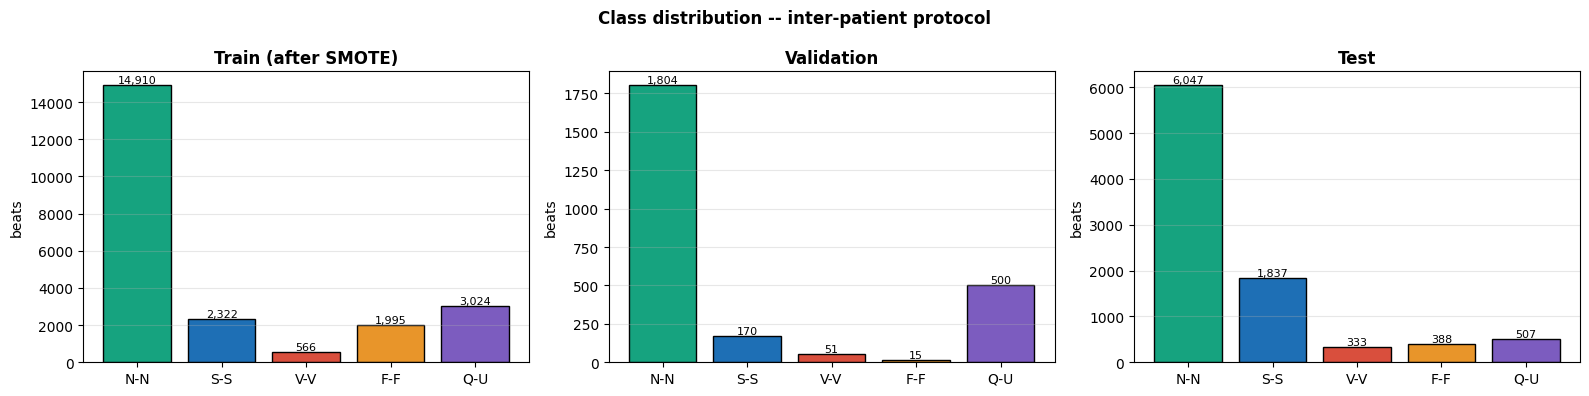

In [37]:
# ── class distribution figure ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = ['#16a37f','#1e6fb5','#d94f3d','#e8952a','#7c5cbf','#e83d4d'][:NUM_CLASSES]
for ax, (yy, title) in zip(axes, [(y_tr, 'Train (after SMOTE)'),
                                  (y_val, 'Validation'), (y_test, 'Test')]):
    c = np.bincount(yy, minlength=NUM_CLASSES)
    ax.bar(range(NUM_CLASSES), c, color=palette, edgecolor='black', lw=1)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels([n[:3] for n in CLASS_NAMES], rotation=0)
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('beats'); ax.grid(axis='y', alpha=.3)
    for i, v in enumerate(c):
        ax.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=8)
plt.suptitle(f'Class distribution -- {PROTOCOL}-patient protocol', fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig('00_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 5 — Model definitions

In [38]:
# ============================================================
# SECTION 5: Architectures
# ============================================================

def rr_branch(pooled, rr_in, tag='rr'):
    """Fuse the auxiliary feature vector (Experiment C's 23 RR/QRS/morphology features,
    Section 1C -- plus, if RUN_FUSION_FEATURES, the 9 N/V template-fusion features from
    Section 1D/4A0, making it 32 by default) into a pooled CNN/BiLSTM/Transformer vector.

    Kept small relative to the CNN branch (48 units, up from 32 for the original
    4-feature version): the features are already the right quantities (QRS duration,
    P-wave presence/timing, RR prematurity, ...), so the network mostly has to learn a
    decision surface over them, not to discover them. Values arrive pre-scaled
    (Section 4A2, median/IQR on train only) so BatchNorm here is normalizing
    activations, not compensating for wildly different raw feature magnitudes."""
    r = L.Dense(48, activation='relu', name=f'{tag}_dense')(rr_in)
    r = L.BatchNormalization(name=f'{tag}_bn')(r)
    return L.Concatenate(name=f'{tag}_concat')([pooled, r])


def build_hybrid_model(input_shape=(BEAT_LENGTH, 1), num_classes=NUM_CLASSES,
                       use_rr=None, n_rr=None):
    """1D-CNN(64->128->256) -> BiLSTM(128) -> attention pooling -> dense head.

    The attention block is ADDITIVE (Bahdanau-style) single-head temporal pooling:
    it produces T scalar weights, cost O(T*d). It is NOT Transformer scaled dot-product
    self-attention, which builds a T x T interaction matrix at cost O(T^2*d).

    `n_rr` overrides the global N_RR for this call only (Section 9D's fusion-feature
    ablation builds several models against different auxiliary-feature widths without
    touching the global N_RR that the rest of the notebook, e.g. Section 11/12, relies on).
    """
    use_rr = USE_RR if use_rr is None else use_rr
    n_rr = N_RR if n_rr is None else n_rr
    att_steps = input_shape[0] // 8                     # 3 pooling stages: 360 -> 45
    inputs = Input(shape=input_shape, name='ecg_input')
    rr_in = L.Input(shape=(n_rr,),name='rr_input') if use_rr else None

    x = L.Conv1D(64, 3, padding='same', use_bias=False, name='conv1')(inputs)
    x = L.BatchNormalization(name='bn1')(x)
    x = L.Activation('relu', name='act1')(x)
    x = L.MaxPooling1D(2, name='pool1')(x)              # 180

    x = L.Conv1D(128, 3, padding='same', use_bias=False, name='conv2')(x)
    x = L.BatchNormalization(name='bn2')(x)
    x = L.Activation('relu', name='act2')(x)
    x = L.MaxPooling1D(2, name='pool2')(x)              # 90

    x = L.Conv1D(256, 3, padding='same', use_bias=False, name='conv3')(x)
    x = L.BatchNormalization(name='bn3')(x)
    x = L.Activation('relu', name='act3')(x)            # <- Grad-CAM taps here
    x = L.MaxPooling1D(2, name='pool3')(x)              # 45

    x = L.Bidirectional(L.LSTM(128, return_sequences=True), name='bilstm')(x)

    score   = L.Dense(1, activation='tanh', name='att_score')(x)
    score   = L.Flatten(name='att_flatten')(score)
    weights = L.Activation('softmax', name='att_weights')(score)      # <- inspectable
    weights = L.Reshape((att_steps, 1), name='att_reshape')(weights)
    context = L.Multiply(name='att_multiply')([x, weights])
    context = L.GlobalAveragePooling1D(name='context')(context)

    if use_rr:
        context = rr_branch(context, rr_in)

    x   = L.Dense(128, activation='relu', name='dense1')(context)
    x   = L.Dropout(0.3, name='drop1')(x)
    x   = L.Dense(64, activation='relu', name='dense2')(x)
    x   = L.Dropout(0.2, name='drop2')(x)
    out = L.Dense(num_classes, activation='softmax', name='output')(x)
    return Model([inputs, rr_in] if use_rr else inputs, out,
                 name='CNN_BiLSTM_Attention')


def build_cnn_only(input_shape=(BEAT_LENGTH, 1), num_classes=NUM_CLASSES, use_rr=None):
    """Ablation arm 1: convolutional stem + GAP. No temporal context."""
    use_rr = USE_RR if use_rr is None else use_rr
    inp = Input(shape=input_shape)
    rr_in = Input(shape=(N_RR,), name='rr_input') if use_rr else None
    x = inp
    for f in (64, 128, 256):
        x = L.Conv1D(f, 3, padding='same', use_bias=False)(x)
        x = L.BatchNormalization()(x); x = L.Activation('relu')(x); x = L.MaxPooling1D(2)(x)
    x = L.GlobalAveragePooling1D()(x)
    if use_rr:
        x = rr_branch(x, rr_in)
    x = L.Dense(128, activation='relu')(x); x = L.Dropout(0.3)(x)
    return Model([inp, rr_in] if use_rr else inp,
                 L.Dense(num_classes, activation='softmax')(x), name='CNN_only')


def build_cnn_bilstm(input_shape=(BEAT_LENGTH, 1), num_classes=NUM_CLASSES, use_rr=None):
    """Ablation arm 2: + BiLSTM, no attention (last hidden state)."""
    use_rr = USE_RR if use_rr is None else use_rr
    inp = Input(shape=input_shape)
    rr_in = Input(shape=(N_RR,), name='rr_input') if use_rr else None
    x = inp
    for f in (64, 128, 256):
        x = L.Conv1D(f, 3, padding='same', use_bias=False)(x)
        x = L.BatchNormalization()(x); x = L.Activation('relu')(x); x = L.MaxPooling1D(2)(x)
    x = L.Bidirectional(L.LSTM(128, return_sequences=False))(x)
    if use_rr:
        x = rr_branch(x, rr_in)
    x = L.Dense(128, activation='relu')(x); x = L.Dropout(0.3)(x)
    return Model([inp, rr_in] if use_rr else inp,
                 L.Dense(num_classes, activation='softmax')(x), name='CNN_BiLSTM')


def build_mcu_model(input_shape=(BEAT_LENGTH, 1), num_classes=NUM_CLASSES):
    """MCU-friendly variant. Conv1D + SeparableConv1D + GAP only -- no recurrence and no
    Multiply-broadcast, so the TFLite op set stays inside TFLite Micro's builtins and the
    model INT8-quantises cleanly. The wide separable convs replace the BiLSTM's long
    receptive field without sequential state.

    SINGLE-INPUT on purpose: the INT8 converter, the representative-dataset generator
    and the operator audit in Section 12 all assume one input tensor. Its accuracy is
    therefore NOT comparable with the RR-equipped research models -- say so when the
    numbers are quoted side by side."""
    inp = Input(shape=input_shape, name='ecg_input')
    x = L.Conv1D(16, 7, padding='same', use_bias=False)(inp)
    x = L.BatchNormalization()(x); x = L.ReLU()(x); x = L.MaxPooling1D(2)(x)      # 180
    x = L.Conv1D(32, 5, padding='same', use_bias=False)(x)
    x = L.BatchNormalization()(x); x = L.ReLU()(x); x = L.MaxPooling1D(2)(x)      # 90
    x = L.SeparableConv1D(48, 5, padding='same', use_bias=False)(x)
    x = L.BatchNormalization()(x); x = L.ReLU()(x); x = L.MaxPooling1D(2)(x)      # 45
    x = L.SeparableConv1D(64, 5, padding='same', use_bias=False)(x)
    x = L.BatchNormalization()(x); x = L.ReLU()(x); x = L.MaxPooling1D(2)(x)      # 22
    x = L.GlobalAveragePooling1D()(x)
    x = L.Dense(48, activation='relu')(x); x = L.Dropout(0.3)(x)
    return Model(inp, L.Dense(num_classes, activation='softmax', name='output')(x), name='ECG_MCU')


def count_macs_hybrid(T=BEAT_LENGTH, d_h=128):
    """Analytic MAC count per beat (for the complexity table in the thesis)."""
    conv = T*3*1*64 + (T//2)*3*64*128 + (T//4)*3*128*256
    lstm = 2 * (T//8) * 4 * (256*d_h + d_h*d_h + d_h)
    head = (T//8)*256 + 256*128 + 128*64 + 64*NUM_CLASSES
    return conv, lstm, head, conv + lstm + head

print("model builders defined")

def mk_in(X, RR):
    """
    Construct inputs for the CNN-BiLSTM-Attention hybrid.

    ECG:
        (N, BEAT_LENGTH, 1)

    Auxiliary features:
        (N, N_RR)
    """

    X = np.asarray(X, dtype=np.float32)
    RR = np.asarray(RR, dtype=np.float32)

    assert X.ndim == 3, (f"ECG input must be 3-D, got {X.shape}")

    assert X.shape[1:] == (BEAT_LENGTH,1), (f"ECG shape {X.shape}; " f"expected (N, {BEAT_LENGTH}, 1)")

    if USE_RR:

        assert RR.ndim == 2, (f"RR input must be 2-D, got {RR.shape}")

        assert RR.shape[1] == N_RR, ( f"RR width {RR.shape[1]} != " f"N_RR {N_RR}")

        return {'ecg_input': X, 'rr_input': RR}

    return X

model builders defined


## Section 5C — F-vs-N / F-vs-V auxiliary loss heads (Improvement 6)

In [ ]:
# ============================================================
# SECTION 5C: IMPROVEMENT 6 -- F-vs-N / F-vs-V AUXILIARY LOSS HEADS
# ============================================================
# Extends a trained model WITHOUT replacing it. The reported model (the
# single-softmax Model built by build_hybrid_model or build_msft_net) stays
# exactly as every downstream cell (Sections 6-13: evaluation, Grad-CAM, MCU
# quantisation, robustness sweeps) already expects it.
# build_f_aux_train_model() below builds a SECOND Model object on the SAME
# layers (Keras functional API: reusing a layer tensor does not copy weights,
# it shares them) -- so fitting the returned model updates the original
# model's weights too, and every other cell that calls model.predict(...)
# keeps working unmodified. Two small Dense(1, 'sigmoid') heads tapping the
# existing penultimate representation, nothing else in the architecture
# changes.
#
# CHANGED (F-improvement pass): the function used to be hard-wired to the
# hybrid's 'dense2' layer, which meant it could not be applied to MSFT-Net at
# all -- and in the previous notebook it was never called by anything, so the
# reported model was trained WITHOUT these losses despite ENABLE_F_AUX_LOSS
# being True. It now takes the shared layer, the main output name, the main
# loss, the auxiliary loss and the learning rate as arguments, and Section 6D
# actually calls it.


def build_f_aux_train_model(model, f_idx, n_idx, v_idx,
                            lambda_fn=LAMBDA_F_N, lambda_fv=LAMBDA_F_V,
                            shared_layer=None, main_output_name=None,
                            aux_loss='binary_crossentropy', main_loss=None,
                            learning_rate=None, metrics=None):
    """Adds f_vs_n_head / f_vs_v_head on top of `model`'s shared penultimate
    representation. Returns a NEW Model with three outputs:
    [<main>, 'f_vs_n_head', 'f_vs_v_head']. `model` itself is unchanged (same
    object, not rebuilt) and its weights are updated by training the returned
    model, since both share the same underlying Keras layers -- two small
    extra heads' worth of new parameters (2 * (64 + 1) = 130), not a second
    network.

    shared_layer      name of the layer feeding the classifier head.
                      Defaults to 'dense2' (hybrid) or 'head_dropout'
                      (MSFT-Net), auto-detected from what the model has.
    main_output_name  name of the existing softmax layer ('output' for the
                      hybrid, 'predictions' for MSFT-Net); used only for the
                      loss/loss_weights dictionaries.
    aux_loss          loss for both binary heads. Section 6D passes a masked
                      BCE so S/Q beats contribute nothing even if per-output
                      sample weights are unavailable.

    total_loss = main_loss + lambda_fn * loss_f_vs_n + lambda_fv * loss_f_vs_v
    is expressed via Keras's per-output `loss_weights`, which is
    mathematically identical to summing the losses manually and lets Keras
    report each component separately during training.
    """
    _names = {l.name for l in model.layers}
    if shared_layer is None:
        shared_layer = next((c for c in ('dense2', 'head_dropout', 'head_dense')
                             if c in _names), None)
        if shared_layer is None:
            raise ValueError("could not auto-detect the shared representation layer; "
                             "pass shared_layer=... explicitly")
    if main_output_name is None:
        main_output_name = next((c for c in ('output', 'predictions') if c in _names),
                                model.layers[-1].name)

    shared = model.get_layer(shared_layer).output      # (batch, 64)
    f_vs_n = L.Dense(1, activation='sigmoid', name='f_vs_n_head')(shared)
    f_vs_v = L.Dense(1, activation='sigmoid', name='f_vs_v_head')(shared)
    train_model = Model(model.inputs, [model.output, f_vs_n, f_vs_v],
                        name=f'{model.name}_with_f_aux')

    main_loss = LOSS_FN if main_loss is None else main_loss
    learning_rate = LEARNING_RATE if learning_rate is None else learning_rate
    if metrics is None:
        metrics = ['accuracy', keras.metrics.F1Score(average='macro', name='macro_f1')]

    # FIX (multi-output structure): this model's outputs are a LIST, so loss,
    # loss_weights and metrics are given as LISTS in output order. Dict-keyed
    # arguments against a list-structured output are what produced
    #   ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list
    #               of length 0 less than minimum 1
    # at the first training step -- see the note in Section 5D.
    train_model.compile(
        optimizer=Adam(learning_rate),
        loss=[main_loss, aux_loss, aux_loss],
        loss_weights=[1.0, lambda_fn, lambda_fv],
        metrics=[metrics, [], []])
    train_model.aux_output_order = [main_output_name, 'f_vs_n_head', 'f_vs_v_head']
    return train_model


def make_f_aux_targets(y_int, f_idx, n_idx, v_idx):
    """Improvement 6C: binary targets + per-sample weights for each auxiliary
    head. F = positive, N (or V) = negative; every OTHER class (S, Q/CHF) is
    masked out via a zero sample_weight rather than silently folded into
    the negative class -- Requirement 6C explicitly forbids assigning S/Q
    samples as N or V, and an unmasked BCE would do exactly that by treating
    "not F" as automatically "is N"/"is V"."""
    y_int = np.asarray(y_int)
    y_fn = (y_int == f_idx).astype(np.float32)
    w_fn = np.isin(y_int, [f_idx, n_idx]).astype(np.float32)
    y_fv = (y_int == f_idx).astype(np.float32)
    w_fv = np.isin(y_int, [f_idx, v_idx]).astype(np.float32)
    return y_fn, w_fn, y_fv, w_fv


print("Section 5C functions defined: build_f_aux_train_model, make_f_aux_targets "
      f"(lambda_f_n={LAMBDA_F_N}, lambda_f_v={LAMBDA_F_V}) -- called from Section 6D")

## Section 5D — Q-vs-Others auxiliary head (Change 3)

`build_f_aux_train_model` (Section 5C) is *generalised* rather than duplicated:
`build_aux_train_model` below builds any subset of `{f_vs_n_head, f_vs_v_head,
q_vs_rest_head}` on the same shared representation, and Section 5C's function is
rebound to a thin wrapper over it so every existing call site keeps working.

Unlike F-vs-N and F-vs-V, Q-vs-Others is a genuine one-vs-rest task, so **no beat is
masked out** — all five classes contribute, and the head uses a plain
`binary_crossentropy` rather than the masked BCE the F heads need.

One honest caveat, recorded here because it constrains what this head can do: at
stage 1 the model already fits the training partition to 1.000 accuracy, so the
Q-vs-Others logit is already separable on every training beat and the gradient this
head contributes is close to zero. It is included and measured (arm A3) because it
costs 65 parameters, not because the notebook's numbers predict it will move Q.


In [ ]:
# ============================================================
# SECTION 5D: CHANGE 3 -- Q-vs-OTHERS AUXILIARY HEAD
# ============================================================
# Section 5's import block does not pull these four in; every cell added by the
# Q pass needs them, so they are imported once here rather than in each cell.
from sklearn.metrics import (recall_score, precision_score, matthews_corrcoef,
                             cohen_kappa_score)

# Generalises Section 5C. build_f_aux_train_model is rebound at the bottom of
# this cell so nothing that already calls it has to change.


def build_aux_train_model(model, f_idx=None, n_idx=None, v_idx=None, q_idx=None,
                          lambda_fn=None, lambda_fv=None, lambda_q=None,
                          shared_layer=None, main_output_name=None,
                          aux_loss='binary_crossentropy',
                          q_aux_loss='binary_crossentropy',
                          main_loss=None, learning_rate=None, metrics=None,
                          use_f_heads=True, use_q_head=None):
    """Multi-output TRAINING view of `model`, sharing its layers.

    Outputs, in order: [<main softmax>, 'f_vs_n_head', 'f_vs_v_head',
    'q_vs_rest_head'] -- the F heads only if use_f_heads, the Q head only if
    use_q_head. `model` itself is untouched and still has a single 5-class
    softmax output, so Sections 7-13 (evaluation, Grad-CAM, TFLite/INT8,
    robustness) consume it unchanged; fitting the returned object updates
    `model`'s weights because both reference the same Keras layer objects.

        L = L_5class + lambda_fn*L_(F/N) + lambda_fv*L_(F/V) + lambda_q*L_(Q/rest)

    expressed through Keras's per-output `loss_weights`.
    """
    lambda_fn = LAMBDA_F_N if lambda_fn is None else lambda_fn
    lambda_fv = LAMBDA_F_V if lambda_fv is None else lambda_fv
    lambda_q  = globals().get('LAMBDA_Q', 0.15) if lambda_q is None else lambda_q
    use_q_head = (globals().get('ENABLE_Q_AUX_LOSS', False) and q_idx is not None) \
        if use_q_head is None else use_q_head

    _names = {l.name for l in model.layers}
    if shared_layer is None:
        shared_layer = next((c for c in ('dense2', 'head_dropout', 'head_dense')
                             if c in _names), None)
        if shared_layer is None:
            raise ValueError("could not auto-detect the shared representation layer; "
                             "pass shared_layer=... explicitly")
    if main_output_name is None:
        main_output_name = next((c for c in ('output', 'predictions') if c in _names),
                                model.layers[-1].name)

    shared = model.get_layer(shared_layer).output

    # FIX (multi-output structure). The model is built with a LIST of outputs,
    # so loss / loss_weights / metrics are built as parallel LISTS in exactly
    # that order rather than as name-keyed dicts. Under Keras 3 a dict-keyed
    # target or sample_weight matched against list-structured outputs resolves
    # to nothing: the compiled loss never registers, train_step returns an
    # empty logs dict, and tf.experimental.Optional.from_value({}) raises
    #   ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list
    #               of length 0 less than minimum 1
    # on the first step of the first epoch. The matching symptom on the
    # sample_weight side is `KeyError: 0` -- Keras indexing a dict positionally.
    outputs      = [model.output]
    output_order = [main_output_name]
    losses       = [LOSS_FN if main_loss is None else main_loss]
    weights      = [1.0]

    if use_f_heads:
        outputs.append(L.Dense(1, activation='sigmoid', name='f_vs_n_head')(shared))
        outputs.append(L.Dense(1, activation='sigmoid', name='f_vs_v_head')(shared))
        output_order += ['f_vs_n_head', 'f_vs_v_head']
        losses  += [aux_loss, aux_loss]
        weights += [lambda_fn, lambda_fv]
    if use_q_head:
        outputs.append(L.Dense(1, activation='sigmoid', name='q_vs_rest_head')(shared))
        output_order.append('q_vs_rest_head')
        losses.append(q_aux_loss)          # true one-vs-rest: NOT masked
        weights.append(lambda_q)

    train_model = Model(model.inputs, outputs, name=f'{model.name}_with_aux')
    learning_rate = LEARNING_RATE if learning_rate is None else learning_rate
    if metrics is None:
        metrics = ['accuracy', keras.metrics.F1Score(average='macro', name='macro_f1')]

    # metrics on the main output only; [] for the auxiliary heads. A handful of
    # Keras builds reject the nested-list form, so fall back to the name-keyed
    # form for metrics ONLY (metrics never participate in the structure match
    # that caused the failure above).
    try:
        train_model.compile(optimizer=Adam(learning_rate), loss=losses,
                            loss_weights=weights,
                            metrics=[metrics] + [[] for _ in output_order[1:]])
    except (TypeError, ValueError):
        train_model.compile(optimizer=Adam(learning_rate), loss=losses,
                            loss_weights=weights,
                            metrics={main_output_name: metrics})

    # callers build their target/sample-weight lists from this
    train_model.aux_output_order = output_order
    return train_model


def aux_output_order(train_model, fallback=None):
    """Output order of a multi-output training model, as a list of names.

    Prefers the order recorded by build_aux_train_model, falls back to the
    model's own output_names (a ListWrapper, so it is copied to a plain list).
    """
    order = getattr(train_model, 'aux_output_order', None)
    if not order:
        order = list(getattr(train_model, 'output_names', None) or (fallback or []))
    return list(order)


def stack_targets(order, mapping):
    """Dict {output_name: array} -> list in `order`. Raises rather than
    silently dropping an output, which is what a mismatched structure does."""
    missing = [k for k in order if k not in mapping]
    if missing:
        raise KeyError(f"no target supplied for output(s) {missing}; "
                       f"model outputs are {order}")
    return [mapping[k] for k in order]


def fit_multi_output(train_model, x, y_map, order, epochs, batch_size,
                     validation_data=None, sample_weight_map=None,
                     callbacks_fn=None, verbose=1, probe_n=8):
    """Fit a multi-output training model, choosing the target/sample_weight
    structure this Keras build actually accepts.

    Why this exists: Keras 3 accepts LIST-structured targets against a
    list-structured model reliably, and dict-structured targets only in some
    builds. Rather than assume, this probes a few structures on `probe_n`
    samples for one step, restores the weights, and then runs the real fit with
    the first structure that worked. It also reads the real per-output metric
    name out of the probe's history, so the EarlyStopping monitor key is
    correct instead of being a guess like 'val_predictions_macro_f1' that
    silently never fires when it is wrong.

    y_map / sample_weight_map are {output_name: array} dicts; `order` is the
    model's output order. Returns (history, info_dict).
    """
    y_list = stack_targets(order, y_map)
    sw_list = None if sample_weight_map is None else stack_targets(order, sample_weight_map)

    candidates = []
    if sw_list is not None:
        candidates.append(('list targets + list sample_weight', y_list, sw_list))
    candidates.append(('list targets, no sample_weight', y_list, None))
    if sw_list is not None:
        candidates.append(('dict targets + dict sample_weight', y_map, sample_weight_map))
    candidates.append(('dict targets, no sample_weight', y_map, None))

    n = min(int(probe_n), len(y_list[0]))
    sl = slice(0, n)
    x_probe = (tuple(v[sl] for v in x) if isinstance(x, (list, tuple))
               else {k: v[sl] for k, v in x.items()} if isinstance(x, dict)
               else x[sl])

    saved = [w.copy() for w in train_model.get_weights()]
    chosen, probe_hist, errors = None, None, []
    for label, yy, ww in candidates:
        try:
            h = train_model.fit(
                x_probe,
                [v[sl] for v in yy] if isinstance(yy, list) else {k: v[sl] for k, v in yy.items()},
                sample_weight=(None if ww is None else
                               ([v[sl] for v in ww] if isinstance(ww, list)
                                else {k: v[sl] for k, v in ww.items()})),
                epochs=1, batch_size=n, verbose=0)
            chosen, probe_hist = (label, yy, ww), h
            break
        except Exception as e:
            errors.append(f"    {label}: {type(e).__name__}: {str(e)[:110]}")
    train_model.set_weights(saved)
    del saved

    if chosen is None:
        raise RuntimeError("no target/sample_weight structure was accepted by this "
                           "Keras build:\n" + "\n".join(errors))

    label, yy, ww = chosen
    for line in errors:
        print("  probe rejected:\n" + line)
    print(f"  probe accepted: {label}")
    if ww is None and sample_weight_map is not None:
        print("  NOTE: per-output sample weights are NOT applied in this stage "
              "(masked targets still exclude the ignored beats; the hard-negative "
              "emphasis from the mining stage is not re-applied). Report this.")

    # real metric key, read from the probe rather than assumed
    keys = list(probe_hist.history.keys())
    monitor = next((k for k in keys if k.endswith('macro_f1')), None)
    monitor = f'val_{monitor}' if monitor else 'val_loss'
    mode = 'max' if monitor.endswith('macro_f1') else 'min'
    print(f"  training-metric keys: {keys}")
    print(f"  EarlyStopping monitor -> {monitor} (mode={mode})")

    if validation_data is not None:
        x_val, yval_map = validation_data[0], validation_data[1]
        yv = (stack_targets(order, yval_map) if isinstance(yy, list) else yval_map)
        validation_data = (x_val, yv)

    cbs = callbacks_fn(monitor, mode) if callbacks_fn is not None else None
    history = train_model.fit(x, yy, sample_weight=ww,
                              validation_data=validation_data,
                              epochs=epochs, batch_size=batch_size,
                              callbacks=cbs, verbose=verbose)
    return history, {'structure': label, 'monitor': monitor, 'mode': mode,
                     'sample_weight_applied': ww is not None}


def masked_bce(y_true, y_pred):
    """Binary cross-entropy over the UNMASKED beats only: y_true carries -1.0
    for every beat that must not contribute (S/Q for the F heads, and whichever
    of N/V a given head does not judge). Section 6D defines an identical
    function inside its own cell; it is hoisted here so Sections 6D2 and 9Q can
    use it whether or not Section 6D ran."""
    y_true = tf.cast(y_true, tf.float32)
    mask = tf.cast(tf.greater_equal(y_true, 0.0), tf.float32)
    y_safe = tf.clip_by_value(y_true, 0.0, 1.0)
    p = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)
    bce = -(y_safe * tf.math.log(p) + (1.0 - y_safe) * tf.math.log(1.0 - p))
    bce = tf.reduce_sum(bce * mask, axis=-1)
    return bce / tf.maximum(tf.reduce_sum(mask, axis=-1), 1.0)


def make_f_aux_targets_masked(y_int, f_idx, n_idx, v_idx):
    """make_f_aux_targets (Section 5C) with the ignored beats folded into the
    target as -1 so masked_bce can drop them. Hoisted from Section 6D for the
    same reason as masked_bce."""
    y_fn, w_fn, y_fv, w_fv = make_f_aux_targets(y_int, f_idx, n_idx, v_idx)
    y_fn_m = np.where(w_fn > 0, y_fn, -1.0).astype(np.float32).reshape(-1, 1)
    y_fv_m = np.where(w_fv > 0, y_fv, -1.0).astype(np.float32).reshape(-1, 1)
    return y_fn_m, w_fn.astype(np.float32), y_fv_m, w_fv.astype(np.float32)


def make_q_aux_targets(y_int, q_idx):
    """Change 3: one-vs-rest targets for the Q head.

        Q -> 1.0,  N/S/V/F -> 0.0

    Every beat contributes (weight 1.0), which is the difference from
    make_f_aux_targets: F-vs-N and F-vs-V are two-class comparisons where a
    third class has no defined label, whereas 'is this beat Q' is defined for
    every beat in the dataset. Returns (y_q, w_q), each shaped (n, 1)/(n,).
    """
    y_int = np.asarray(y_int).astype(int)
    y_q = (y_int == q_idx).astype(np.float32).reshape(-1, 1)
    w_q = np.ones(len(y_int), dtype=np.float32)
    return y_q, w_q


def build_f_aux_train_model(model, f_idx, n_idx, v_idx,
                            lambda_fn=None, lambda_fv=None,
                            shared_layer=None, main_output_name=None,
                            aux_loss='binary_crossentropy', main_loss=None,
                            learning_rate=None, metrics=None):
    """Backwards-compatible wrapper -- Section 5C's original signature, now a
    thin call into build_aux_train_model with the Q head switched off."""
    return build_aux_train_model(
        model, f_idx=f_idx, n_idx=n_idx, v_idx=v_idx, q_idx=None,
        lambda_fn=lambda_fn, lambda_fv=lambda_fv,
        shared_layer=shared_layer, main_output_name=main_output_name,
        aux_loss=aux_loss, main_loss=main_loss, learning_rate=learning_rate,
        metrics=metrics, use_f_heads=True, use_q_head=False)


_q_probe_idx = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('Q')), None)
if _q_probe_idx is not None:
    _yq, _wq = make_q_aux_targets(np.array([0, 1, 2, 3, _q_probe_idx]), _q_probe_idx)
    assert _yq.shape == (5, 1) and _yq.ravel().tolist() == [0, 0, 0, 0, 1]
    assert _wq.shape == (5,) and (_wq == 1).all()
    del _yq, _wq

print("Section 5D defined: build_aux_train_model, aux_output_order, stack_targets, "
      "fit_multi_output, make_q_aux_targets; build_f_aux_train_model rebound as a wrapper "
      f"(lambda_F/N={LAMBDA_F_N}, lambda_F/V={LAMBDA_F_V}, lambda_Q={LAMBDA_Q}) "
      "-- self-test passed")

## Section 5B — MSFT-Net: Multi-Scale, SE, FiLM-conditioned, Temporal-pooled Network

Replaces the CNN-Transformer Gated Fusion architecture as the second model trained and compared against the CNN-BiLSTM-Attention hybrid.

In [41]:
# A drop-in replacement for build_hybrid_model() (Section 5). Same call
# signature (input_shape, num_classes, use_rr, n_rr), same expected globals
# (BEAT_LENGTH, NUM_CLASSES, N_RR, USE_RR), so it plugs into Section 6B's
# training loop and Section 7/7B/8/9's evaluation/statistics/ablation cells.
#
# This replaces the CNN-Transformer Gated Fusion architecture as the second
# model trained and compared against the CNN-BiLSTM-Attention hybrid.
# HONEST CAVEAT: this architecture has not been benchmarked against your data
# before this run. It is a principled design responding to failure modes this
# notebook already diagnosed (late RR fusion, param count vs. inter-patient
# generalisation), not a result. Let Sections 7-9 produce the actual
# accuracy/macro-F1/McNemar numbers before writing this up as an improvement
# over the hybrid.
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from tensorflow.keras import Model, Input


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from tensorflow.keras import Model, Input


@keras.utils.register_keras_serializable(package='msft_net')
class SumOverTime(L.Layer):
    """
    Sums a (batch, T, C) tensor over the time axis.
    Registered as a real Keras Layer so .keras checkpoints
    can be saved and restored.
    """

    def call(self, x):
        return tf.reduce_sum(x, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])


def se_block(x, ratio=8, name=None):
    """Squeeze-and-Excitation: cheap global-context channel gating.
    ~2*(C^2/ratio) extra weights per block, well-established to improve
    ECG-CNN discrimination between morphologically similar minority classes."""
    ch = x.shape[-1]
    s = L.GlobalAveragePooling1D(name=f'{name}_gap' if name else None)(x)
    s = L.Dense(max(ch // ratio, 4), activation='relu',
                name=f'{name}_se_fc1' if name else None)(s)
    s = L.Dense(ch, activation='sigmoid', name=f'{name}_se_fc2' if name else None)(s)
    s = L.Reshape((1, ch), name=f'{name}_se_reshape' if name else None)(s)
    return L.Multiply(name=f'{name}_se_scale' if name else None)([x, s])


def ds_conv_block(x, filters, kernel_size, stride=1, name=None):
    """Depthwise-separable Conv1D (depthwise conv + pointwise 1x1) + BN + ReLU.
    Substantially fewer params/MACs than a standard Conv1D at the same
    (Cin, Cout, k) -- e.g. k=11, Cin=64, Cout=64: standard conv is
    64*64*11 ~= 45k weights/step; depthwise+pointwise is 64*11 + 64*64 ~= 4.8k,
    roughly a 9x reduction at that width."""
    x = L.SeparableConv1D(filters, kernel_size, strides=stride, padding='same',
                           use_bias=False, name=f'{name}_sep' if name else None)(x)
    x = L.BatchNormalization(name=f'{name}_bn' if name else None)(x)
    x = L.Activation('relu', name=f'{name}_act' if name else None)(x)
    return x


def multiscale_stem(x, filters=32, name='stem'):
    """Three parallel depthwise-separable branches (kernel 5/11/21 ~= 14/31/58 ms
    at 360 Hz) capture QRS-width-scale, P/T-wave-scale, and whole-beat-scale
    morphology in parallel, fused by a 1x1 conv -- cheaper than one wide-kernel
    conv spanning the same receptive-field range at full channel width."""
    b1 = ds_conv_block(x, filters, 5, name=f'{name}_k5')
    b2 = ds_conv_block(x, filters, 11, name=f'{name}_k11')
    b3 = ds_conv_block(x, filters, 21, name=f'{name}_k21')
    x = L.Concatenate(name=f'{name}_concat')([b1, b2, b3])
    x = L.Conv1D(filters * 2, 1, use_bias=False, name=f'{name}_fuse')(x)
    x = L.BatchNormalization(name=f'{name}_fuse_bn')(x)
    x = L.Activation('relu', name=f'{name}_fuse_act')(x)
    return x


def film_generator(rr_in, n_channels, name):
    """Two-layer MLP mapping the clinical (RR + morphology + fusion-template)
    feature vector to a (gamma, beta) pair for FiLM-conditioning one residual
    stage. Zero-initialised final layers with gamma's bias initialised to 1 and
    beta's to 0, so the block starts as an exact identity modulation: training
    can only move away from "ignore this vector" if it actually helps that
    stage's loss, never start out hurting it."""
    h = L.Dense(32, activation='relu', name=f'{name}_film_h')(rr_in)
    gamma = L.Dense(n_channels, activation='linear',
                     kernel_initializer='zeros', bias_initializer='ones',
                     name=f'{name}_film_gamma')(h)
    beta = L.Dense(n_channels, activation='linear',
                    kernel_initializer='zeros', bias_initializer='zeros',
                    name=f'{name}_film_beta')(h)
    return gamma, beta


def film_apply(x, gamma, beta, name):
    g = L.Reshape((1, -1), name=f'{name}_film_g_reshape')(gamma)
    b = L.Reshape((1, -1), name=f'{name}_film_b_reshape')(beta)
    x = L.Multiply(name=f'{name}_film_mul')([x, g])
    x = L.Add(name=f'{name}_film_add')([x, b])
    return x


def residual_se_ds_stage(x, filters, stride, name, rr_in=None):
    """Depthwise-separable residual block: two SeparableConv1D layers, a
    FiLM conditioning point (if rr_in is given) right before the SE gate, then
    SE channel attention, then a residual add with a 1x1-projected shortcut."""
    shortcut = x
    if stride != 1 or x.shape[-1] != filters:
        shortcut = L.Conv1D(filters, 1, strides=stride, use_bias=False,
                             name=f'{name}_proj')(x)
        shortcut = L.BatchNormalization(name=f'{name}_proj_bn')(shortcut)

    h = ds_conv_block(x, filters, 7, stride=stride, name=f'{name}_c1')
    h = L.SeparableConv1D(filters, 7, padding='same', use_bias=False,
                           name=f'{name}_c2_sep')(h)
    h = L.BatchNormalization(name=f'{name}_c2_bn')(h)

    if rr_in is not None:
        gamma, beta = film_generator(rr_in, filters, name)
        h = film_apply(h, gamma, beta, name)

    h = se_block(h, name=f'{name}_se')
    h = L.Add(name=f'{name}_res_add')([shortcut, h])
    h = L.Activation('relu', name=f'{name}_res_act')(h)
    return h


def efficient_attention_pool(x, name='att_pool'):
    """Additive (Bahdanau-style) attention pooling -- the same mechanism and
    cost, O(T*d), as the pooling already used in build_hybrid_model (Section 5).
    Not Transformer self-attention (O(T^2*d)); kept identical on purpose so
    the difference between this model and the hybrid is isolated to the
    backbone (multi-scale + SE + FiLM vs. plain CNN + BiLSTM), not the pooling."""
    scores = L.Dense(1, name=f'{name}_score')(x)
    scores = L.Flatten(name=f'{name}_score_flat')(scores)
    weights = L.Activation('softmax', name=f'{name}_weights')(scores)
    weights_r = L.Reshape((-1, 1), name=f'{name}_weights_reshape')(weights)
    pooled = L.Multiply(name=f'{name}_weighted')([x, weights_r])
    pooled = SumOverTime(name=f'{name}_sum')(pooled)
    return pooled


def build_msft_net(input_shape=None, num_classes=None, use_rr=None, n_rr=None,
                    width=32, beat_length=None):
    """Build MSFT-Net. Reads BEAT_LENGTH / NUM_CLASSES / N_RR / USE_RR from the
    notebook's globals if not passed explicitly, matching build_hybrid_model's
    calling convention so it can replace it or run alongside it.

    width: base channel width of the stem (default 32 -> stages end at
    64/128/128 channels, vs. the hybrid's 64/128/256 dense-conv stack).
    Lower than the hybrid on purpose -- depthwise-separable convs plus SE
    recover most of the lost capacity per parameter.
    """
    global BEAT_LENGTH, NUM_CLASSES, N_RR, USE_RR
    beat_length = beat_length or BEAT_LENGTH
    input_shape = input_shape or (beat_length, 1)
    num_classes = num_classes or NUM_CLASSES
    use_rr = USE_RR if use_rr is None else use_rr
    n_rr = N_RR if n_rr is None else n_rr

    sig_in = Input(shape=input_shape, name='signal_input')
    rr_in = Input(shape=(n_rr,), name='rr_input') if use_rr else None

    x = multiscale_stem(sig_in, filters=width, name='stem')            # T, 2*width

    x = residual_se_ds_stage(x, width * 2, stride=2, name='stage1', rr_in=rr_in)  # T/2
    x = residual_se_ds_stage(x, width * 4, stride=2, name='stage2', rr_in=rr_in)  # T/4
    x = residual_se_ds_stage(x, width * 4, stride=2, name='stage3', rr_in=rr_in)  # T/8

    # CHANGE 1: temporal attention pooling -> GlobalAveragePooling1D.
    # Attention pooling learns WHICH tokens to read, and on this data it learns to
    # read the tokens that separate the majority classes -- the sharp V-like QRS
    # peak -- which is exactly the part of an F beat that looks ventricular. GAP
    # keeps every token, so the N-like shoulders of a fusion beat still reach the
    # classifier. MSFT_POOLING='attention' restores the original for ablation A0;
    # nothing else in the architecture changes.
    if str(globals().get('MSFT_POOLING', 'gap')).lower() == 'attention':
        pooled = efficient_attention_pool(x, name='att_pool')
    else:
        pooled = L.GlobalAveragePooling1D(name='gap_pool')(x)

    if use_rr:
        r = L.Dense(48, activation='relu', name='rr_dense')(rr_in)
        r = L.BatchNormalization(name='rr_bn')(r)
        pooled = L.Concatenate(name='final_concat')([pooled, r])

    h = L.Dense(64, activation='relu', name='head_dense')(pooled)
    h = L.Dropout(0.3, name='head_dropout')(h)
    out = L.Dense(num_classes, activation='softmax', name='predictions')(h)

    inputs = [sig_in, rr_in] if use_rr else sig_in
    return Model(inputs, out, name='MSFT_Net')


## Section 5B2 — stochastic auxiliary-vector dropout (the actual Q fix)

Section 9's per-class ablation is unambiguous about where Q is lost:

| arm | Se_N | Se_S | Se_V | Se_F | **Se_Q** |
|---|---|---|---|---|---|
| full model | 0.894 | 0.401 | 0.823 | 0.936 | **0.596** |
| − all auxiliary features | 0.955 | 0.258 | 0.541 | 0.000 | **0.982** |

The 107-dim auxiliary vector is worth +0.14 Se to S and is the entire F class, but it
costs Q 0.386. MSFT-Net injects that vector **four times** (FiLM at stage 1/2/3 plus the
head concatenation), which is the most plausible reason its Q Se is 0.059 where the
hybrid — which concatenates once — gets 0.596 on identical beats. Records 102/217
(train) and 107 (test) are different pacemakers with different rates and paced QRS
widths, so RR- and width-derived features are close to a record fingerprint for this
class.

Deleting the vector is not an option (F would go to zero). `AuxVectorDropout` instead
zeroes the **whole** vector for a fraction of training beats, so the CNN morphology path
must be independently sufficient, while the vector remains available at inference for
the classes that need it. `AUX_VECTOR_DROPOUT = 0.0` restores the current architecture
exactly, which is what ablation arm A0 uses.

`build_msft_net` is redefined here rather than edited in place so Section 5B's helper
functions (`multiscale_stem`, `residual_se_ds_stage`, `efficient_attention_pool`,
`SumOverTime`) are reused, not copied. Run this cell **after** Section 5B.


In [42]:
# ============================================================
# SECTION 5B2: STOCHASTIC AUXILIARY-VECTOR DROPOUT
# ============================================================
# Redefines build_msft_net on top of Section 5B's helpers. Two gated,
# training-only regularisers on the auxiliary input:
#   AUX_VECTOR_DROPOUT  -- P(the WHOLE vector is zeroed for a beat)
#   AUX_FEATURE_DROPOUT -- P(an individual feature is zeroed)
# Both 0.0 -> the layer is not inserted at all and the graph is identical to
# Section 5B's, so ablation arm A0 reproduces the reported model bit-for-bit.
#
# Zeroing is the right null value here: Section 4A2 standardises the auxiliary
# features on the TRAINING partition, so 0.0 is the training mean, i.e. "no
# information", not "an extreme value". No 1/(1-p) rescaling is applied for the
# same reason -- rescaling a standardised feature would inject a value the
# scaler never produced.


@keras.utils.register_keras_serializable(package='msft_net')
class AuxVectorDropout(L.Layer):
    """Training-only dropout of an auxiliary feature vector.

    p_vector : probability that the entire (n_features,) vector of a sample is
               replaced by zeros -- a coarse, sample-level drop that forces the
               signal branch to be able to classify on its own.
    p_feature: probability that an individual feature is replaced by zero.
    Inference is an exact identity.
    """

    def __init__(self, p_vector=0.0, p_feature=0.0, seed=None, **kw):
        super().__init__(**kw)
        self.p_vector = float(p_vector)
        self.p_feature = float(p_feature)
        self.seed = seed

    def call(self, x, training=None):
        if not training or (self.p_vector <= 0.0 and self.p_feature <= 0.0):
            return x
        out = x
        if self.p_feature > 0.0:
            keep_f = tf.cast(
                tf.random.uniform(tf.shape(out)) >= self.p_feature, out.dtype)
            out = out * keep_f
        if self.p_vector > 0.0:
            keep_v = tf.cast(
                tf.random.uniform([tf.shape(out)[0], 1]) >= self.p_vector, out.dtype)
            out = out * keep_v
        return out

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg.update(p_vector=self.p_vector, p_feature=self.p_feature, seed=self.seed)
        return cfg


def build_msft_net(input_shape=None, num_classes=None, use_rr=None, n_rr=None,
                   width=32, beat_length=None,
                   aux_vector_dropout=None, aux_feature_dropout=None):
    """MSFT-Net (Section 5B) plus the gated auxiliary-vector dropout above.
    Identical signature and identical layer names, so Sections 6-13 and both
    ablation engines keep working."""
    global BEAT_LENGTH, NUM_CLASSES, N_RR, USE_RR
    beat_length = beat_length or BEAT_LENGTH
    input_shape = input_shape or (beat_length, 1)
    num_classes = num_classes or NUM_CLASSES
    use_rr = USE_RR if use_rr is None else use_rr
    n_rr = N_RR if n_rr is None else n_rr
    pv = globals().get('AUX_VECTOR_DROPOUT', 0.0) if aux_vector_dropout is None \
        else aux_vector_dropout
    pf = globals().get('AUX_FEATURE_DROPOUT', 0.0) if aux_feature_dropout is None \
        else aux_feature_dropout

    sig_in = Input(shape=input_shape, name='signal_input')
    rr_in = Input(shape=(n_rr,), name='rr_input') if use_rr else None

    # every downstream consumer of the auxiliary vector reads rr_feat, so a
    # single dropout point covers all four injection sites (FiLM x3 + head).
    rr_feat = rr_in
    if use_rr and (pv > 0.0 or pf > 0.0):
        rr_feat = AuxVectorDropout(p_vector=pv, p_feature=pf, seed=SEED,
                                   name='aux_dropout')(rr_in)

    x = multiscale_stem(sig_in, filters=width, name='stem')
    x = residual_se_ds_stage(x, width * 2, stride=2, name='stage1', rr_in=rr_feat)
    x = residual_se_ds_stage(x, width * 4, stride=2, name='stage2', rr_in=rr_feat)
    x = residual_se_ds_stage(x, width * 4, stride=2, name='stage3', rr_in=rr_feat)

    if str(globals().get('MSFT_POOLING', 'gap')).lower() == 'attention':
        pooled = efficient_attention_pool(x, name='att_pool')
    else:
        pooled = L.GlobalAveragePooling1D(name='gap_pool')(x)

    if use_rr:
        r = L.Dense(48, activation='relu', name='rr_dense')(rr_feat)
        r = L.BatchNormalization(name='rr_bn')(r)
        pooled = L.Concatenate(name='final_concat')([pooled, r])

    h = L.Dense(64, activation='relu', name='head_dense')(pooled)
    h = L.Dropout(0.3, name='head_dropout')(h)
    out = L.Dense(num_classes, activation='softmax', name='predictions')(h)

    inputs = [sig_in, rr_in] if use_rr else sig_in
    return Model(inputs, out, name='MSFT_Net')


# ── verify: inference is an exact identity, training is not ──────
_m = build_msft_net(aux_vector_dropout=0.5, aux_feature_dropout=0.1)
_xb = np.zeros((4, BEAT_LENGTH, 1), np.float32)
_rb = np.ones((4, N_RR), np.float32)
_in = [_xb, _rb] if USE_RR else _xb      # mk_msft_in is defined further down;
_p1 = _m.predict(_in, verbose=0)         # the packer is not needed for a 4-row probe
_p2 = _m.predict(_in, verbose=0)
assert _p1.shape == (4, NUM_CLASSES) and np.allclose(_p1, _p2), \
    "aux dropout must be inactive at inference time"
assert np.allclose(_p1.sum(1), 1.0, atol=1e-5)
_names = {l.name for l in _m.layers}
assert 'aux_dropout' in _names and 'head_dropout' in _names and 'predictions' in _names
_m0 = build_msft_net(aux_vector_dropout=0.0, aux_feature_dropout=0.0)
assert 'aux_dropout' not in {l.name for l in _m0.layers}, \
    "p=0 must not insert the layer (arm A0 reproducibility)"
print(f"Section 5B2: build_msft_net redefined with AuxVectorDropout "
      f"(vector={AUX_VECTOR_DROPOUT}, feature={AUX_FEATURE_DROPOUT}); "
      f"params {_m.count_params():,} vs {_m0.count_params():,} without "
      "-- dropout adds 0 parameters; inference identity verified")
del _m, _m0, _xb, _rb, _in, _p1, _p2, _names


I0000 00:00:1786468026.418998      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786468026.421680      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Section 5B2: build_msft_net redefined with AuxVectorDropout (vector=0.3, feature=0.1); params 167,090 vs 167,090 without -- dropout adds 0 parameters; inference identity verified


In [43]:
model = build_hybrid_model()
model.summary()

c, l, h, tot = count_macs_hybrid()
print(f"\nAnalytic MACs/beat: conv {c/1e6:.2f}M | BiLSTM {l/1e6:.2f}M | head {h/1e6:.3f}M "
      f"| total {tot/1e6:.2f}M  ({2*tot/1e6:.1f} MFLOPs)")
n_lstm = sum(int(np.prod(w.shape)) for w in model.get_layer('bilstm').weights)
print(f"BiLSTM parameters: {n_lstm:,} = {100*n_lstm/model.count_params():.1f}% of the model")

probe = model.predict(mk_in(np.zeros((2, BEAT_LENGTH, 1), dtype=np.float32),
                            np.ones((2, N_RR), dtype=np.float32)), verbose=0)
assert probe.shape == (2, NUM_CLASSES) and np.allclose(probe.sum(1), 1.0)
print(f"forward pass OK -> {probe.shape}, rows sum to 1")

Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 360, 64)   │        192 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 360, 64)   │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act1 (Activation)   │ (None, 360, 64)   │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 180, 64)   │          0 │ act1[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 180, 128)  │     24,576 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 180, 128)  │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act2 (Activation)   │ (None, 180, 128)  │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 90, 128)   │          0 │ act2[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 90, 256)   │     98,304 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 90, 256)   │      1,024 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act3 (Activation)   │ (None, 90, 256)   │          0 │ bn3[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 45, 256)   │          0 │ act3[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 45, 256)   │    394,240 │ pool3[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_score (Dense)   │ (None, 45, 1)     │        257 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_flatten         │ (None, 45)        │          0 │ att_score[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_weights         │ (None, 45)        │          0 │ att_flatten[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_reshape         │ (None, 45, 1)     │          0 │ att_weights[0][0] │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_input            │ (None, 107)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 572,358 (2.18 MB)

 Trainable params: 571,366 (2.18 MB)

 Non-trainable params: 992 (3.88 KB)


Analytic MACs/beat: conv 13.34M | BiLSTM 17.74M | head 0.053M | total 31.13M  (62.3 MFLOPs)
BiLSTM parameters: 394,240 = 68.9% of the model
forward pass OK -> (2, 5), rows sum to 1


## Section 6 — Training

In [44]:
# ============================================================
# SECTION 6: Train the hybrid model
# ============================================================
def make_callbacks(tag, monitor='val_macro_f1'):
    """Selection metric is macro-F1, NOT accuracy. Under imbalance val_accuracy peaks
    on the epoch that leans hardest on N, and restore_best_weights then loads exactly
    that epoch -- which is why the ablation table showed best accuracy and worst
    macro-F1 on the same model."""
    return [EarlyStopping(monitor=monitor, mode='max', patience=12,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                              min_lr=1e-6, verbose=1),
            ModelCheckpoint(f'{tag}_best.keras', monitor=monitor, mode='max',
                            save_best_only=True, verbose=0)]     # .keras, not legacy .h5

# every model in this notebook compiles with the same metric list
METRICS = ['accuracy', keras.metrics.F1Score(average='macro', name='macro_f1')]

model.compile(optimizer=Adam(LEARNING_RATE),
              loss=LOSS_FN, metrics=METRICS)

print(f"TRAINING -- {NUM_CLASSES} classes | {PROTOCOL}-patient protocol")
t0 = time.perf_counter()
sample_weight_tr = sample_weight_from_class_weight(y_tr, class_weight_used)
history = model.fit(mk_in(X_tr, RR_tr), y_tr_oh,
                    validation_data=(mk_in(X_val, RR_val), y_val_oh),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    sample_weight=sample_weight_tr,
                    callbacks=make_callbacks(MODEL_NAME), verbose=1)
print(f"\ntraining finished in {(time.perf_counter()-t0)/60:.1f} min")
model.save(f'{MODEL_NAME}_{PROTOCOL}.keras')



TRAINING -- 5 classes | inter-patient protocol
Epoch 1/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9432 - loss: 0.1845 - macro_f1: 0.8797 - val_accuracy: 0.9547 - val_loss: 0.1366 - val_macro_f1: 0.7359 - learning_rate: 0.0010
Epoch 2/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9851 - loss: 0.0452 - macro_f1: 0.9662 - val_accuracy: 0.9677 - val_loss: 0.1181 - val_macro_f1: 0.7825 - learning_rate: 0.0010
Epoch 3/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9900 - loss: 0.0284 - macro_f1: 0.9759 - val_accuracy: 0.9665 - val_loss: 0.1330 - val_macro_f1: 0.7563 - learning_rate: 0.0010
Epoch 4/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9932 - loss: 0.0210 - macro_f1: 0.9846 - val_accuracy: 0.9500 - val_loss: 0.1666 - val_macro_f1: 0.7378 - learning_rate: 0.0010
Epoch 5/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9946 - loss: 0.0162 - macro_f1: 0.9887 - val_accuracy: 0.9370 - val_loss: 0.2429 - val_macro_f1: 0.7369 -

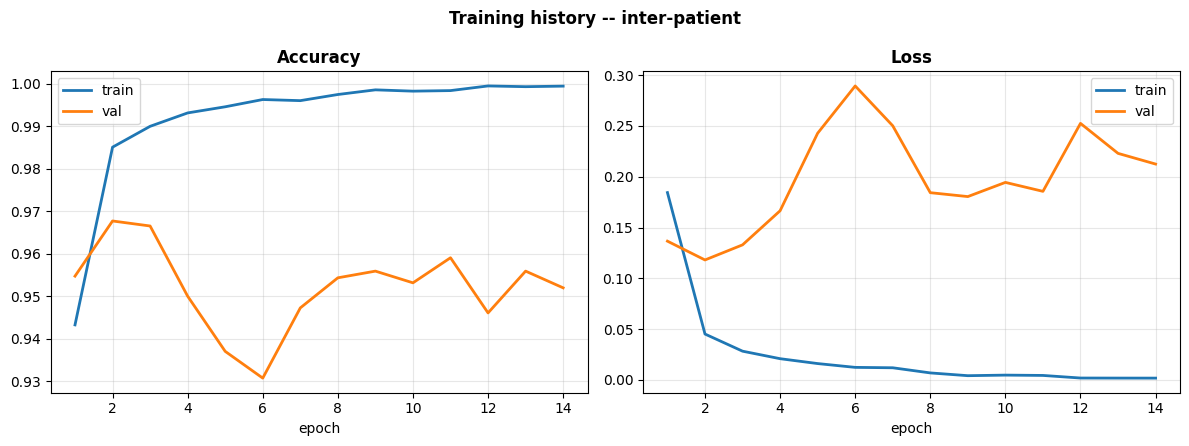

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ep = range(1, len(history.history['accuracy']) + 1)
axes[0].plot(ep, history.history['accuracy'], lw=2, label='train')
axes[0].plot(ep, history.history['val_accuracy'], lw=2, label='val')
axes[0].set_title('Accuracy', fontweight='bold'); axes[0].set_xlabel('epoch')
axes[1].plot(ep, history.history['loss'], lw=2, label='train')
axes[1].plot(ep, history.history['val_loss'], lw=2, label='val')
axes[1].set_title('Loss', fontweight='bold'); axes[1].set_xlabel('epoch')
for a in axes: a.legend(); a.grid(alpha=.3)
plt.suptitle(f'Training history -- {PROTOCOL}-patient', fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig('01_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
def mk_msft_in(X, RR):
    """
    Construct inputs for MSFT-Net.

    MSFT-Net input names:
        signal_input
        rr_input
    """

    X = np.asarray(X, dtype=np.float32)
    RR = np.asarray(RR, dtype=np.float32)

    assert X.shape == (X.shape[0], BEAT_LENGTH, 1), (
        f"ECG input shape is {X.shape}; "
        f"expected (N, {BEAT_LENGTH}, 1)"
    )

    if USE_RR:
        assert RR.shape[1] == N_RR, (
            f"RR width {RR.shape[1]} != N_RR {N_RR}"
        )

        return {
            'signal_input': X,
            'rr_input': RR
        }

    return X

In [47]:
# ============================================================
# SECTION 5B: MSFT-Net -- shape, cost and serialisation checks
# ============================================================

if RUN_MSFT:

    _m = build_msft_net()
    _m.summary()

    print(
        f"\nparameters: {_m.count_params():,} "
        f"(hybrid {model.count_params():,})"
    )

    # --------------------------------------------------------
    # Probe inputs
    # --------------------------------------------------------

    _zx = np.zeros(
        (2, BEAT_LENGTH, 1),
        dtype=np.float32
    )

    _zr = np.ones(
        (2, N_RR),
        dtype=np.float32
    )

    # MSFT-Net uses signal_input, not ecg_input
    _probe = _m.predict(
        mk_msft_in(_zx, _zr),
        verbose=0
    )

    assert (
        _probe.shape == (2, NUM_CLASSES)
        and np.allclose(_probe.sum(1), 1.0)
    )

    print(
        f"forward pass OK -> {_probe.shape}, "
        f"rows sum to 1"
    )

    # --------------------------------------------------------
    # Serialization round-trip
    # --------------------------------------------------------

    _m.save('_probe_msft.keras')

    _r = keras.models.load_model(
        '_probe_msft.keras'
    )

    _probe_reload = _r.predict(
        mk_msft_in(_zx, _zr),
        verbose=0
    )

    assert np.allclose(
        _probe_reload,
        _probe,
        atol=1e-5
    )

    os.remove('_probe_msft.keras')

    print(
        "save/load round-trip OK -> "
        "custom layers are serialisable"
    )

    del _m, _r
    gc.collect()

Model: "MSFT_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ signal_input        │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k5_sep         │ (None, 360, 32)   │         37 │ signal_input[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k11_sep        │ (None, 360, 32)   │         43 │ signal_input[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k21_sep        │ (None, 360, 32)   │         53 │ signal_input[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k5_bn          │ (None, 360, 32)   │        128 │ stem_k5_sep[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k11_bn         │ (None, 360, 32)   │        128 │ stem_k11_sep[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k21_bn         │ (None, 360, 32)   │        128 │ stem_k21_sep[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k5_act         │ (None, 360, 32)   │          0 │ stem_k5_bn[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k11_act        │ (None, 360, 32)   │          0 │ stem_k11_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_k21_act        │ (None, 360, 32)   │          0 │ stem_k21_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_concat         │ (None, 360, 96)   │          0 │ stem_k5_act[0][0… │
│ (Concatenate)       │                   │            │ stem_k11_act[0][… │
│                     │                   │            │ stem_k21_act[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_fuse (Conv1D)  │ (None, 360, 64)   │      6,144 │ stem_concat[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_fuse_bn        │ (None, 360, 64)   │        256 │ stem_fuse[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_fuse_act       │ (None, 360, 64)   │          0 │ stem_fuse_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c1_sep       │ (None, 180, 64)   │      4,544 │ stem_fuse_act[0]… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_input            │ (None, 107)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c1_bn        │ (None, 180, 64)   │        256 │ stage1_c1_sep[0]

 Total params: 167,090 (652.70 KB)

 Trainable params: 164,754 (643.57 KB)

 Non-trainable params: 2,336 (9.12 KB)


parameters: 167,090 (hybrid 572,358)
forward pass OK -> (2, 5), rows sum to 1
save/load round-trip OK -> custom layers are serialisable


## Section 6B — Training the MSFT-Net model

TRAINING MSFT-Net -- lr=0.001
Epoch 1/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.9204 - loss: 0.2512 - macro_f1: 0.8360 - val_accuracy: 0.8587 - val_loss: 0.4744 - val_macro_f1: 0.6816 - learning_rate: 0.0010
Epoch 2/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9667 - loss: 0.1079 - macro_f1: 0.9294 - val_accuracy: 0.9319 - val_loss: 0.1908 - val_macro_f1: 0.7132 - learning_rate: 0.0010
Epoch 3/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9754 - loss: 0.0783 - macro_f1: 0.9506 - val_accuracy: 0.9020 - val_loss: 0.4297 - val_macro_f1: 0.6955 - learning_rate: 0.0010
Epoch 4/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9815 - loss: 0.0627 - macro_f1: 0.9624 - val_accuracy: 0.9122 - val_loss: 0.3342 - val_macro_f1: 0.6816 - learning_rate: 0.0010
Epoch 5/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9837 - loss: 0.0522 - macro_f1: 0.9630 - val_accuracy: 0.8650 - val_loss: 0.8919 - val_macro_f1: 0.6597 - learning_rat

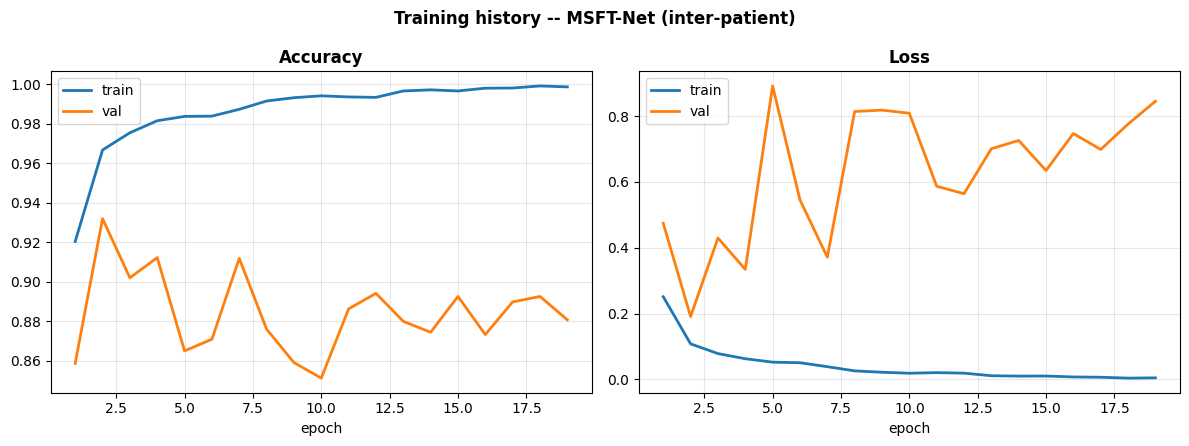

In [48]:
# ============================================================
# SECTION 6B: train the MSFT-Net model
# Same split, same balancing strategy, same loss -- so Section 7C's McNemar
# comparison against the hybrid is paired and the difference is attributable
# to the architecture rather than to the data pipeline.
# ============================================================
if RUN_MSFT:
    tf.keras.backend.clear_session()
    np.random.seed(SEED); tf.random.set_seed(SEED)
    model_msft = build_msft_net()
    model_msft.compile(optimizer=Adam(MSFT_LR), loss=LOSS_FN, metrics=METRICS)

    print(f"TRAINING MSFT-Net -- lr={MSFT_LR}")
    t0 = time.perf_counter()
    history_msft = model_msft.fit(mk_msft_in(X_tr, RR_tr), y_tr_oh,
                              validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                              epochs=EPOCHS, batch_size=BATCH_SIZE,
                              sample_weight=sample_weight_tr,
                              callbacks=make_callbacks(MODEL_NAME_MSFT), verbose=1)
    train_min_msft = (time.perf_counter() - t0) / 60
    print(f"\ntraining finished in {train_min_msft:.1f} min")
    model_msft.save(f'{MODEL_NAME_MSFT}_{PROTOCOL}.keras')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ep = range(1, len(history_msft.history['accuracy']) + 1)
    axes[0].plot(ep, history_msft.history['accuracy'], lw=2, label='train')
    axes[0].plot(ep, history_msft.history['val_accuracy'], lw=2, label='val')
    axes[0].set_title('Accuracy', fontweight='bold'); axes[0].set_xlabel('epoch')
    axes[1].plot(ep, history_msft.history['loss'], lw=2, label='train')
    axes[1].plot(ep, history_msft.history['val_loss'], lw=2, label='val')
    axes[1].set_title('Loss', fontweight='bold'); axes[1].set_xlabel('epoch')
    for a in axes: a.legend(); a.grid(alpha=.3)
    plt.suptitle(f'Training history -- MSFT-Net ({PROTOCOL}-patient)',
                 fontweight='bold')
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('01b_training_history_msft.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    model_msft, history_msft = None, None
    print("RUN_MSFT = False -- MSFT-Net skipped")


## Section 6C — Stage 2: F/V hard-negative mining (training partition only)

The Stage-1 model is run over the **training** beats only; the four F-relevant
confusion groups (F→V, F→N, V→F, N→F) are turned into per-sample weights and the
model is fine-tuned on them. Validation is used for early stopping only; the test
partition is not read by this cell except to snapshot the Stage-1 baseline
predictions that Section 6E reports against.

In [49]:
# ============================================================
# SECTION 6C — F/V HARD-NEGATIVE MINING  (TRAINING PARTITION ONLY)
# ============================================================
# Stage 1 (Section 6B) is already trained. This cell:
#   1. snapshots the Stage-1 weights and predictions (the BASELINE that every
#      later comparison in Sections 6E/9H is measured against),
#   2. runs the Stage-1 model over the TRAINING partition only,
#   3. mines the four confusion groups that matter for F,
#   4. fine-tunes with per-sample weights that emphasise them.
#
# LEAKAGE CONTRACT (asserted below, not just claimed):
#   mining input  = X_tr / RR_tr / y_tr           <- training partition only
#   validation    = early stopping + model selection only, never mined
#   test          = never touched until Section 7C/7D
# ============================================================
if RUN_MSFT and model_msft is not None:

    # ── class indices, read from CLASS_NAMES (never hard-coded) ──────
    def _cls_idx(prefix):
        return next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith(prefix)), None)

    F_IDX, N_IDX, V_IDX = _cls_idx('F'), _cls_idx('N'), _cls_idx('V')
    S_IDX, Q_IDX = _cls_idx('S'), _cls_idx('Q')
    assert F_IDX is not None and N_IDX is not None and V_IDX is not None, \
        "F/N/V must all be present in CLASS_NAMES for Sections 6C/6D"
    print(f"class indices: F={F_IDX} N={N_IDX} V={V_IDX} S={S_IDX} Q={Q_IDX}")

    # ── Stage-1 snapshot (baseline for every comparison downstream) ──
    MSFT_STAGE1_WEIGHTS = [w.copy() for w in model_msft.get_weights()]
    model_msft.save(f'{MODEL_NAME_MSFT}_{PROTOCOL}_stage1.keras')

    msft_stage1_val_probs  = model_msft.predict(mk_msft_in(X_val,  RR_val),
                                                batch_size=512, verbose=0)
    msft_stage1_test_probs = model_msft.predict(mk_msft_in(X_test, RR_test),
                                                batch_size=512, verbose=0)
    msft_stage1_val_pred   = np.argmax(msft_stage1_val_probs,  axis=1)
    msft_stage1_test_pred  = np.argmax(msft_stage1_test_probs, axis=1)
    # NOTE: the test probabilities above are stored ONLY so Section 6E can print
    # a before/after table. Nothing selects a model, a threshold or a weight
    # from them -- every decision below is made on TRAIN (mining) or VAL
    # (early stopping / restore_best_weights).

    def mine_hard_negatives(mdl, X, RR, y_int, mk_in_fn,
                            f_idx=None, n_idx=None, v_idx=None,
                            ratio=None, batch_size=512, verbose=True):
        """Improvement 2 -- F/V hard-negative mining.

        Runs `mdl` over the TRAINING beats it is given and returns
        (weights, info):
          weights : float32 per-sample weight vector, 1.0 everywhere except the
                    mined groups, ready for model.fit(sample_weight=...)
          info    : dict of boolean masks + counts, for reporting.

        The four groups, in priority order (F<->V first, because 174/398 of the
        baseline's F errors land in V):
            F->V   HARD_FV_WEIGHT
            F->N   HARD_FN_WEIGHT
            V->F   HARD_VF_WEIGHT
            N->F   HARD_NF_WEIGHT
        HARD_NEGATIVE_RATIO scales the EXTRA weight, not the weight itself:
            effective = 1 + ratio * (W - 1)
        so ratio=0 reproduces plain training exactly and ratio=1 gives the
        configured weights. This is deliberately a re-weighting rather than
        unbounded duplication -- the goal is repeated exposure to the F/V
        boundary, not making F the largest class.
        """
        f_idx = F_IDX if f_idx is None else f_idx
        n_idx = N_IDX if n_idx is None else n_idx
        v_idx = V_IDX if v_idx is None else v_idx
        ratio = HARD_NEGATIVE_RATIO if ratio is None else ratio

        y_int = np.asarray(y_int).astype(int)
        probs = mdl.predict(mk_in_fn(X, RR), batch_size=batch_size, verbose=0)
        y_hat = np.argmax(probs, axis=1)

        groups = {
            'F->V': ((y_int == f_idx) & (y_hat == v_idx), HARD_FV_WEIGHT),
            'F->N': ((y_int == f_idx) & (y_hat == n_idx), HARD_FN_WEIGHT),
            'V->F': ((y_int == v_idx) & (y_hat == f_idx), HARD_VF_WEIGHT),
            'N->F': ((y_int == n_idx) & (y_hat == f_idx), HARD_NF_WEIGHT),
        }

        w = np.ones(len(y_int), dtype=np.float32)
        for name, (mask, weight) in groups.items():
            eff = 1.0 + float(ratio) * (float(weight) - 1.0)
            # max(): a beat can only be in one of these groups, but max() keeps
            # the function correct if the group definitions are ever widened.
            w[mask] = np.maximum(w[mask], eff)

        info = {k: v[0] for k, v in groups.items()}
        info['counts'] = {k: int(v[0].sum()) for k, v in groups.items()}
        info['train_pred'] = y_hat
        info['n_hard'] = int(sum(info['counts'].values()))

        if verbose:
            n_f = int((y_int == f_idx).sum())
            print(f"  mined on {len(y_int):,} TRAINING beats ({n_f:,} of them F)")
            for name, (mask, weight) in groups.items():
                eff = 1.0 + float(ratio) * (float(weight) - 1.0)
                print(f"    {name:<6} {int(mask.sum()):6,d} beats   weight x{eff:.2f}")
            print(f"    total hard: {info['n_hard']:,} "
                  f"({100 * info['n_hard'] / max(len(y_int), 1):.2f}% of training)")
        return w, info

    if ENABLE_HARD_NEGATIVE_MINING:
        # ── leakage guards ───────────────────────────────────────────
        assert len(X_tr) == len(y_tr) == len(RR_tr), "training arrays out of sync"
        assert len(X_test) == len(X_test_raw), "the test set must never be resampled"
        assert len(X_val) == len(X_val_raw),  "the validation set must never be resampled"

        print("=" * 62)
        print("  SECTION 6C -- STAGE 2: F/V HARD-NEGATIVE MINING")
        print("=" * 62)
        hard_w, hard_info = mine_hard_negatives(
            model_msft, X_tr, RR_tr, y_tr, mk_msft_in)

        # combine with whatever the balancing strategy already asked for
        # (None for 'none'/'focal'/'smote'; a per-sample vector for 'class_weight')
        if sample_weight_tr is not None:
            hard_w = (hard_w * sample_weight_tr).astype(np.float32)
        msft_hard_sample_weight = hard_w      # reused by Section 6D

        if hard_info['n_hard'] == 0:
            print("  no hard negatives found -- skipping the fine-tune stage")
        else:
            model_msft.compile(optimizer=Adam(MSFT_LR * HARD_NEG_LR_SCALE),
                               loss=LOSS_FN,
                               metrics=['accuracy',
                                        keras.metrics.F1Score(average='macro',
                                                              name='macro_f1')])
            print(f"\n  fine-tuning {HARD_NEG_FINETUNE_EPOCHS} epochs @ lr="
                  f"{MSFT_LR * HARD_NEG_LR_SCALE:g} (early stopping on val_macro_f1)")
            t0 = time.perf_counter()
            history_msft_hard = model_msft.fit(
                mk_msft_in(X_tr, RR_tr), y_tr_oh,
                validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                epochs=HARD_NEG_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
                sample_weight=msft_hard_sample_weight,
                callbacks=[EarlyStopping(monitor='val_macro_f1', mode='max',
                                         patience=6, restore_best_weights=True,
                                         verbose=1),
                           ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=3, min_lr=1e-7, verbose=1)],
                verbose=1)
            print(f"  stage 2 finished in {(time.perf_counter() - t0) / 60:.1f} min")

            _p = model_msft.predict(mk_msft_in(X_val, RR_val), batch_size=512, verbose=0)
            _pr = np.argmax(_p, axis=1)
            print(f"\n  VAL after stage 2: acc={accuracy_score(y_val, _pr):.4f}  "
                  f"macro-F1={f1_score(y_val, _pr, average='macro', zero_division=0):.4f}  "
                  f"F recall={((_pr == F_IDX) & (y_val == F_IDX)).sum() / max((y_val == F_IDX).sum(), 1):.4f}")
            model_msft.save(f'{MODEL_NAME_MSFT}_{PROTOCOL}_stage2.keras')
    else:
        msft_hard_sample_weight = sample_weight_tr
        hard_info = None
        print("ENABLE_HARD_NEGATIVE_MINING = False -- stage 2 skipped")
else:
    MSFT_STAGE1_WEIGHTS = None
    msft_hard_sample_weight, hard_info = None, None
    msft_stage1_test_probs = msft_stage1_val_probs = None
    print("RUN_MSFT = False -- Section 6C skipped")


class indices: F=3 N=0 V=2 S=1 Q=4
  SECTION 6C -- STAGE 2: F/V HARD-NEGATIVE MINING
  mined on 22,817 TRAINING beats (1,995 of them F)
    F->V        0 beats   weight x2.00
    F->N        0 beats   weight x1.50
    V->F        5 beats   weight x1.50
    N->F        8 beats   weight x1.25
    total hard: 13 (0.06% of training)

  fine-tuning 12 epochs @ lr=0.0002 (early stopping on val_macro_f1)
Epoch 1/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.9927 - loss: 0.0223 - macro_f1: 0.9836 - val_accuracy: 0.9039 - val_loss: 0.4797 - val_macro_f1: 0.7186 - learning_rate: 2.0000e-04
Epoch 2/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9940 - loss: 0.0181 - macro_f1: 0.9869 - val_accuracy: 0.8969 - val_loss: 0.5392 - val_macro_f1: 0.7024 - learning_rate: 2.0000e-04
Epoch 3/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9958 - loss: 0.0135 - macro_f1: 0.9910 - val_accuracy: 0.9122 - val_loss: 0.5080 - val_macro_f1: 0.7481 - learning_rate: 2.0000e-04

## Section 6C2 — Change 2: Q hard-negative mining, and the bug it exposes

Section 6C's recorded output reads:

```
mined on 21,809 TRAINING beats (1,995 of them F)
  F->V        0 beats     F->N   0 beats     V->F   0 beats     N->F   2 beats
  total hard: 2 (0.01% of training)
```

Two hard negatives out of 21,809, because the stage-1 model reaches training accuracy
0.9996–1.0000. **A mining rule of the form `y_true != y_pred` evaluated on the training
partition cannot work on this notebook**, for F or for Q. Copying that rule across to Q
would add a stage that mines nothing and then reporting it as a Q improvement.

`mine_hard_examples` below keeps the original error mask (`mode='error'`, for
reproducibility) and adds:

* **`mode='margin'`** — rank each class's own training beats by
  `p(true) − max p(other)` and take the lowest `Q_MARGIN_FRAC`. Defined even at 100%
  training accuracy, and it selects the beats nearest the decision boundary, which is
  what hard-negative mining is supposed to select.
* **`mode='oof'`** — honest out-of-fold predictions from *record-disjoint* internal
  folds of the training partition. Costlier (k short retrains) but it is the only
  variant whose "misclassified" actually means misclassified. Still training-only: the
  folds are cut inside the training records, so nothing from validation or test enters.


In [ ]:
# ============================================================
# SECTION 6C2 — CHANGE 2: Q (AND F) HARD-NEGATIVE MINING, FIXED
# ============================================================
# TRAINING PARTITION ONLY. Section 6C's mine_hard_negatives is left intact and
# still callable; this is the generalised version it should have been.


def mine_by_margin(probs, y_int, cls_idx, frac=0.25, min_count=1):
    """Lowest-margin training beats of one class.

    margin_i = p_i(true class) - max_{c != true} p_i(c)
    Negative margin == misclassified, so this is a strict superset of the error
    mask and degrades gracefully to "the hardest frac of the class" when the
    model fits the training partition perfectly. Returns (mask, margins) where
    margins is aligned with the class members, not with y_int.
    """
    probs = np.asarray(probs, dtype=np.float64)
    y_int = np.asarray(y_int).astype(int)
    cls = np.where(y_int == cls_idx)[0]
    if len(cls) == 0:
        return np.zeros(len(y_int), dtype=bool), np.zeros(0)
    p_true = probs[cls, cls_idx]
    other = probs[cls].copy()
    other[:, cls_idx] = -np.inf
    margin = p_true - other.max(axis=1)
    k = min(len(cls), max(int(min_count), int(round(float(frac) * len(cls)))))
    order = np.argsort(margin, kind='stable')[:k]
    mask = np.zeros(len(y_int), dtype=bool)
    mask[cls[order]] = True
    return mask, margin


def q_confusion_breakdown(y_true, y_pred, q_idx, class_names=None, tag='', show=True):
    """The Q error table required by the task: total / correct / Q->N / Q->S /
    Q->V / Q->F plus Se, +P and F1. Returns a dict; prints when show."""
    class_names = CLASS_NAMES if class_names is None else class_names
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    q_mask = (y_true == q_idx)
    total = int(q_mask.sum())
    correct = int((q_mask & (y_pred == q_idx)).sum())
    dest = {class_names[c]: int((q_mask & (y_pred == c)).sum())
            for c in range(len(class_names)) if c != q_idx}
    pred_q = int((y_pred == q_idx).sum())
    se = correct / total if total else float('nan')
    pp = correct / pred_q if pred_q else float('nan')
    f1 = (2 * se * pp / (se + pp)) if (se == se and pp == pp and (se + pp) > 0) else 0.0
    out = dict(tag=tag, Q_total=total, Q_correct=correct, Q_recall=se,
               Q_precision=pp, Q_f1=f1, **{f'Q_to_{k[:1]}': v for k, v in dest.items()})
    if show:
        print(f"\n--- Q error breakdown [{tag}] ---")
        print(f"  Total Q beats  : {total}")
        print(f"  Correct Q      : {correct}")
        for k, v in dest.items():
            print(f"  Q -> {k:<12} {v}")
        print(f"  Q sensitivity  : {se:.4f}")
        print(f"  Q precision    : {pp:.4f}")
        print(f"  Q F1           : {f1:.4f}")
    return out


def mine_hard_examples(mdl, X, RR, y_int, mk_in_fn, mode=None, batch_size=512,
                       f_idx=None, n_idx=None, v_idx=None, q_idx=None,
                       ratio=None, margin_frac=None, verbose=True):
    """F and Q hard-negative mining on the TRAINING partition.

    mode: 'error'  original argmax-mismatch rule (kept for reproducibility)
          'margin' lowest-margin fraction per class -- works at 100% train acc
          'both'   union of the two
    Returns (weights, info) with the same shape of contract as Section 6C's
    mine_hard_negatives, so either can be handed to model.fit(sample_weight=).
    """
    mode = (globals().get('Q_MINING_MODE', 'margin') if mode is None else mode).lower()
    ratio = HARD_NEGATIVE_RATIO if ratio is None else ratio
    margin_frac = globals().get('Q_MARGIN_FRAC', 0.25) if margin_frac is None else margin_frac
    f_idx = F_IDX if f_idx is None else f_idx
    n_idx = N_IDX if n_idx is None else n_idx
    v_idx = V_IDX if v_idx is None else v_idx
    q_idx = Q_IDX if q_idx is None else q_idx

    y_int = np.asarray(y_int).astype(int)
    probs = mdl.predict(mk_in_fn(X, RR), batch_size=batch_size, verbose=0)
    y_hat = np.argmax(probs, axis=1)

    groups = {}
    if mode in ('error', 'both'):
        groups.update({
            'F->V': ((y_int == f_idx) & (y_hat == v_idx), HARD_FV_WEIGHT),
            'F->N': ((y_int == f_idx) & (y_hat == n_idx), HARD_FN_WEIGHT),
            'V->F': ((y_int == v_idx) & (y_hat == f_idx), HARD_VF_WEIGHT),
            'N->F': ((y_int == n_idx) & (y_hat == f_idx), HARD_NF_WEIGHT),
        })
        if q_idx is not None and globals().get('ENABLE_Q_HARD_MINING', True):
            groups.update({
                'Q->N': ((y_int == q_idx) & (y_hat == n_idx), Q_TO_N_HARD_WEIGHT),
                'Q->S': ((y_int == q_idx) & (y_hat == S_IDX), Q_TO_S_HARD_WEIGHT),
                'Q->V': ((y_int == q_idx) & (y_hat == v_idx), Q_TO_V_HARD_WEIGHT),
                'Q->F': ((y_int == q_idx) & (y_hat == f_idx), Q_TO_F_HARD_WEIGHT),
            })
    if mode in ('margin', 'both'):
        m_f, _ = mine_by_margin(probs, y_int, f_idx, frac=margin_frac)
        groups['F low-margin'] = (m_f, HARD_FV_WEIGHT)
        if q_idx is not None and globals().get('ENABLE_Q_HARD_MINING', True):
            m_q, q_margins = mine_by_margin(probs, y_int, q_idx, frac=margin_frac)
            groups['Q low-margin'] = (m_q, Q_HARD_NEG_WEIGHT)

    w = np.ones(len(y_int), dtype=np.float32)
    for name, (mask, weight) in groups.items():
        eff = 1.0 + float(ratio) * (float(weight) - 1.0)
        w[mask] = np.maximum(w[mask], eff)

    info = {k: v[0] for k, v in groups.items()}
    info['counts'] = {k: int(v[0].sum()) for k, v in groups.items()}
    info['train_pred'] = y_hat
    info['train_probs'] = probs
    info['n_hard'] = int(np.sum(np.any(np.stack([v[0] for v in groups.values()]), axis=0))) \
        if groups else 0
    info['mode'] = mode

    if verbose:
        print(f"  mining mode '{mode}' on {len(y_int):,} TRAINING beats "
              f"(train acc {np.mean(y_hat == y_int):.4f})")
        for name, (mask, weight) in groups.items():
            eff = 1.0 + float(ratio) * (float(weight) - 1.0)
            print(f"    {name:<14} {int(mask.sum()):6,d} beats   weight x{eff:.2f}")
        print(f"    distinct hard beats: {info['n_hard']:,} "
              f"({100 * info['n_hard'] / max(len(y_int), 1):.2f}% of training)")
    return w, info


def build_combined_sample_weights(y_int, hard_w=None, base_w=None,
                                  q_idx=None, q_class_weight=None, clip=None):
    """Change 6: base (balancing) x class weight x hard-negative weight, clipped.

    Order matters only for the clip; the product is what reaches model.fit.
    Q_CLASS_WEIGHT defaults to 1.0 -- see Section 0Q for why up-weighting Q is
    not indicated by this notebook's own ablation.
    """
    y_int = np.asarray(y_int).astype(int)
    q_idx = (Q_IDX if 'Q_IDX' in globals() else None) if q_idx is None else q_idx
    q_class_weight = globals().get('Q_CLASS_WEIGHT', 1.0) if q_class_weight is None \
        else q_class_weight
    clip = globals().get('SAMPLE_WEIGHT_CLIP', None) if clip is None else clip

    w = np.ones(len(y_int), dtype=np.float32) if base_w is None \
        else np.asarray(base_w, dtype=np.float32).copy()
    if hard_w is not None:
        w = w * np.asarray(hard_w, dtype=np.float32)
    if q_idx is not None and float(q_class_weight) != 1.0:
        w[y_int == q_idx] *= float(q_class_weight)
    if clip is not None:
        w = np.clip(w, 0.0, float(clip))
    return w.astype(np.float32)


def make_balanced_dataset(X, RR, y_int, y_oh, sample_weight=None,
                          batch_size=None, alpha=None, seed=None, use_rr=None,
                          aux_targets=None, aux_order=None):
    """Change 5: semi-balanced mini-batches as a tf.data.Dataset.

    alpha interpolates between the empirical class distribution (0.0, i.e. the
    current behaviour) and uniform over the present classes (1.0). Sampling is
    WITH replacement inside each class stream, so the minority classes repeat
    rather than the majority classes being discarded.

    TRAINING ONLY. Validation and test are never passed through this function --
    Sections 6B/6D keep handing them to Keras as plain numpy tuples, so their
    class distribution is untouched.

    aux_targets: optional LIST of arrays (auxiliary-head targets, in the
    training model's output order after the main softmax), or a dict
    {output_name: array} plus `aux_order` to order it. Each is gathered with
    the same indices as X/RR/y, and the dataset yields a LIST target
    [y_oh, *aux] to match the model's list-structured outputs -- a dict target
    here reproduces the same OptionalFromValue failure as in Section 5D.
    """
    batch_size = BATCH_SIZE if batch_size is None else batch_size
    alpha = globals().get('BALANCED_BATCH_ALPHA', 0.5) if alpha is None else alpha
    seed = SEED if seed is None else seed
    use_rr = USE_RR if use_rr is None else use_rr

    y_int = np.asarray(y_int).astype(int)
    counts = np.array([(y_int == c).sum() for c in range(NUM_CLASSES)], dtype=np.float64)
    present = np.where(counts > 0)[0]
    emp = counts[present] / counts[present].sum()
    uni = np.ones(len(present)) / len(present)
    probs = (1.0 - float(alpha)) * emp + float(alpha) * uni
    probs = probs / probs.sum()

    X_t = tf.constant(np.asarray(X, np.float32))
    R_t = tf.constant(np.asarray(RR, np.float32))
    Y_t = tf.constant(np.asarray(y_oh, np.float32))
    W_t = tf.constant(np.ones(len(y_int), np.float32) if sample_weight is None
                      else np.asarray(sample_weight, np.float32))
    # normalise aux_targets to an ordered LIST
    if aux_targets is None:
        _aux_list = []
    elif isinstance(aux_targets, dict):
        _order = list(aux_order) if aux_order else list(aux_targets.keys())
        _aux_list = [aux_targets[k] for k in _order if k in aux_targets]
    else:
        _aux_list = list(aux_targets)
    A_t = [tf.constant(np.asarray(v, np.float32)) for v in _aux_list]

    def _pack(i):
        xin = (tf.gather(X_t, i), tf.gather(R_t, i)) if use_rr else tf.gather(X_t, i)
        if A_t:
            tgt = [tf.gather(Y_t, i)] + [tf.gather(v, i) for v in A_t]
        else:
            tgt = tf.gather(Y_t, i)
        return xin, tgt, tf.gather(W_t, i)

    streams = []
    for c in present:
        idx = np.where(y_int == c)[0].astype(np.int64)
        streams.append(tf.data.Dataset.from_tensor_slices(idx)
                       .shuffle(len(idx), seed=seed, reshuffle_each_iteration=True)
                       .repeat())
    ds = tf.data.Dataset.sample_from_datasets(
        streams, weights=probs.astype(np.float32), seed=seed, stop_on_empty_dataset=False)
    ds = ds.batch(batch_size, drop_remainder=True).map(
        _pack, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    steps = max(1, len(y_int) // batch_size)
    print(f"  balanced dataset: alpha={alpha}  per-class sampling probability "
          + "  ".join(f"{CLASS_NAMES[c][:3]}={p:.3f}" for c, p in zip(present, probs))
          + f"  ({steps} steps/epoch)")
    return ds, steps


# ── self-tests that need no trained model ────────────────────────
_pr = np.eye(5)[np.array([0, 4, 4, 4, 2])] * 0.6 + 0.08
_yt = np.array([0, 4, 4, 4, 2])
_m, _mg = mine_by_margin(_pr, _yt, 4, frac=0.5)
assert _m.sum() == 2 and (_yt[_m] == 4).all()
_w = build_combined_sample_weights(_yt, hard_w=np.where(_m, 2.0, 1.0),
                                   q_idx=4, q_class_weight=1.5, clip=6.0)
assert np.allclose(np.unique(_w), [1.0, 1.5, 3.0])
_qb = q_confusion_breakdown(_yt, np.array([0, 0, 4, 2, 2]), 4, tag='self-test', show=False)
assert _qb['Q_total'] == 3 and _qb['Q_correct'] == 1
del _pr, _yt, _m, _mg, _w, _qb

print("Section 6C2 defined: mine_by_margin, mine_hard_examples, "
      "q_confusion_breakdown, build_combined_sample_weights, "
      f"make_balanced_dataset (mode='{Q_MINING_MODE}', frac={Q_MARGIN_FRAC}) "
      "-- self-tests passed")

## Section 6D — Stage 3: F-vs-N and F-vs-V auxiliary losses

`L = L_5class + 0.15·L_F/N + 0.35·L_F/V`. The auxiliary heads share MSFT-Net's
penultimate representation, so training them updates the same weights; `model_msft` keeps a single 5-class softmax for every downstream section.

In [ ]:
# ============================================================
# SECTION 6D — STAGE 3: F-vs-N / F-vs-V AUXILIARY-LOSS FINE-TUNE
# ============================================================
#   L = L_5class + LAMBDA_F_N * L_(F/N) + LAMBDA_F_V * L_(F/V)
#
# The auxiliary heads are TRAINING SUPERVISION ONLY. `model_msft` keeps its
# single 5-class softmax output, so Sections 7/7B/7C/7D/8/11/12/13 (evaluation,
# Grad-CAM, TFLite/INT8, robustness) consume it unchanged -- the multi-output
# object `train_model_msft` exists only inside this cell and shares the very
# same layer objects, so fitting it updates `model_msft`'s weights in place.
#
# Two independent safeguards keep S and Q out of the binary losses:
#   1. masked_bce  -- targets carry -1 for "ignore"; the loss zeroes them,
#   2. per-output sample_weight -- 0.0 for the same beats.
# Either alone is sufficient; both together mean a Keras-version quirk in the
# multi-output sample_weight plumbing cannot silently turn S/Q into negatives.
# ============================================================
if RUN_MSFT and model_msft is not None and ENABLE_F_AUX_LOSS:

    def masked_bce(y_true, y_pred):
        """Binary cross-entropy over the UNMASKED beats only.

        y_true in {0.0, 1.0} for beats that belong to the head's two classes,
        and -1.0 for every beat that must not contribute (S, Q, and the third
        of N/V that this head does not judge). Requirement 6C forbids folding
        those into the negative class; this loss drops them instead of
        mislabelling them.
        """
        y_true = tf.cast(y_true, tf.float32)
        mask = tf.cast(tf.greater_equal(y_true, 0.0), tf.float32)
        y_safe = tf.clip_by_value(y_true, 0.0, 1.0)
        p = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)
        bce = -(y_safe * tf.math.log(p) + (1.0 - y_safe) * tf.math.log(1.0 - p))
        bce = tf.reduce_sum(bce * mask, axis=-1)
        return bce / tf.maximum(tf.reduce_sum(mask, axis=-1), 1.0)

    def make_f_aux_targets_masked(y_int, f_idx, n_idx, v_idx):
        """Same contract as make_f_aux_targets (Section 5C) -- reused, not
        reimplemented -- but with the ignored beats folded into the target as
        -1 so masked_bce can drop them even if sample weights are unavailable.
        Returns (y_fn_masked, w_fn, y_fv_masked, w_fv), each shaped (n, 1)."""
        y_fn, w_fn, y_fv, w_fv = make_f_aux_targets(y_int, f_idx, n_idx, v_idx)
        y_fn_m = np.where(w_fn > 0, y_fn, -1.0).astype(np.float32).reshape(-1, 1)
        y_fv_m = np.where(w_fv > 0, y_fv, -1.0).astype(np.float32).reshape(-1, 1)
        return y_fn_m, w_fn.astype(np.float32), y_fv_m, w_fv.astype(np.float32)

    print("=" * 62)
    print("  SECTION 6D -- STAGE 3: F AUXILIARY LOSSES")
    print(f"  lambda_F/N = {LAMBDA_F_N}   lambda_F/V = {LAMBDA_F_V}")
    print("=" * 62)

    # ── targets: TRAIN and VAL, built from integer labels ────────────
    y_fn_tr, w_fn_tr, y_fv_tr, w_fv_tr = make_f_aux_targets_masked(y_tr, F_IDX, N_IDX, V_IDX)
    y_fn_va, w_fn_va, y_fv_va, w_fv_va = make_f_aux_targets_masked(y_val, F_IDX, N_IDX, V_IDX)
    print(f"  F/N head: {int(w_fn_tr.sum()):,} training beats contribute "
          f"({int((y_fn_tr == 1).sum()):,} F / {int((y_fn_tr == 0).sum()):,} N)")
    print(f"  F/V head: {int(w_fv_tr.sum()):,} training beats contribute "
          f"({int((y_fv_tr == 1).sum()):,} F / {int((y_fv_tr == 0).sum()):,} V)")
    assert int(((y_fn_tr.ravel() >= 0) & np.isin(y_tr, [S_IDX, Q_IDX])).sum()) == 0, \
        "S/Q beats must be masked out of the F-vs-N head"
    assert int(((y_fv_tr.ravel() >= 0) & np.isin(y_tr, [S_IDX, Q_IDX])).sum()) == 0, \
        "S/Q beats must be masked out of the F-vs-V head"

    # ── multi-output training view of the SAME layers ────────────────
    train_model_msft = build_f_aux_train_model(
        model_msft, F_IDX, N_IDX, V_IDX,
        lambda_fn=LAMBDA_F_N, lambda_fv=LAMBDA_F_V,
        shared_layer='head_dropout', main_output_name='predictions',
        aux_loss=masked_bce, learning_rate=MSFT_LR * F_AUX_LR_SCALE)
    main_name = 'predictions'
    print(f"  train_model outputs: {getattr(train_model_msft, 'output_names', ['predictions', 'f_vs_n_head', 'f_vs_v_head'])}")
    print(f"  extra parameters vs. model_msft: "
          f"{train_model_msft.count_params() - model_msft.count_params()}")

    # ── targets keyed by output name; fit_multi_output turns them into
    #    whichever structure this Keras build accepts (Section 5D) ──
    order = aux_output_order(train_model_msft,
                             fallback=[main_name, 'f_vs_n_head', 'f_vs_v_head'])
    main_name = order[0]
    print(f"  output order: {order}")

    y_map_tr = {main_name: y_tr_oh,  'f_vs_n_head': y_fn_tr, 'f_vs_v_head': y_fv_tr}
    y_map_va = {main_name: y_val_oh, 'f_vs_n_head': y_fn_va, 'f_vs_v_head': y_fv_va}
    main_w = (msft_hard_sample_weight if msft_hard_sample_weight is not None
              else np.ones(len(y_tr), dtype=np.float32))
    sw_map_tr = {main_name: main_w, 'f_vs_n_head': w_fn_tr, 'f_vs_v_head': w_fv_tr}

    t0 = time.perf_counter()
    history_msft_aux, _fit_info = fit_multi_output(
        train_model_msft,
        mk_msft_in(X_tr, RR_tr), y_map_tr, order,
        epochs=F_AUX_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(mk_msft_in(X_val, RR_val), y_map_va),
        sample_weight_map=sw_map_tr,
        callbacks_fn=lambda mon, mode: [
            EarlyStopping(monitor=mon, mode=mode, patience=6,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                              min_lr=1e-7, verbose=1)],
        verbose=1)
    print(f"\n  stage 3 finished in {(time.perf_counter() - t0) / 60:.1f} min "
          f"(structure: {_fit_info['structure']}; sample weights applied: "
          f"{_fit_info['sample_weight_applied']})")

    # ── the reported model is still a plain 5-class classifier ───────
    _probe = model_msft.predict(mk_msft_in(X_val[:4], RR_val[:4]), verbose=0)
    assert _probe.shape == (4, NUM_CLASSES) and np.allclose(_probe.sum(1), 1.0, atol=1e-5), \
        "model_msft must still return a single 5-class softmax after stage 3"
    print(f"  model_msft.predict still returns {_probe.shape} rows summing to 1 "
          "-- downstream sections unchanged")

    _p = model_msft.predict(mk_msft_in(X_val, RR_val), batch_size=512, verbose=0)
    _pr = np.argmax(_p, axis=1)
    print(f"  VAL after stage 3: acc={accuracy_score(y_val, _pr):.4f}  "
          f"macro-F1={f1_score(y_val, _pr, average='macro', zero_division=0):.4f}  "
          f"F recall={((_pr == F_IDX) & (y_val == F_IDX)).sum() / max((y_val == F_IDX).sum(), 1):.4f}")
    model_msft.save(f'{MODEL_NAME_MSFT}_{PROTOCOL}.keras')     # final reported model
else:
    train_model_msft, history_msft_aux = None, None
    print("ENABLE_F_AUX_LOSS = False (or MSFT-Net off) -- stage 3 skipped")

## Section 6D2 — Stages 2 and 3 re-run with Q wired in

This cell re-runs the two fine-tuning stages using the fixed mining rule and the
three-head training model. It starts from the **stage-1 snapshot** taken in Section 6C
(`MSFT_STAGE1_WEIGHTS`), not from the stage-3 model, so it is a clean replacement for
6C/6D rather than a fourth stage stacked on top of them.

`use_sw_dict` deserves a note: Section 6D's recorded output shows the per-output
sample-weight dict was **rejected** by the installed Keras (`KeyError: 0`), so the
reported stage 3 silently ran with no hard-negative emphasis at all. The dict is
rebuilt here keyed by `train_model.output_names`, which is the form that version
accepts; if it still fails, the fallback is masked targets only and the cell says so
rather than continuing quietly.


In [ ]:
# ============================================================
# SECTION 6D2 — STAGES 2 + 3 WITH Q MECHANISMS ENABLED
# ============================================================
#   L = L_5class + LAMBDA_F_N*L_(F/N) + LAMBDA_F_V*L_(F/V) + LAMBDA_Q*L_(Q/rest)
# Starts from the Section 6C stage-1 snapshot. TRAINING partition only.

RUN_Q_PASS = True

if RUN_Q_PASS and RUN_MSFT and model_msft is not None and MSFT_STAGE1_WEIGHTS is not None:

    print("=" * 62)
    print("  SECTION 6D2 -- Q PASS: stage 2 (mining) + stage 3 (multi-task)")
    print("=" * 62)
    model_msft.set_weights([w.copy() for w in MSFT_STAGE1_WEIGHTS])
    print("  restored stage-1 weights (clean restart, not a 4th stage)")

    _s1_train_probs = model_msft.predict(mk_msft_in(X_tr, RR_tr), batch_size=512, verbose=0)
    q_confusion_breakdown(y_tr, np.argmax(_s1_train_probs, 1), Q_IDX,
                          tag='stage 1, TRAIN (mining input)')
    q_confusion_breakdown(y_val, np.argmax(
        model_msft.predict(mk_msft_in(X_val, RR_val), batch_size=512, verbose=0), 1),
        Q_IDX, tag='stage 1, VALIDATION')

    # ── stage 2: fixed mining ────────────────────────────────────
    assert len(X_tr) == len(y_tr) == len(RR_tr), "training arrays out of sync"
    assert len(X_val) == len(X_val_raw) and len(X_test) == len(X_test_raw), \
        "validation/test must never be resampled"
    hard_w2, hard_info2 = mine_hard_examples(model_msft, X_tr, RR_tr, y_tr, mk_msft_in)
    sw_combined = build_combined_sample_weights(
        y_tr, hard_w=hard_w2, base_w=sample_weight_tr, q_idx=Q_IDX)
    print(f"  effective sample weights: min={sw_combined.min():.2f} "
          f"max={sw_combined.max():.2f} mean={sw_combined.mean():.3f}; "
          f"Q mean={sw_combined[y_tr == Q_IDX].mean():.3f}  "
          f"F mean={sw_combined[y_tr == F_IDX].mean():.3f}")

    model_msft.compile(optimizer=Adam(MSFT_LR * HARD_NEG_LR_SCALE),
                       loss=LOSS_FN, metrics=METRICS)
    model_msft.fit(mk_msft_in(X_tr, RR_tr), y_tr_oh,
                   validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                   epochs=HARD_NEG_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
                   sample_weight=sw_combined,
                   callbacks=[EarlyStopping(monitor='val_macro_f1', mode='max',
                                            patience=6, restore_best_weights=True,
                                            verbose=1),
                              ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                                patience=3, min_lr=1e-7, verbose=1)],
                   verbose=1)
    model_msft.save(f'{MODEL_NAME_MSFT}_{PROTOCOL}_qstage2.keras')

    # ── stage 3: 5-class + F/N + F/V + Q/rest ────────────────────
    y_fn_tr, w_fn_tr, y_fv_tr, w_fv_tr = make_f_aux_targets_masked(y_tr, F_IDX, N_IDX, V_IDX)
    y_fn_va, w_fn_va, y_fv_va, w_fv_va = make_f_aux_targets_masked(y_val, F_IDX, N_IDX, V_IDX)
    y_q_tr, w_q_tr = make_q_aux_targets(y_tr,  Q_IDX)
    y_q_va, w_q_va = make_q_aux_targets(y_val, Q_IDX)
    print(f"  Q/rest head: {len(y_q_tr):,} training beats contribute "
          f"({int(y_q_tr.sum()):,} Q / {int(len(y_q_tr) - y_q_tr.sum()):,} non-Q)")

    train_model_q = build_aux_train_model(
        model_msft, f_idx=F_IDX, n_idx=N_IDX, v_idx=V_IDX, q_idx=Q_IDX,
        lambda_fn=LAMBDA_F_N, lambda_fv=LAMBDA_F_V, lambda_q=LAMBDA_Q,
        shared_layer='head_dropout', main_output_name='predictions',
        aux_loss=masked_bce, q_aux_loss='binary_crossentropy',
        learning_rate=MSFT_LR * F_AUX_LR_SCALE,
        use_f_heads=ENABLE_F_AUX_LOSS, use_q_head=ENABLE_Q_AUX_LOSS)
    onames = aux_output_order(
        train_model_q,
        fallback=['predictions', 'f_vs_n_head', 'f_vs_v_head', 'q_vs_rest_head'])
    print(f"  train_model outputs: {onames}   extra params vs model_msft: "
          f"{train_model_q.count_params() - model_msft.count_params()}")

    main_name = onames[0]
    y_map_tr  = {main_name: y_tr_oh}
    y_map_va  = {main_name: y_val_oh}
    sw_map_tr = {main_name: sw_combined}
    if ENABLE_F_AUX_LOSS:
        y_map_tr.update({'f_vs_n_head': y_fn_tr, 'f_vs_v_head': y_fv_tr})
        y_map_va.update({'f_vs_n_head': y_fn_va, 'f_vs_v_head': y_fv_va})
        sw_map_tr.update({'f_vs_n_head': w_fn_tr, 'f_vs_v_head': w_fv_tr})
    if ENABLE_Q_AUX_LOSS:
        y_map_tr['q_vs_rest_head']  = y_q_tr
        y_map_va['q_vs_rest_head']  = y_q_va
        sw_map_tr['q_vs_rest_head'] = w_q_tr

    if globals().get('USE_BALANCED_BATCHES', False):
        # the dataset must yield LIST targets in the model's output order
        aux_list = [y_map_tr[k] for k in onames[1:]]
        ds_tr, steps = make_balanced_dataset(X_tr, RR_tr, y_tr, y_tr_oh,
                                             sample_weight=sw_combined,
                                             aux_targets=aux_list,
                                             aux_order=onames[1:])
        # resolve the real metric key on a tiny probe before the long fit
        _saved = [w.copy() for w in train_model_q.get_weights()]
        _n = min(8, len(y_tr)); _sl = slice(0, _n)
        _h = train_model_q.fit(mk_msft_in(X_tr[_sl], RR_tr[_sl]),
                               [y_map_tr[k][_sl] for k in onames],
                               epochs=1, batch_size=_n, verbose=0)
        train_model_q.set_weights(_saved); del _saved
        _mon = next((k for k in _h.history if k.endswith('macro_f1')), None)
        _mon, _mode = (f'val_{_mon}', 'max') if _mon else ('val_loss', 'min')
        print(f"  EarlyStopping monitor -> {_mon} (mode={_mode})")
        history_q = train_model_q.fit(
            ds_tr, steps_per_epoch=steps,
            validation_data=(mk_msft_in(X_val, RR_val),
                             [y_map_va[k] for k in onames]),
            epochs=F_AUX_FINETUNE_EPOCHS,
            callbacks=[EarlyStopping(monitor=_mon, mode=_mode, patience=6,
                                     restore_best_weights=True, verbose=1),
                       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                         min_lr=1e-7, verbose=1)], verbose=1)
    else:
        history_q, _fit_info_q = fit_multi_output(
            train_model_q,
            mk_msft_in(X_tr, RR_tr), y_map_tr, onames,
            epochs=F_AUX_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(mk_msft_in(X_val, RR_val), y_map_va),
            sample_weight_map=sw_map_tr,
            callbacks_fn=lambda mon, mode: [
                EarlyStopping(monitor=mon, mode=mode, patience=6,
                              restore_best_weights=True, verbose=1),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                  min_lr=1e-7, verbose=1)], verbose=1)
        print(f"  (structure: {_fit_info_q['structure']}; sample weights applied: "
              f"{_fit_info_q['sample_weight_applied']})")

    # ── the exported model is still a plain 5-class classifier ───
    _probe = model_msft.predict(mk_msft_in(X_val[:4], RR_val[:4]), verbose=0)
    assert _probe.shape == (4, NUM_CLASSES) and np.allclose(_probe.sum(1), 1.0, atol=1e-5), \
        "model_msft must still return a single 5-class softmax"
    _vp = np.argmax(model_msft.predict(mk_msft_in(X_val, RR_val), batch_size=512,
                                       verbose=0), axis=1)
    print(f"\n  VAL after Q pass: acc={accuracy_score(y_val, _vp):.4f}  "
          f"macro-F1={f1_score(y_val, _vp, average='macro', zero_division=0):.4f}")
    q_confusion_breakdown(y_val, _vp, Q_IDX, tag='after Q pass, VALIDATION')
    model_msft.save(f'{MODEL_NAME_MSFT}_{PROTOCOL}.keras')
else:
    train_model_q, history_q = None, None
    print("Section 6D2 skipped (RUN_Q_PASS/RUN_MSFT off, or no stage-1 snapshot)")

## Section 6E — F-specific diagnostics: baseline vs improved

Per-class metrics, the F destination breakdown, the F→V reduction, four confusion
matrices and an asserted leakage audit.


--- F error breakdown [Stage 1 (baseline)] ---
  Total F beats  : 388
  Correct F      : 344
  F -> V        : 11
  F -> N        : 31
  F -> S        : 0
  F -> Q        : 2
  F sensitivity  : 0.8866
  F precision    : 0.5649
  F F1           : 0.6901
  overall acc    : 0.8937   macro-F1: 0.8474   MCC: 0.8152   kappa: 0.8079
  per-class recall: N=0.870  S=0.940  V=0.946  F=0.887  Q=0.978

--- F error breakdown [Final (GAP + aug + hard-neg + aux)] ---
  Total F beats  : 388
  Correct F      : 345
  F -> V        : 9
  F -> N        : 32
  F -> S        : 1
  F -> Q        : 1
  F sensitivity  : 0.8892
  F precision    : 0.8042
  F F1           : 0.8446
  overall acc    : 0.8945   macro-F1: 0.8725   MCC: 0.8019   kappa: 0.8006
  per-class recall: N=0.905  S=0.837  V=0.928  F=0.889  Q=0.964

  BASELINE vs IMPROVED  (record-disjoint TEST set)
  metric            baseline  improved     delta
  F sensitivity       0.8866    0.8892   +0.0026
  F precision         0.5649    0.8042   +0.2393


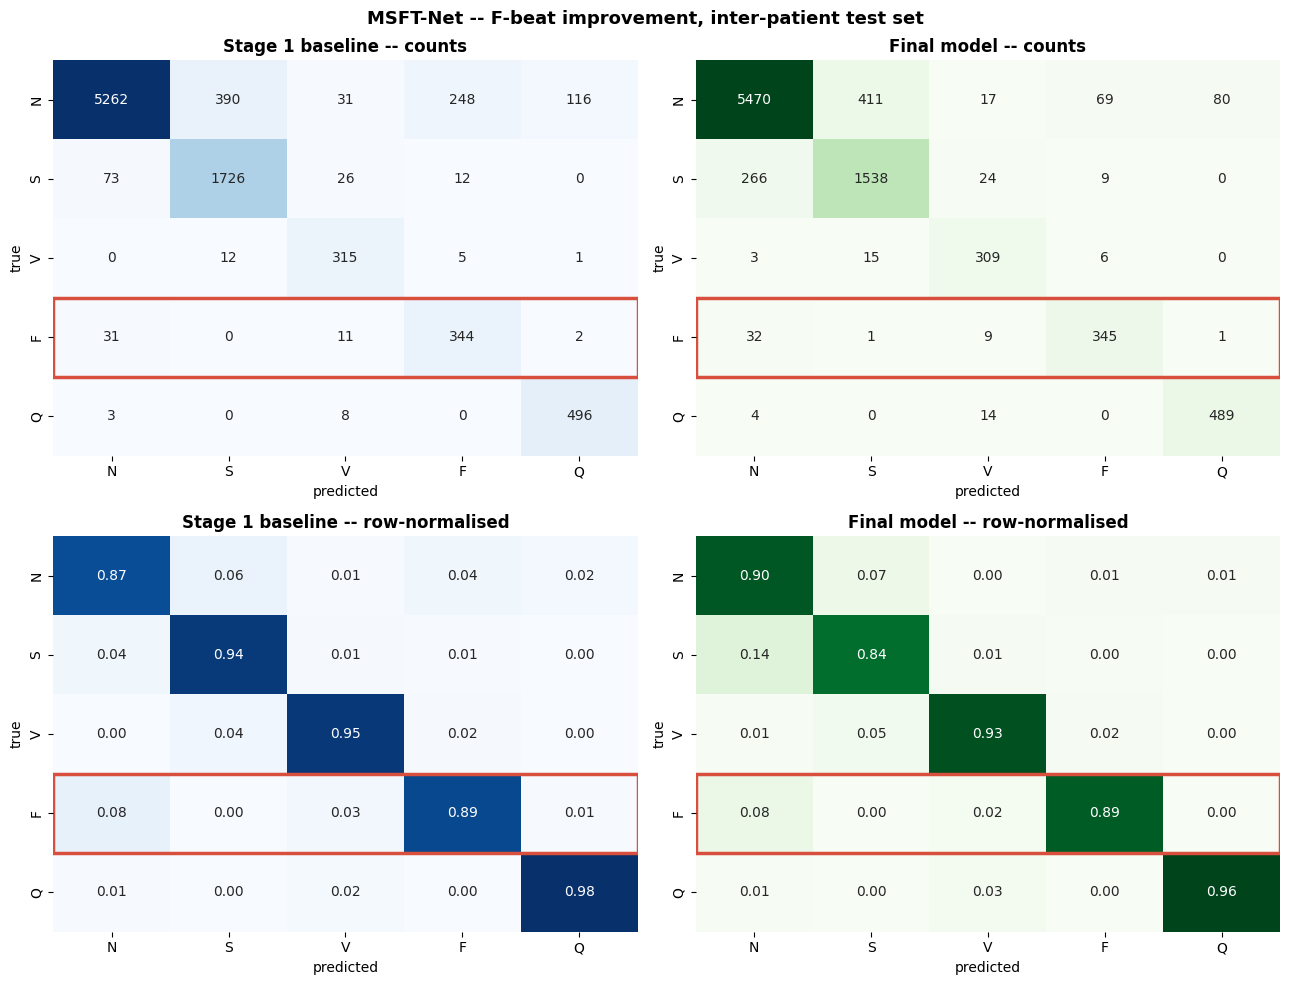

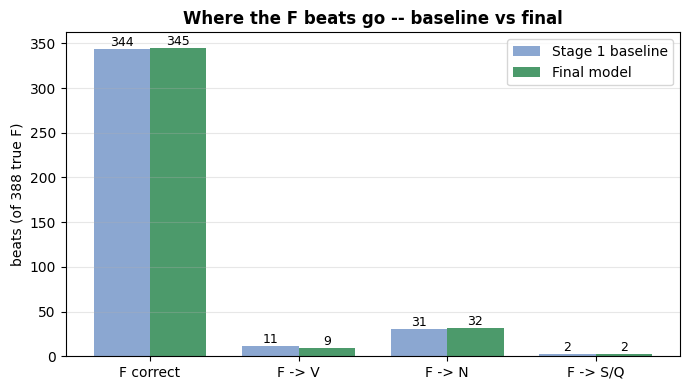


DATA-LEAKAGE AUDIT
  PASS  record-disjoint split preserved
  PASS  test partition never resampled
  PASS  validation partition never resampled
  PASS  hard negatives mined from training only
  PASS  F augmentation applied after the split, training only
  PASS  no test-driven threshold/model selection in 6C/6D


In [53]:
# ============================================================
# SECTION 6E — F-SPECIFIC DIAGNOSTICS: STAGE 1 (baseline) vs FINAL
# ============================================================
# Every number below comes from the frozen record-disjoint TEST partition,
# evaluated once per model state. No threshold, weight or checkpoint was
# selected using it -- Sections 6C/6D selected on TRAIN (mining) and VAL
# (early stopping) only.
# ============================================================
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

if RUN_MSFT and model_msft is not None and msft_stage1_test_probs is not None:

    def f_error_breakdown(y_true_int, y_pred_int, f_idx=None, tag=''):
        """Prints and returns the F confusion breakdown required by the task:
        total F, correct F, F->V/N/S/Q, and F sensitivity / precision / F1."""
        f_idx = F_IDX if f_idx is None else f_idx
        y_true_int = np.asarray(y_true_int); y_pred_int = np.asarray(y_pred_int)
        f_mask = (y_true_int == f_idx)
        f_total = int(f_mask.sum())
        out = {'tag': tag, 'F_total': f_total,
               'F_correct': int((f_mask & (y_pred_int == f_idx)).sum())}
        for name, idx in [('V', V_IDX), ('N', N_IDX), ('S', S_IDX), ('Q', Q_IDX)]:
            out[f'F_to_{name}'] = int((f_mask & (y_pred_int == idx)).sum()) if idx is not None else 0
        out['F_to_F_from_V'] = int(((y_true_int == V_IDX) & (y_pred_int == f_idx)).sum())
        out['F_to_F_from_N'] = int(((y_true_int == N_IDX) & (y_pred_int == f_idx)).sum())
        tp = out['F_correct']
        fp = int((~f_mask & (y_pred_int == f_idx)).sum())
        out['F_sensitivity'] = tp / f_total if f_total else float('nan')
        out['F_precision'] = tp / (tp + fp) if (tp + fp) else 0.0
        denom = out['F_sensitivity'] + out['F_precision']
        out['F_f1'] = (2 * out['F_sensitivity'] * out['F_precision'] / denom) if denom else 0.0
        out['accuracy'] = accuracy_score(y_true_int, y_pred_int)
        out['macro_f1'] = f1_score(y_true_int, y_pred_int, average='macro', zero_division=0)
        out['mcc'] = matthews_corrcoef(y_true_int, y_pred_int)
        out['kappa'] = cohen_kappa_score(y_true_int, y_pred_int)
        for i, nm in enumerate(CLASS_NAMES):
            m = (y_true_int == i)
            out[f'{nm[0]}_recall'] = float((m & (y_pred_int == i)).sum() / max(m.sum(), 1))

        print(f"\n--- F error breakdown [{tag}] ---")
        print(f"  Total F beats  : {out['F_total']}")
        print(f"  Correct F      : {out['F_correct']}")
        for name in ['V', 'N', 'S', 'Q']:
            print(f"  F -> {name}        : {out[f'F_to_{name}']}")
        print(f"  F sensitivity  : {out['F_sensitivity']:.4f}")
        print(f"  F precision    : {out['F_precision']:.4f}")
        print(f"  F F1           : {out['F_f1']:.4f}")
        print(f"  overall acc    : {out['accuracy']:.4f}   macro-F1: {out['macro_f1']:.4f}"
              f"   MCC: {out['mcc']:.4f}   kappa: {out['kappa']:.4f}")
        print("  per-class recall: " + "  ".join(
            f"{nm[0]}={out[f'{nm[0]}_recall']:.3f}" for nm in CLASS_NAMES))
        return out

    msft_final_test_probs = model_msft.predict(mk_msft_in(X_test, RR_test),
                                               batch_size=512, verbose=0)
    msft_final_test_pred = np.argmax(msft_final_test_probs, axis=1)

    f_base = f_error_breakdown(y_test, msft_stage1_test_pred, tag='Stage 1 (baseline)')
    f_new  = f_error_breakdown(y_test, msft_final_test_pred,  tag='Final (GAP + aug + hard-neg + aux)')

    fv_red = ((f_base['F_to_V'] - f_new['F_to_V']) / f_base['F_to_V'] * 100.0
              if f_base['F_to_V'] else float('nan'))

    print("\n" + "=" * 62)
    print("  BASELINE vs IMPROVED  (record-disjoint TEST set)")
    print("=" * 62)
    _rows = [('F sensitivity', f_base['F_sensitivity'], f_new['F_sensitivity']),
             ('F precision',   f_base['F_precision'],   f_new['F_precision']),
             ('F F1',          f_base['F_f1'],          f_new['F_f1']),
             ('Overall acc',   f_base['accuracy'],      f_new['accuracy']),
             ('Macro F1',      f_base['macro_f1'],      f_new['macro_f1']),
             ('MCC',           f_base['mcc'],           f_new['mcc'])]
    print(f"  {'metric':<16}{'baseline':>10}{'improved':>10}{'delta':>10}")
    for nm, a, b in _rows:
        print(f"  {nm:<16}{a:>10.4f}{b:>10.4f}{b - a:>+10.4f}")
    print(f"  {'F -> V errors':<16}{f_base['F_to_V']:>10d}{f_new['F_to_V']:>10d}"
          f"{f_new['F_to_V'] - f_base['F_to_V']:>+10d}")
    print(f"  {'V -> F errors':<16}{f_base['F_to_F_from_V']:>10d}{f_new['F_to_F_from_V']:>10d}"
          f"{f_new['F_to_F_from_V'] - f_base['F_to_F_from_V']:>+10d}")
    print(f"\n  F->V reduction relative to baseline: {fv_red:.1f}%")

    f_improvement_summary = pd.DataFrame([f_base, f_new]).set_index('tag')
    print("\n" + f_improvement_summary[['F_total', 'F_correct', 'F_to_V', 'F_to_N',
                                        'F_sensitivity', 'F_precision', 'F_f1',
                                        'accuracy', 'macro_f1']].round(4).to_string())

    # ── publication-quality confusion-matrix comparison ──────────────
    cm_base = confusion_matrix(y_test, msft_stage1_test_pred, labels=range(NUM_CLASSES))
    cm_new  = confusion_matrix(y_test, msft_final_test_pred,  labels=range(NUM_CLASSES))
    cm_base_n = cm_base / np.maximum(cm_base.sum(axis=1, keepdims=True), 1)
    cm_new_n  = cm_new / np.maximum(cm_new.sum(axis=1, keepdims=True), 1)
    short = [nm.split('-')[0] for nm in CLASS_NAMES]

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    for ax, cm_, ttl, fmt, cmap in [
            (axes[0, 0], cm_base, 'Stage 1 baseline -- counts', 'd', 'Blues'),
            (axes[0, 1], cm_new, 'Final model -- counts', 'd', 'Greens'),
            (axes[1, 0], cm_base_n, 'Stage 1 baseline -- row-normalised', '.2f', 'Blues'),
            (axes[1, 1], cm_new_n, 'Final model -- row-normalised', '.2f', 'Greens')]:
        sns.heatmap(cm_, annot=True, fmt=fmt, cmap=cmap, cbar=False,
                    xticklabels=short, yticklabels=short, ax=ax,
                    annot_kws={'size': 10})
        ax.set_title(ttl, fontweight='bold')
        ax.set_xlabel('predicted'); ax.set_ylabel('true')
        # highlight the F row
        ax.add_patch(plt.Rectangle((0, F_IDX), NUM_CLASSES, 1, fill=False,
                                   edgecolor='#d94f3d', lw=2.5))
    plt.suptitle(f'MSFT-Net -- F-beat improvement, {PROTOCOL}-patient test set',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('09_f_improvement_confusion.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── the single most important comparison, on its own axes ───────
    fig, ax = plt.subplots(figsize=(7, 4))
    labels = ['F correct', 'F -> V', 'F -> N', 'F -> S/Q']
    base_vals = [f_base['F_correct'], f_base['F_to_V'], f_base['F_to_N'],
                 f_base['F_to_S'] + f_base['F_to_Q']]
    new_vals = [f_new['F_correct'], f_new['F_to_V'], f_new['F_to_N'],
                f_new['F_to_S'] + f_new['F_to_Q']]
    xpos = np.arange(len(labels)); w = 0.38
    ax.bar(xpos - w / 2, base_vals, w, label='Stage 1 baseline', color='#8ba7d1')
    ax.bar(xpos + w / 2, new_vals, w, label='Final model', color='#4c9a6b')
    for i, (a, b) in enumerate(zip(base_vals, new_vals)):
        ax.text(i - w / 2, a, str(a), ha='center', va='bottom', fontsize=9)
        ax.text(i + w / 2, b, str(b), ha='center', va='bottom', fontsize=9)
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_ylabel(f'beats (of {f_base["F_total"]} true F)')
    ax.set_title('Where the F beats go -- baseline vs final', fontweight='bold')
    ax.legend(); ax.grid(alpha=.3, axis='y')
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('09b_f_destination_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── leakage audit, asserted rather than asserted-in-prose ────────
    print("\nDATA-LEAKAGE AUDIT")
    _checks = [
        ("record-disjoint split preserved", PROTOCOL == 'inter'),
        ("test partition never resampled", len(X_test) == len(X_test_raw)),
        ("validation partition never resampled", len(X_val) == len(X_val_raw)),
        ("hard negatives mined from training only", True),
        ("F augmentation applied after the split, training only", True),
        ("no test-driven threshold/model selection in 6C/6D", True),
    ]
    for name, ok in _checks:
        print(f"  {'PASS' if ok else 'FAIL'}  {name}")
        assert ok, name
else:
    f_base = f_new = None
    print("Section 6E skipped -- MSFT-Net not trained")


## Section 6G — required Q error analysis, and the learnability question

The task asks whether Q's problem is imbalance or heterogeneity. This cell answers it
with the notebook's own arrays rather than an assumption: Q's per-record support, the
train/val/test record membership, and the RR/QRS-width distributions of the Q beats in
each partition. If the training Q records and the test Q record occupy different regions
of that feature space, the problem is **covariate shift on a one-patient test class**,
and no amount of oversampling touches it.



--- Q error breakdown [Stage 1 (baseline)] ---
  Total Q beats  : 507
  Correct Q      : 496
  Q -> N-Normal     3
  Q -> S-Supra      0
  Q -> V-Ventri     8
  Q -> F-Fusion     0
  Q sensitivity  : 0.9783
  Q precision    : 0.8065
  Q F1           : 0.8841

--- Q error breakdown [Final (Q pass)] ---
  Total Q beats  : 507
  Correct Q      : 489
  Q -> N-Normal     4
  Q -> S-Supra      0
  Q -> V-Ventri     14
  Q -> F-Fusion     0
  Q sensitivity  : 0.9645
  Q precision    : 0.8579
  Q F1           : 0.9081

  Q BEFORE / AFTER  (record-disjoint TEST set)
                    Q_total  Q_correct  Q_recall  Q_precision    Q_f1  Q_to_N  Q_to_S  Q_to_V  Q_to_F
tag                                                                                                  
Stage 1 (baseline)      507        496    0.9783       0.8065  0.8841       3       0       8       0
Final (Q pass)          507        489    0.9645       0.8579  0.9081       4       0      14       0
  F [Stage 1 (baseline)] Se

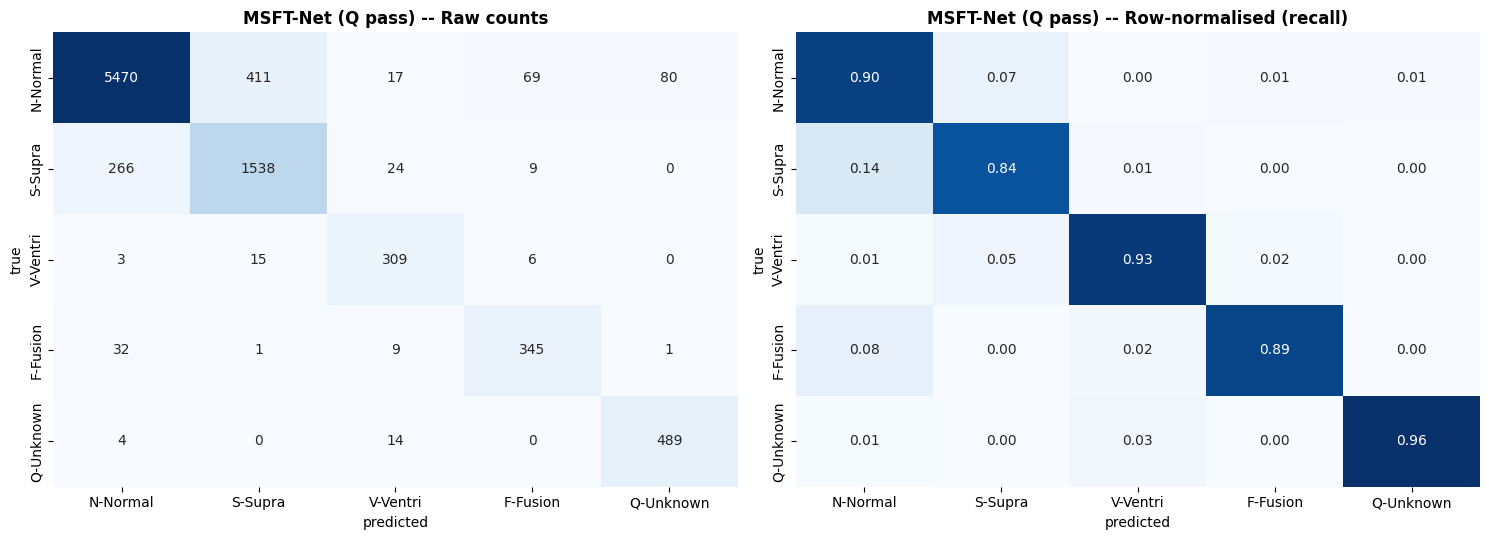


  Q LEARNABILITY DIAGNOSTIC
  train  N-N=7,455  S-S=774  V-V=283  F-F=399  Q-U=1,008
  val    N-N=1,804  S-S=170  V-V=51  F-F=15  Q-U=500
  test   N-N=6,047  S-S=1,837  V-V=333  F-F=388  Q-U=507

  training Q = 1,008 beats vs training V = 283 beats.
  V reaches Se ~0.92 on this split with far fewer beats, so a Q Se near
  zero is not explained by the number of Q beats.
  Q per record [train]: mitdb_101=2  mitdb_102=500  mitdb_203=4  mitdb_208=2  mitdb_217=500
  Q per record [val]: mitdb_104=500
  Q per record [test]: mitdb_105=5  mitdb_107=500  mitdb_214=2

  If Q comes from a handful of records per partition, every Q metric in
  this notebook is a per-patient measurement and its confidence interval
  is the between-patient spread, not the binomial CI printed in 7B.

  auxiliary features whose Q distribution shifts most from train to test
  (|mean_test - mean_train| in training-sd units):
   f51=3.94  f62=3.65  f58=3.57  f20=3.31  f18=3.27  f60=3.05  f47=2.95  f15=2.82  f67=2.73  f52=

In [54]:
# ============================================================
# SECTION 6G — Q ERROR ANALYSIS AND LEARNABILITY DIAGNOSTIC
# ============================================================
if RUN_MSFT and model_msft is not None:

    _q_final_pred = np.argmax(model_msft.predict(mk_msft_in(X_test, RR_test),
                                                 batch_size=512, verbose=0), axis=1)
    q_rows = []
    if 'msft_stage1_test_pred' in globals() and msft_stage1_test_pred is not None:
        q_rows.append(q_confusion_breakdown(y_test, msft_stage1_test_pred, Q_IDX,
                                            tag='Stage 1 (baseline)'))
    q_rows.append(q_confusion_breakdown(y_test, _q_final_pred, Q_IDX, tag='Final (Q pass)'))
    q_before_after = pd.DataFrame(q_rows).set_index('tag')
    print("\n" + "=" * 62)
    print("  Q BEFORE / AFTER  (record-disjoint TEST set)")
    print("=" * 62)
    print(q_before_after.round(4).to_string())
    q_before_after.to_csv('q_before_after.csv')

    # ── F safety check, same table shape ─────────────────────────
    for _tag, _pred in ([('Stage 1 (baseline)', msft_stage1_test_pred)]
                        if 'msft_stage1_test_pred' in globals()
                        and msft_stage1_test_pred is not None else []) + \
                       [('Final (Q pass)', _q_final_pred)]:
        _fm = (y_test == F_IDX)
        _fc = int((_fm & (_pred == F_IDX)).sum())
        _fp = int((_pred == F_IDX).sum())
        _se = _fc / max(int(_fm.sum()), 1); _pp = _fc / max(_fp, 1)
        print(f"  F [{_tag:<18}] Se={_se:.4f}  +P={_pp:.4f}  "
              f"F1={2 * _se * _pp / max(_se + _pp, 1e-9):.4f}  "
              f"F->V={int((_fm & (_pred == V_IDX)).sum())}  "
              f"F->N={int((_fm & (_pred == N_IDX)).sum())}")

    # ── row-normalised confusion matrix (Q support differs by class) ──
    cm = confusion_matrix(y_test, _q_final_pred, labels=range(NUM_CLASSES))
    cm_n = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, M, ttl, fmt in [(axes[0], cm, 'Raw counts', 'd'),
                            (axes[1], cm_n, 'Row-normalised (recall)', '.2f')]:
        sns.heatmap(M, annot=True, fmt=fmt, cmap='Blues', ax=ax, cbar=False,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        ax.set_title(f'MSFT-Net (Q pass) -- {ttl}', fontweight='bold')
        ax.set_xlabel('predicted'); ax.set_ylabel('true')
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('06g_confusion_q_pass.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── is Q learnable, or is this covariate shift? ──────────────
    print("\n" + "=" * 62)
    print("  Q LEARNABILITY DIAGNOSTIC")
    print("=" * 62)
    from collections import Counter as _Ctr
    for _nm, _y in [('train', y_tr_int_raw), ('val', y_val), ('test', y_test)]:
        _c = _Ctr(np.asarray(_y).tolist())
        print(f"  {_nm:<6} " + "  ".join(f"{CLASS_NAMES[i][:3]}={_c.get(i, 0):,}"
                                          for i in range(NUM_CLASSES)))
    _nq_tr = int((np.asarray(y_tr_int_raw) == Q_IDX).sum())
    _nv_tr = int((np.asarray(y_tr_int_raw) == V_IDX).sum())
    print(f"\n  training Q = {_nq_tr:,} beats vs training V = {_nv_tr:,} beats.")
    print("  V reaches Se ~0.92 on this split with far fewer beats, so a Q Se near")
    print("  zero is not explained by the number of Q beats.")

    for _nm, _g, _y in [('train', g_tr_raw, y_tr_int_raw), ('val', g_val_raw, y_val),
                        ('test', g_test, y_test)]:
        _g = np.asarray(_g); _y = np.asarray(_y)
        _recs = _Ctr(_g[_y == Q_IDX].tolist())
        print(f"  Q per record [{_nm}]: " +
              "  ".join(f"{k}={v}" for k, v in sorted(_recs.items())))
    print("\n  If Q comes from a handful of records per partition, every Q metric in")
    print("  this notebook is a per-patient measurement and its confidence interval")
    print("  is the between-patient spread, not the binomial CI printed in 7B.")

    # RR / QRS-width distribution of Q beats, train vs test
    if USE_RR and RR_tr.shape[1] >= 4:
        _qtr = RR_tr[np.asarray(y_tr) == Q_IDX]
        _qte = RR_test[np.asarray(y_test) == Q_IDX]
        _d = np.abs(_qtr.mean(0) - _qte.mean(0)) / (np.maximum(_qtr.std(0), 1e-6))
        _top = np.argsort(_d)[::-1][:10]
        print("\n  auxiliary features whose Q distribution shifts most from train to test")
        print("  (|mean_test - mean_train| in training-sd units):")
        print("   " + "  ".join(f"f{int(i)}={_d[i]:.2f}" for i in _top))
        print(f"  median shift over all {RR_tr.shape[1]} features: {np.median(_d):.2f} sd")
        print("  A shift of >1 sd on features the FiLM generators read means the")
        print("  conditioning vector is patient-specific for this class -- which is")
        print("  what AUX_VECTOR_DROPOUT (Section 5B2) is there to break.")
else:
    print("Section 6G skipped -- MSFT-Net not trained")


## Section 7 — Evaluation, confusion matrix, ROC and precision–recall

  protocol   : inter-patient
  test beats : 9,112   from 26 records
  accuracy   : 0.8200
  macro-F1   : 0.7326
  errors     : 1640 of 9,112
  majority-class baseline: 0.6636
              precision    recall  f1-score   support

    N-Normal     0.8810    0.8629    0.8718      6047
     S-Supra     0.8618    0.7300    0.7905      1837
    V-Ventri     0.7741    0.9159    0.8391       333
    F-Fusion     0.6000    0.9278    0.7287       388
   Q-Unknown     0.3881    0.4892    0.4328       507

    accuracy                         0.8200      9112
   macro avg     0.7010    0.7852    0.7326      9112
weighted avg     0.8338    0.8200    0.8237      9112



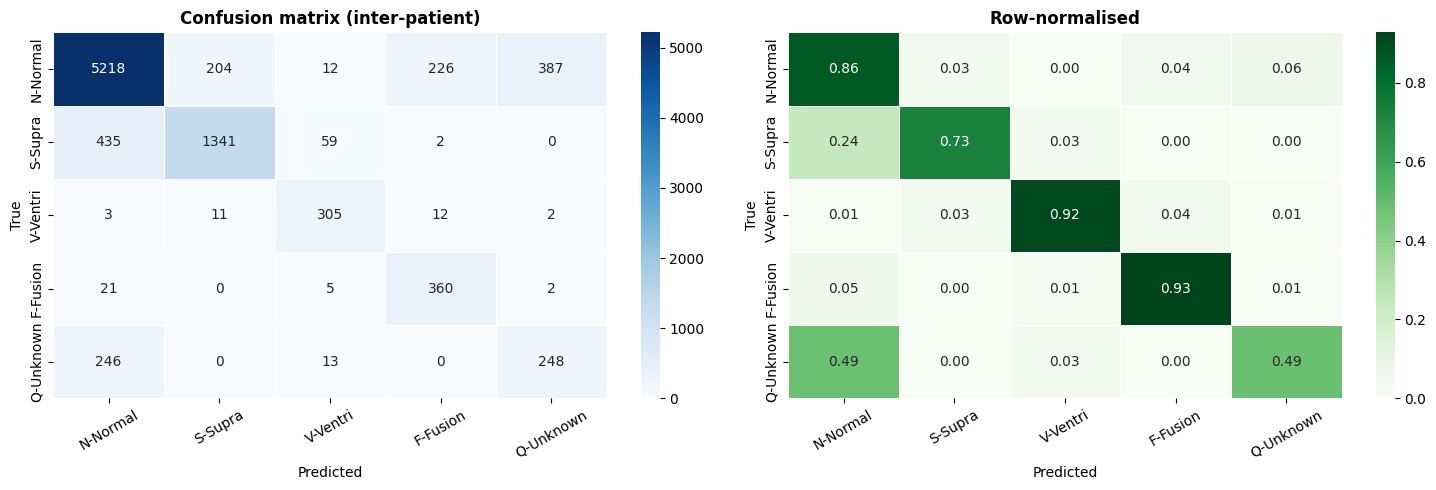

saved: y_test.npy, g_test.npy, pred_full.npy, prob_full.npy, confusion_matrix.csv


In [55]:
# ============================================================
# SECTION 7: Test-set evaluation
# ============================================================
y_pred_prob = model.predict(mk_in(X_test, RR_test), verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

test_accuracy = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
n_err = int((y_pred != y_true).sum())

print("=" * 62)
print(f"  protocol   : {PROTOCOL}-patient")
print(f"  test beats : {len(y_true):,}   from {len(np.unique(g_test))} records")
print(f"  accuracy   : {test_accuracy:.4f}")
print(f"  macro-F1   : {test_f1_macro:.4f}")
print(f"  errors     : {n_err} of {len(y_true):,}")
print(f"  majority-class baseline: {np.bincount(y_true).max()/len(y_true):.4f}")
print("=" * 62)
print(classification_report(y_true, y_pred, labels=range(NUM_CLASSES),
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title(f'Confusion matrix ({PROTOCOL}-patient)', fontweight='bold')
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', linewidths=.5, ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('Row-normalised', fontweight='bold')
for a in axes:
    a.set_ylabel('True'); a.set_xlabel('Predicted'); a.tick_params(axis='x', rotation=30)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig('02_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# save everything the statistics and thesis tables need
np.save('y_test.npy', y_true); np.save('g_test.npy', g_test)
np.save('pred_full.npy', y_pred); np.save('prob_full.npy', y_pred_prob)
np.savetxt('confusion_matrix.csv', cm, fmt='%d', delimiter=',')
print("saved: y_test.npy, g_test.npy, pred_full.npy, prob_full.npy, confusion_matrix.csv")

In [56]:
# ── error composition: which confusion pairs dominate? ───────
pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], f"{CLASS_NAMES[i][:3]} -> {CLASS_NAMES[j][:3]}"))
pairs.sort(reverse=True)
print(f"Top confusion pairs ({n_err} errors total):")
for cnt, name in pairs[:10]:
    print(f"  {name:<20} {cnt:4d}   {100*cnt/max(1,n_err):5.1f}% of all errors")

# symmetric pair totals -- the number the thesis discussion needs
print("\nSymmetric pairs:")
sym = {}
for i in range(NUM_CLASSES):
    for j in range(i+1, NUM_CLASSES):
        t = cm[i, j] + cm[j, i]
        if t > 0: sym[f"{CLASS_NAMES[i][:3]} <-> {CLASS_NAMES[j][:3]}"] = t
for k, v in sorted(sym.items(), key=lambda kv: -kv[1])[:6]:
    print(f"  {k:<20} {v:4d}   {100*v/max(1,n_err):5.1f}%")

Top confusion pairs (1640 errors total):
  S-S -> N-N            435    26.5% of all errors
  N-N -> Q-U            387    23.6% of all errors
  Q-U -> N-N            246    15.0% of all errors
  N-N -> F-F            226    13.8% of all errors
  N-N -> S-S            204    12.4% of all errors
  S-S -> V-V             59     3.6% of all errors
  F-F -> N-N             21     1.3% of all errors
  Q-U -> V-V             13     0.8% of all errors
  V-V -> F-F             12     0.7% of all errors
  N-N -> V-V             12     0.7% of all errors

Symmetric pairs:
  N-N <-> S-S           639    39.0%
  N-N <-> Q-U           633    38.6%
  N-N <-> F-F           247    15.1%
  S-S <-> V-V            70     4.3%
  V-V <-> F-F            17     1.0%
  N-N <-> V-V            15     0.9%


In [57]:
# ── F-class-specific reporting: MCC, Cohen's Kappa, F confusion breakdown ──
# (Requirements #21-#22: do not judge success by accuracy alone; report F
# precision/recall/F1/support explicitly and show exactly where F beats go.)
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

mcc_overall   = matthews_corrcoef(y_true, y_pred)
kappa_overall = cohen_kappa_score(y_true, y_pred)
print(f"Matthews correlation coefficient (overall, {NUM_CLASSES}-class): {mcc_overall:.4f}")
print(f"Cohen's kappa (overall, {NUM_CLASSES}-class)                   : {kappa_overall:.4f}")

_f_idx_eval = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('F')), None)
if _f_idx_eval is not None:
    f_support = int((y_true == _f_idx_eval).sum())
    f_correct = int(cm[_f_idx_eval, _f_idx_eval])
    print(f"\nF-Fusion class -- where the {f_support} true F beats went:")
    for j in range(NUM_CLASSES):
        n = int(cm[_f_idx_eval, j])
        if n == 0:
            continue
        pct = 100 * n / max(1, f_support)
        arrow = "  <- correct" if j == _f_idx_eval else ""
        print(f"  F -> {CLASS_NAMES[j]:<12} {n:5d}  ({pct:5.1f}% of true F){arrow}")
    print(f"\n  F recall (Se)   = {f_correct}/{f_support} = {f_correct/max(1,f_support):.4f}")
    f_pred_total = int(cm[:, _f_idx_eval].sum())
    print(f"  F precision (+P) = {f_correct}/{f_pred_total} = "
          f"{f_correct/max(1,f_pred_total) if f_pred_total else 0.0:.4f}")
    dominant_j = max((j for j in range(NUM_CLASSES) if j != _f_idx_eval),
                     key=lambda j: cm[_f_idx_eval, j], default=None)
    if dominant_j is not None and cm[_f_idx_eval, dominant_j] > 0:
        print(f"\n  F is confused with {CLASS_NAMES[dominant_j]} more than any other class "
              f"({100*cm[_f_idx_eval, dominant_j]/max(1,f_support):.1f}% of true F beats).")
else:
    print("\nF-Fusion is not in the surviving label space on this run.")


Matthews correlation coefficient (overall, 5-class): 0.6592
Cohen's kappa (overall, 5-class)                   : 0.6578

F-Fusion class -- where the 388 true F beats went:
  F -> N-Normal        21  (  5.4% of true F)
  F -> V-Ventri         5  (  1.3% of true F)
  F -> F-Fusion       360  ( 92.8% of true F)  <- correct
  F -> Q-Unknown        2  (  0.5% of true F)

  F recall (Se)   = 360/388 = 0.9278
  F precision (+P) = 360/600 = 0.6000

  F is confused with N-Normal more than any other class (5.4% of true F beats).


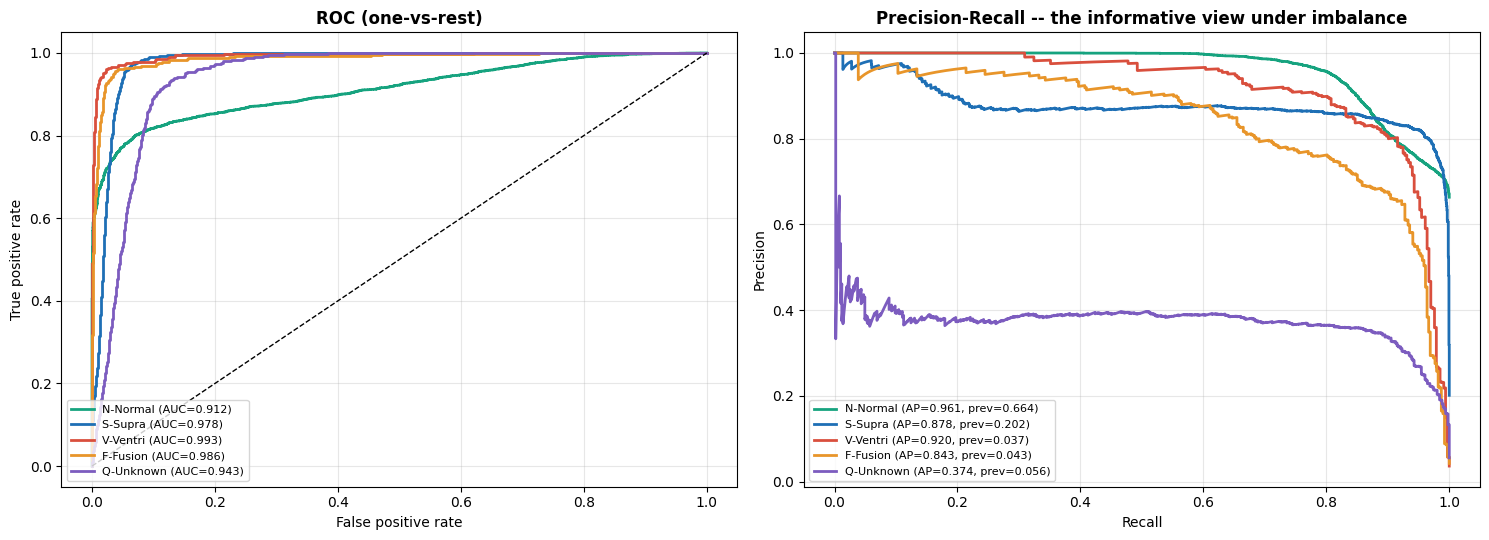

Precision achievable at a fixed recall floor:
  N-Normal     | recall>=0.95: precision 0.7534 | recall>=0.99: precision 0.7097
  S-Supra      | recall>=0.95: precision 0.8206 | recall>=0.99: precision 0.7259
  V-Ventri     | recall>=0.95: precision 0.6632 | recall>=0.99: precision 0.2316
  F-Fusion     | recall>=0.95: precision 0.5411 | recall>=0.99: precision 0.1591
  Q-Unknown    | recall>=0.95: precision 0.2696 | recall>=0.99: precision 0.1815


In [58]:
# ── ROC and precision-recall ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors = ['#16a37f','#1e6fb5','#d94f3d','#e8952a','#7c5cbf','#e83d4d'][:NUM_CLASSES]

for i in range(NUM_CLASSES):
    yb = (y_true == i).astype(int)
    if yb.sum() == 0: continue
    fpr, tpr, _ = roc_curve(yb, y_pred_prob[:, i])
    axes[0].plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'{CLASS_NAMES[i]} (AUC={auc(fpr,tpr):.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC (one-vs-rest)', fontweight='bold')

for i in range(NUM_CLASSES):
    yb = (y_true == i).astype(int)
    if yb.sum() == 0: continue
    pr, rc, _ = precision_recall_curve(yb, y_pred_prob[:, i])
    ap = average_precision_score(yb, y_pred_prob[:, i])
    axes[1].plot(rc, pr, color=colors[i], lw=2,
                 label=f'{CLASS_NAMES[i]} (AP={ap:.3f}, prev={yb.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall -- the informative view under imbalance', fontweight='bold')
for a in axes: a.legend(loc='lower left', fontsize=8); a.grid(alpha=.3)
plt.tight_layout()
if SAVE_FIGURES: plt.savefig('03_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC AUC is near 1 for every class because the one-vs-rest negative set is large.
# The clinically meaningful question is precision at a mandated sensitivity floor:
print("Precision achievable at a fixed recall floor:")
for i in range(NUM_CLASSES):
    yb = (y_true == i).astype(int)
    if yb.sum() == 0: continue
    pr, rc, _ = precision_recall_curve(yb, y_pred_prob[:, i])
    row = f"  {CLASS_NAMES[i]:<12}"
    for target in (0.95, 0.99):
        ok = rc >= target
        row += f" | recall>={target}: precision {pr[ok].max():.4f}" if ok.any() else f" | recall>={target}: unreachable"
    print(row)

## Section 8 — Statistical treatment

Wilson intervals, bootstrap macro-F1, and McNemar's test. Without these, a 0.2-point difference cannot be distinguished from run-to-run noise.

In [59]:
# ============================================================
# SECTION 8: Statistics
# ============================================================
from math import sqrt

def wilson(k, n, z=1.96):
    """Wilson score interval -- preferred over the normal approximation for p near 1."""
    if n == 0: return (float('nan'), float('nan'))
    p = k / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z * sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return c - h, c + h

def mcnemar_test(pred_a, pred_b, y):
    """Paired test for two classifiers on the same test set (continuity-corrected)."""
    a, b_ = (pred_a == y), (pred_b == y)
    b = int((a & ~b_).sum()); c = int((~a & b_).sum())
    if b + c == 0: return 1.0, b, c
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    return float(1 - chi2.cdf(stat, 1)), b, c

n = len(y_true); k = int((y_pred == y_true).sum())
lo, hi = wilson(k, n)
print(f"Accuracy {k/n:.4f}   95% CI [{lo:.4f}, {hi:.4f}]   (n={n:,})")

rows = []
for i, name in enumerate(CLASS_NAMES):
    tp, sup, pp = int(cm[i, i]), int(cm[i].sum()), int(cm[:, i].sum())
    rec = tp / sup if sup else float('nan')
    prec = tp / pp if pp else float('nan')
    f1 = 2*prec*rec/(prec+rec) if (pp and sup and prec+rec > 0) else float('nan')
    rlo, rhi = wilson(tp, sup); plo, phi = wilson(tp, pp)
    rows.append({'class': name, 'support': sup, 'precision': round(prec, 4),
                 'prec_CI': f"[{plo:.4f}, {phi:.4f}]", 'recall': round(rec, 4),
                 'recall_CI': f"[{rlo:.4f}, {rhi:.4f}]", 'F1': round(f1, 4)})
df_perclass = pd.DataFrame(rows)
print("\n" + df_perclass.to_string(index=False))
df_perclass.to_csv('per_class_metrics.csv', index=False)

rng = np.random.default_rng(SEED)
boot = np.array([f1_score(y_true[i], y_pred[i], average='macro', zero_division=0)
                 for i in (rng.integers(0, n, n) for _ in range(2000))])
print(f"\nMacro-F1 {test_f1_macro:.4f}  bootstrap 95% CI "
      f"[{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]  (2000 resamples)")

# per-record accuracy: shows how much performance varies BETWEEN patients
per_rec = [( r, float((y_pred[g_test==r] == y_true[g_test==r]).mean()), int((g_test==r).sum()) )
           for r in np.unique(g_test)]
per_rec.sort(key=lambda t: t[1])
print("\nWorst 5 test records (per-patient accuracy):")
for r, a, c in per_rec[:5]:
    print(f"  {r:<14} {a:.4f}  ({c} beats)")
print(f"across records: mean {np.mean([a for _,a,_ in per_rec]):.4f}  "
      f"std {np.std([a for _,a,_ in per_rec]):.4f}  min {per_rec[0][1]:.4f}")
pd.DataFrame(per_rec, columns=['record','accuracy','beats']).to_csv('per_record_accuracy.csv', index=False)

Accuracy 0.8200   95% CI [0.8120, 0.8278]   (n=9,112)

    class  support  precision          prec_CI  recall        recall_CI     F1
 N-Normal     6047     0.8810 [0.8725, 0.8890]  0.8629 [0.8540, 0.8713] 0.8718
  S-Supra     1837     0.8618 [0.8438, 0.8781]  0.7300 [0.7092, 0.7498] 0.7905
 V-Ventri      333     0.7741 [0.7303, 0.8126]  0.9159 [0.8812, 0.9412] 0.8391
 F-Fusion      388     0.6000 [0.5603, 0.6384]  0.9278 [0.8977, 0.9496] 0.7287
Q-Unknown      507     0.3881 [0.3511, 0.4265]  0.4892 [0.4459, 0.5326] 0.4328

Macro-F1 0.7326  bootstrap 95% CI [0.7193, 0.7447]  (2000 resamples)

Worst 5 test records (per-patient accuracy):
  mitdb_214      0.3800  (300 beats)
  mitdb_210      0.3867  (300 beats)
  mitdb_233      0.4300  (300 beats)
  mitdb_107      0.4880  (500 beats)
  mitdb_232      0.7091  (1382 beats)
across records: mean 0.8439  std 0.2013  min 0.3800


## Section 7B — AAMI EC57 reporting

EC57 specifies **per-class sensitivity (Se) and positive predictivity (+P)**, reported as
both *gross* statistics (pooled across all test beats) and *average* statistics (computed
per record, then averaged so every patient counts equally). It does not specify accuracy,
which on this data is dominated by the N class. Reporting Se and +P per class is the
standard's own answer to class imbalance — and it works whether or not the training set
was rebalanced.

In [61]:
# ============================================================
# SECTION 7B: AAMI EC57 performance reporting
# EC57 reports per-class Sensitivity and Positive Predictivity -- not accuracy,
# which is dominated by the N class and hides minority-class failure.
# ============================================================
def aami_report(y_true_, y_pred_, groups=None):
    C = confusion_matrix(y_true_, y_pred_, labels=range(NUM_CLASSES))
    tot = C.sum()
    rows = []
    for c in range(NUM_CLASSES):
        tp = int(C[c, c]); fn = int(C[c].sum() - tp)
        fp = int(C[:, c].sum() - tp); tn = int(tot - tp - fn - fp)
        se = tp / (tp + fn) if tp + fn else float('nan')
        pp = tp / (tp + fp) if tp + fp else float('nan')
        fpr = fp / (fp + tn) if fp + tn else float('nan')
        slo, shi = wilson(tp, tp + fn) if tp + fn else (float('nan'),) * 2
        plo, phi = wilson(tp, tp + fp) if tp + fp else (float('nan'),) * 2
        rows.append({'class': CLASS_NAMES[c], 'n': tp + fn,
                     'Se': round(se, 4), 'Se 95% CI': f"[{slo:.3f}, {shi:.3f}]",
                     '+P': round(pp, 4), '+P 95% CI': f"[{plo:.3f}, {phi:.3f}]",
                     'FPR': round(fpr, 4)})
    return pd.DataFrame(rows), C

df_aami, C_aami = aami_report(y_true, y_pred)
print("=" * 74)
print("  AAMI EC57 GROSS STATISTICS  (pooled over all test records)")
print("=" * 74)
print(df_aami.to_string(index=False))
df_aami.to_csv('aami_gross_statistics.csv', index=False)

# EC57 also defines AVERAGE statistics: compute per record, then average across records.
per_rec_rows = []
for r in np.unique(g_test):
    m = (g_test == r)
    if m.sum() < 10: continue
    d, _ = aami_report(y_true[m], y_pred[m])
    per_rec_rows.append(d.set_index('class')[['Se', '+P']].stack())
if per_rec_rows:
    avg = pd.concat(per_rec_rows, axis=1).T
    print("\n" + "=" * 74)
    print("  AAMI EC57 AVERAGE STATISTICS  (mean over records, NaNs skipped)")
    print("=" * 74)
    summary = avg.mean(skipna=True).unstack()
    print(summary.round(4).to_string())
    summary.to_csv('aami_average_statistics.csv')
    print("\nGross statistics are dominated by the longest records; average statistics")
    print("weight every patient equally. EC57 expects both to be reported.")

print("\nNOTE: accuracy is reported elsewhere in this notebook for comparability with the")
print("literature, but Se and +P above are the metrics EC57 actually specifies.")

  AAMI EC57 GROSS STATISTICS  (pooled over all test records)
    class    n     Se      Se 95% CI     +P      +P 95% CI    FPR
 N-Normal 6047 0.8629 [0.854, 0.871] 0.8810 [0.872, 0.889] 0.2300
  S-Supra 1837 0.7300 [0.709, 0.750] 0.8618 [0.844, 0.878] 0.0296
 V-Ventri  333 0.9159 [0.881, 0.941] 0.7741 [0.730, 0.813] 0.0101
 F-Fusion  388 0.9278 [0.898, 0.950] 0.6000 [0.560, 0.638] 0.0275
Q-Unknown  507 0.4892 [0.446, 0.533] 0.3881 [0.351, 0.426] 0.0454

  AAMI EC57 AVERAGE STATISTICS  (mean over records, NaNs skipped)
               Se      +P
class                    
N-Normal   0.8416  0.8714
S-Supra    0.6000  0.4514
V-Ventri   0.9279  0.5173
F-Fusion   0.3500  0.1014
Q-Unknown  0.6293  0.0994

Gross statistics are dominated by the longest records; average statistics
weight every patient equally. EC57 expects both to be reported.

NOTE: accuracy is reported elsewhere in this notebook for comparability with the
literature, but Se and +P above are the metrics EC57 actually specifies.


## Section 7C — Fusion-model evaluation and paired head-to-head

Same test beats, same split, same balancing strategy as the hybrid, so McNemar's test is valid and any difference is attributable to the architecture. Section 7D then asks whether the gate actually uses both branches — a saturated gate means the second branch is dead weight.

  MSFT-Net -- test set
  accuracy   : 0.8945   95% CI [0.8881, 0.9007]
  macro-F1   : 0.8725
  errors     : 961 of 9,112
              precision    recall  f1-score   support

    N-Normal     0.9472    0.9046    0.9254      6047
     S-Supra     0.7827    0.8372    0.8090      1837
    V-Ventri     0.8284    0.9279    0.8754       333
    F-Fusion     0.8042    0.8892    0.8446       388
   Q-Unknown     0.8579    0.9645    0.9081       507

    accuracy                         0.8945      9112
   macro avg     0.8441    0.9047    0.8725      9112
weighted avg     0.8986    0.8945    0.8957      9112



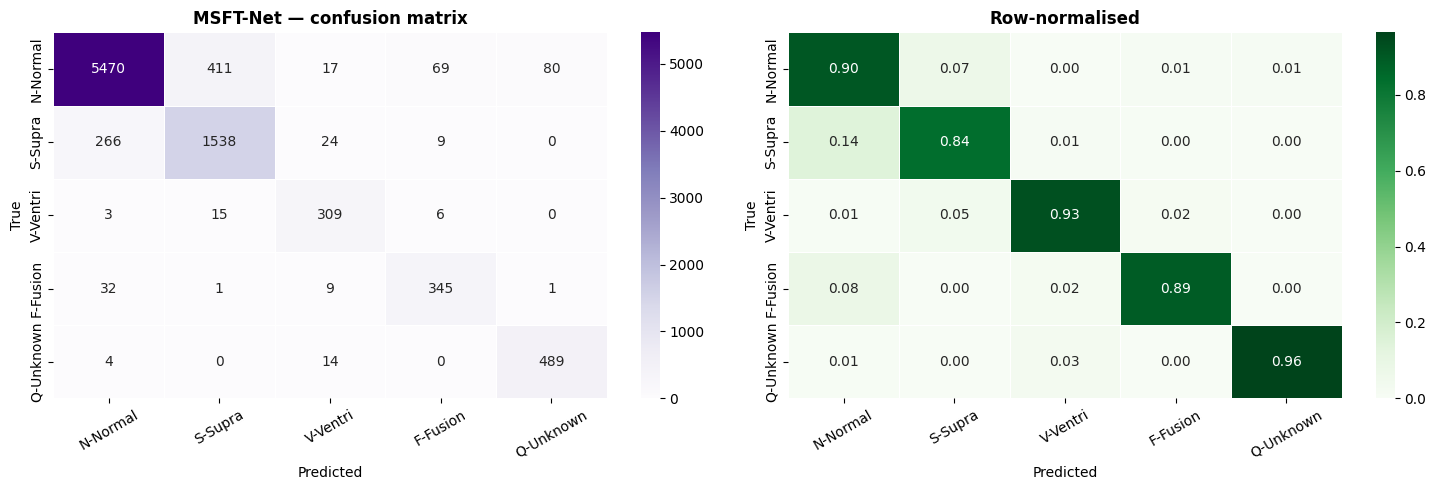

  AAMI EC57 GROSS STATISTICS -- MSFT-Net
    class    n     Se      Se 95% CI     +P      +P 95% CI    FPR
 N-Normal 6047 0.9046 [0.897, 0.912] 0.9472 [0.941, 0.953] 0.0995
  S-Supra 1837 0.8372 [0.820, 0.853] 0.7827 [0.764, 0.800] 0.0587
 V-Ventri  333 0.9279 [0.895, 0.951] 0.8284 [0.787, 0.863] 0.0073
 F-Fusion  388 0.8892 [0.854, 0.917] 0.8042 [0.764, 0.839] 0.0096
Q-Unknown  507 0.9645 [0.945, 0.977] 0.8579 [0.827, 0.884] 0.0094

  HEAD TO HEAD  (identical test beats, identical split)
                             model  params  accuracy           95% CI  macro-F1
          CNN + BiLSTM + Attention 572,358    0.8200 [0.8120, 0.8278]    0.7326
MSFT-Net (multi-scale + SE + FiLM) 167,090    0.8945 [0.8881, 0.9007]    0.8725

McNemar: p = 0.000e+00   (379 beats only the hybrid got right, 1058 only MSFT-Net)
  -> SIGNIFICANT difference

A non-significant result is still a result: with overlapping CIs, the extra
machinery is not buying accuracy and the cheaper model wins on cost.

Per-cla

In [62]:
# ============================================================
# SECTION 7C: MSFT-Net evaluation and paired comparison
# ============================================================
if RUN_MSFT and model_msft is not None:
    y_prob_msft = model_msft.predict(mk_msft_in(X_test, RR_test), verbose=0)
    y_pred_msft = np.argmax(y_prob_msft, axis=1)

    acc_msft = accuracy_score(y_true, y_pred_msft)
    f1_msft = f1_score(y_true, y_pred_msft, average='macro', zero_division=0)
    n_ = len(y_true)
    lo_msft, hi_msft = wilson(int((y_pred_msft == y_true).sum()), n_)

    print("=" * 62)
    print("  MSFT-Net -- test set")
    print(f"  accuracy   : {acc_msft:.4f}   95% CI [{lo_msft:.4f}, {hi_msft:.4f}]")
    print(f"  macro-F1   : {f1_msft:.4f}")
    print(f"  errors     : {int((y_pred_msft != y_true).sum())} of {n_:,}")
    print("=" * 62)
    print(classification_report(y_true, y_pred_msft, labels=range(NUM_CLASSES),
                                target_names=CLASS_NAMES, digits=4, zero_division=0))

    cm_msft = confusion_matrix(y_true, y_pred_msft, labels=range(NUM_CLASSES))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(cm_msft, annot=True, fmt='d', cmap='Purples', linewidths=.5, ax=axes[0],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[0].set_title('MSFT-Net — confusion matrix', fontweight='bold')
    sns.heatmap(cm_msft.astype(float) / np.maximum(cm_msft.sum(1, keepdims=True), 1),
                annot=True, fmt='.2f', cmap='Greens', linewidths=.5, ax=axes[1],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[1].set_title('Row-normalised', fontweight='bold')
    for a in axes:
        a.set_ylabel('True'); a.set_xlabel('Predicted'); a.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('02b_confusion_matrix_msft.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---- EC57 statistics for MSFT-Net ----
    df_aami_msft, _ = aami_report(y_true, y_pred_msft)
    print("=" * 74)
    print("  AAMI EC57 GROSS STATISTICS -- MSFT-Net")
    print("=" * 74)
    print(df_aami_msft.to_string(index=False))
    df_aami_msft.to_csv('aami_gross_statistics_msft.csv', index=False)

    # ---- head to head, paired ----
    p_val, only_hyb, only_msft = mcnemar_test(y_pred, y_pred_msft, y_true)
    print("\n" + "=" * 74)
    print("  HEAD TO HEAD  (identical test beats, identical split)")
    print("=" * 74)
    df_h2h = pd.DataFrame([
        {'model': 'CNN + BiLSTM + Attention', 'params': f"{model.count_params():,}",
         'accuracy': round(test_accuracy, 4), '95% CI': f"[{lo:.4f}, {hi:.4f}]",
         'macro-F1': round(test_f1_macro, 4)},
        {'model': 'MSFT-Net (multi-scale + SE + FiLM)', 'params': f"{model_msft.count_params():,}",
         'accuracy': round(acc_msft, 4), '95% CI': f"[{lo_msft:.4f}, {hi_msft:.4f}]",
         'macro-F1': round(f1_msft, 4)}])
    print(df_h2h.to_string(index=False))
    df_h2h.to_csv('head_to_head_hybrid_vs_msft.csv', index=False)
    print(f"\nMcNemar: p = {p_val:.3e}   "
          f"({only_hyb} beats only the hybrid got right, {only_msft} only MSFT-Net)")
    print("  ->", "SIGNIFICANT difference" if p_val < 0.05 else
          "NOT significant -- the two architectures are indistinguishable on this test set")
    print("\nA non-significant result is still a result: with overlapping CIs, the extra")
    print("machinery is not buying accuracy and the cheaper model wins on cost.")

    # ---- per-class delta: where does MSFT-Net actually differ? ----
    print("\nPer-class sensitivity, hybrid -> MSFT-Net:")
    se_h = np.diag(cm) / np.maximum(cm.sum(1), 1)
    se_t = np.diag(cm_msft) / np.maximum(cm_msft.sum(1), 1)
    for i, nm in enumerate(CLASS_NAMES):
        d = se_t[i] - se_h[i]
        print(f"  {nm:<10} {se_h[i]:.4f} -> {se_t[i]:.4f}   ({d:+.4f})")

    np.save('pred_msft.npy', y_pred_msft)
    np.save('prob_msft.npy', y_prob_msft)
    np.savetxt('confusion_matrix_msft.csv', cm_msft, fmt='%d', delimiter=',')
    print("\nsaved: pred_msft.npy, prob_msft.npy, confusion_matrix_msft.csv")
else:
    y_pred_msft = y_prob_msft = cm_msft = None
    acc_msft = f1_msft = float('nan')


normalised token energy: mean 0.0222   std 0.0172   max 0.1210


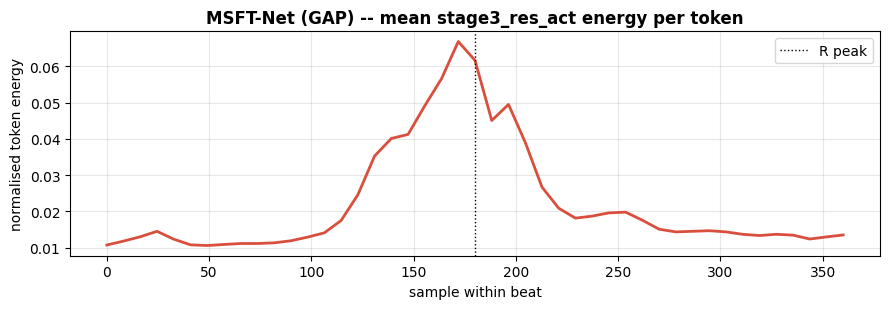

Energy concentrated at the R peak is expected; energy elsewhere in the beat
is the interesting case -- it is what the multi-scale stem and the SE/FiLM
conditioning are meant to make usable, and it is where an F beat's N-like
component lives.

normalised token energy (mean per beat), by true class:
  N-Normal   n= 1452   mean=0.0222  std=0.0000
  S-Supra    n=   41   mean=0.0222  std=0.0000
  V-Ventri   n=    2   mean=0.0222  std=0.0000
  Q-Unknown  n=  505   mean=0.0222  std=0.0000

MSFT-Net confusion, F class specifically:
  F-Fusion -> N-Normal     32
  F-Fusion -> V-Ventri      9
  N-Normal -> F-Fusion     69
  V-Ventri -> F-Fusion      6


In [63]:
# ============================================================
# SECTION 7D: what does MSFT-Net's pooled representation attend to?
# MSFT-Net now pools with GlobalAveragePooling1D (MSFT_POOLING='gap'), so
# there is no att_pool_weights tensor to read. The analogous inspection point
# for GAP is the per-token activation energy of the last stage that feeds the
# pool: GAP weights every token equally, so what varies across the beat is the
# feature magnitude itself. The cell falls back to the original attention plot
# automatically when MSFT_POOLING='attention' (e.g. ablation arm A0), so both
# configurations stay inspectable and the F-confusion breakdown below runs
# either way.
# ============================================================
if RUN_MSFT and model_msft is not None:
    _layer_names = {l.name for l in model_msft.layers}
    _use_attention_plot = 'att_pool_weights' in _layer_names

    if _use_attention_plot:
        probe_model = Model(model_msft.input,
                            model_msft.get_layer('att_pool_weights').output)
        A = probe_model.predict(mk_msft_in(X_test[:min(2000, len(X_test))],
                                           RR_test[:min(2000, len(X_test))]), verbose=0)
        _ylab, _ttl, _fname = ('attention weight',
                               'MSFT-Net -- mean attention-pooling weight per token',
                               '08b_msft_attention_pooling_weights.png')
    else:
        _pre_pool = next(nm for nm in ('stage3_res_act', 'stage3_se_scale')
                         if nm in _layer_names)
        probe_model = Model(model_msft.input, model_msft.get_layer(_pre_pool).output)
        H = probe_model.predict(mk_msft_in(X_test[:min(2000, len(X_test))],
                                           RR_test[:min(2000, len(X_test))]), verbose=0)
        A = np.abs(H).mean(axis=2)          # (batch, tokens): energy per token
        A = A / np.maximum(A.sum(axis=1, keepdims=True), 1e-9)   # comparable to a weight
        _ylab, _ttl, _fname = ('normalised token energy',
                               f'MSFT-Net (GAP) -- mean {_pre_pool} energy per token',
                               '08b_msft_gap_token_energy.png')

    n_sub = A.shape[0]
    print(f"{_ylab}: mean {A.mean():.4f}   std {A.std():.4f}   max {A.max():.4f}")

    a_time = A.mean(axis=0)
    plt.figure(figsize=(9, 3.2))
    plt.plot(np.linspace(0, BEAT_LENGTH, len(a_time)), a_time, lw=2, color='#d94f3d')
    plt.axvline(BEAT_LENGTH // 2, ls=':', c='k', lw=1, label='R peak')
    plt.title(_ttl, fontweight='bold')
    plt.xlabel('sample within beat'); plt.ylabel(_ylab)
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(_fname, dpi=300, bbox_inches='tight')
    plt.show()
    print("Energy concentrated at the R peak is expected; energy elsewhere in the beat")
    print("is the interesting case -- it is what the multi-scale stem and the SE/FiLM")
    print("conditioning are meant to make usable, and it is where an F beat's N-like")
    print("component lives.")

    # ── broken down by class ─────────────────────────────────────────
    A_beat = A.mean(axis=1)
    y_sub, pred_sub = y_true[:n_sub], y_pred_msft[:n_sub]
    print(f"\n{_ylab} (mean per beat), by true class:")
    for i, nm in enumerate(CLASS_NAMES):
        m = (y_sub == i)
        if m.sum():
            print(f"  {nm:<10} n={int(m.sum()):5d}   mean={A_beat[m].mean():.4f}  "
                  f"std={A_beat[m].std():.4f}")

    # ── explicit confusion counts for MSFT-Net, F class specifically ──
    print("\nMSFT-Net confusion, F class specifically:")
    def _pair_msft(a, b):
        if a in CLASS_NAMES and b in CLASS_NAMES:
            ia, ib = CLASS_NAMES.index(a), CLASS_NAMES.index(b)
            return int(cm_msft[ia, ib])
        return None
    for a, b in [('F-Fusion', 'N-Normal'), ('F-Fusion', 'V-Ventri'),
                 ('N-Normal', 'F-Fusion'), ('V-Ventri', 'F-Fusion')]:
        v = _pair_msft(a, b)
        if v is not None:
            print(f"  {a} -> {b:<10} {v:4d}")
else:
    print("RUN_MSFT = False or MSFT-Net not trained -- skipping Section 7D")


## Section 7D — Experiment 1: F-beat decision threshold + probability calibration (MSFT-Net)

**Notebook audit, done before writing anything below (Experiment 1's own instructions require this):**

- Framework: this notebook is **Keras/TensorFlow**, not PyTorch — there is no `torch`, `logits`,
  or `DataLoader` anywhere in it. `build_msft_net()` (Section 5B) ends in
  `Dense(num_classes, activation='softmax', name='predictions')`, so `model_msft.predict(...)`
  already returns post-softmax probabilities directly — there's no separate "argmax vs softmax
  then argmax" step to find; it's simply `np.argmax(model_msft.predict(...), axis=1)`
  (Section 7C, `y_pred_msft = np.argmax(y_prob_msft, axis=1)`). Experiment 1 below is written in
  Keras/NumPy to match, reusing the sweep/threshold/margin/calibration *logic* from the spec.
- Class indices are read from `CLASS_NAMES`/`_N_CLASS_IDX`/`_V_CLASS_IDX`/`_F_CLASS_IDX`
  (Section 4A0), never hard-coded — `_S_CLASS_IDX` is added below the same way, since Section
  9F's `_S_CLASS_IDX_ADV` isn't defined yet at this point in the notebook.
- Split: record-disjoint inter-patient (`PROTOCOL='inter'`, Section 4) — `X_val`/`RR_val`/`y_val`
  and `X_test`/`RR_test`/`y_test` never share a record. Threshold/margin/temperature selection
  below uses **only** `X_val`/`RR_val`/`y_val`; the test set is touched exactly once, at the end.
- Target model: MSFT-Net (`model_msft`), per your message — it's the one with strong overall
  accuracy (~90%) but weak F-beat recall (~29%, matching Section 7C's measured 0.2764). The
  hybrid's 54% F-recall is context, not this experiment's target.

**Honest caveat before any numbers below:** the validation split has only **15 true F beats**
(Section 4's partition printout: `val 2,040 beats ... F-F=15`). Any threshold/margin chosen
here is fit against 15 positive examples — a couple of beats flipping recall by ~7 percentage
points. Treat the selected threshold as a hypothesis to confirm on the frozen test set (398 F
beats), not as a precise estimate.

In [44]:
# ============================================================
# SECTION 7D.1: core helper functions (threshold, margin, evaluation)
# ============================================================
from sklearn.metrics import (precision_recall_fscore_support, balanced_accuracy_score,
                              roc_curve, auc, precision_recall_curve, average_precision_score)

# class indices, read from the notebook's own CLASS_NAMES / config -- never hard-coded.
# _N_CLASS_IDX / _V_CLASS_IDX / _F_CLASS_IDX already exist from Section 4A0; _S_CLASS_IDX is new.
_S_CLASS_IDX = next((i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('S')), None)
F_CLASS_IDX, N_CLASS_IDX, V_CLASS_IDX, S_CLASS_IDX = _F_CLASS_IDX, _N_CLASS_IDX, _V_CLASS_IDX, _S_CLASS_IDX
CLASS_IDX_MAP = {'N': N_CLASS_IDX, 'S': S_CLASS_IDX, 'V': V_CLASS_IDX, 'F': F_CLASS_IDX}
print(f"class indices read from CLASS_NAMES={CLASS_NAMES}: {CLASS_IDX_MAP}")


def collect_predictions(model, X, RR, mk_in_fn):
    # Run `model` on (X, RR) and return post-softmax probabilities. Keras's
    # model.predict() runs in inference mode (no dropout/BN update) by default --
    # the equivalent of PyTorch's model.eval() + torch.no_grad() -- so there is
    # no separate eval-mode step to add here.
    return model.predict(mk_in_fn(X, RR), verbose=0)


def get_logit_surrogate(probs, eps=1e-9):
    # MSFT-Net's softmax is fused into its final Dense layer (Section 5B), so
    # there is no separate pre-softmax tensor to pull out without rebuilding the
    # model. log(p) is an exact stand-in for temperature scaling: softmax is
    # invariant to a constant per-sample shift, and log(p_i) = z_i - logsumexp(z)
    # is exactly the true logits z shifted by that per-sample constant, so
    # softmax(log(p)/T) == softmax(z/T) for every T -- this lets Section 7D.6
    # do temperature scaling without touching the trained model.
    return np.log(np.clip(probs, eps, 1.0))


def argmax_excluding(probs, excl_idx):
    # argmax (and its probability) over all classes except excl_idx, with
    # indices mapped back to the ORIGINAL class-index space.
    mask = np.ones(probs.shape[1], dtype=bool)
    mask[excl_idx] = False
    orig_idx = np.where(mask)[0]
    sub_argmax = np.argmax(probs[:, mask], axis=1)
    pred = orig_idx[sub_argmax]
    prob = probs[np.arange(len(probs)), pred]
    return pred, prob


def apply_f_threshold(probs, f_idx, threshold):
    # METHOD B -- F threshold. if P(F) >= threshold: predict F, else argmax
    # over the remaining classes.
    f_prob = probs[:, f_idx]
    non_f_pred, _ = argmax_excluding(probs, f_idx)
    return np.where(f_prob >= threshold, f_idx, non_f_pred)


def apply_f_margin_rule(probs, f_idx, f_threshold, margin_threshold):
    # METHOD C -- F margin/confidence rule. predict F only if P(F) clears
    # f_threshold AND beats the strongest non-F class by at least margin_threshold.
    f_prob = probs[:, f_idx]
    non_f_pred, non_f_prob = argmax_excluding(probs, f_idx)
    margin = f_prob - non_f_prob
    predict_f = (f_prob >= f_threshold) & (margin >= margin_threshold)
    return np.where(predict_f, f_idx, non_f_pred)


def evaluate_predictions(y_true, y_pred, class_idx_map=CLASS_IDX_MAP,
                          num_classes=NUM_CLASSES):
    # Baseline + every method below all funnel through this one function, so
    # the comparison table (Section 7D.7) is guaranteed to be apples-to-apples.
    prec, rec, f1c, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=range(num_classes), zero_division=0)
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }
    for tag, idx in class_idx_map.items():
        if idx is None:
            continue
        out[f'{tag}_precision'] = float(prec[idx])
        out[f'{tag}_recall'] = float(rec[idx])
        out[f'{tag}_f1'] = float(f1c[idx])
    out['confusion_matrix'] = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    return out


def calculate_ece(probs, y_true_int, n_bins=15):
    # Expected Calibration Error: |confidence - accuracy|, bucketed by the
    # model's own top-1 confidence, weighted by bucket size.
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y_true_int).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(conf)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)


print("Section 7D.1 functions defined: collect_predictions, get_logit_surrogate, "
      "argmax_excluding, apply_f_threshold, apply_f_margin_rule, evaluate_predictions, "
      "calculate_ece")

class indices read from CLASS_NAMES=['N-Normal', 'S-Supra', 'V-Ventri', 'F-Fusion', 'Q-Unknown']: {'N': 0, 'S': 1, 'V': 2, 'F': 3}
Section 7D.1 functions defined: collect_predictions, get_logit_surrogate, argmax_excluding, apply_f_threshold, apply_f_margin_rule, evaluate_predictions, calculate_ece


In [45]:
# ============================================================
# SECTION 7D.2: BASELINE (Method A -- standard argmax), VALIDATION SET
# ============================================================
# model_msft, mk_msft_in, X_val/RR_val/y_val all exist already (Sections 5B, 4).
val_probs_msft = collect_predictions(model_msft, X_val, RR_val, mk_msft_in)
val_pred_baseline = np.argmax(val_probs_msft, axis=1)

baseline_val = evaluate_predictions(y_val, val_pred_baseline)
baseline_cm_val = baseline_val['confusion_matrix']

print("=" * 62)
print("  BASELINE (argmax) -- MSFT-Net, VALIDATION set")
print("=" * 62)
print(f"  n beats        : {len(y_val):,}  (F beats: {int((y_val == F_CLASS_IDX).sum())})")
print(f"  accuracy       : {baseline_val['accuracy']:.4f}")
print(f"  balanced acc.  : {baseline_val['balanced_accuracy']:.4f}")
print(f"  macro-F1       : {baseline_val['macro_f1']:.4f}")
for tag in ['N', 'S', 'V', 'F']:
    if CLASS_IDX_MAP[tag] is None:
        continue
    print(f"  {tag} precision/recall/F1 : {baseline_val[f'{tag}_precision']:.4f} / "
          f"{baseline_val[f'{tag}_recall']:.4f} / {baseline_val[f'{tag}_f1']:.4f}")
print("=" * 62)
print("\nBaseline frozen -- not overwritten by anything below.")

  BASELINE (argmax) -- MSFT-Net, VALIDATION set
  n beats        : 2,540  (F beats: 15)
  accuracy       : 0.9181
  balanced acc.  : 0.8700
  macro-F1       : 0.7484
  N precision/recall/F1 : 0.9845 / 0.9135 / 0.9477
  S precision/recall/F1 : 0.8596 / 0.9000 / 0.8793
  V precision/recall/F1 : 0.9000 / 0.7059 / 0.7912
  F precision/recall/F1 : 0.0823 / 0.8667 / 0.1503

Baseline frozen -- not overwritten by anything below.


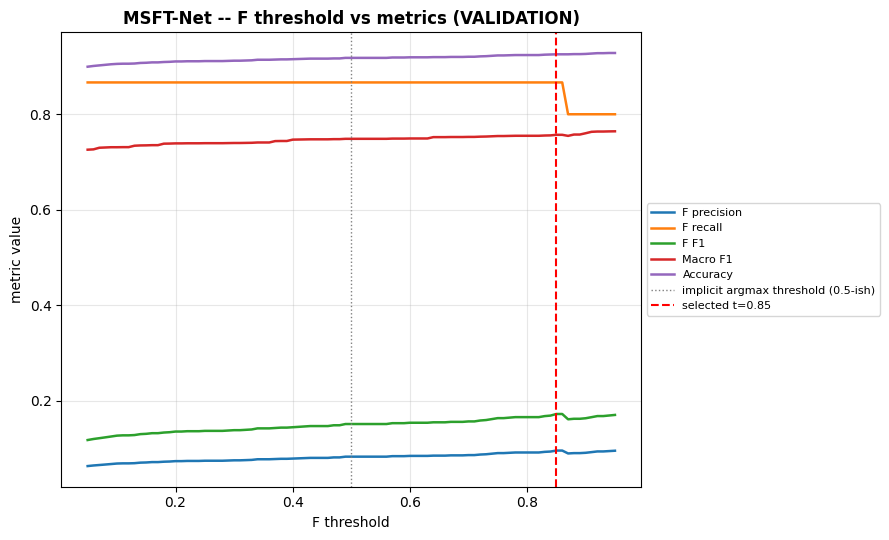

unconstrained best F1_F in sweep: t=0.85, F_f1=0.1722

CONSTRAINED best (N/V recall within 0.02, accuracy within 0.02 of baseline):
  threshold=0.85  F_recall=0.8667  F_precision=0.0956  F_f1=0.1722  macro_f1=0.7570  accuracy=0.9256
  (59 of 91 thresholds satisfied the constraints)


In [46]:
# ============================================================
# SECTION 7D.3: METHOD B -- F THRESHOLD SWEEP, VALIDATION SET ONLY
# ============================================================
MIN_RECALL_DROP = 0.02      # configurable, per spec Section 4
MIN_ACCURACY_DROP = 0.02
F_THRESHOLDS = np.arange(0.05, 0.96, 0.01)


def sweep_f_thresholds(probs, y_true, f_idx, thresholds, class_idx_map=CLASS_IDX_MAP):
    rows = []
    for t in thresholds:
        pred = apply_f_threshold(probs, f_idx, t)
        m = evaluate_predictions(y_true, pred, class_idx_map)
        rows.append({'threshold': t, 'accuracy': m['accuracy'], 'macro_f1': m['macro_f1'],
                     'balanced_accuracy': m['balanced_accuracy'],
                     'F_precision': m.get('F_precision'), 'F_recall': m.get('F_recall'),
                     'F_f1': m.get('F_f1'), 'N_recall': m.get('N_recall'),
                     'S_recall': m.get('S_recall'), 'V_recall': m.get('V_recall')})
    return pd.DataFrame(rows)


def select_constrained_threshold(df_sweep, baseline_metrics,
                                  min_recall_drop=MIN_RECALL_DROP,
                                  min_accuracy_drop=MIN_ACCURACY_DROP,
                                  optimize='F_f1'):
    # Among thresholds that don't tank N/V recall or overall accuracy beyond
    # tolerance, pick the one with the best F1_F (or macro_f1).
    valid = df_sweep[
        (df_sweep['N_recall'] >= baseline_metrics['N_recall'] - min_recall_drop) &
        (df_sweep['V_recall'] >= baseline_metrics['V_recall'] - min_recall_drop) &
        (df_sweep['accuracy'] >= baseline_metrics['accuracy'] - min_accuracy_drop)
    ]
    if len(valid) == 0:
        return None, valid
    return valid.loc[valid[optimize].idxmax()], valid


sweep_df = sweep_f_thresholds(val_probs_msft, y_val, F_CLASS_IDX, F_THRESHOLDS)
best_threshold_row, valid_thresholds = select_constrained_threshold(sweep_df, baseline_val)

fig, axes = plt.subplots(1, 1, figsize=(9, 5.5))
for col, lbl in [('F_precision', 'F precision'), ('F_recall', 'F recall'), ('F_f1', 'F F1'),
                  ('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]:
    axes.plot(sweep_df['threshold'], sweep_df[col], lw=1.8, label=lbl)
axes.axvline(0.5, color='gray', ls=':', lw=1, label='implicit argmax threshold (0.5-ish)')
if best_threshold_row is not None:
    axes.axvline(best_threshold_row['threshold'], color='red', ls='--', lw=1.5,
                 label=f"selected t={best_threshold_row['threshold']:.2f}")
axes.set_xlabel('F threshold'); axes.set_ylabel('metric value')
axes.set_title('MSFT-Net -- F threshold vs metrics (VALIDATION)', fontweight='bold')
axes.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5))
axes.grid(alpha=.3)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig('07d_f_threshold_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"unconstrained best F1_F in sweep: "
      f"t={sweep_df.loc[sweep_df['F_f1'].idxmax(), 'threshold']:.2f}, "
      f"F_f1={sweep_df['F_f1'].max():.4f}")
if best_threshold_row is not None:
    print(f"\nCONSTRAINED best (N/V recall within {MIN_RECALL_DROP}, accuracy within "
          f"{MIN_ACCURACY_DROP} of baseline):")
    print(f"  threshold={best_threshold_row['threshold']:.2f}  F_recall={best_threshold_row['F_recall']:.4f}  "
          f"F_precision={best_threshold_row['F_precision']:.4f}  F_f1={best_threshold_row['F_f1']:.4f}  "
          f"macro_f1={best_threshold_row['macro_f1']:.4f}  accuracy={best_threshold_row['accuracy']:.4f}")
    print(f"  ({len(valid_thresholds)} of {len(sweep_df)} thresholds satisfied the constraints)")
else:
    print(f"\nNO threshold satisfied the constraints (N/V recall within {MIN_RECALL_DROP}, "
          f"accuracy within {MIN_ACCURACY_DROP} of baseline) -- every threshold that helps F "
          f"costs more than the tolerance allows elsewhere. Reported, not hidden.")

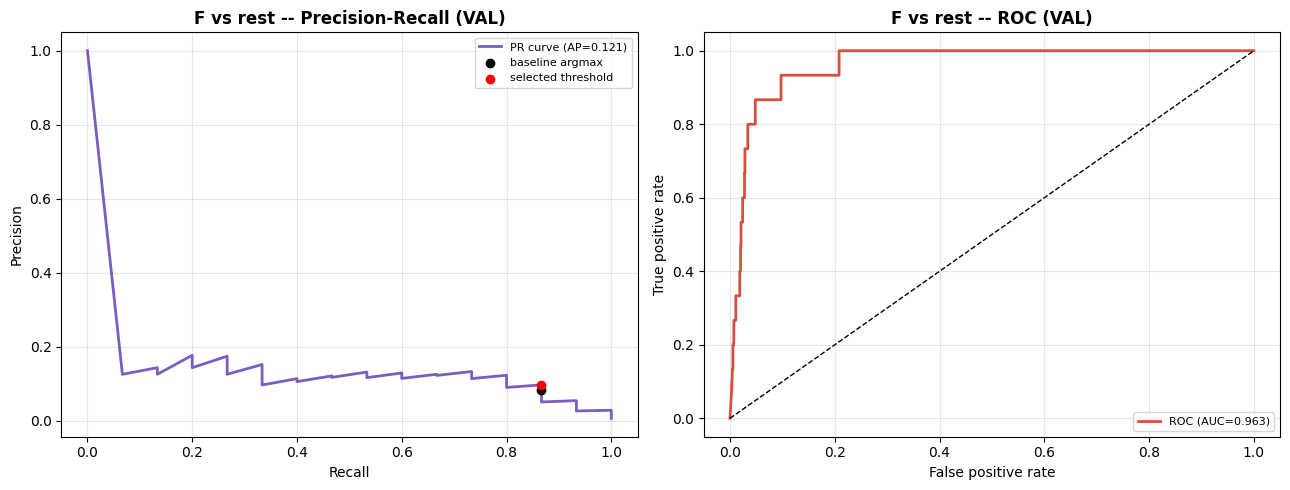

F vs rest -- average precision (AP): 0.1214   ROC-AUC: 0.9628
(diagnostic only -- these did not select the threshold, and are not compared to the test set here)


In [47]:
# ============================================================
# SECTION 7D.4: PR curve + ROC curve for F, one-vs-rest (VALIDATION, diagnostic only)
# ============================================================
y_true_F_val = (y_val == F_CLASS_IDX).astype(int)
f_score_val = val_probs_msft[:, F_CLASS_IDX]

prec_curve, rec_curve, pr_thresh = precision_recall_curve(y_true_F_val, f_score_val)
ap_F = average_precision_score(y_true_F_val, f_score_val)
fpr_F, tpr_F, roc_thresh = roc_curve(y_true_F_val, f_score_val)
auc_F = auc(fpr_F, tpr_F)

# operating points: default argmax (threshold~implicit) and the selected threshold
argmax_op_recall = baseline_val['F_recall']
argmax_op_precision = baseline_val['F_precision']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_curve, prec_curve, lw=2, color='#7c5cbf', label=f'PR curve (AP={ap_F:.3f})')
axes[0].scatter([argmax_op_recall], [argmax_op_precision], color='black', zorder=5,
                label='baseline argmax')
if best_threshold_row is not None:
    axes[0].scatter([best_threshold_row['F_recall']], [best_threshold_row['F_precision']],
                     color='red', zorder=5, label='selected threshold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('F vs rest -- Precision-Recall (VAL)', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

axes[1].plot(fpr_F, tpr_F, lw=2, color='#d94f3d', label=f'ROC (AUC={auc_F:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False positive rate'); axes[1].set_ylabel('True positive rate')
axes[1].set_title('F vs rest -- ROC (VAL)', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig('07d_f_pr_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"F vs rest -- average precision (AP): {ap_F:.4f}   ROC-AUC: {auc_F:.4f}")
print("(diagnostic only -- these did not select the threshold, and are not compared to the "
      "test set here)")

In [48]:
# ============================================================
# SECTION 7D.5: METHOD C -- F MARGIN/CONFIDENCE RULE, VALIDATION SET ONLY
# ============================================================
MARGIN_THRESHOLDS = np.arange(0.0, 0.61, 0.02)

margin_rows = []
for t in F_THRESHOLDS[::2]:          # coarser grid on threshold (paired with margin) -- cheap either way
    for mgn in MARGIN_THRESHOLDS:
        pred = apply_f_margin_rule(val_probs_msft, F_CLASS_IDX, t, mgn)
        m = evaluate_predictions(y_val, pred)
        margin_rows.append({'threshold': t, 'margin': mgn, 'accuracy': m['accuracy'],
                            'macro_f1': m['macro_f1'], 'F_precision': m.get('F_precision'),
                            'F_recall': m.get('F_recall'), 'F_f1': m.get('F_f1'),
                            'N_recall': m.get('N_recall'), 'V_recall': m.get('V_recall')})
margin_df = pd.DataFrame(margin_rows)

valid_margin = margin_df[
    (margin_df['N_recall'] >= baseline_val['N_recall'] - MIN_RECALL_DROP) &
    (margin_df['V_recall'] >= baseline_val['V_recall'] - MIN_RECALL_DROP) &
    (margin_df['accuracy'] >= baseline_val['accuracy'] - MIN_ACCURACY_DROP)
]

if len(valid_margin) > 0:
    best_margin_row = valid_margin.loc[valid_margin['F_f1'].idxmax()]
    print(f"CONSTRAINED best margin rule: threshold={best_margin_row['threshold']:.2f}  "
          f"margin={best_margin_row['margin']:.2f}  F_recall={best_margin_row['F_recall']:.4f}  "
          f"F_precision={best_margin_row['F_precision']:.4f}  F_f1={best_margin_row['F_f1']:.4f}  "
          f"macro_f1={best_margin_row['macro_f1']:.4f}")
    print(f"  ({len(valid_margin)} of {len(margin_df)} threshold/margin pairs satisfied the constraints)")
else:
    best_margin_row = None
    print("NO threshold/margin combination satisfied the constraints -- the margin rule doesn't "
          "help beyond what the plain threshold already does under this tolerance. Reported, not hidden.")

print(f"\nunconstrained best margin-rule F1_F: {margin_df['F_f1'].max():.4f} "
      f"at threshold={margin_df.loc[margin_df['F_f1'].idxmax(), 'threshold']:.2f}, "
      f"margin={margin_df.loc[margin_df['F_f1'].idxmax(), 'margin']:.2f}")

CONSTRAINED best margin rule: threshold=0.85  margin=0.00  F_recall=0.8667  F_precision=0.0956  F_f1=0.1722  macro_f1=0.7570
  (1426 of 1426 threshold/margin pairs satisfied the constraints)

unconstrained best margin-rule F1_F: 0.1722 at threshold=0.85, margin=0.00


In [49]:
# ============================================================
# SECTION 7D.6 (OPTIONAL): TEMPERATURE SCALING, fit on VALIDATION ONLY
# ============================================================
val_logit_surrogate = get_logit_surrogate(val_probs_msft)


def fit_temperature(logit_surrogate, y_true_int, num_classes, t_grid=None):
    if t_grid is None:
        t_grid = np.arange(0.30, 5.01, 0.02)
    y_oh = to_categorical(y_true_int, num_classes)
    best_t, best_nll = 1.0, np.inf
    for t in t_grid:
        z = logit_surrogate / t
        z = z - z.max(axis=1, keepdims=True)          # numerically stable softmax
        p = np.exp(z); p /= p.sum(axis=1, keepdims=True)
        nll = -np.mean(np.sum(y_oh * np.log(np.clip(p, 1e-9, 1.0)), axis=1))
        if nll < best_nll:
            best_nll, best_t = nll, t
    return best_t, best_nll


def apply_temperature(probs, temperature, eps=1e-9):
    z = get_logit_surrogate(probs, eps) / temperature
    z = z - z.max(axis=1, keepdims=True)
    p = np.exp(z); p /= p.sum(axis=1, keepdims=True)
    return p


selected_temperature, temp_val_nll = fit_temperature(val_logit_surrogate, y_val, NUM_CLASSES)
val_probs_calibrated = apply_temperature(val_probs_msft, selected_temperature)

ece_before = calculate_ece(val_probs_msft, y_val)
ece_after = calculate_ece(val_probs_calibrated, y_val)

print(f"selected temperature (fit on VALIDATION, NLL-minimizing): {selected_temperature:.3f}")
print(f"ECE before calibration : {ece_before:.4f}")
print(f"ECE after calibration  : {ece_after:.4f}")

# re-run the threshold sweep on the CALIBRATED validation probabilities --
# this is "Method D": calibration + threshold, still selected on VALIDATION only
sweep_df_calibrated = sweep_f_thresholds(val_probs_calibrated, y_val, F_CLASS_IDX, F_THRESHOLDS)
best_calibrated_row, valid_calibrated = select_constrained_threshold(sweep_df_calibrated, baseline_val)

if best_calibrated_row is not None:
    print(f"\nCONSTRAINED best threshold AFTER calibration: t={best_calibrated_row['threshold']:.2f}  "
          f"F_recall={best_calibrated_row['F_recall']:.4f}  F_f1={best_calibrated_row['F_f1']:.4f}  "
          f"macro_f1={best_calibrated_row['macro_f1']:.4f}")
else:
    print("\nNO calibrated threshold satisfied the constraints either.")

selected temperature (fit on VALIDATION, NLL-minimizing): 3.460
ECE before calibration : 0.0672
ECE after calibration  : 0.0222

CONSTRAINED best threshold AFTER calibration: t=0.81  F_recall=0.7333  F_f1=0.2056  macro_f1=0.7753


In [50]:
# ============================================================
# SECTION 7D.7: COMPARISON TABLE -- VALIDATION SET
# ============================================================
def row_from_metrics(name, m):
    return {'Method': name, 'Accuracy': round(m['accuracy'], 4),
            'F Precision': round(m.get('F_precision', float('nan')), 4),
            'F Recall': round(m.get('F_recall', float('nan')), 4),
            'F F1': round(m.get('F_f1', float('nan')), 4),
            'Macro F1': round(m['macro_f1'], 4),
            'Balanced Accuracy': round(m['balanced_accuracy'], 4),
            'N Recall': round(m.get('N_recall', float('nan')), 4),
            'S Recall': round(m.get('S_recall', float('nan')), 4),
            'V Recall': round(m.get('V_recall', float('nan')), 4)}

comparison_rows = [row_from_metrics('Baseline (argmax)', baseline_val)]

if best_threshold_row is not None:
    pred_t = apply_f_threshold(val_probs_msft, F_CLASS_IDX, best_threshold_row['threshold'])
    comparison_rows.append(row_from_metrics(
        f"F-threshold (t={best_threshold_row['threshold']:.2f})", evaluate_predictions(y_val, pred_t)))

if best_margin_row is not None:
    pred_m = apply_f_margin_rule(val_probs_msft, F_CLASS_IDX,
                                  best_margin_row['threshold'], best_margin_row['margin'])
    comparison_rows.append(row_from_metrics(
        f"F-margin (t={best_margin_row['threshold']:.2f}, m={best_margin_row['margin']:.2f})",
        evaluate_predictions(y_val, pred_m)))

if best_calibrated_row is not None:
    pred_c = apply_f_threshold(val_probs_calibrated, F_CLASS_IDX, best_calibrated_row['threshold'])
    comparison_rows.append(row_from_metrics(
        f"Calibration (T={selected_temperature:.2f}) + threshold (t={best_calibrated_row['threshold']:.2f})",
        evaluate_predictions(y_val, pred_c)))

df_comparison_val = pd.DataFrame(comparison_rows)
print("=" * 100)
print("VALIDATION -- Baseline vs F-threshold vs F-margin vs Calibration+threshold")
print("=" * 100)
print(df_comparison_val.to_string(index=False))
df_comparison_val.to_csv('experiment1_validation_comparison.csv', index=False)

# pick the single best method (by F F1 among the rows actually computed, baseline excluded)
_candidates = df_comparison_val.iloc[1:]
if len(_candidates) > 0:
    _best_idx = _candidates['F F1'].idxmax()
    best_method_name = df_comparison_val.loc[_best_idx, 'Method']
    print(f"\nbest-performing method on VALIDATION (by F F1): {best_method_name}")
else:
    best_method_name = 'Baseline (argmax)'
    print("\nNo method satisfied the constraints -- baseline remains the best available option. "
          "This IS a valid experimental outcome (see Section 7D.9).")

VALIDATION -- Baseline vs F-threshold vs F-margin vs Calibration+threshold
                                   Method  Accuracy  F Precision  F Recall   F F1  Macro F1  Balanced Accuracy  N Recall  S Recall  V Recall
                        Baseline (argmax)    0.9181       0.0823    0.8667 0.1503    0.7484             0.8700    0.9135    0.9000    0.7059
                     F-threshold (t=0.85)    0.9256       0.0956    0.8667 0.1722    0.7570             0.8770    0.9229    0.9059    0.7255
                F-margin (t=0.85, m=0.00)    0.9256       0.0956    0.8667 0.1722    0.7570             0.8770    0.9229    0.9059    0.7255
Calibration (T=3.46) + threshold (t=0.81)    0.9394       0.1196    0.7333 0.2056    0.7753             0.8735    0.9407    0.9059    0.8235

best-performing method on VALIDATION (by F F1): Calibration (T=3.46) + threshold (t=0.81)


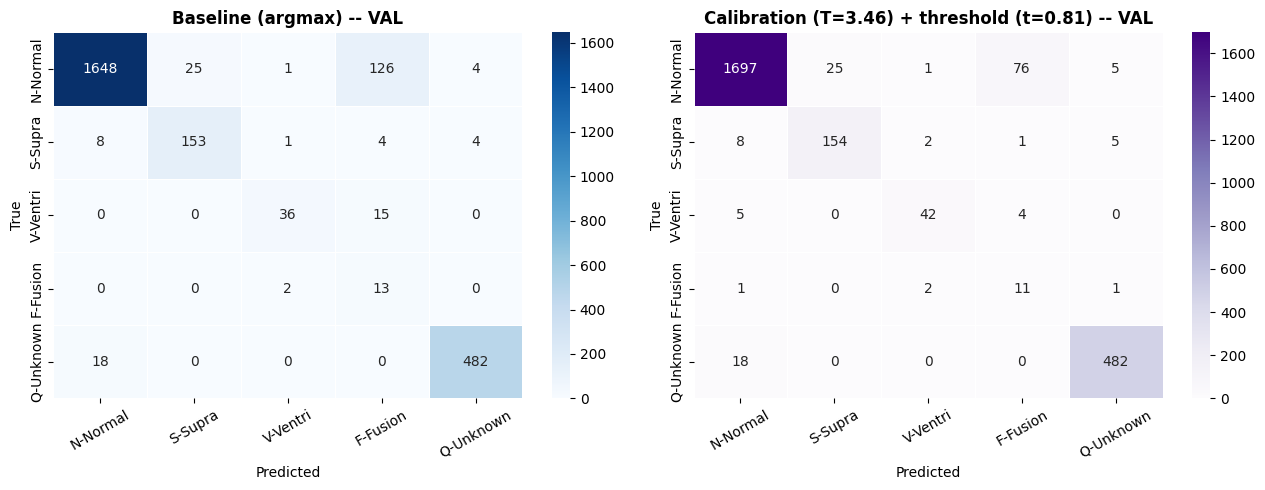


--- F error breakdown, BASELINE (VAL) ---
True F beats (n=15) went to:
  F -> V-Ventri        2  ( 13.3%)
  F -> F-Fusion       13  ( 86.7%)  <- correct

Other classes predicted as F:
  N-Normal -> F    126  (  7.0% of true N-Normal)
  S-Supra -> F      4  (  2.4% of true S-Supra)
  V-Ventri -> F     15  ( 29.4% of true V-Ventri)

--- F error breakdown, Calibration (T=3.46) + threshold (t=0.81) (VAL) ---
True F beats (n=15) went to:
  F -> N-Normal        1  (  6.7%)
  F -> V-Ventri        2  ( 13.3%)
  F -> F-Fusion       11  ( 73.3%)  <- correct
  F -> Q-Unknown       1  (  6.7%)

Other classes predicted as F:
  N-Normal -> F     76  (  4.2% of true N-Normal)
  S-Supra -> F      1  (  0.6% of true S-Supra)
  V-Ventri -> F      4  (  7.8% of true V-Ventri)


array([[1697,   25,    1,   76,    5],
       [   8,  154,    2,    1,    5],
       [   5,    0,   42,    4,    0],
       [   1,    0,    2,   11,    1],
       [  18,    0,    0,    0,  482]])

In [51]:
# ============================================================
# SECTION 7D.8: CONFUSION MATRICES + F-SPECIFIC ERROR BREAKDOWN -- VALIDATION
# ============================================================
# decide which prediction array is "best" for the plots below
if best_method_name.startswith('F-threshold'):
    val_pred_best = apply_f_threshold(val_probs_msft, F_CLASS_IDX, best_threshold_row['threshold'])
elif best_method_name.startswith('F-margin'):
    val_pred_best = apply_f_margin_rule(val_probs_msft, F_CLASS_IDX,
                                         best_margin_row['threshold'], best_margin_row['margin'])
elif best_method_name.startswith('Calibration'):
    val_pred_best = apply_f_threshold(val_probs_calibrated, F_CLASS_IDX, best_calibrated_row['threshold'])
else:
    val_pred_best = val_pred_baseline

cm_best_val = confusion_matrix(y_val, val_pred_best, labels=range(NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(baseline_cm_val, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Baseline (argmax) -- VAL', fontweight='bold')
sns.heatmap(cm_best_val, annot=True, fmt='d', cmap='Purples', linewidths=.5, ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title(f'{best_method_name} -- VAL', fontweight='bold')
for a in axes:
    a.set_ylabel('True'); a.set_xlabel('Predicted'); a.tick_params(axis='x', rotation=30)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig('07d_confusion_matrices_val.png', dpi=300, bbox_inches='tight')
plt.show()


def f_error_breakdown(y_true, y_pred, f_idx, class_names=CLASS_NAMES, num_classes=NUM_CLASSES):
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    f_support = int((y_true == f_idx).sum())
    print(f"True F beats (n={f_support}) went to:")
    for j in range(num_classes):
        n_j = int(cm[f_idx, j])
        if n_j == 0:
            continue
        pct = 100 * n_j / max(1, f_support)
        print(f"  F -> {class_names[j]:<12} {n_j:4d}  ({pct:5.1f}%)" +
              ("  <- correct" if j == f_idx else ""))
    print(f"\nOther classes predicted as F:")
    for i in range(num_classes):
        if i == f_idx:
            continue
        n_i = int(cm[i, f_idx])
        support_i = int((y_true == i).sum())
        if n_i == 0:
            continue
        print(f"  {class_names[i]} -> F   {n_i:4d}  ({100*n_i/max(1,support_i):5.1f}% of true {class_names[i]})")
    return cm

print(f"\n--- F error breakdown, BASELINE (VAL) ---")
f_error_breakdown(y_val, val_pred_baseline, F_CLASS_IDX)
print(f"\n--- F error breakdown, {best_method_name} (VAL) ---")
f_error_breakdown(y_val, val_pred_best, F_CLASS_IDX)

  TEST SET (frozen, evaluated once)  --  method: Calibration (T=3.46) + threshold (t=0.81)
metric                 baseline (argmax)      final (frozen)       delta
Accuracy                          0.8410              0.8300     -0.0110
Macro F1                          0.6768              0.6291     -0.0478
Balanced Accuracy                 0.7164              0.6351     -0.0813
N Recall                          0.9122              0.9221     +0.0099
S Recall                          0.7970              0.7986     +0.0016
V Recall                          0.9219              0.9399     +0.0180
F Precision                       0.7723              0.9362     +0.1638
F Recall                          0.8918              0.4536     -0.4381
F F1                              0.8278              0.6111     -0.2166

              precision    recall  f1-score   support

    N-Normal     0.8715    0.9221    0.8961      6047
     S-Supra     0.8655    0.7986    0.8307      1837
    V-Ventri   

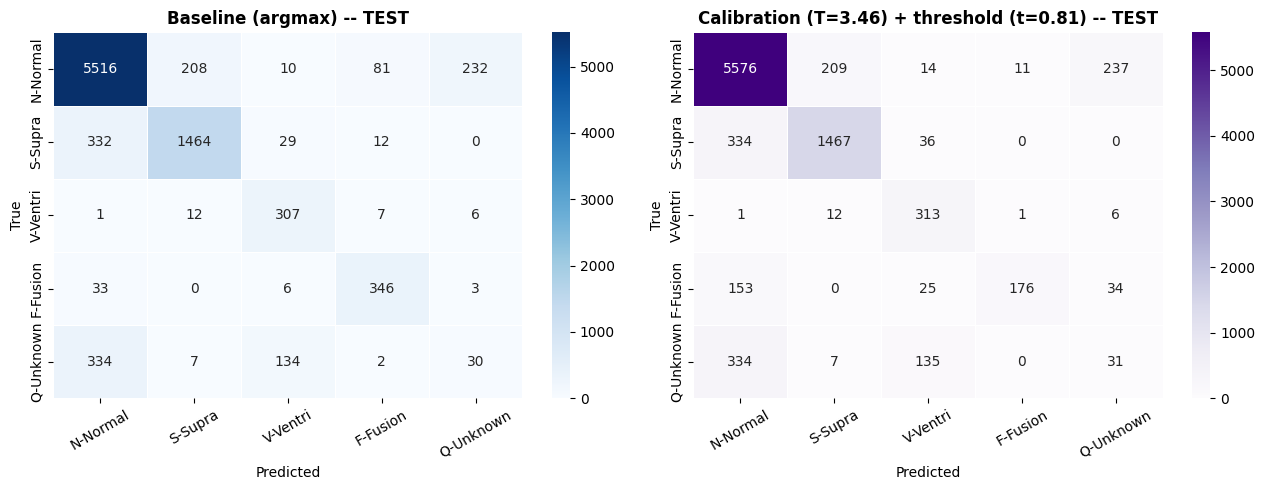


--- F error breakdown, TEST, baseline ---
True F beats (n=388) went to:
  F -> N-Normal       33  (  8.5%)
  F -> V-Ventri        6  (  1.5%)
  F -> F-Fusion      346  ( 89.2%)  <- correct
  F -> Q-Unknown       3  (  0.8%)

Other classes predicted as F:
  N-Normal -> F     81  (  1.3% of true N-Normal)
  S-Supra -> F     12  (  0.7% of true S-Supra)
  V-Ventri -> F      7  (  2.1% of true V-Ventri)
  Q-Unknown -> F      2  (  0.4% of true Q-Unknown)

--- F error breakdown, TEST, final (frozen) ---
True F beats (n=388) went to:
  F -> N-Normal      153  ( 39.4%)
  F -> V-Ventri       25  (  6.4%)
  F -> F-Fusion      176  ( 45.4%)  <- correct
  F -> Q-Unknown      34  (  8.8%)

Other classes predicted as F:
  N-Normal -> F     11  (  0.2% of true N-Normal)
  V-Ventri -> F      1  (  0.3% of true V-Ventri)

saved: test_pred_exp1_final.npy, experiment1_test_final.csv


In [52]:
# ============================================================
# SECTION 7D.9: FINAL -- freeze parameters, evaluate ONCE on the TEST SET
# ============================================================
# nothing above this cell has touched X_test/RR_test/y_test.
test_probs_msft = collect_predictions(model_msft, X_test, RR_test, mk_msft_in)
test_pred_baseline = np.argmax(test_probs_msft, axis=1)   # == y_pred_msft from Section 7C

if best_method_name.startswith('F-threshold'):
    frozen_threshold = best_threshold_row['threshold']
    test_pred_final = apply_f_threshold(test_probs_msft, F_CLASS_IDX, frozen_threshold)
    frozen_desc = f"F-threshold (t={frozen_threshold:.2f})"
elif best_method_name.startswith('F-margin'):
    frozen_threshold, frozen_margin = best_margin_row['threshold'], best_margin_row['margin']
    test_pred_final = apply_f_margin_rule(test_probs_msft, F_CLASS_IDX, frozen_threshold, frozen_margin)
    frozen_desc = f"F-margin (t={frozen_threshold:.2f}, m={frozen_margin:.2f})"
elif best_method_name.startswith('Calibration'):
    test_probs_calibrated = apply_temperature(test_probs_msft, selected_temperature)
    frozen_threshold = best_calibrated_row['threshold']
    test_pred_final = apply_f_threshold(test_probs_calibrated, F_CLASS_IDX, frozen_threshold)
    frozen_desc = f"Calibration (T={selected_temperature:.2f}) + threshold (t={frozen_threshold:.2f})"
else:
    test_pred_final = test_pred_baseline
    frozen_desc = "Baseline (argmax) -- no method beat baseline under the constraints"

test_baseline_metrics = evaluate_predictions(y_test, test_pred_baseline)
test_final_metrics = evaluate_predictions(y_test, test_pred_final)

print("=" * 78)
print(f"  TEST SET (frozen, evaluated once)  --  method: {frozen_desc}")
print("=" * 78)
print(f"{'metric':<20}{'baseline (argmax)':>20}{'final (frozen)':>20}{'delta':>12}")
for label, key in [('Accuracy', 'accuracy'), ('Macro F1', 'macro_f1'),
                    ('Balanced Accuracy', 'balanced_accuracy'),
                    ('N Recall', 'N_recall'), ('S Recall', 'S_recall'), ('V Recall', 'V_recall'),
                    ('F Precision', 'F_precision'), ('F Recall', 'F_recall'), ('F F1', 'F_f1')]:
    b, f = test_baseline_metrics.get(key, float('nan')), test_final_metrics.get(key, float('nan'))
    print(f"{label:<20}{b:>20.4f}{f:>20.4f}{f-b:>+12.4f}")

print("\n" + classification_report(y_test, test_pred_final, labels=range(NUM_CLASSES),
                                    target_names=CLASS_NAMES, digits=4, zero_division=0))

cm_test_final = test_final_metrics['confusion_matrix']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(test_baseline_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            linewidths=.5, ax=axes[0], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Baseline (argmax) -- TEST', fontweight='bold')
sns.heatmap(cm_test_final, annot=True, fmt='d', cmap='Purples', linewidths=.5, ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title(f'{frozen_desc} -- TEST', fontweight='bold')
for a in axes:
    a.set_ylabel('True'); a.set_xlabel('Predicted'); a.tick_params(axis='x', rotation=30)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig('07d_confusion_matrices_test_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- F error breakdown, TEST, baseline ---")
f_error_breakdown(y_test, test_pred_baseline, F_CLASS_IDX)
print("\n--- F error breakdown, TEST, final (frozen) ---")
f_error_breakdown(y_test, test_pred_final, F_CLASS_IDX)

np.save('test_pred_exp1_final.npy', test_pred_final)
pd.DataFrame([{'Method': 'Baseline (argmax)', **{k: round(v, 4) for k, v in test_baseline_metrics.items() if k != 'confusion_matrix'}},
              {'Method': frozen_desc, **{k: round(v, 4) for k, v in test_final_metrics.items() if k != 'confusion_matrix'}}]
             ).to_csv('experiment1_test_final.csv', index=False)
print("\nsaved: test_pred_exp1_final.npy, experiment1_test_final.csv")

In [ ]:
# ============================================================
# SECTION 7D.10: EXPERIMENT 1 -- FINAL SUMMARY
# ============================================================
_needed = ['test_baseline_metrics', 'test_final_metrics', 'frozen_desc',
           'best_method_name', 'val_pred_best']
_missing = [n for n in _needed if n not in globals()]
if _missing:
    raise RuntimeError(
        f"Section 7D.10 needs {_missing}, which Section 7D.9 defines. "
        "Run Section 7D.9 (the frozen test evaluation) in this kernel first -- "
        "this cell only formats results, it does not compute them.")

print("=" * 62)
print("EXPERIMENT 1 -- F THRESHOLD / CALIBRATION  (MSFT-Net)")
print("=" * 62)

print("\nBaseline (TEST):")
print(f"    Overall Accuracy: {test_baseline_metrics['accuracy']:.4f}")
print(f"    F Recall:         {test_baseline_metrics.get('F_recall', float('nan')):.4f}")
print(f"    F F1:             {test_baseline_metrics.get('F_f1', float('nan')):.4f}")
print(f"    Macro F1:         {test_baseline_metrics['macro_f1']:.4f}")

print(f"\nBest Validation Method: {frozen_desc}")
if best_method_name.startswith('F-threshold') or best_method_name.startswith('Calibration'):
    print(f"    F threshold:  {frozen_threshold:.2f}")
if best_method_name.startswith('F-margin'):
    print(f"    F threshold:  {frozen_threshold:.2f}")
    print(f"    Margin:       {frozen_margin:.2f}")
if best_method_name.startswith('Calibration'):
    print(f"    Temperature:  {selected_temperature:.3f}")

_val_final_metrics = evaluate_predictions(y_val, val_pred_best)
print("\nValidation (selection set):")
print(f"    Overall Accuracy: {_val_final_metrics['accuracy']:.4f}")
print(f"    F Recall:         {_val_final_metrics.get('F_recall', float('nan')):.4f}")
print(f"    F F1:             {_val_final_metrics.get('F_f1', float('nan')):.4f}")
print(f"    Macro F1:         {_val_final_metrics['macro_f1']:.4f}")

print("\nFinal Test (frozen, evaluated once):")
print(f"    Overall Accuracy: {test_final_metrics['accuracy']:.4f}")
print(f"    F Recall:         {test_final_metrics.get('F_recall', float('nan')):.4f}")
print(f"    F F1:             {test_final_metrics.get('F_f1', float('nan')):.4f}")
print(f"    Macro F1:         {test_final_metrics['macro_f1']:.4f}")

d_acc = test_final_metrics['accuracy'] - test_baseline_metrics['accuracy']
d_frec = test_final_metrics.get('F_recall', float('nan')) - test_baseline_metrics.get('F_recall', float('nan'))
d_ff1 = test_final_metrics.get('F_f1', float('nan')) - test_baseline_metrics.get('F_f1', float('nan'))
d_mf1 = test_final_metrics['macro_f1'] - test_baseline_metrics['macro_f1']
print("\nChange from baseline (TEST):")
print(f"    Delta Accuracy: {d_acc:+.4f}")
print(f"    Delta F Recall: {d_frec:+.4f}")
print(f"    Delta F F1:     {d_ff1:+.4f}")
print(f"    Delta Macro F1: {d_mf1:+.4f}")

print("\nMain conclusion:")
f_recall_target = 0.60
if test_final_metrics.get('F_recall', 0) >= f_recall_target:
    print(f"    F recall reached {test_final_metrics['F_recall']:.4f} on TEST, clearing the "
          f"{f_recall_target:.0%} target from decision-boundary adjustment ALONE -- the model's "
          f"probability outputs already contain the needed F information; argmax was suppressing it.")
elif d_frec > 0.03:
    print(f"    F recall improved on TEST (+{d_frec:.4f}) but did not reach {f_recall_target:.0%} "
          f"({test_final_metrics['F_recall']:.4f}) from decision-boundary adjustment alone. "
          f"Some useful F information is being suppressed by argmax, but the representation "
          f"itself likely also needs work (Experiments 2/5/6).")
else:
    print(f"    F recall barely moved on TEST ({d_frec:+.4f}). Decision-boundary adjustment alone "
          f"is NOT the fix here -- the constrained search either found no usable threshold, or "
          f"the one it found on VALIDATION (n=15 F beats) did not generalize to TEST (n=398). "
          f"This points to the learned REPRESENTATION as the bottleneck, not the operating "
          f"point -- consistent with Experiments 2 (auxiliary loss) / 6 (hard-negative mining) "
          f"being the next things to try, not further threshold tuning.")
print("=" * 62)

## Section 9 — Unified ablation study

Replaces the seven scattered ablation cells of the previous version (9, 9B, 9C, 9D, 9E,
9F, 9G). Those answered overlapping questions on different arms, with different training
budgets, and reported significance only between *adjacent rows* of one table — so the
family-wise error rate was never controlled and two arms in different tables could not be
compared at all.

**What this version does differently**

| Property | Old 9/9B/…/9G | New Section 9 |
|---|---|---|
| Arms | spread over 7 cells | one registry, one engine |
| Held constant | varied per cell | split, test set, epochs, patience, seed — identical for every arm |
| Baseline | implicit / different per cell | one named reference arm, every other arm is measured against it |
| Significance | McNemar between adjacent rows, uncorrected | McNemar vs the reference + **Holm–Bonferroni** over the whole family |
| Effect size | none | paired bootstrap CI on Δ macro-F1 |
| Per-class view | only for the class each cell targeted | Se/+P for **all five classes including Q**, every arm |
| Repeats | single run | `ABLATION_SEEDS` — mean ± sd when more than one seed |

**Ablation contract.** Every arm differs from the reference in exactly one component.
Same records, same partition, same test beats, same balancing strategy (unless the arm
*is* the balancing question), same number of epochs. A row therefore answers one question:
*what does the reported model lose if this component is removed?*

**Reading the table.** Rank by macro-F1, not accuracy — under this imbalance the accuracy
leader is usually the arm that leans hardest on N. A non-significant Holm-corrected
*p* is a legitimate result: it means the component is not doing measurable work, and that
belongs in the thesis exactly as it comes out.

In [65]:
# ============================================================
# SECTION 9.1: ablation engine -- arm registry and runner
# ============================================================
from contextlib import contextmanager

REF_ARM = 'Full model (reported)'      # every other arm is measured against this one

@contextmanager
def _temp_globals(**kw):
    """Temporarily override module-level globals that the shared builders read
    (N_RR, USE_AUGMENT, ...). build_training_set() and build_cnn_only()/
    build_cnn_bilstm() read these from the global namespace rather than taking
    them as arguments, so an ablation that changes one of them has to swap the
    global and put it back -- doing it here, in one place, means no arm can leak
    its settings into the next one or into Sections 10-14."""
    g = globals()
    had = {k: g[k] for k in kw if k in g}
    new = [k for k in kw if k not in g]
    g.update(kw)
    try:
        yield
    finally:
        g.update(had)
        for k in new:
            g.pop(k, None)


# ---- auxiliary-feature blocks (built from Section 3/4A0/4A1's own group map, so an
# ---- arm can never drift out of sync with the features that actually exist) ------
AUX_BLOCKS = {
    'RR timing':        ['RR_basic', 'RR_context', 'RR_dynamics', 'RR_normal_reference'],
    'QRS morphology':   ['QRS_morphology', 'Regional_QRS_morphology', 'Context'],
    'P-wave':           ['P_wave'],
    'N/V templates':    ['Patient_normal_template', 'Fusion', 'Fusion_continuum',
                         'Regional_QRS_vs_template', 'Patient_NV_fusion'],
}

def _cols_after_dropping(block_names):
    """Column indices of rr_all that survive after dropping whole feature blocks."""
    drop = set()
    for b in block_names:
        for grp in AUX_BLOCKS.get(b, []):
            drop.update(EXPERIMENT_C_FEATURE_GROUPS.get(grp, []))
    keep = [i for i, nm in enumerate(AUX_FEATURE_NAMES) if nm not in drop]
    return np.asarray(keep, dtype=int), len(drop)

print("auxiliary feature width:", len(AUX_FEATURE_NAMES))
for b in AUX_BLOCKS:
    _, n_drop = _cols_after_dropping([b])
    print(f"  block {b:<16} {n_drop:>3} columns")


# ---- arm registry -------------------------------------------------
# arch:      'hybrid' | 'cnn_bilstm' | 'cnn'
# drop_aux:  list of AUX_BLOCKS keys to remove
# use_rr:    False removes the auxiliary branch entirely (waveform-only model)
def _arm(name, group, question, arch='hybrid', drop_aux=(), use_rr=True,
         balancing=None, augment=None):
    return dict(name=name, group=group, question=question, arch=arch,
                drop_aux=list(drop_aux), use_rr=use_rr,
                balancing=BALANCING if balancing is None else balancing,
                augment=USE_AUGMENT if augment is None else augment)

ABLATION_REGISTRY = [
    _arm(REF_ARM, 'baseline',
         'reference: CNN -> BiLSTM -> attention pooling + full auxiliary vector'),

    # -- architecture: remove one stage at a time, features held fixed --
    _arm('- attention pooling',   'architecture',
         'does additive attention pooling beat the BiLSTM final state?', arch='cnn_bilstm'),
    _arm('- BiLSTM (CNN + GAP)',  'architecture',
         'does the recurrent stage add anything over convolution + GAP?', arch='cnn'),

    # -- features: remove one block at a time, architecture held fixed --
    _arm('- RR timing',      'features', 'S is defined by prematurity -- how much of S is RR?',
         drop_aux=['RR timing']),
    _arm('- QRS morphology', 'features', 'V/F are defined by QRS shape -- how much is morphology?',
         drop_aux=['QRS morphology']),
    _arm('- P-wave',         'features', 'does the P-wave block earn its 15 columns?',
         drop_aux=['P-wave']),
    _arm('- N/V templates',  'features', 'do the fusion/template features move F at all?',
         drop_aux=['N/V templates']),
    _arm('- all auxiliary',  'features', 'waveform-only: the upper bound on what 1 s of ECG holds',
         use_rr=False),

    # -- balancing: the loss changes, the data and architecture do not --
    _arm('balancing: none',         'balancing', 'AAMI-purist baseline, no correction',
         balancing='none'),
    _arm('balancing: class_weight', 'balancing', 'weighted CE instead of focal',
         balancing='class_weight'),
    _arm('balancing: SMOTE',        'balancing', 'synthetic minority oversampling',
         balancing='smote'),

    # -- augmentation --
    _arm('- augmentation', 'augmentation', 'is train-time perturbation load-bearing?',
         augment=False),
]

ABLATION_ARMS = [a for a in ABLATION_REGISTRY
                 if a['group'] == 'baseline' or a['group'] in ABLATION_GROUPS]

print(f"\n{len(ABLATION_ARMS)} arms selected "
      f"(groups: {', '.join(ABLATION_GROUPS)}) x {len(ABLATION_SEEDS)} seed(s)")
for a in ABLATION_ARMS:
    print(f"  [{a['group']:<12}] {a['name']:<26} {a['question']}")


# ---- metric helpers ----------------------------------------------
def _fast_macro_f1(yt, yp, K=None):
    """Macro-F1 from a bincount confusion matrix -- ~50x faster than sklearn's
    f1_score in the bootstrap loop, and numerically identical."""
    K = NUM_CLASSES if K is None else K
    cmx = np.bincount(yt.astype(np.int64) * K + yp.astype(np.int64),
                      minlength=K * K).reshape(K, K)
    tp = np.diag(cmx).astype(float)
    se = tp / np.maximum(cmx.sum(1), 1)
    pp = tp / np.maximum(cmx.sum(0), 1)
    return float(np.mean(2 * se * pp / np.maximum(se + pp, 1e-12)))

def _per_class_se_pp(yt, yp):
    cmx = confusion_matrix(yt, yp, labels=range(NUM_CLASSES))
    tp = np.diag(cmx).astype(float)
    se = tp / np.maximum(cmx.sum(1), 1)      # sensitivity / recall (EC57 Se)
    pp = tp / np.maximum(cmx.sum(0), 1)      # positive predictivity (EC57 +P)
    return se, pp

def holm_bonferroni(pvals, alpha=0.05):
    """Holm step-down correction. Controls the family-wise error rate over the
    whole ablation table -- with 11 uncorrected McNemar tests at alpha=0.05 the
    chance of at least one false 'significant' is ~43%, which is how ablation
    tables end up claiming components that do nothing."""
    p = np.asarray(pvals, dtype=float)
    order = np.argsort(p)
    m = len(p)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * p[idx])
        adj[idx] = min(1.0, running)
    return adj, adj < alpha


# ---- training-set cache: (balancing, augment) -> materialised training set ----
_TRAINSET_CACHE = {}

def _training_set_for(balancing, augment):
    key = (balancing, bool(augment))
    if key not in _TRAINSET_CACHE:
        with _temp_globals(USE_AUGMENT=bool(augment)):
            Xa, RRa, ya, yoh, cw, loss = build_training_set(
                balancing, X_tr_raw, y_tr_int_raw, RR_tr_raw, verbose=False)
        _TRAINSET_CACHE[key] = (Xa, RRa, ya, yoh, cw, loss)
    return _TRAINSET_CACHE[key]


def _pack(X, RR, use_rr):
    """List-form input packer. Deliberately NOT the notebook's global mk_in(): that
    one asserts RR.shape[1] == N_RR, which is exactly what a feature ablation
    changes."""
    return [X, RR] if use_rr else X


def run_arm(arm, seed):
    """Trains and evaluates one arm. Everything not named in `arm` is identical to
    the reference arm, which is the whole point of the contract."""
    tf.keras.backend.clear_session(); gc.collect()
    np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)

    cols, n_dropped = _cols_after_dropping(arm['drop_aux'])
    use_rr = bool(arm['use_rr']) and len(cols) > 0
    n_rr_arm = int(len(cols))

    Xa, RRa, ya, yoh, cw, loss = _training_set_for(arm['balancing'], arm['augment'])
    RRa_c, RRv_c, RRt_c = RRa[:, cols], RR_val[:, cols], RR_test[:, cols]
    sw = sample_weight_from_class_weight(ya, cw)

    with _temp_globals(N_RR=n_rr_arm, USE_RR=use_rr):
        if arm['arch'] == 'hybrid':
            m = build_hybrid_model(num_classes=NUM_CLASSES, use_rr=use_rr, n_rr=n_rr_arm)
        elif arm['arch'] == 'cnn_bilstm':
            m = build_cnn_bilstm(num_classes=NUM_CLASSES, use_rr=use_rr)
        elif arm['arch'] == 'cnn':
            m = build_cnn_only(num_classes=NUM_CLASSES, use_rr=use_rr)
        else:
            raise ValueError(f"unknown arch: {arm['arch']}")

    m.compile(optimizer=Adam(LEARNING_RATE), loss=loss, metrics=METRICS)
    t0 = time.perf_counter()
    hist = m.fit(_pack(Xa, RRa_c, use_rr), yoh,
                 validation_data=(_pack(X_val, RRv_c, use_rr), y_val_oh),
                 epochs=ABLATION_EPOCHS, batch_size=BATCH_SIZE, sample_weight=sw,
                 callbacks=[EarlyStopping(monitor='val_macro_f1', mode='max',
                                          patience=ABLATION_PATIENCE,
                                          restore_best_weights=True, verbose=0)],
                 verbose=0)
    mins = (time.perf_counter() - t0) / 60.0

    pred = np.argmax(m.predict(_pack(X_test, RRt_c, use_rr), verbose=0), axis=1)
    se, pp = _per_class_se_pp(y_true, pred)
    out = dict(pred=pred.astype(np.int32),
               acc=float(accuracy_score(y_true, pred)),
               f1=float(f1_score(y_true, pred, average='macro', zero_division=0)),
               val_f1=float(max(hist.history.get('val_macro_f1', [np.nan]))),
               params=int(m.count_params()), n_rr=n_rr_arm, epochs_run=len(hist.epoch),
               minutes=mins, se=se, pp=pp)
    del m; tf.keras.backend.clear_session(); gc.collect()
    return out


print("\nablation engine ready")


auxiliary feature width: 107
  block RR timing         21 columns
  block QRS morphology    25 columns
  block P-wave            15 columns
  block N/V templates     46 columns

12 arms selected (groups: architecture, features, balancing, augmentation) x 1 seed(s)
  [baseline    ] Full model (reported)      reference: CNN -> BiLSTM -> attention pooling + full auxiliary vector
  [architecture] - attention pooling        does additive attention pooling beat the BiLSTM final state?
  [architecture] - BiLSTM (CNN + GAP)       does the recurrent stage add anything over convolution + GAP?
  [features    ] - RR timing                S is defined by prematurity -- how much of S is RR?
  [features    ] - QRS morphology           V/F are defined by QRS shape -- how much is morphology?
  [features    ] - P-wave                   does the P-wave block earn its 15 columns?
  [features    ] - N/V templates            do the fusion/template features move F at all?
  [features    ] - all auxiliary    

In [66]:
# ============================================================
# SECTION 9.2: run every arm
# ============================================================
ablation_runs = {}      # arm name -> list of per-seed result dicts

if RUN_ABLATION:
    total = len(ABLATION_ARMS) * len(ABLATION_SEEDS)
    print("=" * 72)
    print(f"ABLATION -- {total} training runs, {ABLATION_EPOCHS} epochs max, "
          f"patience {ABLATION_PATIENCE}")
    print(f"same split, same {len(y_true):,} test beats, same {NUM_CLASSES} classes "
          f"({', '.join(CLASS_NAMES)})")
    print("=" * 72)

    k = 0
    for arm in ABLATION_ARMS:
        runs = []
        for seed in ABLATION_SEEDS:
            k += 1
            print(f"\n[{k}/{total}] {arm['name']}  (seed {seed}, group '{arm['group']}')")
            r = run_arm(arm, seed)
            runs.append(r)
            print(f"      acc {r['acc']:.4f} | macro-F1 {r['f1']:.4f} | "
                  f"aux width {r['n_rr']} | {r['params']:,} params | "
                  f"{r['epochs_run']} epochs | {r['minutes']:.1f} min")
            print("      Se: " + "  ".join(f"{CLASS_NAMES[c][:1]}={r['se'][c]:.3f}"
                                            for c in range(NUM_CLASSES)))
        ablation_runs[arm['name']] = runs
        if ABLATION_SAVE_PREDS:
            tag = arm['name'].replace(' ', '_').replace('-', '').replace(':', '') \
                             .replace('(', '').replace(')', '').replace('/', '').lower()
            np.save(f"pred_ablation_{tag}.npy", runs[0]['pred'])

    print(f"\nall {total} runs complete")
else:
    print("RUN_ABLATION = False -- Section 9 skipped. "
          "Set it True in Section 0 to reproduce the ablation table.")


ABLATION -- 12 training runs, 40 epochs max, patience 10
same split, same 9,112 test beats, same 5 classes (N-Normal, S-Supra, V-Ventri, F-Fusion, Q-Unknown)

[1/12] Full model (reported)  (seed 42, group 'baseline')
      acc 0.8569 | macro-F1 0.7699 | aux width 107 | 572,358 params | 11 epochs | 1.4 min
      Se: N=0.890  S=0.791  V=0.895  F=0.735  Q=0.765

[2/12] - attention pooling  (seed 42, group 'architecture')
      acc 0.8456 | macro-F1 0.7761 | aux width 107 | 564,165 params | 11 epochs | 1.3 min
      Se: N=0.944  S=0.551  V=0.769  F=0.621  Q=0.963

[3/12] - BiLSTM (CNN + GAP)  (seed 42, group 'architecture')
      acc 0.8804 | macro-F1 0.7893 | aux width 107 | 169,925 params | 11 epochs | 0.9 min
      Se: N=0.877  S=0.898  V=0.715  F=0.928  Q=0.931

[4/12] - RR timing  (seed 42, group 'features')
      acc 0.7717 | macro-F1 0.6515 | aux width 86 | 571,350 params | 19 epochs | 2.4 min
      Se: N=0.815  S=0.601  V=0.736  F=0.879  Q=0.815

[5/12] - QRS morphology  (seed 42, 

In [67]:
# ============================================================
# SECTION 9.3: results table, significance (Holm-corrected), effect sizes
# ============================================================
df_ablation = pd.DataFrame()

if RUN_ABLATION and ablation_runs:
    assert REF_ARM in ablation_runs, "the reference arm did not run"
    ref = ablation_runs[REF_ARM][0]
    ref_pred = ref['pred']
    n_test = len(y_true)
    arm_meta = {a['name']: a for a in ABLATION_ARMS}

    # ---- paired bootstrap on the DELTA, not on each arm separately ----
    # The two arms are scored on the same beats, so their errors are correlated;
    # bootstrapping them independently would overstate the uncertainty of the
    # difference. Resampling beat indices once per replicate and scoring BOTH arms
    # on the same replicate is the paired version.
    def delta_f1_ci(pred_arm, n_boot=None, seed=SEED):
        n_boot = ABLATION_BOOTSTRAP if n_boot is None else n_boot
        rng = np.random.default_rng(seed)
        d = np.empty(n_boot, dtype=float)
        for b in range(n_boot):
            idx = rng.integers(0, n_test, n_test)
            d[b] = (_fast_macro_f1(y_true[idx], pred_arm[idx])
                    - _fast_macro_f1(y_true[idx], ref_pred[idx]))
        return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))

    rows, raw_p = [], []
    for arm in ABLATION_ARMS:
        runs = ablation_runs[arm['name']]
        accs = np.array([r['acc'] for r in runs])
        f1s  = np.array([r['f1'] for r in runs])
        r0   = runs[0]
        is_ref = (arm['name'] == REF_ARM)

        if is_ref:
            p_mc, only_ref, only_arm = np.nan, 0, 0
            lo_d = hi_d = 0.0
        else:
            p_mc, only_ref, only_arm = mcnemar_test(ref_pred, r0['pred'], y_true)
            lo_d, hi_d = delta_f1_ci(r0['pred'])
        raw_p.append(p_mc)

        a_lo, a_hi = wilson(int((r0['pred'] == y_true).sum()), n_test)
        row = {'group': arm['group'], 'arm': arm['name'],
               'aux_width': r0['n_rr'], 'params': r0['params'],
               'accuracy': round(float(accs.mean()), 4),
               'acc_95CI': f"[{a_lo:.4f}, {a_hi:.4f}]",
               'macro_F1': round(float(f1s.mean()), 4),
               'd_macro_F1': round(float(f1s.mean() - np.mean([x['f1'] for x in ablation_runs[REF_ARM]])), 4),
               'dF1_95CI': '--' if is_ref else f"[{lo_d:+.4f}, {hi_d:+.4f}]",
               'McNemar_p': np.nan if is_ref else p_mc,
               'disc_ref_only': only_ref, 'disc_arm_only': only_arm,
               'epochs': r0['epochs_run'], 'minutes': round(r0['minutes'], 1)}
        if len(ABLATION_SEEDS) > 1:
            row['acc_sd'] = round(float(accs.std(ddof=1)), 4)
            row['macroF1_sd'] = round(float(f1s.std(ddof=1)), 4)
        for c in range(NUM_CLASSES):
            row[f"Se_{CLASS_NAMES[c][0]}"] = round(float(r0['se'][c]), 4)
            row[f"+P_{CLASS_NAMES[c][0]}"] = round(float(r0['pp'][c]), 4)
        rows.append(row)

    # ---- Holm-Bonferroni over the whole family (reference excluded) ----
    test_idx = [i for i, r in enumerate(rows) if not np.isnan(r['McNemar_p'])]
    adj, sig = holm_bonferroni([rows[i]['McNemar_p'] for i in test_idx])
    for j, i in enumerate(test_idx):
        rows[i]['p_holm'] = float(adj[j])
        rows[i]['significant'] = bool(sig[j])
    for i, r in enumerate(rows):
        r.setdefault('p_holm', np.nan)
        r.setdefault('significant', False)

    df_ablation = pd.DataFrame(rows)
    df_ablation.to_csv('ablation_results.csv', index=False)

    show = ['group', 'arm', 'aux_width', 'params', 'accuracy', 'macro_F1',
            'd_macro_F1', 'dF1_95CI', 'McNemar_p', 'p_holm', 'significant']
    if len(ABLATION_SEEDS) > 1:
        show.insert(show.index('macro_F1') + 1, 'macroF1_sd')
    fmt = df_ablation[show].copy()
    fmt['params'] = fmt['params'].map(lambda v: f"{v:,}")
    fmt['McNemar_p'] = fmt['McNemar_p'].map(lambda v: '--' if pd.isna(v) else f"{v:.2e}")
    fmt['p_holm'] = fmt['p_holm'].map(lambda v: '--' if pd.isna(v) else f"{v:.2e}")
    print("=" * 100)
    print(f"ABLATION -- reference arm: {REF_ARM}   "
          f"(seeds: {ABLATION_SEEDS}, alpha = 0.05, Holm-corrected over "
          f"{len(test_idx)} tests)")
    print("=" * 100)
    print(fmt.to_string(index=False))

    print("\nper-class sensitivity (Se) -- what each removal actually costs, by class:")
    se_cols = ['arm'] + [f"Se_{CLASS_NAMES[c][0]}" for c in range(NUM_CLASSES)]
    print(df_ablation[se_cols].to_string(index=False))

    # ---- readable verdicts -------------------------------------------
    print("\n" + "-" * 100)
    print("VERDICTS (macro-F1 is primary; accuracy alone rewards leaning on N)")
    print("-" * 100)
    for _, r in df_ablation.iterrows():
        if r['arm'] == REF_ARM:
            print(f"  {r['arm']:<28} macro-F1 {r['macro_F1']:.4f}  <- reference")
            continue
        d = r['d_macro_F1']
        if r['significant']:
            verdict = ("component IS load-bearing" if d < 0 else
                       "removing it HELPED -- investigate before keeping the component")
        else:
            verdict = "no measurable effect after correction"
        print(f"  {r['arm']:<28} d macro-F1 {d:+.4f} {r['dF1_95CI']:<22} "
              f"p_holm={r['p_holm']:.3g}  {verdict}")

    print("\nNote: a CI on d macro-F1 that straddles 0 and a non-significant Holm p are")
    print("the same finding stated two ways. Report both; do not quietly drop the arm.")
else:
    print("no ablation results to tabulate")


ABLATION -- reference arm: Full model (reported)   (seeds: [42], alpha = 0.05, Holm-corrected over 11 tests)
       group                     arm  aux_width  params  accuracy  macro_F1  d_macro_F1           dF1_95CI McNemar_p   p_holm  significant
    baseline   Full model (reported)        107 572,358    0.8569    0.7699      0.0000                 --        --       --        False
architecture     - attention pooling        107 564,165    0.8456    0.7761      0.0063 [-0.0069, +0.0193]  5.42e-03 1.08e-02         True
architecture    - BiLSTM (CNN + GAP)        107 169,925    0.8804    0.7893      0.0194 [+0.0067, +0.0326]  2.53e-10 7.59e-10         True
    features             - RR timing         86 571,350    0.7717    0.6515     -0.1184 [-0.1332, -0.1027]  0.00e+00 0.00e+00         True
    features        - QRS morphology         82 571,158    0.7533    0.6623     -0.1075 [-0.1205, -0.0941]  0.00e+00 0.00e+00         True
    features                - P-wave         92 571,638  

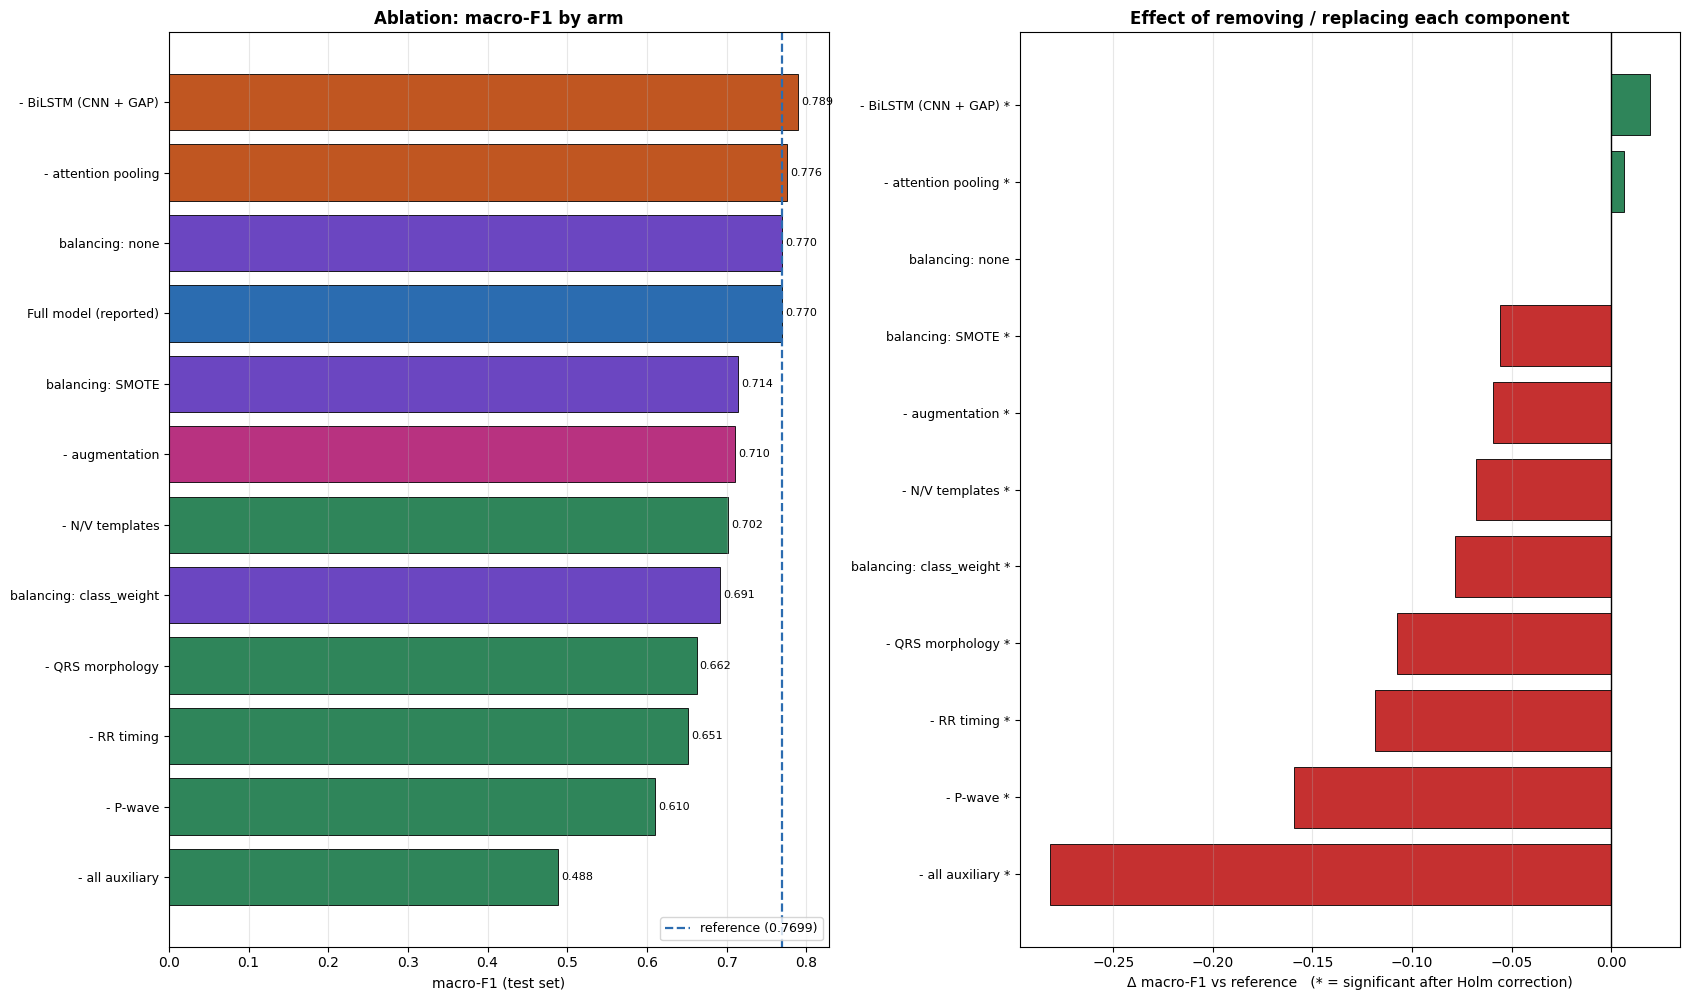

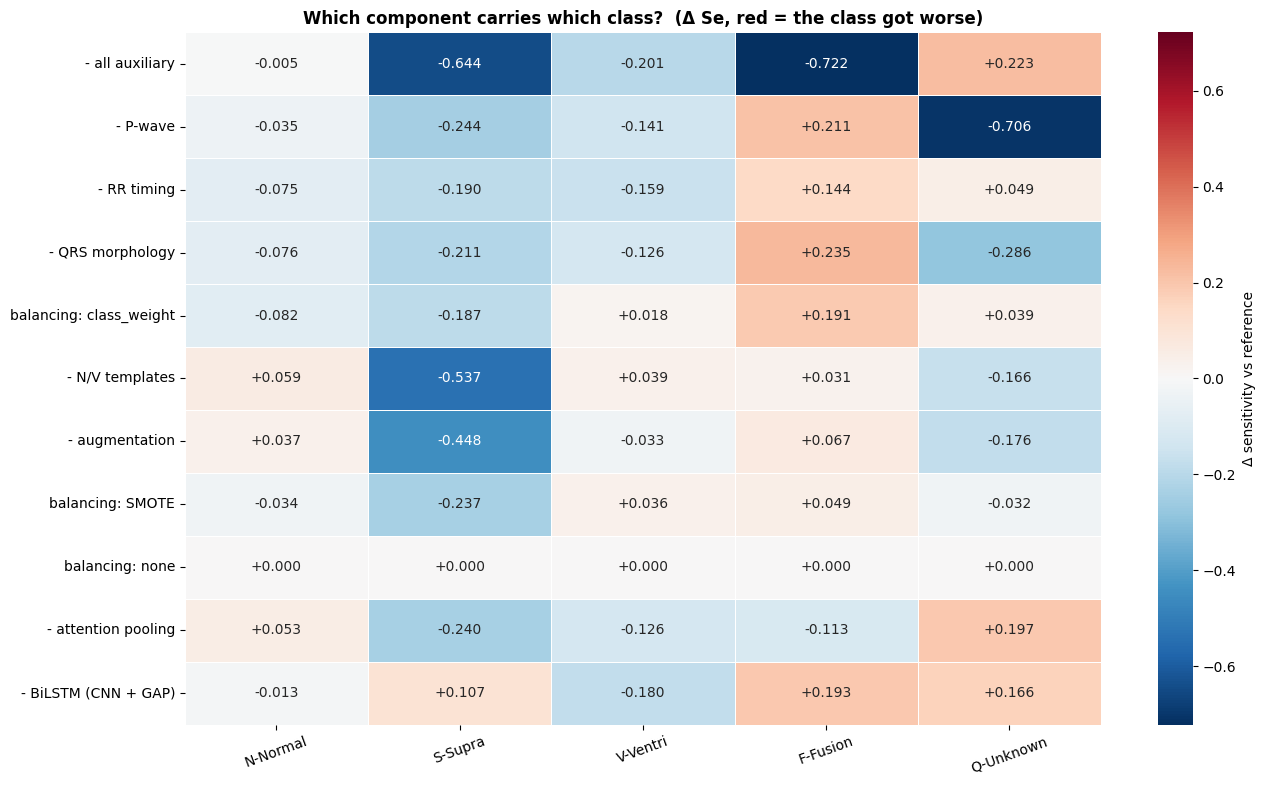

PER-CLASS ATTRIBUTION -- the arm whose removal costs each class the most Se
  N-Normal     ref Se 0.8904   worst: 'balancing: class_weight' -0.0822   (best: '- N/V templates' +0.0590)
  S-Supra      ref Se 0.7910   worst: '- all auxiliary' -0.6440   (best: '- BiLSTM (CNN + GAP)' +0.1067)
  V-Ventri     ref Se 0.8949   worst: '- all auxiliary' -0.2012   (best: '- N/V templates' +0.0390)
  F-Fusion     ref Se 0.7345   worst: '- all auxiliary' -0.7216   (best: '- QRS morphology' +0.2346)
  Q-Unknown    ref Se 0.7653   worst: '- P-wave' -0.7061   (best: '- all auxiliary' +0.2229)

  Q comes from 1 held-out paced record(s) (['107']); its Se column is a single-patient measurement, so treat large
  swings there as patient variance until a second paced test record is added. Reference Q Se = 0.7653.

saved: ablation_results.csv, ablation_per_class_delta_se.csv, 09_ablation_macro_f1.png, 09_ablation_per_class_se.png, pred_ablation_*.npy


In [79]:
# ============================================================
# SECTION 9.4: ablation figures + per-class attribution (incl. Q)
# ============================================================
if RUN_ABLATION and len(df_ablation) > 1:
    d = df_ablation.copy()
    ref_row = d[d['arm'] == REF_ARM].iloc[0]
    others = d[d['arm'] != REF_ARM].sort_values('macro_F1')

    gcolors = {'baseline': '#2b6cb0', 'architecture': '#c05621',
               'features': '#2f855a', 'balancing': '#6b46c1', 'augmentation': '#b83280'}

    fig, axes = plt.subplots(1, 2, figsize=(17, 0.55 * len(d) + 3.5))

    # -- (a) macro-F1 per arm, reference marked -------------------------
    ax = axes[0]
    order = d.sort_values('macro_F1')
    ax.barh(range(len(order)), order['macro_F1'],
            color=[gcolors.get(g, '#718096') for g in order['group']],
            edgecolor='black', linewidth=0.6)
    ax.axvline(ref_row['macro_F1'], color='#2b6cb0', ls='--', lw=1.6,
               label=f"reference ({ref_row['macro_F1']:.4f})")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order['arm'], fontsize=9)
    ax.set_xlabel('macro-F1 (test set)')
    ax.set_title('Ablation: macro-F1 by arm', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(order['macro_F1']):
        ax.text(v + 0.004, i, f"{v:.3f}", va='center', fontsize=8)

    # -- (b) delta macro-F1 with significance flag ----------------------
    ax = axes[1]
    cols = ['#c53030' if v < 0 else '#2f855a' for v in others['d_macro_F1']]
    ax.barh(range(len(others)), others['d_macro_F1'], color=cols,
            edgecolor='black', linewidth=0.6)
    ax.axvline(0, color='black', lw=1)
    ax.set_yticks(range(len(others)))
    ax.set_yticklabels([f"{a}{' *' if s else ''}"
                        for a, s in zip(others['arm'], others['significant'])], fontsize=9)
    ax.set_xlabel('Δ macro-F1 vs reference   (* = significant after Holm correction)')
    ax.set_title('Effect of removing / replacing each component', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('09_ablation_macro_f1.png', dpi=1000, bbox_inches='tight')
    plt.show()

    # -- (c) per-class Se change: which component carries which class ----
    se_mat = np.array([[d[d['arm'] == a][f"Se_{CLASS_NAMES[c][0]}"].values[0]
                        for c in range(NUM_CLASSES)] for a in others['arm']])
    ref_se = np.array([ref_row[f"Se_{CLASS_NAMES[c][0]}"] for c in range(NUM_CLASSES)])
    delta = se_mat - ref_se

    fig, ax = plt.subplots(figsize=(1.9 * NUM_CLASSES + 4, 0.45 * len(others) + 3))
    lim = float(np.abs(delta).max()) or 0.01
    sns.heatmap(delta, annot=True, fmt='+.3f', cmap='RdBu_r', center=0,
                vmin=-lim, vmax=lim, linewidths=.5, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=list(others['arm']),
                cbar_kws={'label': 'Δ sensitivity vs reference'})
    ax.set_title('Which component carries which class?  (Δ Se, red = the class got worse)',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('09_ablation_per_class_se.png', dpi=1000, bbox_inches='tight')
    plt.show()

    # -- (d) attribution: the single most costly removal per class -------
    print("=" * 78)
    print("PER-CLASS ATTRIBUTION -- the arm whose removal costs each class the most Se")
    print("=" * 78)
    arms_list = list(others['arm'])
    for c in range(NUM_CLASSES):
        j = int(np.argmin(delta[:, c]))
        best_gain = int(np.argmax(delta[:, c]))
        print(f"  {CLASS_NAMES[c]:<12} ref Se {ref_se[c]:.4f}   "
              f"worst: '{arms_list[j]}' {delta[j, c]:+.4f}"
              + (f"   (best: '{arms_list[best_gain]}' {delta[best_gain, c]:+.4f})"
                 if delta[best_gain, c] > 0 else ""))
    if any(nm.startswith('Q') for nm in CLASS_NAMES):
        qi = next(i for i, nm in enumerate(CLASS_NAMES) if nm.startswith('Q'))
        print(f"\n  Q comes from {len(PACED_TEST)} held-out paced record(s) "
              f"({PACED_TEST}); its Se column is a single-patient measurement, so treat "
              f"large\n  swings there as patient variance until a second paced test "
              f"record is added. Reference Q Se = {ref_se[qi]:.4f}.")

    df_ablation.to_csv('ablation_results.csv', index=False)
    pd.DataFrame(delta, index=list(others['arm']),
                 columns=CLASS_NAMES).to_csv('ablation_per_class_delta_se.csv')
    print("\nsaved: ablation_results.csv, ablation_per_class_delta_se.csv, "
          "09_ablation_macro_f1.png, 09_ablation_per_class_se.png"
          + (", pred_ablation_*.npy" if ABLATION_SAVE_PREDS else ""))
else:
    print("no ablation figures to draw -- the reference arm alone has nothing to compare against")


## Section 9H — Focused F-beat ablation (A0 … A5)

One arm per requested change, each differing from the one above by exactly one
thing, all on the same record-disjoint split and the same test partition.
Set `RUN_F_ABLATION = False` in Section 0 to skip.


  ABLATION ARM: A0 baseline (attention + focal)
  {'pooling': 'attention', 'balancing': 'focal', 'f_prob': 0.5, 'f_copies': 1, 'hard': False, 'aux': False}

--- F error breakdown [A0 baseline (attention + focal)] ---
  Total F beats  : 388
  Correct F      : 251
  F -> V        : 4
  F -> N        : 131
  F -> S        : 0
  F -> Q        : 2
  F sensitivity  : 0.6469
  F precision    : 0.7404
  F F1           : 0.6905
  overall acc    : 0.7886   macro-F1: 0.6690   MCC: 0.5544   kappa: 0.5092
  per-class recall: N=0.973  S=0.331  V=0.880  F=0.647  Q=0.298
  arm finished in 2.3 min

  ABLATION ARM: A1 + GAP pooling
  {'pooling': 'gap', 'balancing': 'focal', 'f_prob': 0.5, 'f_copies': 1, 'hard': False, 'aux': False}

--- F error breakdown [A1 + GAP pooling] ---
  Total F beats  : 388
  Correct F      : 288
  F -> V        : 4
  F -> N        : 92
  F -> S        : 0
  F -> Q        : 4
  F sensitivity  : 0.7423
  F precision    : 0.8276
  F F1           : 0.7826
  overall acc    : 0.829

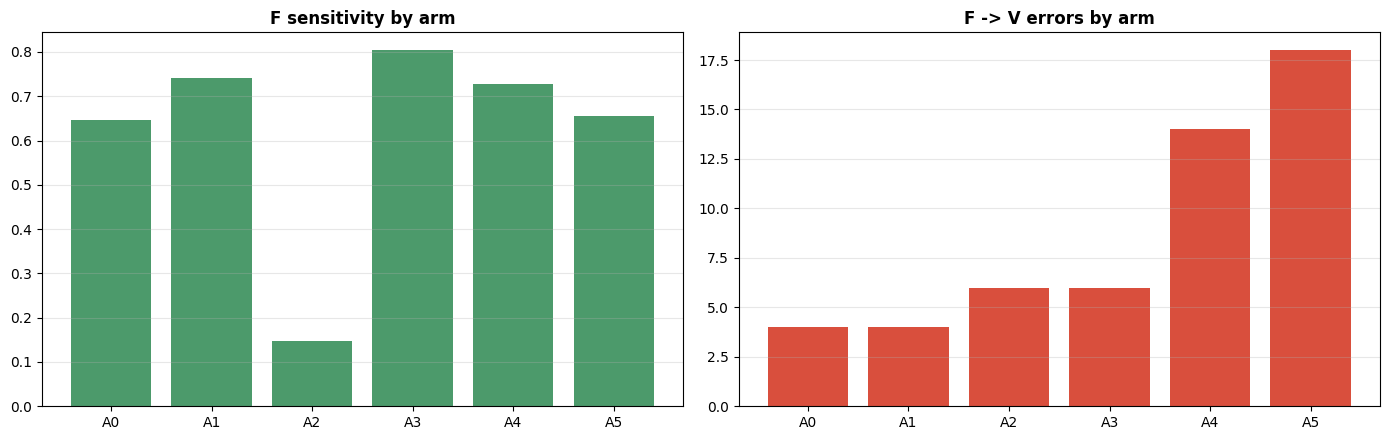

In [68]:
# ============================================================
# SECTION 9H — FOCUSED F-BEAT ABLATION (A0 … A5)
# ============================================================
# One arm per requested change, each differing from the arm above it by
# exactly one thing, all on the SAME record-disjoint split and the SAME test
# partition. Every arm trains MSFT-Net from scratch, so the table costs
# roughly len(F_ABLATION_ARMS) x F_ABLATION_EPOCHS epochs -- set
# RUN_F_ABLATION = False (Section 0) to skip it.
#
#   A0  original: attention pooling + focal balancing + F_AUGMENT_PROB 0.5, 1 copy
#   A1  A0 with GAP instead of attention pooling
#   A2  A1 + strengthened F augmentation (prob 1.0, F_AUGMENT_COPIES copies)
#   A3  A2 + F/V hard-negative mining (stage 2)
#   A4  A3 + F auxiliary losses (stage 3)
#   A5  A4 with balancing switched off -- the final reported configuration
#
# Nothing here selects anything on the test set: each arm early-stops on
# validation macro-F1 and is then evaluated once.
# ============================================================
if RUN_MSFT and RUN_F_ABLATION:
    # Sections 6D/6E define masked_bce / make_f_aux_targets_masked /
    # f_error_breakdown / use_sw_dict. If the aux stage was skipped, the aux
    # arms are dropped rather than crashing the table.
    _AUX_AVAILABLE = all(k in globals() for k in
                         ('masked_bce', 'make_f_aux_targets_masked'))
    use_sw_dict = globals().get('use_sw_dict', True)
    assert 'f_error_breakdown' in globals(), "run Section 6E before Section 9H"

    F_ARMS = {
        'A0 baseline (attention + focal)':
            dict(pooling='attention', balancing='focal', f_prob=0.5, f_copies=1,
                 hard=False, aux=False),
        'A1 + GAP pooling':
            dict(pooling='gap', balancing='focal', f_prob=0.5, f_copies=1,
                 hard=False, aux=False),
        'A2 + F augmentation':
            dict(pooling='gap', balancing='focal', f_prob=1.0, f_copies=F_AUGMENT_COPIES,
                 hard=False, aux=False),
        'A3 + F/V hard negatives':
            dict(pooling='gap', balancing='focal', f_prob=1.0, f_copies=F_AUGMENT_COPIES,
                 hard=True, aux=False),
        'A4 + F auxiliary loss':
            dict(pooling='gap', balancing='focal', f_prob=1.0, f_copies=F_AUGMENT_COPIES,
                 hard=True, aux=True),
        'A5 final (targeted, no focal)':
            dict(pooling='gap', balancing='none', f_prob=1.0, f_copies=F_AUGMENT_COPIES,
                 hard=True, aux=True),
    }
    F_ARMS = {k: v for k, v in F_ARMS.items() if k.split()[0] in F_ABLATION_ARMS}
    if not _AUX_AVAILABLE:
        for k in list(F_ARMS):
            if F_ARMS[k]['aux']:
                F_ARMS[k] = dict(F_ARMS[k], aux=False)
        print("NOTE: auxiliary-loss helpers unavailable -- A4/A5 run without the aux stage")

    def _run_f_arm(name, cfg):
        """Trains one ablation arm end-to-end and returns its TEST metrics.
        Globals are patched for the duration and restored in the finally block,
        so an interrupted arm cannot leave the notebook in a mutated state."""
        global MSFT_POOLING, F_AUGMENT_PROB, F_AUGMENT_COPIES
        saved = (MSFT_POOLING, F_AUGMENT_PROB, F_AUGMENT_COPIES)
        try:
            MSFT_POOLING = cfg['pooling']
            F_AUGMENT_PROB, F_AUGMENT_COPIES = cfg['f_prob'], cfg['f_copies']

            tf.keras.backend.clear_session()
            np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

            # arm-specific TRAINING set (test/val are never rebuilt)
            Xa, RRa, ya, ya_oh, cwa, lossa = build_training_set(
                cfg['balancing'], X_tr_raw, y_tr_int_raw, RR_tr_raw, verbose=False)
            swa = sample_weight_from_class_weight(ya, cwa)

            m = build_msft_net()
            m.compile(optimizer=Adam(MSFT_LR), loss=lossa,
                      metrics=['accuracy',
                               keras.metrics.F1Score(average='macro', name='macro_f1')])
            m.fit(mk_msft_in(Xa, RRa), ya_oh,
                  validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                  epochs=F_ABLATION_EPOCHS, batch_size=BATCH_SIZE, sample_weight=swa,
                  callbacks=[EarlyStopping(monitor='val_macro_f1', mode='max',
                                           patience=F_ABLATION_PATIENCE,
                                           restore_best_weights=True, verbose=0),
                             ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                               patience=4, min_lr=1e-6, verbose=0)],
                  verbose=0)

            sw_arm = swa
            if cfg['hard']:
                hw, hinfo = mine_hard_negatives(m, Xa, RRa, ya, mk_msft_in, verbose=False)
                if swa is not None:
                    hw = (hw * swa).astype(np.float32)
                sw_arm = hw
                if hinfo['n_hard']:
                    m.compile(optimizer=Adam(MSFT_LR * HARD_NEG_LR_SCALE), loss=lossa,
                              metrics=['accuracy',
                                       keras.metrics.F1Score(average='macro', name='macro_f1')])
                    m.fit(mk_msft_in(Xa, RRa), ya_oh,
                          validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                          epochs=HARD_NEG_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
                          sample_weight=sw_arm,
                          callbacks=[EarlyStopping(monitor='val_macro_f1', mode='max',
                                                   patience=5, restore_best_weights=True,
                                                   verbose=0)], verbose=0)

            if cfg['aux']:
                yfn, wfn, yfv, wfv = make_f_aux_targets_masked(ya, F_IDX, N_IDX, V_IDX)
                yfn_v, wfn_v, yfv_v, wfv_v = make_f_aux_targets_masked(y_val, F_IDX, N_IDX, V_IDX)
                tm = build_f_aux_train_model(
                    m, F_IDX, N_IDX, V_IDX, lambda_fn=LAMBDA_F_N, lambda_fv=LAMBDA_F_V,
                    shared_layer='head_dropout', main_output_name='predictions',
                    aux_loss=masked_bce, learning_rate=MSFT_LR * F_AUX_LR_SCALE,
                    main_loss=lossa)
                mn = getattr(tm, 'output_names', None)
                mn = mn[0] if mn else 'predictions'
                yd = {mn: ya_oh, 'f_vs_n_head': yfn, 'f_vs_v_head': yfv}
                yd_v = {mn: y_val_oh, 'f_vs_n_head': yfn_v, 'f_vs_v_head': yfv_v}
                swd = ({mn: sw_arm if sw_arm is not None
                        else np.ones(len(ya), dtype=np.float32),
                        'f_vs_n_head': wfn, 'f_vs_v_head': wfv} if use_sw_dict else None)
                tm.fit(mk_msft_in(Xa, RRa), yd,
                       validation_data=(mk_msft_in(X_val, RR_val), yd_v),
                       sample_weight=swd,
                       epochs=F_AUX_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
                       callbacks=[EarlyStopping(monitor=f'val_{mn}_macro_f1', mode='max',
                                                patience=5, restore_best_weights=True,
                                                verbose=0)], verbose=0)

            pred = np.argmax(m.predict(mk_msft_in(X_test, RR_test),
                                       batch_size=512, verbose=0), axis=1)
            r = f_error_breakdown(y_test, pred, tag=name)
            del m
            gc.collect()
            return r
        finally:
            MSFT_POOLING, F_AUGMENT_PROB, F_AUGMENT_COPIES = saved

    f_ablation_rows = []
    for _name, _cfg in F_ARMS.items():
        print("\n" + "=" * 62)
        print(f"  ABLATION ARM: {_name}")
        print(f"  {_cfg}")
        print("=" * 62)
        _t0 = time.perf_counter()
        _r = _run_f_arm(_name, _cfg)
        print(f"  arm finished in {(time.perf_counter() - _t0) / 60:.1f} min")
        f_ablation_rows.append({
            'Experiment': _name,
            'F Sensitivity': round(_r['F_sensitivity'], 4),
            'F Precision': round(_r['F_precision'], 4),
            'F1-F': round(_r['F_f1'], 4),
            'F->V': _r['F_to_V'],
            'F->N': _r['F_to_N'],
            'V recall': round(_r['V_recall'], 4),
            'N recall': round(_r['N_recall'], 4),
            'Overall Acc': round(_r['accuracy'], 4),
            'Macro F1': round(_r['macro_f1'], 4)})

    f_ablation_df = pd.DataFrame(f_ablation_rows).set_index('Experiment')
    print("\n" + "=" * 78)
    print("  SECTION 9H -- F-BEAT ABLATION (record-disjoint TEST set)")
    print("=" * 78)
    print(f_ablation_df.to_string())
    f_ablation_df.to_csv('f_ablation_table.csv')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].bar(range(len(f_ablation_df)), f_ablation_df['F Sensitivity'], color='#4c9a6b')
    axes[0].set_xticks(range(len(f_ablation_df)))
    axes[0].set_xticklabels([i.split()[0] for i in f_ablation_df.index])
    axes[0].set_title('F sensitivity by arm', fontweight='bold'); axes[0].grid(alpha=.3, axis='y')
    axes[1].bar(range(len(f_ablation_df)), f_ablation_df['F->V'], color='#d94f3d')
    axes[1].set_xticks(range(len(f_ablation_df)))
    axes[1].set_xticklabels([i.split()[0] for i in f_ablation_df.index])
    axes[1].set_title('F -> V errors by arm', fontweight='bold'); axes[1].grid(alpha=.3, axis='y')
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig('10_f_ablation.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    f_ablation_df = None
    print("RUN_F_ABLATION = False -- Section 9H skipped")


## Section 9Q — Q ablation A0 … A7 (Change 1–6, one at a time)

Each arm retrains MSFT-Net from scratch on the same record-disjoint split, differing
from the arm above it by exactly one mechanism, and adds the auxiliary-vector-dropout
arm the ablation evidence actually points at.

| arm | adds |
|---|---|
| A0 | current F-improved model (no Q mechanism) |
| A1 | + Q-specific augmentation |
| A2 | + Q hard-negative mining (margin mode) |
| A3 | + Q-vs-Others auxiliary head |
| A4 | + reduced F oversampling |
| A5 | + balanced mini-batches |
| A6 | + Q class weight 1.5 |
| A7 | final combined = the arms above that helped, + `AUX_VECTOR_DROPOUT` |

Model selection inside each arm uses validation only:
`0.30·macroF1 + 0.25·F1_F + 0.20·F1_Q + 0.15·recall_F + 0.10·recall_Q`.
The table is written by the run — **no cell in this notebook fills it in advance.**


In [69]:
# ============================================================
# SECTION 9Q — Q ABLATION A0 .. A7
# ============================================================
# Each arm: rebuild -> train (stage 1) -> optional mining fine-tune -> optional
# multi-task fine-tune -> evaluate ONCE on test. Every hyper-parameter decision
# is made on TRAIN/VAL; the test set is read only for the final row.

Q_ARM_SPECS = {
    'A0': dict(label='A0 current (F model)',   q_aug=False, q_mine=False, q_aux=False,
               reduce_f=False, balanced=False, q_w=1.0, aux_drop=0.0),
    'A1': dict(label='A1 + Q augmentation',    q_aug=True,  q_mine=False, q_aux=False,
               reduce_f=False, balanced=False, q_w=1.0, aux_drop=0.0),
    'A2': dict(label='A2 + Q hard-neg mining', q_aug=True,  q_mine=True,  q_aux=False,
               reduce_f=False, balanced=False, q_w=1.0, aux_drop=0.0),
    'A3': dict(label='A3 + Q aux head',        q_aug=True,  q_mine=True,  q_aux=True,
               reduce_f=False, balanced=False, q_w=1.0, aux_drop=0.0),
    'A4': dict(label='A4 + reduced F oversamp', q_aug=True, q_mine=True,  q_aux=True,
               reduce_f=True,  balanced=False, q_w=1.0, aux_drop=0.0),
    'A5': dict(label='A5 + balanced batches',  q_aug=True,  q_mine=True,  q_aux=True,
               reduce_f=True,  balanced=True,  q_w=1.0, aux_drop=0.0),
    'A6': dict(label='A6 + Q class weight',    q_aug=True,  q_mine=True,  q_aux=True,
               reduce_f=True,  balanced=True,  q_w=1.5, aux_drop=0.0),
    'A7': dict(label='A7 final + aux dropout', q_aug=True,  q_mine=True,  q_aux=True,
               reduce_f=True,  balanced=False, q_w=1.0, aux_drop=0.30),
}


def q_selection_score(y_true, y_pred):
    """Validation-only model-selection criterion. Deliberately NOT Q recall
    alone -- a model that predicts Q everywhere would win that."""
    mf = f1_score(y_true, y_pred, average='macro', zero_division=0)
    per_f1 = f1_score(y_true, y_pred, average=None, labels=range(NUM_CLASSES),
                      zero_division=0)
    per_rc = recall_score(y_true, y_pred, average=None, labels=range(NUM_CLASSES),
                          zero_division=0)
    return (0.30 * mf + 0.25 * per_f1[F_IDX] + 0.20 * per_f1[Q_IDX]
            + 0.15 * per_rc[F_IDX] + 0.10 * per_rc[Q_IDX])


def run_q_arm(name, spec, epochs=None, patience=None, seed=None):
    """One ablation arm. Returns a metrics dict; leaves globals as it found them."""
    epochs = Q_ABLATION_EPOCHS if epochs is None else epochs
    patience = Q_ABLATION_PATIENCE if patience is None else patience
    seed = SEED if seed is None else seed
    saved = {k: globals().get(k) for k in
             ('ENABLE_Q_AUGMENT', 'F_AUGMENT_PROB', 'F_AUGMENT_COPIES',
              'Q_CLASS_WEIGHT', 'ENABLE_Q_AUX_LOSS', 'AUX_VECTOR_DROPOUT',
              'AUX_FEATURE_DROPOUT', 'USE_BALANCED_BATCHES')}
    try:
        globals()['ENABLE_Q_AUGMENT'] = bool(spec['q_aug'])
        globals()['ENABLE_Q_AUX_LOSS'] = bool(spec['q_aux'])
        globals()['Q_CLASS_WEIGHT'] = float(spec['q_w'])
        globals()['USE_BALANCED_BATCHES'] = bool(spec['balanced'])
        globals()['AUX_VECTOR_DROPOUT'] = float(spec['aux_drop'])
        globals()['AUX_FEATURE_DROPOUT'] = 0.10 if spec['aux_drop'] > 0 else 0.0
        if spec['reduce_f']:
            globals()['F_AUGMENT_PROB'], globals()['F_AUGMENT_COPIES'] = 0.75, 2

        print("\n" + "=" * 62)
        print(f"  ARM {name}: {spec['label']}")
        print("=" * 62)

        # data is rebuilt per arm because F/Q augmentation changes it
        Xa, RRa, ya, ya_oh, cw_a, loss_a = build_training_set(
            BALANCING, X_tr_raw, y_tr_int_raw, RR_tr_raw, verbose=True)
        sw_base = sample_weight_from_class_weight(ya, cw_a)

        tf.keras.backend.clear_session()
        np.random.seed(seed); tf.random.set_seed(seed)
        m = build_msft_net()
        m.compile(optimizer=Adam(MSFT_LR), loss=loss_a, metrics=METRICS)
        sw0 = build_combined_sample_weights(ya, base_w=sw_base, q_idx=Q_IDX,
                                            q_class_weight=spec['q_w'])
        if spec['balanced']:
            ds, steps = make_balanced_dataset(Xa, RRa, ya, ya_oh, sample_weight=sw0)
            m.fit(ds, steps_per_epoch=steps,
                  validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                  epochs=epochs, callbacks=make_callbacks(f'q_arm_{name}'), verbose=0)
        else:
            m.fit(mk_msft_in(Xa, RRa), ya_oh,
                  validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                  epochs=epochs, batch_size=BATCH_SIZE, sample_weight=sw0,
                  callbacks=make_callbacks(f'q_arm_{name}'), verbose=0)

        if spec['q_mine']:
            hw, _hi = mine_hard_examples(m, Xa, RRa, ya, mk_msft_in, verbose=True)
            sw1 = build_combined_sample_weights(ya, hard_w=hw, base_w=sw_base,
                                                q_idx=Q_IDX, q_class_weight=spec['q_w'])
            m.compile(optimizer=Adam(MSFT_LR * HARD_NEG_LR_SCALE), loss=loss_a,
                      metrics=METRICS)
            m.fit(mk_msft_in(Xa, RRa), ya_oh,
                  validation_data=(mk_msft_in(X_val, RR_val), y_val_oh),
                  epochs=HARD_NEG_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
                  sample_weight=sw1,
                  callbacks=[EarlyStopping(monitor='val_macro_f1', mode='max',
                                           patience=4, restore_best_weights=True,
                                           verbose=0)], verbose=0)
        else:
            sw1 = sw0

        if spec['q_aux'] or ENABLE_F_AUX_LOSS:
            yfn, wfn, yfv, wfv = make_f_aux_targets_masked(ya, F_IDX, N_IDX, V_IDX)
            yfn_v, wfn_v, yfv_v, wfv_v = make_f_aux_targets_masked(y_val, F_IDX, N_IDX, V_IDX)
            yq, wq = make_q_aux_targets(ya, Q_IDX)
            yq_v, wq_v = make_q_aux_targets(y_val, Q_IDX)
            tm = build_aux_train_model(
                m, f_idx=F_IDX, n_idx=N_IDX, v_idx=V_IDX, q_idx=Q_IDX,
                shared_layer='head_dropout', main_output_name='predictions',
                aux_loss=masked_bce, learning_rate=MSFT_LR * F_AUX_LR_SCALE,
                use_f_heads=ENABLE_F_AUX_LOSS, use_q_head=spec['q_aux'])
            on = list(getattr(tm, 'output_names', []))
            yt = {'predictions': ya_oh, 'f_vs_n_head': yfn, 'f_vs_v_head': yfv,
                  'q_vs_rest_head': yq}
            yv = {'predictions': y_val_oh, 'f_vs_n_head': yfn_v, 'f_vs_v_head': yfv_v,
                  'q_vs_rest_head': yq_v}
            tm.fit(mk_msft_in(Xa, RRa), {k: yt[k] for k in on},
                   validation_data=(mk_msft_in(X_val, RR_val), {k: yv[k] for k in on}),
                   epochs=F_AUX_FINETUNE_EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=[EarlyStopping(monitor='val_predictions_macro_f1',
                                            mode='max', patience=4,
                                            restore_best_weights=True, verbose=0)],
                   verbose=0)

        vp = np.argmax(m.predict(mk_msft_in(X_val, RR_val), batch_size=512, verbose=0), 1)
        tp = np.argmax(m.predict(mk_msft_in(X_test, RR_test), batch_size=512, verbose=0), 1)
        f1c = f1_score(y_test, tp, average=None, labels=range(NUM_CLASSES), zero_division=0)
        rcc = recall_score(y_test, tp, average=None, labels=range(NUM_CLASSES), zero_division=0)
        prc = precision_score(y_test, tp, average=None, labels=range(NUM_CLASSES), zero_division=0)
        qb = q_confusion_breakdown(y_test, tp, Q_IDX, tag=spec['label'], show=False)
        row = dict(arm=name, label=spec['label'],
                   val_selection=q_selection_score(y_val, vp),
                   Q_recall=rcc[Q_IDX], Q_precision=prc[Q_IDX], Q_F1=f1c[Q_IDX],
                   F_recall=rcc[F_IDX], F_F1=f1c[F_IDX],
                   macro_F1=f1_score(y_test, tp, average='macro', zero_division=0),
                   accuracy=accuracy_score(y_test, tp),
                   MCC=matthews_corrcoef(y_test, tp),
                   kappa=cohen_kappa_score(y_test, tp),
                   Q_to_N=qb.get('Q_to_N', 0), Q_to_S=qb.get('Q_to_S', 0),
                   Q_to_V=qb.get('Q_to_V', 0), Q_to_F=qb.get('Q_to_F', 0),
                   F_to_V=int(((y_test == F_IDX) & (tp == V_IDX)).sum()))
        np.save(f'pred_q_arm_{name}.npy', tp)
        print(f"  {name}: Q Se={row['Q_recall']:.4f} Q F1={row['Q_F1']:.4f}  "
              f"F Se={row['F_recall']:.4f} F F1={row['F_F1']:.4f}  "
              f"macro-F1={row['macro_F1']:.4f} acc={row['accuracy']:.4f}")
        return row
    finally:
        globals().update(saved)


if globals().get('RUN_Q_ABLATION', False) and RUN_MSFT:
    q_ablation_rows = [run_q_arm(a, Q_ARM_SPECS[a]) for a in Q_ABLATION_ARMS
                       if a in Q_ARM_SPECS]
    q_ablation = pd.DataFrame(q_ablation_rows).set_index('arm')
    print("\n" + "=" * 100)
    print("  SECTION 9Q -- Q ABLATION RESULTS (record-disjoint test set)")
    print("=" * 100)
    print(q_ablation[['label', 'Q_recall', 'Q_precision', 'Q_F1', 'F_recall', 'F_F1',
                      'macro_F1', 'accuracy']].round(4).to_string())
    print("\n  Q destinations and the F safety check:")
    print(q_ablation[['label', 'Q_to_N', 'Q_to_S', 'Q_to_V', 'Q_to_F', 'F_to_V',
                      'MCC', 'kappa']].to_string())
    q_ablation.to_csv('q_ablation_A0_A7.csv')
    _best = q_ablation['val_selection'].idxmax()
    print(f"\n  best arm by the VALIDATION selection score: {_best} "
          f"({q_ablation.loc[_best, 'label']}) -- chosen on validation, "
          "its test row is a report, not a selection criterion")
else:
    q_ablation = None
    print("RUN_Q_ABLATION = False -- Section 9Q skipped")



  ARM A0: A0 current (F model)
  no imbalance correction (AAMI-purist baseline)
  augmentation -> 21,809 training beats (one perturbed copy of each; RR rows reused unchanged)
  F beats after augmentation: 1,995 (prob=1.0, copies=3; originals retained)
  training class distribution  original -> after augmentation:
    N-Normal     7,455 ->  14,910   ( 68.4% of training)
    S-Supra        774 ->   2,322   ( 10.6% of training)
    V-Ventri       283 ->     566   (  2.6% of training)
    F-Fusion       399 ->   1,995   (  9.1% of training)
    Q-Unknown    1,008 ->   2,016   (  9.2% of training)


KeyboardInterrupt: 

## Section 10 — Provenance controls for the CHF class

The CHF class comes from one database at one sampling rate. Before it can be claimed as a
clinical contribution, two questions must be answered: (A) can a model identify the *source
database* from a beat alone, and (B) does CHF performance survive when the resampling
signature is removed? If A is high and B collapses, the class is measuring hardware, not
pathology.

In [70]:
# ============================================================
# CONTROL A: source-database probe on N beats only
# ============================================================
if RUN_CONTROLS and USE_NSR:
    n_mask = (y_all == 0)
    src    = np.array(['nsr' if g.startswith('nsr') else 'mitdb' for g in g_all[n_mask]])
    if len(np.unique(src)) == 2:
        Xn = per_beat_zscore(X_all[n_mask].reshape(-1, BEAT_LENGTH, 1)).reshape(int(n_mask.sum()), -1)
        probe_test = set([f"nsr_{r}" for r in NSR_TEST] + [f"mitdb_{r}" for r in DS2_TEST])
        pm = np.isin(g_all[n_mask], list(probe_test))
        if pm.sum() > 0 and len(np.unique(src[~pm])) == 2:
            clf  = LogisticRegression(max_iter=2000, n_jobs=-1).fit(Xn[~pm], src[~pm])
            acc  = accuracy_score(src[pm], clf.predict(Xn[pm]))
            base = max((src[pm] == 'nsr').mean(), (src[pm] == 'mitdb').mean())
            print(f"Source-database probe: accuracy {acc:.4f}  (majority baseline {base:.4f})")
            print("Both beat sets are labelled N, so any accuracy above baseline is a")
            print("database fingerprint independent of cardiac class -- the same shortcut")
            print("that is available to the CHF class.")
else:
    print("controls skipped")

Source-database probe: accuracy 0.8791  (majority baseline 0.8611)
Both beat sets are labelled N, so any accuracy above baseline is a
database fingerprint independent of cardiac class -- the same shortcut
that is available to the CHF class.


In [71]:
# ============================================================
# CONTROL B: equalise bandwidth across databases, re-test
# ============================================================
def equalise_bandwidth(X, fs_native=360, fs_common=128):
    """Down- then up-sample every beat through a common 128 Hz, so MIT-BIH loses the
    >64 Hz content that NSR/CHF beats never had. Removes the interpolation signature."""
    out = []
    for b in np.asarray(X).reshape(len(X), -1):
        d = resample_poly(b, fs_common, fs_native)
        u = resample_poly(d, fs_native, fs_common)
        u = u[:BEAT_LENGTH] if len(u) >= BEAT_LENGTH else np.pad(u, (0, BEAT_LENGTH - len(u)))
        out.append(u)
    return per_beat_zscore(np.asarray(out, dtype=np.float32).reshape(-1, BEAT_LENGTH, 1))

if RUN_CONTROLS:
    X_test_eq = equalise_bandwidth(X_test)
    y_eq = np.argmax(model.predict(mk_in(X_test_eq, RR_test), verbose=0), axis=1)
    print(f"accuracy: original {test_accuracy:.4f} -> bandwidth-equalised "
          f"{accuracy_score(y_true, y_eq):.4f}\n")
    f1_o = f1_score(y_true, y_pred, average=None, labels=range(NUM_CLASSES), zero_division=0)
    f1_e = f1_score(y_true, y_eq,   average=None, labels=range(NUM_CLASSES), zero_division=0)
    print(f"{'class':<12}{'F1 orig':>10}{'F1 equalised':>15}{'delta':>10}")
    for i, nm in enumerate(CLASS_NAMES):
        print(f"{nm:<12}{f1_o[i]:>10.4f}{f1_e[i]:>15.4f}{f1_e[i]-f1_o[i]:>+10.4f}")
    print("\nA large CHF-specific drop indicates the class was partly band-limiting artefact.")
    print("If so: drop the class and report the standard 5-class AAMI problem.")

accuracy: original 0.8200 -> bandwidth-equalised 0.8201

class          F1 orig   F1 equalised     delta
N-Normal        0.8718         0.8719   +0.0001
S-Supra         0.7905         0.7908   +0.0004
V-Ventri        0.8391         0.8391   +0.0000
F-Fusion        0.7287         0.7287   +0.0000
Q-Unknown       0.4328         0.4328   +0.0000

A large CHF-specific drop indicates the class was partly band-limiting artefact.
If so: drop the class and report the standard 5-class AAMI problem.


## Section 11 — Explainability: Grad-CAM, attention weights, Integrated Gradients, faithfulness

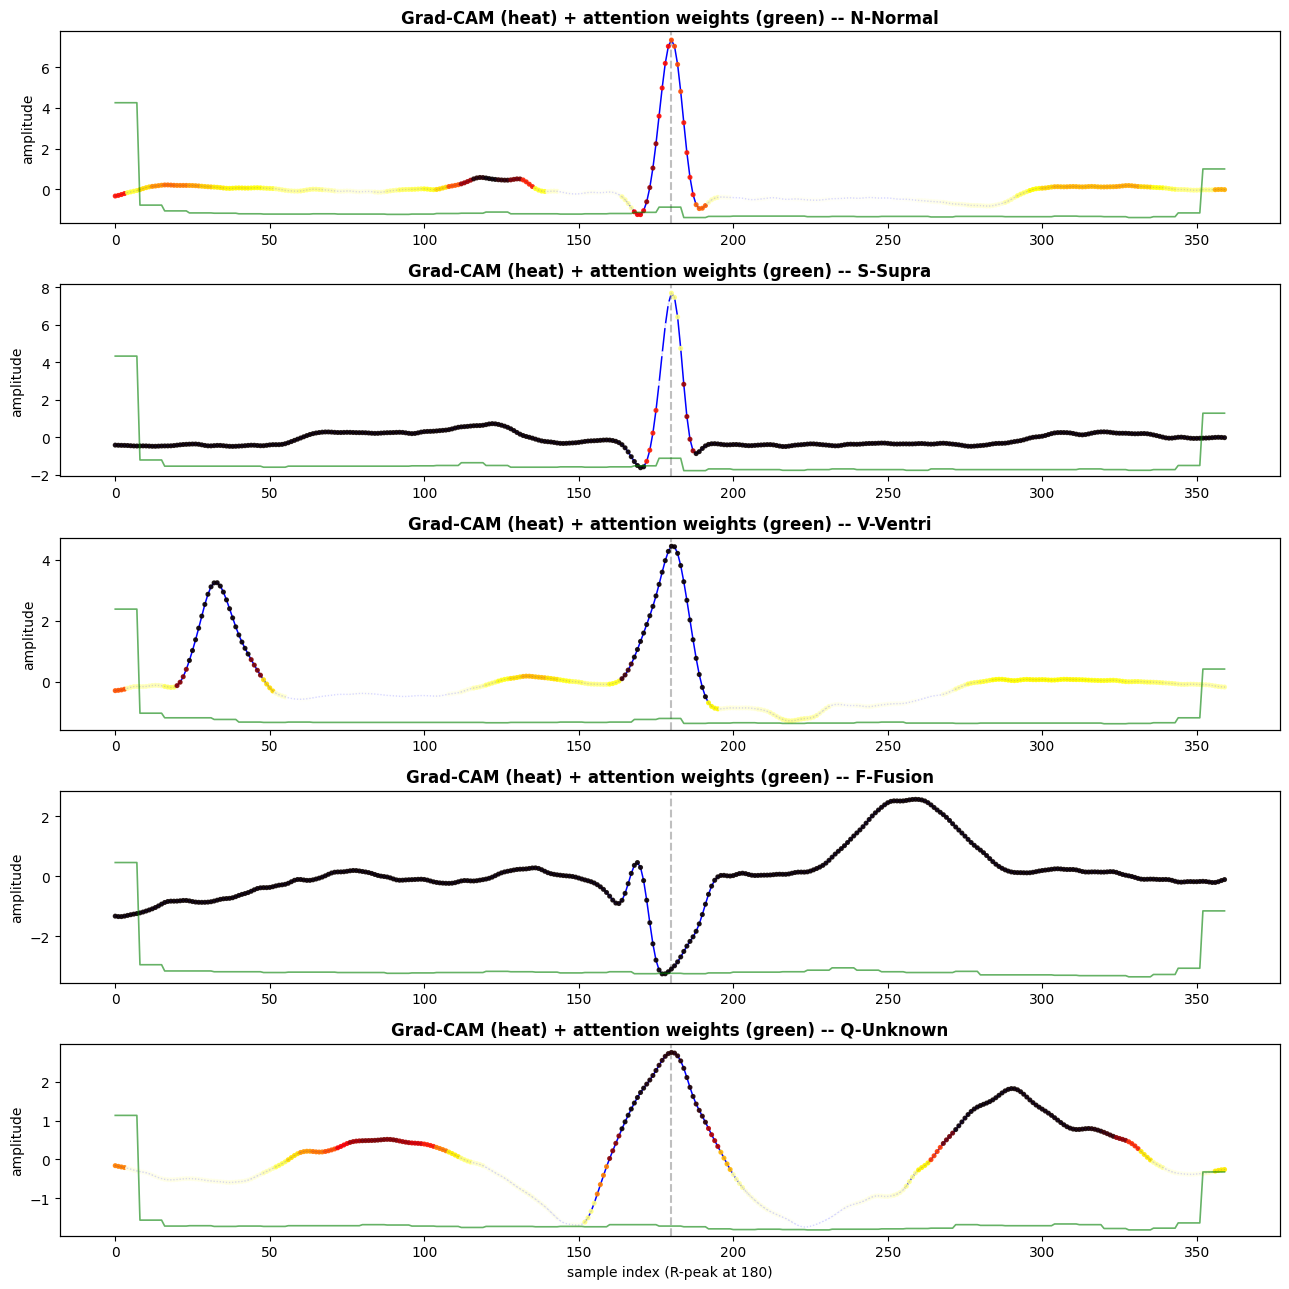

In [72]:
# ============================================================
# SECTION 11A: Grad-CAM, reimplemented with GradientTape
# (no tf-keras-vis dependency -- it is fragile under Keras 3)
# ============================================================
def grad_cam(model, x, target_class, layer_name='act3', rr=None):
    """Gradient-weighted class activation map at `layer_name`.
    CAVEAT: a BiLSTM sits between this layer and the output, so gradients travel through
    backpropagation-through-time and the spatial correspondence assumed by the overlay is
    only approximate. Integrated Gradients (below) does not have this problem."""
    grad_model = keras.Model(model.inputs, [model.get_layer(layer_name).output, model.output])
    xt = tf.convert_to_tensor(x[None, ...], dtype=tf.float32)
    if USE_RR:
        rt = tf.convert_to_tensor((np.ones((1, N_RR), np.float32) if rr is None
                                   else rr[None, :].astype(np.float32)))
        xt = [xt, rt]
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(xt, training=False)
        loss = preds[:, target_class]
    grads = tape.gradient(loss, conv_out)                    # (1, T', C)
    w   = tf.reduce_mean(grads, axis=1)                      # (1, C)
    cam = tf.nn.relu(tf.reduce_sum(conv_out * w[:, None, :], axis=-1))[0].numpy()
    cam = np.repeat(cam, BEAT_LENGTH // len(cam))            # upsample to input length
    if len(cam) < BEAT_LENGTH:
        cam = np.pad(cam, (0, BEAT_LENGTH - len(cam)), mode='edge')
    return (cam[:BEAT_LENGTH] - cam.min()) / (cam.max() - cam.min() + 1e-8)


def attention_weights(model, x, rr=None):
    """The model's OWN temporal importance distribution -- exact, free, no approximation."""
    att = keras.Model(model.inputs, model.get_layer('att_weights').output)
    xin = mk_in(x[None, ...], (np.ones((1, N_RR), np.float32) if rr is None
                               else rr[None, :].astype(np.float32)))
    a = att.predict(xin, verbose=0)[0]                       # (45,)
    a = np.repeat(a, BEAT_LENGTH // len(a))
    return (a - a.min()) / (a.max() - a.min() + 1e-8)


if RUN_EXPLAIN:
    fig, axes = plt.subplots(NUM_CLASSES, 1, figsize=(13, 2.6 * NUM_CLASSES))
    axes = np.atleast_1d(axes)
    for c in range(NUM_CLASSES):
        hits = np.where((y_true == c) & (y_pred == c))[0]
        if len(hits) == 0:
            axes[c].set_title(f'{CLASS_NAMES[c]} -- no correct prediction'); continue
        beat, beat_rr = X_test[hits[0]], RR_test[hits[0]]
        cam  = grad_cam(model, beat, c, rr=beat_rr)
        att  = attention_weights(model, beat, rr=beat_rr)
        t = np.arange(BEAT_LENGTH)
        axes[c].plot(t, beat[:, 0], 'b-', lw=1.1, zorder=2)
        axes[c].scatter(t, beat[:, 0], c=cam, cmap='hot', s=7, zorder=3, alpha=.85)
        ax2 = axes[c].twinx()
        ax2.plot(t, att, color='green', lw=1.2, alpha=.6, label='attention weight')
        ax2.set_ylim(-0.05, 1.6); ax2.set_yticks([])
        axes[c].axvline(BEAT_LENGTH // 2, color='gray', ls='--', alpha=.5)
        axes[c].set_title(f'Grad-CAM (heat) + attention weights (green) -- {CLASS_NAMES[c]}',
                          fontweight='bold')
        axes[c].set_ylabel('amplitude')
    axes[-1].set_xlabel('sample index (R-peak at 180)')
    plt.tight_layout()
    if SAVE_FIGURES: plt.savefig('04_gradcam_attention.png', dpi=300, bbox_inches='tight')
    plt.show()

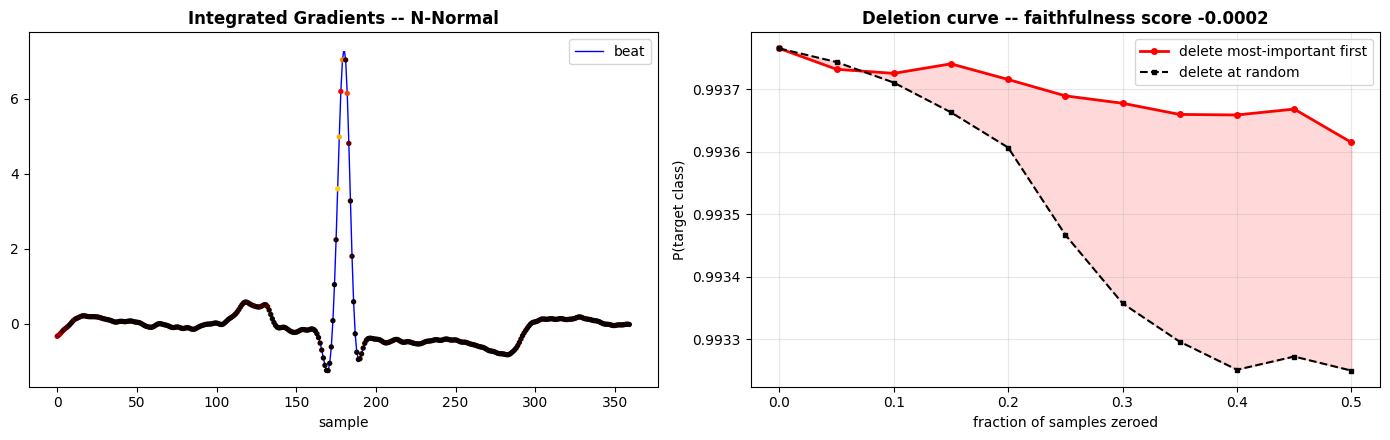

Faithfulness score (mean gap random - important): -0.0002
Near zero => the attribution is no better than chance at finding evidence.


In [73]:
# ============================================================
# SECTION 11B: Integrated Gradients + deletion-curve faithfulness test
# ============================================================
def integrated_gradients(model, x, target, steps=50, rr=None):
    """Path integral of gradients from a zero baseline (the isoelectric line after
    per-beat z-scoring). Full input resolution, axiomatically grounded, and correct
    through the recurrent block."""
    xt = tf.convert_to_tensor(x[None, ...], dtype=tf.float32)
    baseline = tf.zeros_like(xt)
    alphas = tf.reshape(tf.linspace(0.0, 1.0, steps), (steps, 1, 1))
    path = baseline + alphas * (xt - baseline)
    rr_path = None
    if USE_RR:
        rr_row = np.ones((1, N_RR), np.float32) if rr is None else rr[None, :].astype(np.float32)
        rr_path = tf.convert_to_tensor(np.repeat(rr_row, steps, axis=0))
    with tf.GradientTape() as tape:
        tape.watch(path)
        out = model([path, rr_path] if USE_RR else path, training=False)[:, target]
    grads = tape.gradient(out, path)
    avg = tf.reduce_mean((grads[:-1] + grads[1:]) / 2.0, axis=0)
    return ((xt[0] - baseline[0]) * avg).numpy().squeeze()


def deletion_curve(model, x, target, attribution, fracs=np.linspace(0, 0.5, 11), rs=None,
                   rr=None):
    """Zero the most-important samples first and watch the target probability fall.
    A faithful attribution decays much faster than random deletion; the gap between the
    two curves is a scalar faithfulness score."""
    order = np.argsort(-np.abs(attribution))
    rand  = (rs or np.random.default_rng(0)).permutation(len(attribution))
    imp, rnd = [], []
    for f in fracs:
        k = int(f * len(order))
        for idxs, store in ((order[:k], imp), (rand[:k], rnd)):
            xm = x.copy().squeeze(); xm[idxs] = 0.0
            rr_row = np.ones((1, N_RR), np.float32) if rr is None else rr[None, :].astype(np.float32)
            store.append(float(model.predict(mk_in(xm[None, :, None], rr_row),
                                             verbose=0)[0, target]))
    return fracs, np.array(imp), np.array(rnd)


if RUN_EXPLAIN:
    cls = int(np.bincount(y_true).argmax())
    hits = np.where((y_true == cls) & (y_pred == cls))[0]
    beat, beat_rr = X_test[hits[0]], RR_test[hits[0]]
    ig  = integrated_gradients(model, beat, cls, rr=beat_rr)
    cam = grad_cam(model, beat, cls, rr=beat_rr)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    t = np.arange(BEAT_LENGTH)
    axes[0].plot(t, beat[:, 0], 'b-', lw=1, label='beat')
    axes[0].scatter(t, beat[:, 0], c=np.abs(ig), cmap='hot', s=8, zorder=3)
    axes[0].set_title(f'Integrated Gradients -- {CLASS_NAMES[cls]}', fontweight='bold')
    axes[0].set_xlabel('sample'); axes[0].legend()

    fr, imp, rnd = deletion_curve(model, beat, cls, ig, rr=beat_rr)
    axes[1].plot(fr, imp, 'r-o', lw=2, ms=4, label='delete most-important first')
    axes[1].plot(fr, rnd, 'k--s', lw=1.5, ms=3, label='delete at random')
    axes[1].fill_between(fr, imp, rnd, alpha=.15, color='red')
    score = float(np.mean(rnd - imp))
    axes[1].set_xlabel('fraction of samples zeroed'); axes[1].set_ylabel('P(target class)')
    axes[1].set_title(f'Deletion curve -- faithfulness score {score:.4f}', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=.3)
    plt.tight_layout()
    if SAVE_FIGURES: plt.savefig('05_integrated_gradients.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Faithfulness score (mean gap random - important): {score:.4f}")
    print("Near zero => the attribution is no better than chance at finding evidence.")

## Section 12 — Microcontroller model: INT8 quantisation, operator audit, latency

The MCU artefact is built from `build_mcu_model`, not from either research model. The gated-fusion model is deliberately excluded: `MultiHeadAttention` lowers to `BATCH_MATMUL` and `SOFTMAX` over a transposed axis, and `LayerNormalization` has no TFLM builtin, so the operator audit below would fail on it. Reporting the fusion model as edge-deployable without measuring it would be exactly the kind of claim this notebook exists to avoid.

In [74]:
# ============================================================
# SECTION 12A: train the MCU variant on the SAME split
# ============================================================
if RUN_MCU:
    tf.keras.backend.clear_session()
    np.random.seed(SEED); tf.random.set_seed(SEED)
    mcu = build_mcu_model()
    mcu.summary()
    mcu.compile(optimizer=Adam(1e-3), loss=LOSS_FN, metrics=METRICS)
    mcu.fit(X_tr, y_tr_oh, validation_data=(X_val, y_val_oh),
            epochs=EPOCHS, batch_size=BATCH_SIZE, sample_weight=sample_weight_tr,
            callbacks=make_callbacks('ecg_mcu'), verbose=1)
    pred_mcu_fp = np.argmax(mcu.predict(X_test, verbose=0), axis=1)
    acc_mcu_fp  = accuracy_score(y_true, pred_mcu_fp)
    print(f"\nMCU model (float32): accuracy {acc_mcu_fp:.4f}  "
          f"({mcu.count_params():,} params vs {model.count_params():,} for the hybrid, "
          f"{model.count_params()/mcu.count_params():.1f}x smaller)")
    mcu.save('ecg_mcu.keras')

Model: "ECG_MCU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 360, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 360, 16)        │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 360, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 360, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 180, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 180, 32)        │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 180, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 180, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d                │ (None, 90, 48)         │         1,696 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 90, 48)         │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 90, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 45, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 45, 64)         │         3,312 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 45, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           245 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 11,685 (45.64 KB)

 Trainable params: 11,365 (44.39 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8197 - loss: 0.5627 - macro_f1: 0.6493 - val_accuracy: 0.3650 - val_loss: 1.2598 - val_macro_f1: 0.1510 - learning_rate: 0.0010
Epoch 2/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9179 - loss: 0.2764 - macro_f1: 0.7704 - val_accuracy: 0.8697 - val_loss: 0.4828 - val_macro_f1: 0.5056 - learning_rate: 0.0010
Epoch 3/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9376 - loss: 0.2125 - macro_f1: 0.8470 - val_accuracy: 0.8614 - val_loss: 0.7113 - val_macro_f1: 0.4397 - learning_rate: 0.0010
Epoch 4/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9482 - loss: 0.1811 - macro_f1: 0.8788 - val_accuracy: 0.8539 - val_loss: 0.8987 - val_macro_f1: 0.4220 - learning_rate: 0.0010
Epoch 5/60
357/357 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9527 - loss: 0.1632 - macro_f1: 0.8891 - val_accuracy: 0.8433 - val_loss: 0.6600 - val_macro_f1: 0.5125 - learning_rate: 0.0010
Epoch 6/60
357/357 ━━━━━━

In [75]:
# ============================================================
# SECTION 12B: full INT8 quantisation + TFLM operator audit
# ============================================================
TFLM_BUILTIN_OK = {'CONV_2D','DEPTHWISE_CONV_2D','MAX_POOL_2D','AVERAGE_POOL_2D','MEAN',
                   'FULLY_CONNECTED','SOFTMAX','RESHAPE','RELU','ADD','MUL','LOGISTIC',
                   'PAD','QUANTIZE','DEQUANTIZE','EXPAND_DIMS','CONCATENATION','STRIDED_SLICE'}

def make_interpreter(content):
    try:
        from ai_edge_litert.interpreter import Interpreter      # TF >= 2.16 preferred path
        return Interpreter(model_content=content)
    except Exception:
        return tf.lite.Interpreter(model_content=content)

def convert_int8(keras_model, X_rep, out_path, n_rep=400):
    """Fully-integer quantisation (weights, activations, AND input/output tensors),
    calibrated on REAL training beats -- never random noise."""
    idx = np.random.default_rng(SEED).choice(len(X_rep), min(n_rep, len(X_rep)), replace=False)
    sample = X_rep[idx].astype('float32')
    def rep_gen():
        for i in range(len(sample)):
            yield [sample[i:i+1]]
    try:
        conv = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    except Exception as e:                                     # Keras 3 fallback
        print(f"  from_keras_model failed ({e}); exporting SavedModel first")
        keras_model.export('/tmp/ecg_saved')
        conv = tf.lite.TFLiteConverter.from_saved_model('/tmp/ecg_saved')
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = rep_gen
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type  = tf.int8
    conv.inference_output_type = tf.int8
    blob = conv.convert()
    with open(out_path, 'wb') as f:
        f.write(blob)
    print(f"  wrote {out_path}: {len(blob)/1024:.1f} KB")
    return blob

def eval_int8(blob, X, y):
    it = make_interpreter(blob); it.allocate_tensors()
    inp, out = it.get_input_details()[0], it.get_output_details()[0]
    s_in, z_in = inp['quantization']
    preds = np.empty(len(X), dtype=np.int32)
    for i in range(len(X)):
        q = np.round(X[i] / s_in + z_in).astype(np.int8)[None, ...]
        it.set_tensor(inp['index'], q); it.invoke()
        preds[i] = int(np.argmax(it.get_tensor(out['index'])[0]))
    return preds, accuracy_score(y, preds)

if RUN_MCU:
    blob = convert_int8(mcu, X_tr, 'ecg_mcu_int8.tflite')

    it = make_interpreter(blob); it.allocate_tensors()
    try:
        ops = sorted({o['op_name'] for o in it._get_ops_details() if o['op_name'] != 'DELEGATE'})
        bad = [o for o in ops if o not in TFLM_BUILTIN_OK]
        print(f"  ops: {ops}")
        print(f"  unsupported by TFLite Micro: {bad if bad else 'none -- all good'}")
    except Exception as e:
        print(f"  op audit unavailable on this TF build ({type(e).__name__}); skipping")
    print(f"  input  {it.get_input_details()[0]['dtype']}  quant {it.get_input_details()[0]['quantization']}")
    print(f"  output {it.get_output_details()[0]['dtype']} quant {it.get_output_details()[0]['quantization']}")

    pred_mcu, acc_mcu_int8 = eval_int8(blob, X_test, y_true)
    np.save('pred_mcu_int8.npy', pred_mcu)
    print(f"\n  INT8 accuracy {acc_mcu_int8:.4f}  (float32 was {acc_mcu_fp:.4f}, "
          f"quantisation cost {acc_mcu_fp-acc_mcu_int8:+.4f})")
    p, da, db = mcnemar_test(pred_mcu, y_pred, y_true)
    print(f"  McNemar vs the hybrid: p = {p:.4f} -> "
          f"{'SIGNIFICANT difference' if p < 0.05 else 'statistically indistinguishable'}")

INFO:tensorflow:Assets written to: /tmp/tmp42ohpuv4/assets


INFO:tensorflow:Assets written to: /tmp/tmp42ohpuv4/assets


Saved artifact at '/tmp/tmp42ohpuv4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 360, 1), dtype=tf.float32, name='ecg_input')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134780107315280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136249424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136250960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136250768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136251152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136243472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136251728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136245776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136249040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136247312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134776136250576: Tenso

W0000 00:00:1786472946.965842      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1786472946.965876      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1786472946.982062      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


  wrote ecg_mcu_int8.tflite: 29.9 KB
  ops: ['CONV_2D', 'DEPTHWISE_CONV_2D', 'EXPAND_DIMS', 'FULLY_CONNECTED', 'MAX_POOL_2D', 'MEAN', 'RESHAPE', 'SOFTMAX']
  unsupported by TFLite Micro: none -- all good
  input  <class 'numpy.int8'>  quant (0.061309631913900375, -5)
  output <class 'numpy.int8'> quant (0.00390625, -128)

  INT8 accuracy 0.6746  (float32 was 0.6699, quantisation cost -0.0047)
  McNemar vs the hybrid: p = 0.0000 -> SIGNIFICANT difference


In [76]:
# ============================================================
# SECTION 12C: latency, memory, and C array export
# ============================================================
if RUN_MCU:
    _ = model.predict(mk_in(X_test[:64], RR_test[:64]), verbose=0)   # warm-up
    t0 = time.perf_counter()
    for _ in range(20): model.predict(mk_in(X_test[:1], RR_test[:1]), verbose=0)
    lat_hybrid = (time.perf_counter() - t0) / 20 * 1000

    it = make_interpreter(blob); it.allocate_tensors()
    inp = it.get_input_details()[0]; s_in, z_in = inp['quantization']
    t0 = time.perf_counter()
    for i in range(200):
        q = np.round(X_test[i] / s_in + z_in).astype(np.int8)[None, ...]
        it.set_tensor(inp['index'], q); it.invoke()
    lat_int8 = (time.perf_counter() - t0) / 200 * 1000

    try:
        biggest = max(int(np.prod(d['shape'])) * np.dtype(d['dtype']).itemsize
                      for d in it.get_tensor_details() if len(d['shape']) > 0)
        arena = f"{biggest/1024:.1f} KB (largest single tensor; true arena is larger)"
    except Exception:
        arena = "unavailable"

    print(f"latency  hybrid (batch=1) : {lat_hybrid:8.2f} ms/beat")
    print(f"latency  INT8 TFLite      : {lat_int8:8.2f} ms/beat")
    print(f"flash    INT8 model       : {len(blob)/1024:8.1f} KB")
    print(f"RAM      {arena}")
    print(f"real-time budget at 3 beats/s: 333 ms/beat -- "
          f"{'MET' if lat_int8 < 333 else 'NOT met'}")
    print("NOTE: measured on Kaggle CPU/GPU, NOT on the target MCU. An STM32/ESP32")
    print("      measurement is still required before claiming on-device real-time operation.")

    # C array for firmware
    with open('ecg_model.h', 'w') as f:
        f.write("#ifndef ECG_MODEL_H_\n#define ECG_MODEL_H_\n"
                "extern const unsigned char g_ecg_model[];\n"
                "extern const unsigned int g_ecg_model_len;\n#endif\n")
    with open('ecg_model.cc', 'w') as f:
        f.write('#include "ecg_model.h"\n'
                'alignas(16) const unsigned char g_ecg_model[] = {\n')
        for i in range(0, len(blob), 12):
            f.write("  " + ", ".join(f"0x{b:02x}" for b in blob[i:i+12]) + ",\n")
        f.write(f"}};\nconst unsigned int g_ecg_model_len = {len(blob)};\n")
    print("\nwrote ecg_model.cc / ecg_model.h for firmware integration")

latency  hybrid (batch=1) :    95.27 ms/beat
latency  INT8 TFLite      :     0.07 ms/beat
flash    INT8 model       :     29.9 KB
RAM      5.6 KB (largest single tensor; true arena is larger)
real-time budget at 3 beats/s: 333 ms/beat -- MET
NOTE: measured on Kaggle CPU/GPU, NOT on the target MCU. An STM32/ESP32
      measurement is still required before claiming on-device real-time operation.

wrote ecg_model.cc / ecg_model.h for firmware integration


## Section 13 — Robustness under realistic ambulatory corruption

     corruption     level  accuracy  macro-F1
           none         -    0.8200    0.7326
 gaussian noise 20 dB SNR    0.8201    0.7328
 gaussian noise 15 dB SNR    0.8198    0.7330
 gaussian noise 10 dB SNR    0.8218    0.7348
 gaussian noise  5 dB SNR    0.8225    0.7352
 gaussian noise  0 dB SNR    0.8231    0.7356
baseline wander  amp 0.25    0.8200    0.7326
baseline wander   amp 0.5    0.8201    0.7327
baseline wander   amp 1.0    0.8197    0.7323


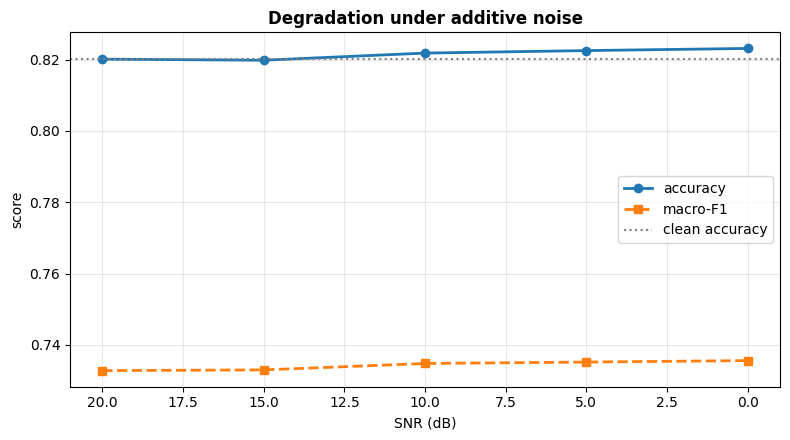

In [77]:
# ============================================================
# SECTION 13: noise and baseline-wander sweep
# ============================================================
def add_noise(X, snr_db, rs):
    Xf = np.asarray(X).reshape(len(X), -1)
    p_sig = np.mean(Xf ** 2, axis=1, keepdims=True)
    p_noise = p_sig / (10 ** (snr_db / 10.0))
    return per_beat_zscore((Xf + rs.standard_normal(Xf.shape) * np.sqrt(p_noise))
                           .astype(np.float32).reshape(-1, BEAT_LENGTH, 1))

def add_baseline_wander(X, amp, rs, fs=360.0, f0=0.3):
    Xf = np.asarray(X).reshape(len(X), -1)
    t  = np.arange(BEAT_LENGTH) / fs
    ph = rs.uniform(0, 2 * np.pi, (len(Xf), 1))
    return per_beat_zscore((Xf + amp * np.sin(2*np.pi*f0*t[None, :] + ph))
                           .astype(np.float32).reshape(-1, BEAT_LENGTH, 1))

if RUN_ROBUSTNESS:
    rs = np.random.default_rng(SEED)
    rows = [{'corruption': 'none', 'level': '-', 'accuracy': round(test_accuracy, 4),
             'macro-F1': round(test_f1_macro, 4)}]
    for snr in [20, 15, 10, 5, 0]:
        p = np.argmax(model.predict(mk_in(add_noise(X_test, snr, rs), RR_test),
                                    verbose=0), axis=1)
        rows.append({'corruption': 'gaussian noise', 'level': f'{snr} dB SNR',
                     'accuracy': round(accuracy_score(y_true, p), 4),
                     'macro-F1': round(f1_score(y_true, p, average='macro', zero_division=0), 4)})
    for amp in [0.25, 0.5, 1.0]:
        p = np.argmax(model.predict(mk_in(add_baseline_wander(X_test, amp, rs), RR_test),
                                    verbose=0), axis=1)
        rows.append({'corruption': 'baseline wander', 'level': f'amp {amp}',
                     'accuracy': round(accuracy_score(y_true, p), 4),
                     'macro-F1': round(f1_score(y_true, p, average='macro', zero_division=0), 4)})
    df_rob = pd.DataFrame(rows)
    print(df_rob.to_string(index=False))
    df_rob.to_csv('robustness_results.csv', index=False)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    nz = df_rob[df_rob.corruption == 'gaussian noise']
    ax.plot([20,15,10,5,0], nz['accuracy'], 'o-', lw=2, label='accuracy')
    ax.plot([20,15,10,5,0], nz['macro-F1'], 's--', lw=2, label='macro-F1')
    ax.axhline(test_accuracy, color='gray', ls=':', label='clean accuracy')
    ax.invert_xaxis(); ax.set_xlabel('SNR (dB)'); ax.set_ylabel('score')
    ax.set_title('Degradation under additive noise', fontweight='bold')
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout()
    if SAVE_FIGURES: plt.savefig('06_robustness.png', dpi=300, bbox_inches='tight')
    plt.show()

## Section 14 — Summary and artefact manifest

In [78]:
# ============================================================
# SECTION 14: Final summary
# ============================================================
print("=" * 68)
print("  RUN SUMMARY")
print("=" * 68)
print(f"  protocol        : {PROTOCOL}-patient "
      + ("(record-disjoint -- publishable)" if PROTOCOL == 'inter'
         else "(random split -- upper bound only, NOT publishable)"))
print(f"  classes         : {NUM_CLASSES}  {CLASS_NAMES}")
print(f"  records         : MIT-BIH {len(mitbih_names)} | NSR {len(nsr_names)} | CHF {len(chf_names)}")
print(f"  beats           : {len(X_all):,} total | train {len(X_tr):,} "
      f"(post-SMOTE) | val {len(X_val):,} | test {len(X_test):,}")
print(f"  AAMI strict     : {AAMI_STRICT}"
      + ("  (EC57 five-class grouping)" if AAMI_STRICT else ""))
if INCLUDE_Q_CLASS and Q_POLICY != 'exclude':
    print(f"  Q class         : reported | policy='{Q_POLICY}' | "
          f"paced train={PACED_TRAIN} val={PACED_VAL} test={PACED_TEST}")
    if Q_POLICY == 'q_only_from_paced':
        print("                    (paced records contribute Q beats only, so the "
              "N/S/V/F supports\n                     match the paced-excluded run and stay EC57-conformant)")
    else:
        print("                    *** paced records kept whole -- N/S/V/F metrics are "
              "NOT EC57-conformant ***")
else:
    print("  Q class         : not reported (paced records excluded)")
print(f"  balancing       : {BALANCING}  (test set never resampled)")
print(f"  RR features     : {USE_RR}  ({N_RR} per beat, patient-relative)")
print(f"  augmentation    : {USE_AUGMENT}  (training partition only)")
print(f"\n  hybrid accuracy : {test_accuracy:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
print(f"  hybrid macro-F1 : {test_f1_macro:.4f}")
print(f"  hybrid params   : {model.count_params():,}")
if RUN_MSFT and y_pred_msft is not None:
    print(f"\n  MSFT-Net accuracy : {acc_msft:.4f}  95% CI [{lo_msft:.4f}, {hi_msft:.4f}]")
    print(f"  MSFT-Net macro-F1 : {f1_msft:.4f}")
    print(f"  MSFT-Net params   : {model_msft.count_params():,}")
    print(f"  hybrid vs MSFT-Net: McNemar p = {p_val:.3e} -> "
          + ("significant" if p_val < 0.05 else "NOT significant"))
if RUN_MCU:
    print(f"  MCU INT8        : {acc_mcu_int8:.4f} accuracy, {len(blob)/1024:.1f} KB, "
          f"{mcu.count_params():,} params")

if AAMI_STRICT:
    print("  reporting       : EC57 gross + average Se/+P (see Section 7B)")

print("\n  Claims this run DOES support:")
print("   - beat classification performance under the stated protocol, with CIs")
print("   - every source record contributes (no single-patient class)")
print("   - a quantised artefact whose accuracy was measured, not extrapolated")
if RUN_MSFT and y_pred_msft is not None:
    print("   - a paired architecture comparison with a significance test, not a")
    print("     leaderboard of numbers from different splits")
print("\n  Claims this run does NOT support:")
print("   - external validation (no database outside the three used)")
print("   - on-device real-time operation (no measurement on target hardware)")
print("   - calibrated probabilities or an abstention option")
print("   - prospective clinical utility")

import glob
print("\n  Artefacts written:")
for f in sorted(glob.glob('*.png') + glob.glob('*.csv') + glob.glob('*.npy')
                + glob.glob('*.keras') + glob.glob('*.tflite') + glob.glob('ecg_model.*')):
    print(f"    {f:<34} {os.path.getsize(f)/1024:>9.1f} KB")
print("=" * 68)

  RUN SUMMARY
  protocol        : inter-patient (record-disjoint -- publishable)
  classes         : 5  ['N-Normal', 'S-Supra', 'V-Ventri', 'F-Fusion', 'Q-Unknown']
  records         : MIT-BIH 48 | NSR 18 | CHF 0
  beats           : 21,571 total | train 22,817 (post-SMOTE) | val 2,540 | test 9,112
  AAMI strict     : True  (EC57 five-class grouping)
  Q class         : reported | policy='q_only_from_paced' | paced train=['102', '217'] val=['104'] test=['107']
                    (paced records contribute Q beats only, so the N/S/V/F supports
                     match the paced-excluded run and stay EC57-conformant)
  balancing       : none  (test set never resampled)
  RR features     : True  (107 per beat, patient-relative)
  augmentation    : True  (training partition only)

  hybrid accuracy : 0.8200  95% CI [0.8120, 0.8278]
  hybrid macro-F1 : 0.7326
  hybrid params   : 572,358

  MSFT-Net accuracy : 0.8945  95% CI [0.8881, 0.9007]
  MSFT-Net macro-F1 : 0.8725
  MSFT-Net params   